In [1]:
# ============================================================
# IDPC Reproduction Notebook
# Unified Pipeline for EEG–Quantum Structural Analysis
# ------------------------------------------------------------
# Author: Satoru Watanabe
# Project: IDPE / SIC (Subjectivity Intersection Coherence)
# ------------------------------------------------------------
#
# OVERALL PURPOSE
# ------------------------------------------------------------
# This notebook implements the full empirical pipeline used to
# demonstrate that physically independent neural (EEG) and
# quantum systems exhibit:
#
#   • structured agreement
#   • phase synchronization
#   • discrete state organization
#   • localized switching structure
#
# without relying on:
#   - direct causal interaction
#   - shared noise models
#   - parameter refitting between systems
#
# The central objective is:
#
#   To show that a common intersection coordinate φ exists,
#   on which both systems exhibit coherent structure.
#

In [2]:
# ============================================================
# SECTION 1.1
# Core pipeline / Session definitions
# Define the full list of EEG–quantum sessions used in this notebook
#
# Purpose:
# - Register all 26 session labels, EEG file paths, and quantum task text.
# - Provide a single canonical source for session-level input data.
#
# Inputs:
# - EEG directory path
# - Embedded quantum task records for each session
#
# Outputs:
# - experiments: a list of per-session dictionaries used by later cells
#
# Notes:
# - This cell contains no analysis.
# - All downstream pipeline cells depend on the experiments object.
# ============================================================

import os

EEG_DIR = "IDPC_EEG"

experiments = [

    {
        "label": "P1",
        "EEG_CSV": os.path.join(EEG_DIR, "P1_EPOCX_354842_2025.12.22T08.01.58+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 9ad4ecab-5b26-44b8-a78d-5f89d4f42e1c
Measurement Counts: Counter({'10': 30, '00': 26, '11': 23, '01': 21})
Task Start: 2025-12-21 23:02:15.731000+00:00
Task End: 2025-12-21 23:02:16.771000+00:00
----------------------------------------
2. Task ID: c67b0819-3a27-435b-b6d5-94767ab7a6a0
Measurement Counts: Counter({'11': 29, '10': 26, '01': 23, '00': 22})
Task Start: 2025-12-21 23:02:22.019000+00:00
Task End: 2025-12-21 23:02:22.609000+00:00
----------------------------------------
3. Task ID: 473b8089-9103-45ca-911d-2085ec3e715d
Measurement Counts: Counter({'10': 27, '01': 26, '00': 25, '11': 22})
Task Start: 2025-12-21 23:02:28.254000+00:00
Task End: 2025-12-21 23:02:28.792000+00:00
----------------------------------------
4. Task ID: a6b01cee-513c-495a-af62-4125df50dff0
Measurement Counts: Counter({'00': 30, '01': 27, '10': 23, '11': 20})
Task Start: 2025-12-21 23:02:35.175000+00:00
Task End: 2025-12-21 23:02:36.012000+00:00
----------------------------------------
5. Task ID: 9c9f259b-4813-4f9f-b593-065418441ba7
Measurement Counts: Counter({'10': 30, '11': 26, '00': 25, '01': 19})
Task Start: 2025-12-21 23:02:40.601000+00:00
Task End: 2025-12-21 23:02:41.152000+00:00
----------------------------------------
6. Task ID: 48e6c2ae-9f2c-46c3-84c0-d020e9dcc590
Measurement Counts: Counter({'10': 30, '00': 27, '11': 23, '01': 20})
Task Start: 2025-12-21 23:02:46.246000+00:00
Task End: 2025-12-21 23:02:46.799000+00:00
----------------------------------------
7. Task ID: 24739bb9-d517-424f-84c2-638e794b351e
Measurement Counts: Counter({'11': 28, '10': 27, '00': 25, '01': 20})
Task Start: 2025-12-21 23:02:51.217000+00:00
Task End: 2025-12-21 23:02:52.054000+00:00
----------------------------------------
8. Task ID: df390424-598c-4b3e-87c1-5a5b84f55e87
Measurement Counts: Counter({'00': 35, '11': 27, '10': 21, '01': 17})
Task Start: 2025-12-21 23:02:56.391000+00:00
Task End: 2025-12-21 23:02:56.928000+00:00
----------------------------------------
9. Task ID: d72b8333-9260-4772-8bf2-96cfc87f2f35
Measurement Counts: Counter({'00': 33, '01': 24, '10': 23, '11': 20})
Task Start: 2025-12-21 23:03:00.275000+00:00
Task End: 2025-12-21 23:03:00.831000+00:00
----------------------------------------
10. Task ID: 5b0e0b4b-e3df-4c0c-880c-a8d8cf446848
Measurement Counts: Counter({'00': 37, '11': 25, '01': 20, '10': 18})
Task Start: 2025-12-21 23:03:05.099000+00:00
Task End: 2025-12-21 23:03:05.648000+00:00
----------------------------------------
11. Task ID: 49471b2c-2b49-4aa7-a89d-be880ed2e1aa
Measurement Counts: Counter({'00': 34, '01': 25, '11': 21, '10': 20})
Task Start: 2025-12-21 23:03:09.078000+00:00
Task End: 2025-12-21 23:03:09.907000+00:00
----------------------------------------
12. Task ID: 7c4097b7-875d-4569-8548-0cfe815299f8
Measurement Counts: Counter({'11': 28, '00': 26, '10': 26, '01': 20})
Task Start: 2025-12-21 23:03:14.190000+00:00
Task End: 2025-12-21 23:03:14.747000+00:00
----------------------------------------
13. Task ID: 40ff2d38-7804-45c7-bae4-974a48198388
Measurement Counts: Counter({'00': 27, '11': 25, '01': 25, '10': 23})
Task Start: 2025-12-21 23:03:20.284000+00:00
Task End: 2025-12-21 23:03:20.848000+00:00
----------------------------------------
14. Task ID: 7c5dccc3-d482-4bb2-b5c1-b0cd956018c2
Measurement Counts: Counter({'00': 33, '10': 28, '11': 21, '01': 18})
Task Start: 2025-12-21 23:03:23.197000+00:00
Task End: 2025-12-21 23:03:23.826000+00:00
----------------------------------------
15. Task ID: 258806fd-d03d-459f-9214-79244d6f4c1a
Measurement Counts: Counter({'01': 33, '10': 27, '00': 22, '11': 18})
Task Start: 2025-12-21 23:03:28.247000+00:00
Task End: 2025-12-21 23:03:28.800000+00:00
----------------------------------------
16. Task ID: c340201d-9034-4003-9919-d94ad2b1f74a
Measurement Counts: Counter({'10': 33, '00': 29, '11': 22, '01': 16})
Task Start: 2025-12-21 23:03:33.640000+00:00
Task End: 2025-12-21 23:03:34.165000+00:00
----------------------------------------
17. Task ID: afd9bc0b-a199-4f95-b1be-cee436686aaa
Measurement Counts: Counter({'10': 27, '00': 26, '01': 25, '11': 22})
Task Start: 2025-12-21 23:03:37.523000+00:00
Task End: 2025-12-21 23:03:38.051000+00:00
----------------------------------------
18. Task ID: 0e53b263-9b89-45b6-9264-6b353ee23c2e
Measurement Counts: Counter({'00': 31, '10': 26, '01': 22, '11': 21})
Task Start: 2025-12-21 23:03:42.323000+00:00
Task End: 2025-12-21 23:03:43.091000+00:00
----------------------------------------
19. Task ID: 8607247b-b918-45b6-9390-ecb64986efa8
Measurement Counts: Counter({'00': 29, '01': 25, '10': 24, '11': 22})
Task Start: 2025-12-21 23:03:47.213000+00:00
Task End: 2025-12-21 23:03:47.749000+00:00
----------------------------------------
20. Task ID: 8ea5c0f4-0b06-4ecb-b55e-60fc1f9d59d6
Measurement Counts: Counter({'00': 35, '10': 27, '01': 21, '11': 17})
Task Start: 2025-12-21 23:03:51.622000+00:00
Task End: 2025-12-21 23:03:52.176000+00:00
----------------------------------------
21. Task ID: 2a10262b-dace-4e07-948f-c4d1fc31633d
Measurement Counts: Counter({'10': 30, '00': 28, '11': 23, '01': 19})
Task Start: 2025-12-21 23:03:55.981000+00:00
Task End: 2025-12-21 23:03:56.558000+00:00
----------------------------------------
22. Task ID: c0093e7a-098d-46d4-9a03-60702e34688e
Measurement Counts: Counter({'00': 37, '10': 22, '11': 21, '01': 20})
Task Start: 2025-12-21 23:04:00.467000+00:00
Task End: 2025-12-21 23:04:01.267000+00:00
----------------------------------------
23. Task ID: 896b0f86-843a-428c-be14-41d22d3908e8
Measurement Counts: Counter({'00': 31, '11': 25, '01': 22, '10': 22})
Task Start: 2025-12-21 23:04:03.933000+00:00
Task End: 2025-12-21 23:04:04.493000+00:00
----------------------------------------
24. Task ID: 4d85d212-085d-4c9e-b9a6-1f56940418b2
Measurement Counts: Counter({'00': 33, '11': 31, '10': 25, '01': 11})
Task Start: 2025-12-21 23:04:06.967000+00:00
Task End: 2025-12-21 23:04:07.530000+00:00
----------------------------------------
25. Task ID: b8fec67d-235c-40e2-a9fd-5ce6ce81c380
Measurement Counts: Counter({'00': 32, '10': 30, '11': 22, '01': 16})
Task Start: 2025-12-21 23:04:11.045000+00:00
Task End: 2025-12-21 23:04:12.751000+00:00
----------------------------------------
26. Task ID: 80254673-9def-487d-b5e5-60e05a6554f1
Measurement Counts: Counter({'00': 35, '10': 23, '11': 22, '01': 20})
Task Start: 2025-12-21 23:04:16.538000+00:00
Task End: 2025-12-21 23:04:17.350000+00:00
----------------------------------------
27. Task ID: 5b867347-e8a5-492e-aa23-a8a461253f12
Measurement Counts: Counter({'10': 30, '11': 28, '01': 22, '00': 20})
Task Start: 2025-12-21 23:04:24.581000+00:00
Task End: 2025-12-21 23:04:25.134000+00:00
----------------------------------------
28. Task ID: 328a6440-0033-43ee-8eae-0f6bf3b7020b
Measurement Counts: Counter({'10': 30, '01': 24, '00': 24, '11': 22})
Task Start: 2025-12-21 23:04:28.511000+00:00
Task End: 2025-12-21 23:04:29.038000+00:00
----------------------------------------
29. Task ID: d9876dda-c820-47a5-b3af-dd54dfcae37c
Measurement Counts: Counter({'00': 34, '01': 25, '11': 23, '10': 18})
Task Start: 2025-12-21 23:04:31.566000+00:00
Task End: 2025-12-21 23:04:32.141000+00:00
----------------------------------------
30. Task ID: 9aea1835-00e3-4d79-9e2d-e9288328d6b1
Measurement Counts: Counter({'00': 29, '11': 27, '10': 23, '01': 21})
Task Start: 2025-12-21 23:04:35.354000+00:00
Task End: 2025-12-21 23:04:36.107000+00:00
----------------------------------------"""
    },
    {
        "label": "P2",
        "EEG_CSV": os.path.join(EEG_DIR, "P2_EPOCX_354842_2025.12.26T00.24.37+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 484a06cc-3706-406c-8047-ffd0b8818a82
Measurement Counts: Counter({'00': 36, '10': 27, '11': 20, '01': 17})
Task Start: 2025-12-25 15:24:49.542000+00:00
Task End: 2025-12-25 15:24:50.453000+00:00
----------------------------------------
2. Task ID: 9a5c3953-d682-410d-8d87-ef712cb9c84f
Measurement Counts: Counter({'01': 32, '10': 30, '00': 20, '11': 18})
Task Start: 2025-12-25 15:24:55.121000+00:00
Task End: 2025-12-25 15:24:55.591000+00:00
----------------------------------------
3. Task ID: 623e747e-0935-4a49-8e38-2b5891287b44
Measurement Counts: Counter({'00': 34, '10': 28, '11': 21, '01': 17})
Task Start: 2025-12-25 15:24:58.921000+00:00
Task End: 2025-12-25 15:24:59.449000+00:00
----------------------------------------
4. Task ID: e3ef3aea-fd4a-40e4-924c-93b8654df924
Measurement Counts: Counter({'00': 34, '01': 24, '11': 24, '10': 18})
Task Start: 2025-12-25 15:25:02.697000+00:00
Task End: 2025-12-25 15:25:03.197000+00:00
----------------------------------------
5. Task ID: 6c27d37c-465c-4baf-a60a-046ad7f27689
Measurement Counts: Counter({'00': 37, '10': 27, '11': 20, '01': 16})
Task Start: 2025-12-25 15:25:05.570000+00:00
Task End: 2025-12-25 15:25:06.338000+00:00
----------------------------------------
6. Task ID: 437858fd-2010-4b68-989e-d747f78c01e8
Measurement Counts: Counter({'10': 32, '11': 28, '00': 27, '01': 13})
Task Start: 2025-12-25 15:25:09.396000+00:00
Task End: 2025-12-25 15:25:09.881000+00:00
----------------------------------------
7. Task ID: 5eb57445-a619-48e7-b606-f2255109f314
Measurement Counts: Counter({'00': 38, '10': 26, '11': 20, '01': 16})
Task Start: 2025-12-25 15:25:12.976000+00:00
Task End: 2025-12-25 15:25:13.458000+00:00
----------------------------------------
8. Task ID: ff897d28-c62b-41e2-a677-2f0d79bbc48c
Measurement Counts: Counter({'00': 36, '10': 28, '11': 23, '01': 13})
Task Start: 2025-12-25 15:25:15.608000+00:00
Task End: 2025-12-25 15:25:16.061000+00:00
----------------------------------------
9. Task ID: d33592f7-04d7-4d75-851e-a18192348d39
Measurement Counts: Counter({'00': 38, '11': 29, '10': 19, '01': 14})
Task Start: 2025-12-25 15:25:19.520000+00:00
Task End: 2025-12-25 15:25:20.067000+00:00
----------------------------------------
10. Task ID: a64edc29-17ee-462f-b4a0-88573c9d8a95
Measurement Counts: Counter({'00': 33, '01': 29, '10': 24, '11': 14})
Task Start: 2025-12-25 15:25:23.248000+00:00
Task End: 2025-12-25 15:25:23.993000+00:00
----------------------------------------
11. Task ID: b057cf63-0057-437b-a189-9f232851e2be
Measurement Counts: Counter({'00': 38, '11': 28, '10': 18, '01': 16})
Task Start: 2025-12-25 15:25:27.187000+00:00
Task End: 2025-12-25 15:25:27.629000+00:00
----------------------------------------
12. Task ID: 14782955-3c86-4790-8590-ddd01d8a682b
Measurement Counts: Counter({'00': 27, '11': 25, '10': 24, '01': 24})
Task Start: 2025-12-25 15:25:29.954000+00:00
Task End: 2025-12-25 15:25:30.407000+00:00
----------------------------------------
13. Task ID: e3dcd022-099a-4423-b246-1e0e93dd16d6
Measurement Counts: Counter({'01': 29, '11': 28, '00': 26, '10': 17})
Task Start: 2025-12-25 15:25:33.673000+00:00
Task End: 2025-12-25 15:25:34.157000+00:00
----------------------------------------
14. Task ID: e90739d7-18cd-419e-b92d-6b9fcf0bf325
Measurement Counts: Counter({'00': 38, '10': 31, '11': 18, '01': 13})
Task Start: 2025-12-25 15:25:37.470000+00:00
Task End: 2025-12-25 15:25:38.010000+00:00
----------------------------------------
15. Task ID: 6b87579c-0b1a-49b4-bb07-2ab532484553
Measurement Counts: Counter({'10': 33, '00': 27, '11': 21, '01': 19})
Task Start: 2025-12-25 15:25:40.342000+00:00
Task End: 2025-12-25 15:25:41.056000+00:00
----------------------------------------
16. Task ID: a7310c36-7751-4bd8-971e-e0eea2f3e0ec
Measurement Counts: Counter({'00': 38, '10': 23, '01': 20, '11': 19})
Task Start: 2025-12-25 15:25:44.035000+00:00
Task End: 2025-12-25 15:25:44.585000+00:00
----------------------------------------
17. Task ID: 2b49428d-9659-4814-b996-0a62f2e3cbe1
Measurement Counts: Counter({'11': 31, '00': 28, '10': 27, '01': 14})
Task Start: 2025-12-25 15:25:47.460000+00:00
Task End: 2025-12-25 15:25:47.965000+00:00
----------------------------------------
18. Task ID: 3c774c06-efec-4820-aca8-500ac087e7f3
Measurement Counts: Counter({'10': 29, '00': 26, '01': 26, '11': 19})
Task Start: 2025-12-25 15:25:51.670000+00:00
Task End: 2025-12-25 15:25:52.178000+00:00
----------------------------------------
19. Task ID: 15474c2f-0891-492e-a364-f0f8d03f613c
Measurement Counts: Counter({'00': 33, '10': 26, '11': 23, '01': 18})
Task Start: 2025-12-25 15:25:54.616000+00:00
Task End: 2025-12-25 15:25:55.164000+00:00
----------------------------------------
20. Task ID: 6978d0eb-28d2-4ea9-a1d0-9daebeb7231d
Measurement Counts: Counter({'00': 36, '10': 26, '11': 24, '01': 14})
Task Start: 2025-12-25 15:25:57.802000+00:00
Task End: 2025-12-25 15:25:58.491000+00:00
----------------------------------------
21. Task ID: 95a1cedf-e6cf-4f53-8334-6485f31058b2
Measurement Counts: Counter({'10': 34, '00': 27, '01': 21, '11': 18})
Task Start: 2025-12-25 15:26:03.617000+00:00
Task End: 2025-12-25 15:26:04.080000+00:00
----------------------------------------
22. Task ID: d91c5fc6-b2e5-429b-ab7a-3e5aa9be5233
Measurement Counts: Counter({'00': 30, '10': 25, '11': 24, '01': 21})
Task Start: 2025-12-25 15:26:10.690000+00:00
Task End: 2025-12-25 15:26:11.166000+00:00
----------------------------------------
23. Task ID: d361e59f-fd3c-444c-9e12-8edc18bac2a3
Measurement Counts: Counter({'00': 35, '10': 26, '01': 20, '11': 19})
Task Start: 2025-12-25 15:26:14.539000+00:00
Task End: 2025-12-25 15:26:15.233000+00:00
----------------------------------------
24. Task ID: b61eb318-6bbb-433b-96f8-866f6a2befa1
Measurement Counts: Counter({'10': 35, '00': 25, '01': 24, '11': 16})
Task Start: 2025-12-25 15:26:18.759000+00:00
Task End: 2025-12-25 15:26:19.286000+00:00
----------------------------------------
25. Task ID: ff954373-e3d9-4c1b-91dd-9aefb7b37b98
Measurement Counts: Counter({'00': 38, '10': 29, '01': 22, '11': 11})
Task Start: 2025-12-25 15:26:21.966000+00:00
Task End: 2025-12-25 15:26:22.461000+00:00
----------------------------------------
26. Task ID: cba367ad-d4ed-42a8-8586-b7d6065e8e32
Measurement Counts: Counter({'11': 32, '00': 26, '10': 24, '01': 18})
Task Start: 2025-12-25 15:26:26.359000+00:00
Task End: 2025-12-25 15:26:26.848000+00:00
----------------------------------------
27. Task ID: e7a33f39-9bf7-4745-b008-d6e4da7c879e
Measurement Counts: Counter({'10': 32, '00': 28, '11': 22, '01': 18})
Task Start: 2025-12-25 15:26:29.259000+00:00
Task End: 2025-12-25 15:26:29.823000+00:00
----------------------------------------
28. Task ID: 483f2ba6-c282-4761-8eab-473878c58eb0
Measurement Counts: Counter({'00': 27, '01': 26, '11': 26, '10': 21})
Task Start: 2025-12-25 15:26:36.825000+00:00
Task End: 2025-12-25 15:26:37.593000+00:00
----------------------------------------
29. Task ID: e1cd2766-97a1-4df6-8c8e-fa33028d1a6f
Measurement Counts: Counter({'00': 37, '10': 22, '01': 21, '11': 20})
Task Start: 2025-12-25 15:26:46.664000+00:00
Task End: 2025-12-25 15:26:47.171000+00:00
----------------------------------------
30. Task ID: f3a524bb-0405-49f6-acba-1fd7b24773ca
Measurement Counts: Counter({'11': 31, '00': 30, '10': 25, '01': 14})
Task Start: 2025-12-25 15:26:53.912000+00:00
Task End: 2025-12-25 15:26:54.670000+00:00
----------------------------------------"""
    },
    {
        "label": "P3",
        "EEG_CSV": os.path.join(EEG_DIR, "P3_EPOCX_354842_2026.01.02T11.33.41+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 4f06283d-201f-4623-89ff-4e592a47356f
Measurement Counts: Counter({'00': 36, '01': 23, '11': 21, '10': 20})
Task Start: 2026-01-02 02:34:38.499000+00:00
Task End: 2026-01-02 02:34:41.384000+00:00
----------------------------------------
2. Task ID: 42879ed5-3b58-467b-9406-3b09d3a5e62d
Measurement Counts: Counter({'00': 34, '01': 29, '10': 22, '11': 15})
Task Start: 2026-01-02 02:34:47.018000+00:00
Task End: 2026-01-02 02:34:47.548000+00:00
----------------------------------------
3. Task ID: c2999d55-815f-4cfc-9c3d-a7ed36d7489f
Measurement Counts: Counter({'00': 36, '10': 23, '11': 22, '01': 19})
Task Start: 2026-01-02 02:34:56.297000+00:00
Task End: 2026-01-02 02:34:57.027000+00:00
----------------------------------------
4. Task ID: adcca37b-e407-491d-819f-fe575105c95e
Measurement Counts: Counter({'00': 33, '10': 25, '11': 22, '01': 20})
Task Start: 2026-01-02 02:35:02.678000+00:00
Task End: 2026-01-02 02:35:03.173000+00:00
----------------------------------------
5. Task ID: e2701a6f-3fad-4aab-9a4a-df5c41d0d612
Measurement Counts: Counter({'00': 37, '10': 25, '01': 21, '11': 17})
Task Start: 2026-01-02 02:35:08.456000+00:00
Task End: 2026-01-02 02:35:09.005000+00:00
----------------------------------------
6. Task ID: 0151a3e0-1a0d-4bc2-991f-789419e61687
Measurement Counts: Counter({'00': 29, '10': 27, '11': 24, '01': 20})
Task Start: 2026-01-02 02:35:14.576000+00:00
Task End: 2026-01-02 02:35:15.395000+00:00
----------------------------------------
7. Task ID: a5024b4c-fa57-4582-a407-f71bba44af2d
Measurement Counts: Counter({'00': 28, '10': 27, '01': 23, '11': 22})
Task Start: 2026-01-02 02:35:20.818000+00:00
Task End: 2026-01-02 02:35:21.374000+00:00
----------------------------------------
8. Task ID: 6901194b-eb59-48a5-a306-5cb9befa5f43
Measurement Counts: Counter({'10': 37, '00': 35, '01': 18, '11': 10})
Task Start: 2026-01-02 02:35:26.037000+00:00
Task End: 2026-01-02 02:35:26.556000+00:00
----------------------------------------
9. Task ID: 5c17cde4-45af-426b-8170-940ea5964f22
Measurement Counts: Counter({'00': 40, '01': 29, '10': 18, '11': 13})
Task Start: 2026-01-02 02:35:31.198000+00:00
Task End: 2026-01-02 02:35:31.893000+00:00
----------------------------------------
10. Task ID: 435c95d4-ec03-40ca-b8ee-c535b6f80183
Measurement Counts: Counter({'10': 30, '01': 26, '00': 24, '11': 20})
Task Start: 2026-01-02 02:35:36.377000+00:00
Task End: 2026-01-02 02:35:36.883000+00:00
----------------------------------------
11. Task ID: 3de9fb36-69af-43be-9634-325b0c60ddf8
Measurement Counts: Counter({'00': 33, '11': 27, '10': 20, '01': 20})
Task Start: 2026-01-02 02:35:42.141000+00:00
Task End: 2026-01-02 02:35:42.679000+00:00
----------------------------------------
12. Task ID: ca5e56bc-e129-473a-9abf-8c0e6a4f494b
Measurement Counts: Counter({'00': 38, '01': 23, '10': 21, '11': 18})
Task Start: 2026-01-02 02:35:48.317000+00:00
Task End: 2026-01-02 02:35:48.981000+00:00
----------------------------------------
13. Task ID: be81ddcb-3870-4b6d-b240-d1aef595eb9f
Measurement Counts: Counter({'00': 38, '10': 27, '01': 18, '11': 17})
Task Start: 2026-01-02 02:36:00.157000+00:00
Task End: 2026-01-02 02:36:00.737000+00:00
----------------------------------------
14. Task ID: 53553182-c321-450f-802e-50a3f1822b62
Measurement Counts: Counter({'00': 37, '11': 25, '01': 21, '10': 17})
Task Start: 2026-01-02 02:36:06.519000+00:00
Task End: 2026-01-02 02:36:07.274000+00:00
----------------------------------------
15. Task ID: 5bfce1d6-bac2-4cb6-98ca-e94f1c91d593
Measurement Counts: Counter({'00': 47, '10': 23, '11': 16, '01': 14})
Task Start: 2026-01-02 02:36:12.517000+00:00
Task End: 2026-01-02 02:36:13.060000+00:00
----------------------------------------
16. Task ID: 233175bc-faae-4bc8-a03d-368a81bf8986
Measurement Counts: Counter({'00': 35, '10': 26, '11': 20, '01': 19})
Task Start: 2026-01-02 02:36:19.258000+00:00
Task End: 2026-01-02 02:36:19.776000+00:00
----------------------------------------
17. Task ID: 6dcc5322-ef65-4578-b157-cb308917caea
Measurement Counts: Counter({'00': 40, '01': 23, '11': 19, '10': 18})
Task Start: 2026-01-02 02:36:24.220000+00:00
Task End: 2026-01-02 02:36:24.967000+00:00
----------------------------------------
18. Task ID: 6476a670-e054-4d3d-a05e-41e526740451
Measurement Counts: Counter({'01': 28, '00': 25, '10': 24, '11': 23})
Task Start: 2026-01-02 02:36:30.699000+00:00
Task End: 2026-01-02 02:36:31.205000+00:00
----------------------------------------
19. Task ID: e09f32be-8cc2-4375-aec3-d8ac043dded9
Measurement Counts: Counter({'00': 41, '10': 29, '11': 17, '01': 13})
Task Start: 2026-01-02 02:36:35.517000+00:00
Task End: 2026-01-02 02:36:36.018000+00:00
----------------------------------------
20. Task ID: 1137b0e1-2e7c-4b69-adca-68e491e40242
Measurement Counts: Counter({'00': 30, '10': 26, '11': 22, '01': 22})
Task Start: 2026-01-02 02:36:42.477000+00:00
Task End: 2026-01-02 02:36:43.272000+00:00
----------------------------------------
21. Task ID: dd906436-76c0-401b-b1b4-390a34fca1ca
Measurement Counts: Counter({'10': 29, '00': 27, '11': 23, '01': 21})
Task Start: 2026-01-02 02:36:47.257000+00:00
Task End: 2026-01-02 02:36:47.762000+00:00
----------------------------------------
22. Task ID: e466e8e9-7054-4719-be72-e6cb23856853
Measurement Counts: Counter({'00': 31, '10': 30, '01': 20, '11': 19})
Task Start: 2026-01-02 02:36:53.599000+00:00
Task End: 2026-01-02 02:36:54.087000+00:00
----------------------------------------
23. Task ID: f6fc3845-8d42-4ed1-aef2-6898cdae5aa1
Measurement Counts: Counter({'00': 33, '01': 31, '11': 20, '10': 16})
Task Start: 2026-01-02 02:36:57.817000+00:00
Task End: 2026-01-02 02:36:58.578000+00:00
----------------------------------------
24. Task ID: cac58b00-dca6-4c8f-b4b1-d746d6b28862
Measurement Counts: Counter({'00': 34, '10': 24, '01': 24, '11': 18})
Task Start: 2026-01-02 02:37:04.504000+00:00
Task End: 2026-01-02 02:37:04.982000+00:00
----------------------------------------
25. Task ID: 49670e3d-21f3-4724-97aa-31cb026c34f0
Measurement Counts: Counter({'10': 27, '00': 27, '11': 25, '01': 21})
Task Start: 2026-01-02 02:37:09.557000+00:00
Task End: 2026-01-02 02:37:10.032000+00:00
----------------------------------------
26. Task ID: 8e453e33-4d31-4ab0-9ccc-a51f79d918f4
Measurement Counts: Counter({'00': 33, '01': 31, '10': 18, '11': 18})
Task Start: 2026-01-02 02:37:16.741000+00:00
Task End: 2026-01-02 02:37:17.457000+00:00
----------------------------------------
27. Task ID: 37088cc7-3f9e-4a3b-984a-498adb5a9015
Measurement Counts: Counter({'00': 37, '01': 22, '10': 22, '11': 19})
Task Start: 2026-01-02 02:37:23.038000+00:00
Task End: 2026-01-02 02:37:23.559000+00:00
----------------------------------------
28. Task ID: 86e5a9b5-7ce8-46a4-8506-0f7871e1a91d
Measurement Counts: Counter({'00': 36, '01': 29, '10': 22, '11': 13})
Task Start: 2026-01-02 02:37:28.358000+00:00
Task End: 2026-01-02 02:37:28.826000+00:00
----------------------------------------
29. Task ID: c6decf36-6e3d-4556-82a9-d26c894be1c8
Measurement Counts: Counter({'00': 37, '10': 31, '01': 17, '11': 15})
Task Start: 2026-01-02 02:37:35.156000+00:00
Task End: 2026-01-02 02:37:35.766000+00:00
----------------------------------------
30. Task ID: 5aceed02-3c30-45e2-87fd-ce8784f826e9
Measurement Counts: Counter({'00': 40, '10': 23, '01': 21, '11': 16})
Task Start: 2026-01-02 02:37:41.778000+00:00
Task End: 2026-01-02 02:37:42.283000+00:00
----------------------------------------"""
    },
    {
        "label": "P4",
        "EEG_CSV": os.path.join(EEG_DIR, "P4_EPOCX_354842_2026.01.03T19.00.25+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 1e0351ff-f9b8-4c48-9d14-4177242f50a2
Measurement Counts: Counter({'11': 52, '10': 27, '01': 11, '00': 10})
Task Start: 2026-01-03 10:00:43.902000+00:00
Task End: 2026-01-03 10:00:46.848000+00:00
----------------------------------------
2. Task ID: e4947ce2-9829-4be1-a842-791bf302f4cd
Measurement Counts: Counter({'11': 39, '10': 30, '01': 16, '00': 15})
Task Start: 2026-01-03 10:00:50.550000+00:00
Task End: 2026-01-03 10:00:51.042000+00:00
----------------------------------------
3. Task ID: 8fccaa2e-66bd-44eb-839f-74342b9c7409
Measurement Counts: Counter({'11': 40, '10': 40, '00': 11, '01': 9})
Task Start: 2026-01-03 10:00:56.623000+00:00
Task End: 2026-01-03 10:00:57.143000+00:00
----------------------------------------
4. Task ID: cbde6781-91cd-447a-89ed-c47b9896db90
Measurement Counts: Counter({'11': 45, '10': 29, '00': 14, '01': 12})
Task Start: 2026-01-03 10:01:02.421000+00:00
Task End: 2026-01-03 10:01:03.209000+00:00
----------------------------------------
5. Task ID: 6eb40751-f356-42f8-a35d-0cfaa38947bd
Measurement Counts: Counter({'11': 46, '10': 23, '00': 17, '01': 14})
Task Start: 2026-01-03 10:01:08.924000+00:00
Task End: 2026-01-03 10:01:09.468000+00:00
----------------------------------------
6. Task ID: faae2253-db30-4ae3-812d-4037c1d9ec8b
Measurement Counts: Counter({'11': 43, '10': 32, '01': 15, '00': 10})
Task Start: 2026-01-03 10:01:15.182000+00:00
Task End: 2026-01-03 10:01:15.723000+00:00
----------------------------------------
7. Task ID: dd7ab073-0145-461d-b410-7b44f6695b37
Measurement Counts: Counter({'11': 49, '10': 24, '00': 18, '01': 9})
Task Start: 2026-01-03 10:01:21.182000+00:00
Task End: 2026-01-03 10:01:21.953000+00:00
----------------------------------------
8. Task ID: 909da1df-4289-4817-b145-e9ce2e0d7227
Measurement Counts: Counter({'11': 45, '10': 35, '01': 13, '00': 7})
Task Start: 2026-01-03 10:01:28.043000+00:00
Task End: 2026-01-03 10:01:28.562000+00:00
----------------------------------------
9. Task ID: 26086fc7-6ec8-4389-b15f-8af8174b1a45
Measurement Counts: Counter({'11': 44, '10': 30, '00': 16, '01': 10})
Task Start: 2026-01-03 10:01:35.213000+00:00
Task End: 2026-01-03 10:01:35.732000+00:00
----------------------------------------
10. Task ID: 312166f0-48b8-4c2a-9e15-b0a5cb4484ee
Measurement Counts: Counter({'11': 48, '10': 31, '00': 13, '01': 8})
Task Start: 2026-01-03 10:01:42.505000+00:00
Task End: 2026-01-03 10:01:43.192000+00:00
----------------------------------------
11. Task ID: 27565232-a6a7-43a6-962b-6fadf51aa137
Measurement Counts: Counter({'11': 44, '10': 30, '00': 17, '01': 9})
Task Start: 2026-01-03 10:01:50.050000+00:00
Task End: 2026-01-03 10:01:50.582000+00:00
----------------------------------------
12. Task ID: 17c49019-d008-4011-bfe5-e46c814d9981
Measurement Counts: Counter({'11': 44, '10': 35, '01': 13, '00': 8})
Task Start: 2026-01-03 10:01:55.825000+00:00
Task End: 2026-01-03 10:01:56.295000+00:00
----------------------------------------
13. Task ID: 536b55b7-ffe0-4f33-a4ed-cf9184ad75da
Measurement Counts: Counter({'11': 43, '10': 36, '01': 11, '00': 10})
Task Start: 2026-01-03 10:02:04.654000+00:00
Task End: 2026-01-03 10:02:05.372000+00:00
----------------------------------------
14. Task ID: a820350a-b5f0-47bd-a123-a64ddbb955ea
Measurement Counts: Counter({'10': 34, '11': 34, '01': 19, '00': 13})
Task Start: 2026-01-03 10:02:12.443000+00:00
Task End: 2026-01-03 10:02:12.964000+00:00
----------------------------------------
15. Task ID: ef18bfa4-1eb5-4633-ba0b-2324e2ba1e5a
Measurement Counts: Counter({'11': 44, '10': 28, '01': 16, '00': 12})
Task Start: 2026-01-03 10:02:19.926000+00:00
Task End: 2026-01-03 10:02:20.729000+00:00
----------------------------------------
16. Task ID: 0053b07a-0205-47bd-beea-327db6c17898
Measurement Counts: Counter({'11': 40, '10': 29, '00': 16, '01': 15})
Task Start: 2026-01-03 10:02:28.262000+00:00
Task End: 2026-01-03 10:02:28.752000+00:00
----------------------------------------
17. Task ID: 0d3d4cfc-b01c-422f-bc70-a8afcc6c40e9
Measurement Counts: Counter({'11': 46, '10': 35, '00': 11, '01': 8})
Task Start: 2026-01-03 10:02:36.058000+00:00
Task End: 2026-01-03 10:02:36.751000+00:00
----------------------------------------
18. Task ID: 7e93d4c6-d30f-4dc2-b5cd-45ed77a1ab75
Measurement Counts: Counter({'10': 46, '11': 34, '01': 10, '00': 10})
Task Start: 2026-01-03 10:02:44.004000+00:00
Task End: 2026-01-03 10:02:44.519000+00:00
----------------------------------------
19. Task ID: e05c31ba-74b6-445a-96f5-7bab900af820
Measurement Counts: Counter({'11': 39, '10': 30, '00': 18, '01': 13})
Task Start: 2026-01-03 10:02:46.143000+00:00
Task End: 2026-01-03 10:02:46.637000+00:00
----------------------------------------
20. Task ID: 9951af22-19ad-41cb-b44c-252fd0fa9896
Measurement Counts: Counter({'11': 51, '10': 22, '01': 16, '00': 11})
Task Start: 2026-01-03 10:02:55.167000+00:00
Task End: 2026-01-03 10:02:56.071000+00:00
----------------------------------------
21. Task ID: cfb5a11b-342b-42c0-8a21-70c169b991bb
Measurement Counts: Counter({'11': 49, '10': 28, '00': 15, '01': 8})
Task Start: 2026-01-03 10:03:06.123000+00:00
Task End: 2026-01-03 10:03:06.660000+00:00
----------------------------------------
22. Task ID: bdfb626b-6ce3-478d-a345-ee56afae3a86
Measurement Counts: Counter({'11': 48, '10': 26, '01': 18, '00': 8})
Task Start: 2026-01-03 10:03:15.983000+00:00
Task End: 2026-01-03 10:03:16.621000+00:00
----------------------------------------
23. Task ID: d379dd3e-54f2-49b5-86cb-23f2c9cc80b3
Measurement Counts: Counter({'11': 44, '10': 37, '00': 11, '01': 8})
Task Start: 2026-01-03 10:03:24.227000+00:00
Task End: 2026-01-03 10:03:24.731000+00:00
----------------------------------------
24. Task ID: 689150de-05f6-4291-8042-cb6a1cb00170
Measurement Counts: Counter({'11': 46, '10': 26, '00': 16, '01': 12})
Task Start: 2026-01-03 10:03:32.303000+00:00
Task End: 2026-01-03 10:03:33.087000+00:00
----------------------------------------
25. Task ID: 8c0c9a20-7316-445e-bcd1-ee7afc4f9820
Measurement Counts: Counter({'11': 40, '10': 29, '00': 16, '01': 15})
Task Start: 2026-01-03 10:03:39.122000+00:00
Task End: 2026-01-03 10:03:39.621000+00:00
----------------------------------------
26. Task ID: 4706ea9c-c84f-4b7f-9862-cd99a9e33ed1
Measurement Counts: Counter({'11': 36, '10': 34, '00': 17, '01': 13})
Task Start: 2026-01-03 10:03:44.003000+00:00
Task End: 2026-01-03 10:03:48.206000+00:00
----------------------------------------
27. Task ID: 2c03188a-eebc-4f3b-bc6f-2a380ca9455f
Measurement Counts: Counter({'11': 42, '10': 32, '01': 14, '00': 12})
Task Start: 2026-01-03 10:03:53.434000+00:00
Task End: 2026-01-03 10:03:54.153000+00:00
----------------------------------------
28. Task ID: f4eda787-2867-4fbc-9dee-0e42a5ba9bb7
Measurement Counts: Counter({'11': 44, '10': 32, '00': 13, '01': 11})
Task Start: 2026-01-03 10:04:01.390000+00:00
Task End: 2026-01-03 10:04:01.967000+00:00
----------------------------------------
29. Task ID: 8b612e1d-77e3-4c84-87dc-2cf197c5a97e
Measurement Counts: Counter({'11': 42, '10': 25, '00': 20, '01': 13})
Task Start: 2026-01-03 10:04:11.488000+00:00
Task End: 2026-01-03 10:04:12.225000+00:00
----------------------------------------
30. Task ID: 842db37c-991d-40d8-99c8-1c2124f407cc
Measurement Counts: Counter({'11': 41, '10': 32, '01': 17, '00': 10})
Task Start: 2026-01-03 10:04:20.969000+00:00
Task End: 2026-01-03 10:04:21.468000+00:00
----------------------------------------"""
    },
    {
        "label": "P5",
        "EEG_CSV": os.path.join(EEG_DIR, "P5_EPOCX_354842_2025.12.25T20.29.51+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 050d5f29-f25e-491c-b8bc-5c12c8e672f1
Measurement Counts: Counter({'00': 31, '11': 27, '10': 22, '01': 20})
Task Start: 2025-12-25 11:30:41.987000+00:00
Task End: 2025-12-25 11:30:42.893000+00:00
----------------------------------------
2. Task ID: 083dd515-9a35-4c20-a75c-6f8079ef0586
Measurement Counts: Counter({'00': 34, '11': 26, '01': 23, '10': 17})
Task Start: 2025-12-25 11:30:48.222000+00:00
Task End: 2025-12-25 11:30:48.754000+00:00
----------------------------------------
3. Task ID: 1d6e3b1a-2e09-44eb-9e08-7ebf35514c5a
Measurement Counts: Counter({'10': 38, '00': 24, '11': 22, '01': 16})
Task Start: 2025-12-25 11:30:52.996000+00:00
Task End: 2025-12-25 11:30:53.995000+00:00
----------------------------------------
4. Task ID: 3379d8ee-8aca-47e4-8963-acda68ea114d
Measurement Counts: Counter({'00': 32, '10': 31, '11': 19, '01': 18})
Task Start: 2025-12-25 11:30:56.228000+00:00
Task End: 2025-12-25 11:30:56.716000+00:00
----------------------------------------
5. Task ID: 59cf554c-ca3c-425e-a14e-54f6fbbcc317
Measurement Counts: Counter({'10': 34, '01': 23, '11': 22, '00': 21})
Task Start: 2025-12-25 11:31:01.347000+00:00
Task End: 2025-12-25 11:31:02.169000+00:00
----------------------------------------
6. Task ID: c77955fa-27a4-4107-b34f-84765b5ead4b
Measurement Counts: Counter({'00': 32, '11': 27, '10': 21, '01': 20})
Task Start: 2025-12-25 11:31:04.777000+00:00
Task End: 2025-12-25 11:31:05.295000+00:00
----------------------------------------
7. Task ID: b55eaa34-fe8c-40bb-aa4f-a2c1ef5f1c14
Measurement Counts: Counter({'00': 32, '10': 24, '11': 23, '01': 21})
Task Start: 2025-12-25 11:31:09.048000+00:00
Task End: 2025-12-25 11:31:09.570000+00:00
----------------------------------------
8. Task ID: 626feec0-bc19-48a5-89a7-2447df05620d
Measurement Counts: Counter({'00': 37, '10': 31, '01': 16, '11': 16})
Task Start: 2025-12-25 11:31:12.741000+00:00
Task End: 2025-12-25 11:31:13.251000+00:00
----------------------------------------
9. Task ID: 8d6769ac-4c80-41a3-8df9-c32ece1bacc0
Measurement Counts: Counter({'00': 32, '11': 28, '01': 20, '10': 20})
Task Start: 2025-12-25 11:31:16.143000+00:00
Task End: 2025-12-25 11:31:16.641000+00:00
----------------------------------------
10. Task ID: b38a5a03-8ea2-4920-9d14-e4be20db13b0
Measurement Counts: Counter({'00': 38, '10': 24, '11': 23, '01': 15})
Task Start: 2025-12-25 11:31:19.414000+00:00
Task End: 2025-12-25 11:31:20.129000+00:00
----------------------------------------
11. Task ID: c8e8e3b4-f432-41b0-8c3f-29b46ba1b663
Measurement Counts: Counter({'00': 30, '10': 25, '11': 23, '01': 22})
Task Start: 2025-12-25 11:31:23.198000+00:00
Task End: 2025-12-25 11:31:23.672000+00:00
----------------------------------------
12. Task ID: 4c0ee93e-d0e8-40f1-9c78-90341466e6d1
Measurement Counts: Counter({'00': 31, '01': 27, '11': 24, '10': 18})
Task Start: 2025-12-25 11:31:29.533000+00:00
Task End: 2025-12-25 11:31:30.057000+00:00
----------------------------------------
13. Task ID: 9941308c-99bb-4925-b261-f87c0220f518
Measurement Counts: Counter({'00': 36, '10': 26, '11': 24, '01': 14})
Task Start: 2025-12-25 11:31:33.853000+00:00
Task End: 2025-12-25 11:31:34.375000+00:00
----------------------------------------
14. Task ID: efdbab43-b0e2-41dd-b136-97736d755e82
Measurement Counts: Counter({'01': 28, '00': 25, '10': 24, '11': 23})
Task Start: 2025-12-25 11:31:37.070000+00:00
Task End: 2025-12-25 11:31:37.795000+00:00
----------------------------------------
15. Task ID: d603019c-6c02-47f4-95bc-d29144f586c0
Measurement Counts: Counter({'10': 27, '00': 27, '11': 26, '01': 20})
Task Start: 2025-12-25 11:31:40.771000+00:00
Task End: 2025-12-25 11:31:41.289000+00:00
----------------------------------------
16. Task ID: 11432f02-fb63-4555-a9b4-73590bd0b228
Measurement Counts: Counter({'00': 33, '10': 24, '01': 22, '11': 21})
Task Start: 2025-12-25 11:31:43.683000+00:00
Task End: 2025-12-25 11:31:44.178000+00:00
----------------------------------------
17. Task ID: e8edd3d3-50d3-47c1-ba28-fd32d40790eb
Measurement Counts: Counter({'00': 31, '10': 27, '01': 23, '11': 19})
Task Start: 2025-12-25 11:31:46.974000+00:00
Task End: 2025-12-25 11:31:47.447000+00:00
----------------------------------------
18. Task ID: 67b7ce19-f9a1-41c5-92e5-7c18ed4426f3
Measurement Counts: Counter({'00': 35, '10': 28, '01': 24, '11': 13})
Task Start: 2025-12-25 11:31:50.929000+00:00
Task End: 2025-12-25 11:31:51.461000+00:00
----------------------------------------
19. Task ID: d1c5c073-91ce-4288-8a2c-43d872a97265
Measurement Counts: Counter({'00': 30, '10': 26, '11': 23, '01': 21})
Task Start: 2025-12-25 11:31:54.632000+00:00
Task End: 2025-12-25 11:31:55.375000+00:00
----------------------------------------
20. Task ID: 352b7a49-da57-44bc-be1f-82d06646b1dd
Measurement Counts: Counter({'00': 32, '10': 29, '11': 22, '01': 17})
Task Start: 2025-12-25 11:31:57.766000+00:00
Task End: 2025-12-25 11:31:58.279000+00:00
----------------------------------------
21. Task ID: 1331c0c4-4591-4d32-a49e-9c868d50aa03
Measurement Counts: Counter({'10': 31, '00': 30, '11': 27, '01': 12})
Task Start: 2025-12-25 11:32:02.498000+00:00
Task End: 2025-12-25 11:32:03.026000+00:00
----------------------------------------
22. Task ID: c1adea93-84d7-4eaf-a619-4d6e92db1f32
Measurement Counts: Counter({'10': 29, '11': 27, '00': 24, '01': 20})
Task Start: 2025-12-25 11:32:05.462000+00:00
Task End: 2025-12-25 11:32:05.979000+00:00
----------------------------------------
23. Task ID: f7e1d51a-f0bc-45a8-9110-bc189a0621ac
Measurement Counts: Counter({'00': 32, '11': 24, '10': 23, '01': 21})
Task Start: 2025-12-25 11:32:08.825000+00:00
Task End: 2025-12-25 11:32:09.321000+00:00
----------------------------------------
24. Task ID: 36e3143b-6a3f-4811-b993-18ad62ab5138
Measurement Counts: Counter({'00': 31, '10': 28, '01': 22, '11': 19})
Task Start: 2025-12-25 11:32:14.284000+00:00
Task End: 2025-12-25 11:32:15.029000+00:00
----------------------------------------
25. Task ID: dccba298-2459-44db-ac77-656a74456704
Measurement Counts: Counter({'00': 39, '10': 26, '01': 19, '11': 16})
Task Start: 2025-12-25 11:32:20.134000+00:00
Task End: 2025-12-25 11:32:20.656000+00:00
----------------------------------------
26. Task ID: 29605d90-e0a6-4ebc-b151-44f015c83d21
Measurement Counts: Counter({'00': 36, '10': 24, '11': 20, '01': 20})
Task Start: 2025-12-25 11:32:25.032000+00:00
Task End: 2025-12-25 11:32:25.559000+00:00
----------------------------------------
27. Task ID: 75aaaef9-5f06-4474-9344-0ca7fba67b06
Measurement Counts: Counter({'00': 30, '11': 27, '10': 23, '01': 20})
Task Start: 2025-12-25 11:32:29.492000+00:00
Task End: 2025-12-25 11:32:30.242000+00:00
----------------------------------------
28. Task ID: 8efecf35-a002-4463-ba1a-ca6528c84e47
Measurement Counts: Counter({'00': 35, '11': 30, '10': 22, '01': 13})
Task Start: 2025-12-25 11:32:34.413000+00:00
Task End: 2025-12-25 11:32:34.904000+00:00
----------------------------------------
29. Task ID: 8c2a6a2b-d6a1-458f-8271-2d8a25f7069c
Measurement Counts: Counter({'00': 37, '01': 31, '10': 20, '11': 12})
Task Start: 2025-12-25 11:32:39.736000+00:00
Task End: 2025-12-25 11:32:40.214000+00:00
----------------------------------------
30. Task ID: cc97fe54-4b9c-4a1a-818d-77213ad2b1d3
Measurement Counts: Counter({'00': 41, '10': 27, '11': 17, '01': 15})
Task Start: 2025-12-25 11:32:44.756000+00:00
Task End: 2025-12-25 11:32:45.525000+00:00
----------------------------------------"""
    },
    {
        "label": "P6",
        "EEG_CSV": os.path.join(EEG_DIR, "P6_EPOCX_354842_2026.01.04T18.21.01+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: ea2bc942-adc9-46ba-946c-d1268993aed5
Measurement Counts: Counter({'00': 34, '11': 28, '01': 24, '10': 14})
Task Start: 2026-01-04 09:21:12.500000+00:00
Task End: 2026-01-04 09:21:13.160000+00:00
----------------------------------------
2. Task ID: 204ddfe4-dd2b-4ae6-90f2-b7fdc9950489
Measurement Counts: Counter({'00': 33, '01': 29, '10': 19, '11': 19})
Task Start: 2026-01-04 09:21:17.879000+00:00
Task End: 2026-01-04 09:21:18.366000+00:00
----------------------------------------
3. Task ID: 3c63dc25-f650-40e0-810a-116c18657b35
Measurement Counts: Counter({'11': 26, '10': 26, '00': 25, '01': 23})
Task Start: 2026-01-04 09:21:21.800000+00:00
Task End: 2026-01-04 09:21:22.300000+00:00
----------------------------------------
4. Task ID: e2a75772-2f0f-4f72-b1c1-463c78afd2e0
Measurement Counts: Counter({'00': 31, '10': 27, '01': 26, '11': 16})
Task Start: 2026-01-04 09:21:25.700000+00:00
Task End: 2026-01-04 09:21:26.362000+00:00
----------------------------------------
5. Task ID: 2c467866-7390-400c-be79-9f4ecd8d4ba8
Measurement Counts: Counter({'10': 32, '00': 32, '01': 20, '11': 16})
Task Start: 2026-01-04 09:21:30.160000+00:00
Task End: 2026-01-04 09:21:30.767000+00:00
----------------------------------------
6. Task ID: 149bb6bf-1645-4205-be46-a5bcba4f7c1c
Measurement Counts: Counter({'10': 31, '00': 25, '01': 22, '11': 22})
Task Start: 2026-01-04 09:21:34.504000+00:00
Task End: 2026-01-04 09:21:34.997000+00:00
----------------------------------------
7. Task ID: 28acb933-d8b7-4fd5-92f8-f95966a6b4d8
Measurement Counts: Counter({'11': 35, '00': 23, '01': 22, '10': 20})
Task Start: 2026-01-04 09:21:39.081000+00:00
Task End: 2026-01-04 09:21:39.605000+00:00
----------------------------------------
8. Task ID: 813fb68b-8549-4248-90ed-8e5534eda47b
Measurement Counts: Counter({'11': 28, '00': 26, '10': 25, '01': 21})
Task Start: 2026-01-04 09:21:43.743000+00:00
Task End: 2026-01-04 09:21:44.363000+00:00
----------------------------------------
9. Task ID: 00a92474-56bf-412b-93fd-d3dad925e44b
Measurement Counts: Counter({'10': 30, '01': 28, '11': 23, '00': 19})
Task Start: 2026-01-04 09:21:47.645000+00:00
Task End: 2026-01-04 09:21:48.208000+00:00
----------------------------------------
10. Task ID: fb2644d0-8816-4887-abe6-8698cb6e83b2
Measurement Counts: Counter({'00': 33, '10': 26, '11': 21, '01': 20})
Task Start: 2026-01-04 09:21:51.044000+00:00
Task End: 2026-01-04 09:21:51.587000+00:00
----------------------------------------
11. Task ID: 7fccbaca-5022-4e7a-af14-c3ea55585be6
Measurement Counts: Counter({'01': 30, '00': 28, '10': 23, '11': 19})
Task Start: 2026-01-04 09:21:55.027000+00:00
Task End: 2026-01-04 09:21:55.648000+00:00
----------------------------------------
12. Task ID: 4fb7018f-b6c9-48f5-b4ea-beb1a8af5dd9
Measurement Counts: Counter({'00': 30, '01': 28, '10': 21, '11': 21})
Task Start: 2026-01-04 09:21:58.764000+00:00
Task End: 2026-01-04 09:21:59.242000+00:00
----------------------------------------
13. Task ID: 830d316d-bf95-4d00-b523-d75c82ee64b0
Measurement Counts: Counter({'10': 31, '00': 29, '01': 22, '11': 18})
Task Start: 2026-01-04 09:22:03.360000+00:00
Task End: 2026-01-04 09:22:04.133000+00:00
----------------------------------------
14. Task ID: 298e0fd1-d56f-44a7-bb79-43c19ce61c6f
Measurement Counts: Counter({'01': 30, '10': 26, '00': 24, '11': 20})
Task Start: 2026-01-04 09:22:06.841000+00:00
Task End: 2026-01-04 09:22:07.375000+00:00
----------------------------------------
15. Task ID: 37371c69-46a4-4e30-824e-721913072ebd
Measurement Counts: Counter({'00': 32, '11': 24, '10': 23, '01': 21})
Task Start: 2026-01-04 09:22:09.880000+00:00
Task End: 2026-01-04 09:22:10.411000+00:00
----------------------------------------
16. Task ID: 4ef80b53-9b30-4c0d-bc93-305f55f6981b
Measurement Counts: Counter({'00': 35, '10': 27, '01': 19, '11': 19})
Task Start: 2026-01-04 09:22:13.520000+00:00
Task End: 2026-01-04 09:22:14.005000+00:00
----------------------------------------
17. Task ID: 4359cfd8-9896-4f92-b87f-eeac15cfabe7
Measurement Counts: Counter({'00': 30, '11': 25, '10': 25, '01': 20})
Task Start: 2026-01-04 09:22:17.120000+00:00
Task End: 2026-01-04 09:22:17.617000+00:00
----------------------------------------
18. Task ID: 2dfdc16c-9fcb-40b8-8da8-65b3b5a8a755
Measurement Counts: Counter({'10': 28, '01': 27, '00': 25, '11': 20})
Task Start: 2026-01-04 09:22:20.733000+00:00
Task End: 2026-01-04 09:22:21.449000+00:00
----------------------------------------
19. Task ID: 013fe2c0-5d53-47bb-9c6f-c2e4b6d9c58c
Measurement Counts: Counter({'00': 32, '01': 27, '11': 25, '10': 16})
Task Start: 2026-01-04 09:22:25.020000+00:00
Task End: 2026-01-04 09:22:25.559000+00:00
----------------------------------------
20. Task ID: 78fe7d20-062b-4823-8789-1d780128e7f2
Measurement Counts: Counter({'01': 28, '11': 25, '00': 25, '10': 22})
Task Start: 2026-01-04 09:22:28.820000+00:00
Task End: 2026-01-04 09:22:29.290000+00:00
----------------------------------------
21. Task ID: 973259b4-6d74-4aa8-90b1-72574ea2602a
Measurement Counts: Counter({'00': 29, '10': 27, '01': 23, '11': 21})
Task Start: 2026-01-04 09:22:32.581000+00:00
Task End: 2026-01-04 09:22:33.112000+00:00
----------------------------------------
22. Task ID: b4597d43-20c9-464f-adf5-c1b4b4651840
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-01-04 09:22:36.500000+00:00
Task End: 2026-01-04 09:22:37.232000+00:00
----------------------------------------
23. Task ID: d5bdabc0-66d5-485c-842c-7004ebf89b00
Measurement Counts: Counter({'00': 32, '10': 27, '01': 22, '11': 19})
Task Start: 2026-01-04 09:22:40.344000+00:00
Task End: 2026-01-04 09:22:40.910000+00:00
----------------------------------------
24. Task ID: fe529541-a536-4de4-a7c5-96d3423c31aa
Measurement Counts: Counter({'10': 29, '00': 25, '11': 23, '01': 23})
Task Start: 2026-01-04 09:22:44.627000+00:00
Task End: 2026-01-04 09:22:45.137000+00:00
----------------------------------------
25. Task ID: c9c02685-a933-46b8-a355-2263df1664b1
Measurement Counts: Counter({'11': 30, '01': 28, '10': 24, '00': 18})
Task Start: 2026-01-04 09:22:48.584000+00:00
Task End: 2026-01-04 09:22:49.082000+00:00
----------------------------------------
26. Task ID: 20491a37-e36e-42ef-b2cf-0d062075ab39
Measurement Counts: Counter({'00': 30, '11': 28, '01': 23, '10': 19})
Task Start: 2026-01-04 09:22:53.200000+00:00
Task End: 2026-01-04 09:22:53.770000+00:00
----------------------------------------
27. Task ID: 2469d759-9789-4fa3-97dd-69944eab902d
Measurement Counts: Counter({'00': 38, '10': 24, '11': 24, '01': 14})
Task Start: 2026-01-04 09:22:58.001000+00:00
Task End: 2026-01-04 09:23:01.872000+00:00
----------------------------------------
28. Task ID: a96cc073-e717-4015-bf0a-1c9cb1fe2c21
Measurement Counts: Counter({'00': 32, '10': 29, '11': 20, '01': 19})
Task Start: 2026-01-04 09:23:06.040000+00:00
Task End: 2026-01-04 09:23:06.507000+00:00
----------------------------------------
29. Task ID: fc6bf2fc-f874-4679-bc8c-47a3102a2307
Measurement Counts: Counter({'10': 32, '11': 25, '01': 25, '00': 18})
Task Start: 2026-01-04 09:23:10.740000+00:00
Task End: 2026-01-04 09:23:11.487000+00:00
----------------------------------------
30. Task ID: fb3ca4d8-7121-462c-bdc5-1aeb4b91d70b
Measurement Counts: Counter({'00': 30, '01': 24, '11': 24, '10': 22})
Task Start: 2026-01-04 09:23:15.020000+00:00
Task End: 2026-01-04 09:23:15.561000+00:00
----------------------------------------"""
    },

        {
        "label": "P7",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P7_EPOCX_354842_2026.01.31T19.04.46+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: a6f7c4c0-b7f6-40f9-9765-26961f42132b
Measurement Counts: Counter({'10': 43, '11': 28, '00': 22, '01': 7})
Task Start: 2026-01-31 10:05:02.005000+00:00
Task End: 2026-01-31 10:05:04.028000+00:00
----------------------------------------
2. Task ID: 378e88ce-7959-4093-9b8a-436200d0e2e0
Measurement Counts: Counter({'10': 44, '11': 35, '00': 16, '01': 5})
Task Start: 2026-01-31 10:05:10.547000+00:00
Task End: 2026-01-31 10:05:11.048000+00:00
----------------------------------------
3. Task ID: 1ae4f05d-d8bc-4f58-8a94-43ac3f0100a1
Measurement Counts: Counter({'10': 39, '11': 36, '00': 23, '01': 2})
Task Start: 2026-01-31 10:05:17.126000+00:00
Task End: 2026-01-31 10:05:17.689000+00:00
----------------------------------------
4. Task ID: 13505efe-dc61-4cad-873f-2fa8bd7327f2
Measurement Counts: Counter({'11': 40, '10': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 10:05:23.825000+00:00
Task End: 2026-01-31 10:05:24.613000+00:00
----------------------------------------
5. Task ID: 0b1cb930-dac1-4f4f-a5e1-71020017e57a
Measurement Counts: Counter({'10': 41, '11': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 10:05:30.744000+00:00
Task End: 2026-01-31 10:05:31.267000+00:00
----------------------------------------
6. Task ID: b4ad0cea-56dc-44c1-99ff-10fb4cc34c49
Measurement Counts: Counter({'10': 45, '11': 33, '00': 20, '01': 2})
Task Start: 2026-01-31 10:05:36.944000+00:00
Task End: 2026-01-31 10:05:37.442000+00:00
----------------------------------------
7. Task ID: 9b1a03da-c091-44fc-96fb-c54cd60e156a
Measurement Counts: Counter({'10': 45, '11': 34, '00': 17, '01': 4})
Task Start: 2026-01-31 10:05:43.344000+00:00
Task End: 2026-01-31 10:05:44.150000+00:00
----------------------------------------
8. Task ID: f6316753-4291-4368-ad9d-6a22f3180e9a
Measurement Counts: Counter({'10': 39, '11': 35, '00': 21, '01': 5})
Task Start: 2026-01-31 10:05:49.924000+00:00
Task End: 2026-01-31 10:05:50.451000+00:00
----------------------------------------
9. Task ID: baa74fbd-bddf-4955-afc7-3384c500cfcb
Measurement Counts: Counter({'10': 39, '11': 36, '00': 16, '01': 9})
Task Start: 2026-01-31 10:05:59.844000+00:00
Task End: 2026-01-31 10:06:00.682000+00:00
----------------------------------------
10. Task ID: 4bc504fe-dc81-4cdc-ad7b-0b27dcf23a12
Measurement Counts: Counter({'11': 40, '10': 37, '00': 15, '01': 8})
Task Start: 2026-01-31 10:06:08.044000+00:00
Task End: 2026-01-31 10:06:08.590000+00:00
----------------------------------------
11. Task ID: a75cfbee-72df-4ac3-a571-8b579a57ed68
Measurement Counts: Counter({'10': 41, '11': 30, '00': 22, '01': 7})
Task Start: 2026-01-31 10:06:14.044000+00:00
Task End: 2026-01-31 10:06:14.553000+00:00
----------------------------------------
12. Task ID: 5e2477ee-61f4-41e4-9097-6411ca9cc5b5
Measurement Counts: Counter({'10': 42, '11': 36, '00': 17, '01': 5})
Task Start: 2026-01-31 10:06:36.588000+00:00
Task End: 2026-01-31 10:06:37.180000+00:00
----------------------------------------
13. Task ID: 1f6594b0-b0c8-41af-8616-40967e0eed45
Measurement Counts: Counter({'10': 38, '11': 34, '00': 23, '01': 5})
Task Start: 2026-01-31 10:06:42.203000+00:00
Task End: 2026-01-31 10:06:42.740000+00:00
----------------------------------------
14. Task ID: 4090efad-be47-4804-888a-b4a89645277e
Measurement Counts: Counter({'10': 37, '11': 33, '00': 25, '01': 5})
Task Start: 2026-01-31 10:06:48.265000+00:00
Task End: 2026-01-31 10:06:48.980000+00:00
----------------------------------------
15. Task ID: bf3ab04c-bac5-4456-b8ea-6770ddc7ec7d
Measurement Counts: Counter({'10': 38, '11': 37, '00': 20, '01': 5})
Task Start: 2026-01-31 10:06:53.930000+00:00
Task End: 2026-01-31 10:06:54.499000+00:00
----------------------------------------
16. Task ID: df9b525c-059a-4505-82a0-eba95cb047f4
Measurement Counts: Counter({'10': 43, '11': 30, '00': 17, '01': 10})
Task Start: 2026-01-31 10:07:00.043000+00:00
Task End: 2026-01-31 10:07:00.619000+00:00
----------------------------------------
17. Task ID: ca46bae3-e47d-4449-a16c-c1902377e573
Measurement Counts: Counter({'11': 41, '10': 31, '00': 20, '01': 8})
Task Start: 2026-01-31 10:07:06.144000+00:00
Task End: 2026-01-31 10:07:06.849000+00:00
----------------------------------------
18. Task ID: ba5c9cb7-ab86-478f-bd4e-46496282e292
Measurement Counts: Counter({'11': 39, '10': 34, '00': 20, '01': 7})
Task Start: 2026-01-31 10:07:13.305000+00:00
Task End: 2026-01-31 10:07:13.910000+00:00
----------------------------------------
19. Task ID: b9a2e01a-b237-4939-8ca7-fe47aa9f4541
Measurement Counts: Counter({'10': 44, '11': 36, '00': 15, '01': 5})
Task Start: 2026-01-31 10:07:19.503000+00:00
Task End: 2026-01-31 10:07:20.069000+00:00
----------------------------------------
20. Task ID: 0a47c9ca-e718-42dc-8c30-1982c70dd948
Measurement Counts: Counter({'10': 37, '11': 30, '00': 23, '01': 10})
Task Start: 2026-01-31 10:07:23.442000+00:00
Task End: 2026-01-31 10:07:24.087000+00:00
----------------------------------------
21. Task ID: ecd98c26-353a-480d-a0dd-3dc39aeb3fc8
Measurement Counts: Counter({'10': 39, '11': 30, '00': 21, '01': 10})
Task Start: 2026-01-31 10:07:28.124000+00:00
Task End: 2026-01-31 10:07:28.651000+00:00
----------------------------------------
22. Task ID: a13ac103-c6be-4e5c-9a15-b25709ca6563
Measurement Counts: Counter({'10': 49, '00': 23, '11': 20, '01': 8})
Task Start: 2026-01-31 10:07:33.522000+00:00
Task End: 2026-01-31 10:07:34.141000+00:00
----------------------------------------
23. Task ID: 4dc9c9f6-4eda-4ccf-a9ea-2011a1b770de
Measurement Counts: Counter({'10': 40, '11': 32, '00': 20, '01': 8})
Task Start: 2026-01-31 10:07:38.626000+00:00
Task End: 2026-01-31 10:07:39.305000+00:00
----------------------------------------
24. Task ID: 2f2fb758-da5a-40b6-b347-6a993c389d73
Measurement Counts: Counter({'10': 45, '11': 26, '00': 22, '01': 7})
Task Start: 2026-01-31 10:07:44.506000+00:00
Task End: 2026-01-31 10:07:45.027000+00:00
----------------------------------------
25. Task ID: 91bce189-4231-49d3-b0b7-97362ac190c8
Measurement Counts: Counter({'10': 43, '11': 35, '00': 21, '01': 1})
Task Start: 2026-01-31 10:07:49.124000+00:00
Task End: 2026-01-31 10:07:49.742000+00:00
----------------------------------------
26. Task ID: a72abe11-5eb6-4eba-ae71-474a29662afb
Measurement Counts: Counter({'10': 37, '11': 36, '00': 23, '01': 4})
Task Start: 2026-01-31 10:07:53.782000+00:00
Task End: 2026-01-31 10:07:54.466000+00:00
----------------------------------------
27. Task ID: 54c30211-ef61-4a1c-836f-4c2daa2c8219
Measurement Counts: Counter({'11': 38, '10': 33, '00': 21, '01': 8})
Task Start: 2026-01-31 10:08:00.510000+00:00
Task End: 2026-01-31 10:08:01.024000+00:00
----------------------------------------
28. Task ID: bc36d83f-b495-4358-a154-690f7fa07b8b
Measurement Counts: Counter({'10': 47, '11': 29, '00': 16, '01': 8})
Task Start: 2026-01-31 10:08:06.265000+00:00
Task End: 2026-01-31 10:08:06.904000+00:00
----------------------------------------
29. Task ID: e41bdeff-dc3c-4c6f-b5f3-23cedebdde62
Measurement Counts: Counter({'10': 37, '11': 30, '00': 24, '01': 9})
Task Start: 2026-01-31 10:08:12.243000+00:00
Task End: 2026-01-31 10:08:12.928000+00:00
----------------------------------------
30. Task ID: c27dad27-d058-4a30-aa65-58d67b763887
Measurement Counts: Counter({'10': 44, '11': 38, '00': 16, '01': 2})
Task Start: 2026-01-31 10:08:18.823000+00:00
Task End: 2026-01-31 10:08:19.417000+00:00
----------------------------------------
"""
    },

        {
        "label": "P8",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P8_EPOCX_354842_2026.01.31T19.39.04+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 121d01ed-c6fb-4ed5-bfec-eee49210c874
Measurement Counts: Counter({'10': 40, '00': 30, '11': 23, '01': 7})
Task Start: 2026-01-31 10:39:31.502000+00:00
Task End: 2026-01-31 10:39:32.307000+00:00
----------------------------------------
2. Task ID: e07c8bec-53b4-4fa2-872f-df01c3ec0189
Measurement Counts: Counter({'10': 42, '11': 35, '00': 15, '01': 8})
Task Start: 2026-01-31 10:39:47.424000+00:00
Task End: 2026-01-31 10:39:48.233000+00:00
----------------------------------------
3. Task ID: 9fb0ec52-5ac8-448b-aa12-487ecf6d477a
Measurement Counts: Counter({'11': 35, '10': 30, '00': 27, '01': 8})
Task Start: 2026-01-31 10:39:53.468000+00:00
Task End: 2026-01-31 10:39:54.025000+00:00
----------------------------------------
4. Task ID: bc5eed2d-d971-4bd7-a354-22a5b7955b1c
Measurement Counts: Counter({'10': 51, '11': 28, '00': 21})
Task Start: 2026-01-31 10:39:59.243000+00:00
Task End: 2026-01-31 10:39:59.736000+00:00
----------------------------------------
5. Task ID: 22a06a70-0bf2-42d8-a38c-bd3b2c9382b3
Measurement Counts: Counter({'10': 51, '11': 28, '00': 16, '01': 5})
Task Start: 2026-01-31 10:40:06.990000+00:00
Task End: 2026-01-31 10:40:07.781000+00:00
----------------------------------------
6. Task ID: 5bff9577-c9b4-4cdb-a830-64b61a90c350
Measurement Counts: Counter({'10': 42, '11': 26, '00': 23, '01': 9})
Task Start: 2026-01-31 10:40:11.646000+00:00
Task End: 2026-01-31 10:40:12.224000+00:00
----------------------------------------
7. Task ID: d085cc21-8fd3-40a3-b53c-42262cb4ebc6
Measurement Counts: Counter({'00': 35, '10': 33, '11': 27, '01': 5})
Task Start: 2026-01-31 10:40:18.085000+00:00
Task End: 2026-01-31 10:40:19.773000+00:00
----------------------------------------
8. Task ID: 19702946-0f7e-44dc-acc4-799ad83ea9f5
Measurement Counts: Counter({'11': 41, '10': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 10:40:24.023000+00:00
Task End: 2026-01-31 10:40:24.771000+00:00
----------------------------------------
9. Task ID: 8451db5d-83a9-4e2f-b53e-8e9dc5acd42d
Measurement Counts: Counter({'10': 48, '11': 26, '00': 18, '01': 8})
Task Start: 2026-01-31 10:40:30.184000+00:00
Task End: 2026-01-31 10:40:30.715000+00:00
----------------------------------------
10. Task ID: 7b3382e6-39fe-4761-a451-cff4d49dfe0a
Measurement Counts: Counter({'10': 44, '11': 26, '00': 21, '01': 9})
Task Start: 2026-01-31 10:40:36.453000+00:00
Task End: 2026-01-31 10:40:37.336000+00:00
----------------------------------------
11. Task ID: 488bafbe-3492-4d1b-98ef-e20e23609a6c
Measurement Counts: Counter({'10': 44, '11': 27, '00': 18, '01': 11})
Task Start: 2026-01-31 10:40:43.243000+00:00
Task End: 2026-01-31 10:40:43.989000+00:00
----------------------------------------
12. Task ID: b148cac5-4021-4bf0-a61c-dc8781adabb1
Measurement Counts: Counter({'10': 35, '11': 30, '00': 28, '01': 7})
Task Start: 2026-01-31 10:40:49.603000+00:00
Task End: 2026-01-31 10:40:50.152000+00:00
----------------------------------------
13. Task ID: 3f0371d8-5bb2-4209-b01c-fdb2d50fda22
Measurement Counts: Counter({'10': 42, '11': 35, '00': 17, '01': 6})
Task Start: 2026-01-31 10:40:55.903000+00:00
Task End: 2026-01-31 10:40:56.648000+00:00
----------------------------------------
14. Task ID: 673060e1-5882-407b-851c-4c8f2e5f714f
Measurement Counts: Counter({'11': 38, '10': 34, '00': 20, '01': 8})
Task Start: 2026-01-31 10:41:02.847000+00:00
Task End: 2026-01-31 10:41:03.618000+00:00
----------------------------------------
15. Task ID: 02d686aa-d4d6-4039-9168-8d9c801047b3
Measurement Counts: Counter({'10': 38, '11': 34, '00': 16, '01': 12})
Task Start: 2026-01-31 10:41:10.527000+00:00
Task End: 2026-01-31 10:41:11.033000+00:00
----------------------------------------
16. Task ID: d0bbd785-bacc-41b2-96eb-19a2ecdc4c95
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 10:41:17.823000+00:00
Task End: 2026-01-31 10:41:18.357000+00:00
----------------------------------------
17. Task ID: d280fbd4-4fa0-4458-a712-8802348888de
Measurement Counts: Counter({'10': 47, '11': 31, '00': 18, '01': 4})
Task Start: 2026-01-31 10:41:26.085000+00:00
Task End: 2026-01-31 10:41:26.866000+00:00
----------------------------------------
18. Task ID: e612cfab-6a9e-4acf-bfc0-fe634137977f
Measurement Counts: Counter({'10': 39, '11': 29, '00': 25, '01': 7})
Task Start: 2026-01-31 10:41:34.664000+00:00
Task End: 2026-01-31 10:41:35.228000+00:00
----------------------------------------
19. Task ID: dd67eb7c-e721-4c25-8f9d-14a167667f7e
Measurement Counts: Counter({'10': 41, '11': 31, '00': 24, '01': 4})
Task Start: 2026-01-31 10:41:41.443000+00:00
Task End: 2026-01-31 10:41:42.193000+00:00
----------------------------------------
20. Task ID: 92b5c8e9-cd98-4937-8b55-e1f5eee2c6e7
Measurement Counts: Counter({'10': 42, '11': 26, '00': 25, '01': 7})
Task Start: 2026-01-31 10:41:49.767000+00:00
Task End: 2026-01-31 10:41:50.318000+00:00
----------------------------------------
21. Task ID: 8832a556-ddeb-4b88-9708-7b5970c5c347
Measurement Counts: Counter({'10': 49, '11': 28, '00': 16, '01': 7})
Task Start: 2026-01-31 10:41:58.483000+00:00
Task End: 2026-01-31 10:41:59.204000+00:00
----------------------------------------
22. Task ID: f7109958-c0b0-404d-b9df-cbee97f5a897
Measurement Counts: Counter({'10': 40, '11': 31, '00': 21, '01': 8})
Task Start: 2026-01-31 10:42:04.924000+00:00
Task End: 2026-01-31 10:42:05.491000+00:00
----------------------------------------
23. Task ID: 163c4a0c-21db-4ddc-9aff-c935259f4e80
Measurement Counts: Counter({'10': 38, '11': 29, '00': 22, '01': 11})
Task Start: 2026-01-31 10:42:11.906000+00:00
Task End: 2026-01-31 10:42:12.442000+00:00
----------------------------------------
24. Task ID: df196e7d-6768-4542-8b1d-febf8b5b3603
Measurement Counts: Counter({'10': 39, '00': 29, '11': 28, '01': 4})
Task Start: 2026-01-31 10:42:20.028000+00:00
Task End: 2026-01-31 10:42:20.768000+00:00
----------------------------------------
25. Task ID: ac046349-bfed-4574-8a78-f37fb5a905d3
Measurement Counts: Counter({'00': 33, '11': 29, '10': 29, '01': 9})
Task Start: 2026-01-31 10:42:28.404000+00:00
Task End: 2026-01-31 10:42:28.946000+00:00
----------------------------------------
26. Task ID: 9c2e992a-a210-49f3-b0df-1536c17621db
Measurement Counts: Counter({'10': 35, '00': 32, '11': 31, '01': 2})
Task Start: 2026-01-31 10:42:34.706000+00:00
Task End: 2026-01-31 10:42:35.262000+00:00
----------------------------------------
27. Task ID: ec5a1c4e-c7d3-4dba-a4ad-d78ea52c09f8
Measurement Counts: Counter({'11': 41, '10': 35, '00': 22, '01': 2})
Task Start: 2026-01-31 10:42:41.645000+00:00
Task End: 2026-01-31 10:42:42.238000+00:00
----------------------------------------
28. Task ID: 75f805ae-02cb-40db-b072-6fe8bb94c2f7
Measurement Counts: Counter({'10': 37, '11': 31, '00': 25, '01': 7})
Task Start: 2026-01-31 10:42:50.267000+00:00
Task End: 2026-01-31 10:42:50.816000+00:00
----------------------------------------
29. Task ID: bf5a69ab-3c51-4fdf-a3c0-98d7b65a8b02
Measurement Counts: Counter({'10': 50, '11': 33, '00': 14, '01': 3})
Task Start: 2026-01-31 10:42:59.944000+00:00
Task End: 2026-01-31 10:43:01.344000+00:00
----------------------------------------
30. Task ID: 14d71f12-6f4e-4146-8f15-c71831a625b5
Measurement Counts: Counter({'10': 40, '11': 33, '00': 23, '01': 4})
Task Start: 2026-01-31 10:43:08.485000+00:00
Task End: 2026-01-31 10:43:09.468000+00:00
----------------------------------------"""
    },
        {
        "label": "P9",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P9_EPOCX_354842_2026.01.31T19.53.22+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 109b5250-61cf-4a1b-8a5f-258e0e026b4f
Measurement Counts: Counter({'11': 39, '10': 32, '00': 21, '01': 8})
Task Start: 2026-01-31 10:53:50.043000+00:00
Task End: 2026-01-31 10:53:50.943000+00:00
----------------------------------------
2. Task ID: 05b71216-cfdf-45e1-89b2-d85c506623fa
Measurement Counts: Counter({'10': 47, '11': 35, '00': 14, '01': 4})
Task Start: 2026-01-31 10:53:55.063000+00:00
Task End: 2026-01-31 10:53:55.630000+00:00
----------------------------------------
3. Task ID: 4676c0cc-fe73-4b5a-b1e3-31e4de57c67e
Measurement Counts: Counter({'10': 41, '11': 34, '00': 19, '01': 6})
Task Start: 2026-01-31 10:54:06.023000+00:00
Task End: 2026-01-31 10:54:06.759000+00:00
----------------------------------------
4. Task ID: 560931bf-f45c-4049-9e6d-6746541329c6
Measurement Counts: Counter({'10': 42, '11': 38, '00': 17, '01': 3})
Task Start: 2026-01-31 10:54:13.303000+00:00
Task End: 2026-01-31 10:54:13.880000+00:00
----------------------------------------
5. Task ID: d1aaa9ef-b839-415f-933d-d9d7334a8411
Measurement Counts: Counter({'10': 43, '11': 29, '00': 22, '01': 6})
Task Start: 2026-01-31 10:54:22.109000+00:00
Task End: 2026-01-31 10:54:22.849000+00:00
----------------------------------------
6. Task ID: 91f54f0f-80f0-4f47-9cb7-1fbb947fb494
Measurement Counts: Counter({'10': 41, '11': 33, '00': 21, '01': 5})
Task Start: 2026-01-31 10:54:27.504000+00:00
Task End: 2026-01-31 10:54:28.071000+00:00
----------------------------------------
7. Task ID: 2c69dde3-23c5-4d2e-8c76-3cfd0f09243a
Measurement Counts: Counter({'10': 46, '11': 34, '00': 15, '01': 5})
Task Start: 2026-01-31 10:54:33.033000+00:00
Task End: 2026-01-31 10:54:33.573000+00:00
----------------------------------------
8. Task ID: 1cbcb26a-2c78-4527-94e5-b9f88c7af640
Measurement Counts: Counter({'10': 46, '11': 24, '00': 22, '01': 8})
Task Start: 2026-01-31 10:54:41.744000+00:00
Task End: 2026-01-31 10:54:42.563000+00:00
----------------------------------------
9. Task ID: 7e07d762-eb7f-4688-bc41-6832e20a3a78
Measurement Counts: Counter({'10': 37, '11': 35, '00': 23, '01': 5})
Task Start: 2026-01-31 10:54:47.864000+00:00
Task End: 2026-01-31 10:54:48.391000+00:00
----------------------------------------
10. Task ID: 6002be3a-6e79-4c98-908b-a51192c6b21c
Measurement Counts: Counter({'11': 38, '10': 32, '00': 22, '01': 8})
Task Start: 2026-01-31 10:54:53.624000+00:00
Task End: 2026-01-31 10:54:54.152000+00:00
----------------------------------------
11. Task ID: 5b0ddc18-c280-4bbd-9634-0cb4c6a78dd5
Measurement Counts: Counter({'10': 45, '11': 26, '00': 23, '01': 6})
Task Start: 2026-01-31 10:55:00.664000+00:00
Task End: 2026-01-31 10:55:01.440000+00:00
----------------------------------------
12. Task ID: 733e58a5-0aa5-456b-9ca7-f923e4b9974a
Measurement Counts: Counter({'11': 38, '10': 35, '00': 21, '01': 6})
Task Start: 2026-01-31 10:55:06.228000+00:00
Task End: 2026-01-31 10:55:06.763000+00:00
----------------------------------------
13. Task ID: ae1bfe41-b7c3-421a-af4a-5113c4a90466
Measurement Counts: Counter({'10': 37, '11': 33, '00': 20, '01': 10})
Task Start: 2026-01-31 10:55:14.484000+00:00
Task End: 2026-01-31 10:55:14.991000+00:00
----------------------------------------
14. Task ID: 37026635-3292-469e-91e6-4475da37e79e
Measurement Counts: Counter({'10': 43, '11': 41, '00': 12, '01': 4})
Task Start: 2026-01-31 10:55:19.303000+00:00
Task End: 2026-01-31 10:55:20.051000+00:00
----------------------------------------
15. Task ID: d3c45321-6fb5-49cc-97b8-f23a93c34f51
Measurement Counts: Counter({'10': 39, '00': 29, '11': 28, '01': 4})
Task Start: 2026-01-31 10:55:25.765000+00:00
Task End: 2026-01-31 10:55:26.254000+00:00
----------------------------------------
16. Task ID: 3fe0f59c-6938-4a0b-9b44-1ecdb9bcf25a
Measurement Counts: Counter({'10': 41, '11': 28, '00': 23, '01': 8})
Task Start: 2026-01-31 10:55:31.884000+00:00
Task End: 2026-01-31 10:55:32.429000+00:00
----------------------------------------
17. Task ID: bd3ceb67-281d-4fc6-bffe-52dc40dca3bd
Measurement Counts: Counter({'10': 38, '11': 30, '00': 20, '01': 12})
Task Start: 2026-01-31 10:55:37.963000+00:00
Task End: 2026-01-31 10:55:38.818000+00:00
----------------------------------------
18. Task ID: 8a0a0a9a-b32f-4954-aded-6356d670bce5
Measurement Counts: Counter({'10': 41, '11': 28, '00': 22, '01': 9})
Task Start: 2026-01-31 10:55:44.185000+00:00
Task End: 2026-01-31 10:55:44.712000+00:00
----------------------------------------
19. Task ID: fc3fea24-d0ad-40db-a243-550e7deff52e
Measurement Counts: Counter({'10': 48, '11': 27, '00': 23, '01': 2})
Task Start: 2026-01-31 10:55:49.085000+00:00
Task End: 2026-01-31 10:55:49.639000+00:00
----------------------------------------
20. Task ID: aa03d750-5b9f-4bed-ae15-28d7bb449071
Measurement Counts: Counter({'10': 48, '11': 25, '00': 20, '01': 7})
Task Start: 2026-01-31 10:55:54.546000+00:00
Task End: 2026-01-31 10:55:55.321000+00:00
----------------------------------------
21. Task ID: 6b6ee501-3d38-4ba6-aae3-9f531b8cf022
Measurement Counts: Counter({'10': 45, '11': 30, '00': 20, '01': 5})
Task Start: 2026-01-31 10:55:59.787000+00:00
Task End: 2026-01-31 10:56:00.307000+00:00
----------------------------------------
22. Task ID: 2ca09b07-2ea4-4d32-8b37-05b024ab9d10
Measurement Counts: Counter({'10': 48, '11': 26, '00': 22, '01': 4})
Task Start: 2026-01-31 10:56:04.586000+00:00
Task End: 2026-01-31 10:56:05.091000+00:00
----------------------------------------
23. Task ID: dc737fe2-7ced-4fb2-b309-28f11630bbd3
Measurement Counts: Counter({'10': 42, '11': 30, '00': 22, '01': 6})
Task Start: 2026-01-31 10:56:09.326000+00:00
Task End: 2026-01-31 10:56:09.828000+00:00
----------------------------------------
24. Task ID: 1db5b41c-945d-412c-937c-7ef241aead6a
Measurement Counts: Counter({'11': 39, '10': 36, '00': 20, '01': 5})
Task Start: 2026-01-31 10:56:14.067000+00:00
Task End: 2026-01-31 10:56:14.798000+00:00
----------------------------------------
25. Task ID: d7a31d28-5caf-49d4-90f8-da152affef5b
Measurement Counts: Counter({'11': 38, '10': 38, '00': 18, '01': 6})
Task Start: 2026-01-31 10:56:20.363000+00:00
Task End: 2026-01-31 10:56:20.880000+00:00
----------------------------------------
26. Task ID: e5da6ff2-ba12-4d32-ad65-72d38e1b7823
Measurement Counts: Counter({'10': 41, '11': 35, '00': 21, '01': 3})
Task Start: 2026-01-31 10:56:27.004000+00:00
Task End: 2026-01-31 10:56:27.554000+00:00
----------------------------------------
27. Task ID: 8381be3a-2e10-4cb8-8a65-1c31edfb1484
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 10:56:32.765000+00:00
Task End: 2026-01-31 10:56:33.568000+00:00
----------------------------------------
28. Task ID: ae74495b-42a1-4d30-93d1-3f6617b85700
Measurement Counts: Counter({'10': 39, '11': 36, '00': 18, '01': 7})
Task Start: 2026-01-31 10:56:38.364000+00:00
Task End: 2026-01-31 10:56:38.916000+00:00
----------------------------------------
29. Task ID: 5cbaf564-8f15-4195-920b-c3d4a87f2369
Measurement Counts: Counter({'10': 41, '11': 41, '00': 16, '01': 2})
Task Start: 2026-01-31 10:56:44.184000+00:00
Task End: 2026-01-31 10:56:44.682000+00:00
----------------------------------------
30. Task ID: 2a700b0f-050c-4218-b85d-e1250d1d94a7
Measurement Counts: Counter({'10': 38, '11': 34, '00': 22, '01': 6})
Task Start: 2026-01-31 10:56:50.104000+00:00
Task End: 2026-01-31 10:56:50.861000+00:00
----------------------------------------"""
    },

            {
        "label": "P10",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P10_EPOCX_354842_2026.01.31T22.09.50+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1aa1f7e2-779a-4cf7-8f17-2e9881a93016
Measurement Counts: Counter({'11': 42, '10': 36, '00': 19, '01': 3})
Task Start: 2026-01-31 13:10:08.091000+00:00
Task End: 2026-01-31 13:10:09.021000+00:00
----------------------------------------
2. Task ID: 210a1476-0164-4c08-b1cc-02af14e194e4
Measurement Counts: Counter({'10': 40, '11': 32, '00': 24, '01': 4})
Task Start: 2026-01-31 13:10:15.252000+00:00
Task End: 2026-01-31 13:10:15.803000+00:00
----------------------------------------
3. Task ID: 764d9f25-4571-4436-978c-0fdd27526be3
Measurement Counts: Counter({'10': 38, '11': 34, '00': 25, '01': 3})
Task Start: 2026-01-31 13:10:19.710000+00:00
Task End: 2026-01-31 13:10:20.259000+00:00
----------------------------------------
4. Task ID: 89554234-3887-4772-9b2d-33d5aa3bcf7a
Measurement Counts: Counter({'11': 35, '10': 35, '00': 26, '01': 4})
Task Start: 2026-01-31 13:10:27.151000+00:00
Task End: 2026-01-31 13:10:27.917000+00:00
----------------------------------------
5. Task ID: 34a01e2b-a35c-474d-b4a6-7700e38a17f9
Measurement Counts: Counter({'10': 43, '11': 33, '00': 16, '01': 8})
Task Start: 2026-01-31 13:10:33.053000+00:00
Task End: 2026-01-31 13:10:33.601000+00:00
----------------------------------------
6. Task ID: 00aaa4d0-5f1b-437c-83a1-34a012cc2814
Measurement Counts: Counter({'11': 42, '10': 36, '00': 17, '01': 5})
Task Start: 2026-01-31 13:10:39.729000+00:00
Task End: 2026-01-31 13:10:40.280000+00:00
----------------------------------------
7. Task ID: 3e030381-81b1-4f7f-8d86-e7dd56379fea
Measurement Counts: Counter({'10': 50, '11': 30, '00': 15, '01': 5})
Task Start: 2026-01-31 13:10:45.990000+00:00
Task End: 2026-01-31 13:10:46.845000+00:00
----------------------------------------
8. Task ID: 9c98e856-0014-4ebc-8795-dfd74fff2e58
Measurement Counts: Counter({'10': 42, '11': 34, '00': 17, '01': 7})
Task Start: 2026-01-31 13:10:53.393000+00:00
Task End: 2026-01-31 13:10:53.929000+00:00
----------------------------------------
9. Task ID: 52ef82a8-9eab-4e82-af0b-af05394a8632
Measurement Counts: Counter({'10': 40, '11': 31, '00': 23, '01': 6})
Task Start: 2026-01-31 13:11:01.151000+00:00
Task End: 2026-01-31 13:11:01.739000+00:00
----------------------------------------
10. Task ID: 0a035064-93bb-449c-ab1a-00f392a9c54f
Measurement Counts: Counter({'10': 41, '11': 40, '00': 16, '01': 3})
Task Start: 2026-01-31 13:11:09.517000+00:00
Task End: 2026-01-31 13:11:10.308000+00:00
----------------------------------------
11. Task ID: fa72f0ab-9d47-4112-a231-280fa096aa12
Measurement Counts: Counter({'10': 45, '11': 32, '00': 17, '01': 6})
Task Start: 2026-01-31 13:11:16.395000+00:00
Task End: 2026-01-31 13:11:16.918000+00:00
----------------------------------------
12. Task ID: f66b1bf2-51da-4d21-8094-018dba263772
Measurement Counts: Counter({'11': 39, '10': 35, '00': 16, '01': 10})
Task Start: 2026-01-31 13:11:22.619000+00:00
Task End: 2026-01-31 13:11:23.165000+00:00
----------------------------------------
13. Task ID: 70b4d3d0-0a21-4613-8d14-10e290343943
Measurement Counts: Counter({'10': 42, '11': 36, '00': 16, '01': 6})
Task Start: 2026-01-31 13:11:30.560000+00:00
Task End: 2026-01-31 13:11:31.298000+00:00
----------------------------------------
14. Task ID: 376519bd-c815-4cb4-b53d-e42f7a4b0553
Measurement Counts: Counter({'10': 43, '11': 34, '00': 17, '01': 6})
Task Start: 2026-01-31 13:11:37.737000+00:00
Task End: 2026-01-31 13:11:38.281000+00:00
----------------------------------------
15. Task ID: 4931bd59-b974-4937-9658-beba70b28640
Measurement Counts: Counter({'11': 43, '10': 32, '00': 23, '01': 2})
Task Start: 2026-01-31 13:11:46.876000+00:00
Task End: 2026-01-31 13:11:47.629000+00:00
----------------------------------------
16. Task ID: aa175590-8f72-4f48-bec6-5de7ca5c9a78
Measurement Counts: Counter({'11': 41, '10': 39, '00': 14, '01': 6})
Task Start: 2026-01-31 13:11:53.377000+00:00
Task End: 2026-01-31 13:11:53.952000+00:00
----------------------------------------
17. Task ID: 72855d03-e81f-4202-93ef-aa1b392a6d62
Measurement Counts: Counter({'10': 47, '11': 31, '00': 17, '01': 5})
Task Start: 2026-01-31 13:11:59.717000+00:00
Task End: 2026-01-31 13:12:00.255000+00:00
----------------------------------------
18. Task ID: cb9cc63a-11d4-4b7b-b6f3-cf8291b49f7d
Measurement Counts: Counter({'10': 55, '11': 28, '00': 16, '01': 1})
Task Start: 2026-01-31 13:12:07.256000+00:00
Task End: 2026-01-31 13:12:07.968000+00:00
----------------------------------------
19. Task ID: 86838d48-8e09-4199-a749-1a68108ce6ff
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 13:12:14.616000+00:00
Task End: 2026-01-31 13:12:15.164000+00:00
----------------------------------------
20. Task ID: a1eedb08-62fe-4465-835f-8b773bd7fd0b
Measurement Counts: Counter({'10': 47, '00': 27, '11': 22, '01': 4})
Task Start: 2026-01-31 13:12:21.616000+00:00
Task End: 2026-01-31 13:12:22.115000+00:00
----------------------------------------
21. Task ID: 3a34a27a-f946-45b1-9f0d-ea063c068f50
Measurement Counts: Counter({'10': 40, '11': 32, '00': 23, '01': 5})
Task Start: 2026-01-31 13:12:28.536000+00:00
Task End: 2026-01-31 13:12:29.166000+00:00
----------------------------------------
22. Task ID: dfbef031-1280-4060-adae-5f739d860b61
Measurement Counts: Counter({'10': 43, '11': 35, '00': 20, '01': 2})
Task Start: 2026-01-31 13:12:34.877000+00:00
Task End: 2026-01-31 13:12:35.380000+00:00
----------------------------------------
23. Task ID: 92b32380-f65d-47bb-8133-5717a70196eb
Measurement Counts: Counter({'10': 49, '11': 26, '00': 23, '01': 2})
Task Start: 2026-01-31 13:12:41.799000+00:00
Task End: 2026-01-31 13:12:42.320000+00:00
----------------------------------------
24. Task ID: 0b64e395-88aa-4f06-91ab-716eadccee46
Measurement Counts: Counter({'10': 43, '11': 32, '00': 20, '01': 5})
Task Start: 2026-01-31 13:12:48.036000+00:00
Task End: 2026-01-31 13:12:48.719000+00:00
----------------------------------------
25. Task ID: 8a0ce44e-b3ea-4f6c-aee7-9933e7978dba
Measurement Counts: Counter({'10': 40, '11': 37, '00': 18, '01': 5})
Task Start: 2026-01-31 13:12:52.875000+00:00
Task End: 2026-01-31 13:12:53.438000+00:00
----------------------------------------
26. Task ID: 474dbf5d-698e-491f-b80b-dc4b6040b962
Measurement Counts: Counter({'10': 41, '11': 28, '00': 22, '01': 9})
Task Start: 2026-01-31 13:12:58.759000+00:00
Task End: 2026-01-31 13:12:59.276000+00:00
----------------------------------------
27. Task ID: 43ca0146-4933-4c56-a1b7-644ba8ed9ab2
Measurement Counts: Counter({'10': 41, '11': 29, '00': 24, '01': 6})
Task Start: 2026-01-31 13:13:05.276000+00:00
Task End: 2026-01-31 13:13:06.088000+00:00
----------------------------------------
28. Task ID: 79b58a2a-3a61-4f68-add1-a001aa76eb9a
Measurement Counts: Counter({'10': 41, '11': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 13:13:12.715000+00:00
Task End: 2026-01-31 13:13:13.272000+00:00
----------------------------------------
29. Task ID: f31ba3e5-27ee-4d49-bf77-27b073389c33
Measurement Counts: Counter({'10': 38, '11': 29, '00': 28, '01': 5})
Task Start: 2026-01-31 13:13:19.016000+00:00
Task End: 2026-01-31 13:13:19.571000+00:00
----------------------------------------
30. Task ID: 1110d541-671c-4d28-b947-8ae325497ce6
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 13:13:24.256000+00:00
Task End: 2026-01-31 13:13:26.198000+00:00
----------------------------------------"""
    },


            {
        "label": "P11",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P11_EPOCX_354842_2026.01.31T22.36.52+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: d9823e7b-f35f-464b-a578-5497db60fac1
Measurement Counts: Counter({'10': 52, '11': 25, '00': 21, '01': 2})
Task Start: 2026-01-31 13:37:40.675000+00:00
Task End: 2026-01-31 13:37:41.652000+00:00
----------------------------------------
2. Task ID: 27be085b-bf63-4a22-ba6a-892e073c2dc4
Measurement Counts: Counter({'10': 43, '11': 32, '00': 19, '01': 6})
Task Start: 2026-01-31 13:37:46.490000+00:00
Task End: 2026-01-31 13:37:47.024000+00:00
----------------------------------------
3. Task ID: 84a2870c-347d-4f07-a605-4881273fdd65
Measurement Counts: Counter({'10': 44, '11': 37, '00': 15, '01': 4})
Task Start: 2026-01-31 13:37:53.370000+00:00
Task End: 2026-01-31 13:37:54.459000+00:00
----------------------------------------
4. Task ID: d3e33043-1553-4de8-ac7f-7a5047e553f4
Measurement Counts: Counter({'11': 35, '10': 35, '00': 21, '01': 9})
Task Start: 2026-01-31 13:38:00.689000+00:00
Task End: 2026-01-31 13:38:01.462000+00:00
----------------------------------------
5. Task ID: 510ba8f5-12f0-4dc1-a119-ccf4e6a3993c
Measurement Counts: Counter({'10': 54, '11': 26, '00': 16, '01': 4})
Task Start: 2026-01-31 13:38:05.990000+00:00
Task End: 2026-01-31 13:38:06.523000+00:00
----------------------------------------
6. Task ID: bd976dcb-ac54-42d5-b1ef-676e97dbf798
Measurement Counts: Counter({'10': 43, '11': 36, '00': 15, '01': 6})
Task Start: 2026-01-31 13:38:12.649000+00:00
Task End: 2026-01-31 13:38:13.222000+00:00
----------------------------------------
7. Task ID: 7ade5215-a5cb-41e4-8676-1bf46e74e6ba
Measurement Counts: Counter({'10': 44, '00': 28, '11': 23, '01': 5})
Task Start: 2026-01-31 13:38:19.110000+00:00
Task End: 2026-01-31 13:38:19.959000+00:00
----------------------------------------
8. Task ID: 90f4420f-0ca6-4501-b999-0f335539d0c0
Measurement Counts: Counter({'10': 41, '11': 33, '00': 26})
Task Start: 2026-01-31 13:38:25.949000+00:00
Task End: 2026-01-31 13:38:26.493000+00:00
----------------------------------------
9. Task ID: a393e2ad-7338-462f-9f21-228d892d1ae6
Measurement Counts: Counter({'10': 40, '11': 30, '00': 26, '01': 4})
Task Start: 2026-01-31 13:38:33.349000+00:00
Task End: 2026-01-31 13:38:33.903000+00:00
----------------------------------------
10. Task ID: 4bbb5b43-3e2b-417a-872d-9925831e18ca
Measurement Counts: Counter({'10': 44, '11': 28, '00': 21, '01': 7})
Task Start: 2026-01-31 13:38:46.790000+00:00
Task End: 2026-01-31 13:38:47.566000+00:00
----------------------------------------
11. Task ID: ca45eaa2-7615-43ca-a0c3-f77ba2fce7bc
Measurement Counts: Counter({'11': 35, '10': 35, '00': 23, '01': 7})
Task Start: 2026-01-31 13:38:53.030000+00:00
Task End: 2026-01-31 13:38:53.579000+00:00
----------------------------------------
12. Task ID: 16b54663-b52d-4ddf-9fe9-11d05a03d440
Measurement Counts: Counter({'10': 44, '11': 30, '00': 19, '01': 7})
Task Start: 2026-01-31 13:38:58.969000+00:00
Task End: 2026-01-31 13:38:59.846000+00:00
----------------------------------------
13. Task ID: 48941e2f-6899-49d9-a777-84757be4d9c4
Measurement Counts: Counter({'10': 42, '11': 25, '00': 20, '01': 13})
Task Start: 2026-01-31 13:39:04.612000+00:00
Task End: 2026-01-31 13:39:05.408000+00:00
----------------------------------------
14. Task ID: c4c0be9d-d830-42ac-9aa1-b044365e15c4
Measurement Counts: Counter({'10': 39, '11': 32, '00': 23, '01': 6})
Task Start: 2026-01-31 13:39:10.770000+00:00
Task End: 2026-01-31 13:39:11.287000+00:00
----------------------------------------
15. Task ID: 6b52ed74-c4be-4e25-a1c4-bc502de3149c
Measurement Counts: Counter({'10': 45, '11': 29, '00': 22, '01': 4})
Task Start: 2026-01-31 13:39:17.832000+00:00
Task End: 2026-01-31 13:39:18.364000+00:00
----------------------------------------
16. Task ID: 931093d3-f450-4dc7-9078-6b438b0f390a
Measurement Counts: Counter({'10': 40, '11': 39, '00': 19, '01': 2})
Task Start: 2026-01-31 13:39:25.689000+00:00
Task End: 2026-01-31 13:39:26.456000+00:00
----------------------------------------
17. Task ID: 3efdba11-bd8f-443c-85d9-ac861971b8c1
Measurement Counts: Counter({'10': 39, '11': 32, '00': 23, '01': 6})
Task Start: 2026-01-31 13:39:34.250000+00:00
Task End: 2026-01-31 13:39:34.794000+00:00
----------------------------------------
18. Task ID: 07c52de2-5526-410a-94cf-6c6a7a9cd07f
Measurement Counts: Counter({'10': 48, '11': 29, '00': 19, '01': 4})
Task Start: 2026-01-31 13:39:41.089000+00:00
Task End: 2026-01-31 13:39:41.832000+00:00
----------------------------------------
19. Task ID: 346ee370-ecb4-4d12-b845-95cc1874e4fd
Measurement Counts: Counter({'11': 35, '10': 33, '00': 27, '01': 5})
Task Start: 2026-01-31 13:39:46.828000+00:00
Task End: 2026-01-31 13:39:47.352000+00:00
----------------------------------------
20. Task ID: 924e9f0b-29ee-4f00-ba03-f5b98abf935a
Measurement Counts: Counter({'10': 40, '11': 34, '00': 23, '01': 3})
Task Start: 2026-01-31 13:39:51.493000+00:00
Task End: 2026-01-31 13:39:52.024000+00:00
----------------------------------------
21. Task ID: e045456e-3fdb-493b-9a07-d36bdbffd199
Measurement Counts: Counter({'10': 47, '11': 33, '00': 16, '01': 4})
Task Start: 2026-01-31 13:39:58.709000+00:00
Task End: 2026-01-31 13:39:59.466000+00:00
----------------------------------------
22. Task ID: 1bf931c7-c80e-4cc9-b14f-bc916975a4e1
Measurement Counts: Counter({'10': 42, '11': 33, '00': 22, '01': 3})
Task Start: 2026-01-31 13:40:04.153000+00:00
Task End: 2026-01-31 13:40:04.680000+00:00
----------------------------------------
23. Task ID: 07cff726-fcef-41c0-8c54-72d0285a79cd
Measurement Counts: Counter({'10': 44, '11': 37, '00': 15, '01': 4})
Task Start: 2026-01-31 13:40:13.156000+00:00
Task End: 2026-01-31 13:40:13.687000+00:00
----------------------------------------
24. Task ID: 005dea3a-20d6-4e90-add6-5cf5370e1905
Measurement Counts: Counter({'10': 44, '11': 28, '00': 24, '01': 4})
Task Start: 2026-01-31 13:40:17.631000+00:00
Task End: 2026-01-31 13:40:18.320000+00:00
----------------------------------------
25. Task ID: 38c88b54-a3d2-4e68-b562-905f35fb9c45
Measurement Counts: Counter({'10': 43, '11': 30, '00': 21, '01': 6})
Task Start: 2026-01-31 13:40:22.550000+00:00
Task End: 2026-01-31 13:40:23.075000+00:00
----------------------------------------
26. Task ID: 79a57e04-9f29-4a3b-b9dd-fac2d9b9fa32
Measurement Counts: Counter({'10': 40, '11': 32, '00': 27, '01': 1})
Task Start: 2026-01-31 13:40:27.391000+00:00
Task End: 2026-01-31 13:40:27.916000+00:00
----------------------------------------
27. Task ID: 36f857c7-f3c8-40e5-b33d-f71cb52c7306
Measurement Counts: Counter({'10': 44, '11': 34, '00': 17, '01': 5})
Task Start: 2026-01-31 13:40:34.410000+00:00
Task End: 2026-01-31 13:40:35.163000+00:00
----------------------------------------
28. Task ID: a52f2043-aa95-4978-9243-a749ee64ed8c
Measurement Counts: Counter({'10': 45, '11': 28, '00': 23, '01': 4})
Task Start: 2026-01-31 13:40:39.849000+00:00
Task End: 2026-01-31 13:40:40.410000+00:00
----------------------------------------
29. Task ID: 80f098ee-58c0-4545-94a1-b76a1ecdf545
Measurement Counts: Counter({'10': 40, '11': 37, '00': 22, '01': 1})
Task Start: 2026-01-31 13:40:45.089000+00:00
Task End: 2026-01-31 13:40:45.660000+00:00
----------------------------------------
30. Task ID: 7e0cd5c8-734d-4a10-bf04-0c8bcd28c53d
Measurement Counts: Counter({'10': 41, '11': 32, '00': 19, '01': 8})
Task Start: 2026-01-31 13:40:49.330000+00:00
Task End: 2026-01-31 13:40:49.913000+00:00
----------------------------------------
"""
    },



            {
        "label": "P12",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P12_EPOCX_354842_2026.01.31T23.26.29+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: d3cc2e48-4ecc-4eab-a2d6-fc15f7e24951
Measurement Counts: Counter({'10': 43, '11': 34, '00': 17, '01': 6})
Task Start: 2026-01-31 14:26:42.385000+00:00
Task End: 2026-01-31 14:26:43.374000+00:00
----------------------------------------
2. Task ID: acb98254-a9f8-4c34-83d7-f622d92e23d2
Measurement Counts: Counter({'10': 41, '11': 30, '00': 27, '01': 2})
Task Start: 2026-01-31 14:26:48.165000+00:00
Task End: 2026-01-31 14:26:48.705000+00:00
----------------------------------------
3. Task ID: 9c73bc1f-ea7f-46b2-b2e7-facadc8d9cd5
Measurement Counts: Counter({'10': 43, '11': 28, '00': 28, '01': 1})
Task Start: 2026-01-31 14:26:53.888000+00:00
Task End: 2026-01-31 14:26:54.440000+00:00
----------------------------------------
4. Task ID: 07a63e4c-cb1e-45a9-a9d5-901428ec1d8f
Measurement Counts: Counter({'10': 43, '11': 34, '00': 21, '01': 2})
Task Start: 2026-01-31 14:27:01.546000+00:00
Task End: 2026-01-31 14:27:02.380000+00:00
----------------------------------------
5. Task ID: 4d21417f-2cfd-45fb-8c9f-2ab67b4024f5
Measurement Counts: Counter({'10': 39, '11': 33, '00': 26, '01': 2})
Task Start: 2026-01-31 14:27:07.325000+00:00
Task End: 2026-01-31 14:27:07.844000+00:00
----------------------------------------
6. Task ID: d30fd96b-c8c7-4239-aff4-e97b86dc431c
Measurement Counts: Counter({'10': 49, '11': 31, '00': 16, '01': 4})
Task Start: 2026-01-31 14:27:30.404000+00:00
Task End: 2026-01-31 14:27:31.194000+00:00
----------------------------------------
7. Task ID: 039e15a2-892c-42b4-a674-eed168228b85
Measurement Counts: Counter({'10': 47, '11': 31, '00': 19, '01': 3})
Task Start: 2026-01-31 14:27:43.589000+00:00
Task End: 2026-01-31 14:27:44.086000+00:00
----------------------------------------
8. Task ID: 4e09a984-0006-4f69-bcbb-11be7eabe60a
Measurement Counts: Counter({'10': 49, '11': 33, '00': 15, '01': 3})
Task Start: 2026-01-31 14:27:58.688000+00:00
Task End: 2026-01-31 14:27:59.426000+00:00
----------------------------------------
9. Task ID: 664650ba-d374-48cc-9043-5b26d707d588
Measurement Counts: Counter({'10': 47, '11': 30, '00': 21, '01': 2})
Task Start: 2026-01-31 14:28:04.924000+00:00
Task End: 2026-01-31 14:28:05.476000+00:00
----------------------------------------
10. Task ID: 1afeaa2b-ed7f-4f37-90d9-6486c42dbac2
Measurement Counts: Counter({'10': 46, '11': 28, '00': 20, '01': 6})
Task Start: 2026-01-31 14:28:12.104000+00:00
Task End: 2026-01-31 14:28:12.652000+00:00
----------------------------------------
11. Task ID: b7038042-7364-45e9-b91e-083fb359aa70
Measurement Counts: Counter({'10': 42, '00': 28, '11': 27, '01': 3})
Task Start: 2026-01-31 14:28:17.144000+00:00
Task End: 2026-01-31 14:28:18.033000+00:00
----------------------------------------
12. Task ID: 436cc4de-c50d-4ab3-b12a-6e4670fa2d34
Measurement Counts: Counter({'10': 49, '11': 30, '00': 15, '01': 6})
Task Start: 2026-01-31 14:28:22.603000+00:00
Task End: 2026-01-31 14:28:23.168000+00:00
----------------------------------------
13. Task ID: f032e97b-9f80-41f7-8f6e-d949422323b6
Measurement Counts: Counter({'10': 48, '11': 24, '00': 22, '01': 6})
Task Start: 2026-01-31 14:28:28.287000+00:00
Task End: 2026-01-31 14:28:28.791000+00:00
----------------------------------------
14. Task ID: b7ad3368-2f09-4bb5-bb2d-d84bd288402d
Measurement Counts: Counter({'10': 45, '11': 29, '00': 23, '01': 3})
Task Start: 2026-01-31 14:28:34.304000+00:00
Task End: 2026-01-31 14:28:35.077000+00:00
----------------------------------------
15. Task ID: 62510388-8b65-4903-ab6c-2d0c024e9260
Measurement Counts: Counter({'10': 41, '11': 37, '00': 21, '01': 1})
Task Start: 2026-01-31 14:28:39.430000+00:00
Task End: 2026-01-31 14:28:40.029000+00:00
----------------------------------------
16. Task ID: 7e035091-4c60-40e0-a9fe-52d97238cf98
Measurement Counts: Counter({'10': 44, '11': 36, '00': 19, '01': 1})
Task Start: 2026-01-31 14:28:44.707000+00:00
Task End: 2026-01-31 14:28:45.230000+00:00
----------------------------------------
17. Task ID: 804af582-7bd3-42f0-ab70-ac3a7fabcc68
Measurement Counts: Counter({'10': 36, '00': 30, '11': 28, '01': 6})
Task Start: 2026-01-31 14:28:50.306000+00:00
Task End: 2026-01-31 14:28:51.063000+00:00
----------------------------------------
18. Task ID: fefe4e49-5e37-4133-be87-8c7610815f1b
Measurement Counts: Counter({'10': 45, '11': 30, '00': 20, '01': 5})
Task Start: 2026-01-31 14:28:55.708000+00:00
Task End: 2026-01-31 14:28:56.230000+00:00
----------------------------------------
19. Task ID: 7d465eb6-015e-4438-b1ff-df296a1a8332
Measurement Counts: Counter({'10': 38, '11': 34, '00': 27, '01': 1})
Task Start: 2026-01-31 14:29:02.525000+00:00
Task End: 2026-01-31 14:29:03.046000+00:00
----------------------------------------
20. Task ID: bb64a6f7-2509-4a3d-9b90-3c7c7088edad
Measurement Counts: Counter({'10': 38, '11': 38, '00': 23, '01': 1})
Task Start: 2026-01-31 14:29:07.825000+00:00
Task End: 2026-01-31 14:29:08.608000+00:00
----------------------------------------
21. Task ID: cf1f56e4-e403-422e-b71d-2ed2f4def6e1
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 14:29:13.925000+00:00
Task End: 2026-01-31 14:29:14.429000+00:00
----------------------------------------
22. Task ID: fd67b966-58b9-44e3-90dd-8241d8af1371
Measurement Counts: Counter({'10': 47, '11': 29, '00': 21, '01': 3})
Task Start: 2026-01-31 14:29:19.843000+00:00
Task End: 2026-01-31 14:29:20.410000+00:00
----------------------------------------
23. Task ID: 822e810a-7825-41f7-9ab3-29dd16a930f1
Measurement Counts: Counter({'10': 49, '11': 29, '00': 18, '01': 4})
Task Start: 2026-01-31 14:29:26.111000+00:00
Task End: 2026-01-31 14:29:26.841000+00:00
----------------------------------------
24. Task ID: f54441d9-f251-407a-aefe-5c96c7e33536
Measurement Counts: Counter({'10': 49, '11': 31, '00': 17, '01': 3})
Task Start: 2026-01-31 14:29:31.145000+00:00
Task End: 2026-01-31 14:29:31.709000+00:00
----------------------------------------
25. Task ID: a2a74c7a-663d-4cec-9b97-cc8b8744b199
Measurement Counts: Counter({'10': 42, '00': 27, '11': 22, '01': 9})
Task Start: 2026-01-31 14:29:37.065000+00:00
Task End: 2026-01-31 14:29:37.658000+00:00
----------------------------------------
26. Task ID: 6b593424-4c83-4051-bfb6-78696ce814d2
Measurement Counts: Counter({'10': 46, '11': 25, '00': 24, '01': 5})
Task Start: 2026-01-31 14:29:42.025000+00:00
Task End: 2026-01-31 14:29:42.798000+00:00
----------------------------------------
27. Task ID: dae0a0b2-64ae-4fbb-a8df-88957a6d197e
Measurement Counts: Counter({'10': 46, '11': 33, '00': 19, '01': 2})
Task Start: 2026-01-31 14:29:48.969000+00:00
Task End: 2026-01-31 14:29:49.520000+00:00
----------------------------------------
28. Task ID: 22194bbe-b93e-4ba3-8963-7591635b5b03
Measurement Counts: Counter({'10': 39, '11': 32, '00': 27, '01': 2})
Task Start: 2026-01-31 14:29:55.305000+00:00
Task End: 2026-01-31 14:29:55.872000+00:00
----------------------------------------
29. Task ID: d3215290-e5f7-4533-9b60-51e41c5636dc
Measurement Counts: Counter({'10': 47, '11': 36, '00': 10, '01': 7})
Task Start: 2026-01-31 14:30:00.508000+00:00
Task End: 2026-01-31 14:30:01.258000+00:00
----------------------------------------
30. Task ID: 1b31641e-27e7-4ff1-a18b-878a99120aeb
Measurement Counts: Counter({'10': 39, '11': 37, '00': 20, '01': 4})
Task Start: 2026-01-31 14:30:06.146000+00:00
Task End: 2026-01-31 14:30:06.681000+00:00
----------------------------------------

"""
    },



            {
        "label": "P13",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P13_EPOCX_354842_2026.01.31T23.11.14+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 4af6a50a-9852-428c-afc3-c2927ebd5d17
Measurement Counts: Counter({'10': 45, '11': 36, '00': 16, '01': 3})
Task Start: 2026-01-31 14:11:52.122000+00:00
Task End: 2026-01-31 14:11:53.008000+00:00
----------------------------------------
2. Task ID: 659c7346-7c52-4693-a6ee-88b5c9cb5d8b
Measurement Counts: Counter({'10': 42, '11': 35, '00': 20, '01': 3})
Task Start: 2026-01-31 14:11:59.622000+00:00
Task End: 2026-01-31 14:12:00.206000+00:00
----------------------------------------
3. Task ID: 82bae947-b9d0-4a0b-9f71-0d1d248f9715
Measurement Counts: Counter({'10': 43, '11': 33, '00': 19, '01': 5})
Task Start: 2026-01-31 14:12:06.121000+00:00
Task End: 2026-01-31 14:12:06.650000+00:00
----------------------------------------
4. Task ID: 37688a6c-cae6-4bb7-b188-db52553ef254
Measurement Counts: Counter({'11': 38, '10': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 14:12:09.544000+00:00
Task End: 2026-01-31 14:12:10.352000+00:00
----------------------------------------
5. Task ID: 26fe8851-664c-41af-a41f-cca0bb3136ac
Measurement Counts: Counter({'10': 50, '11': 30, '00': 19, '01': 1})
Task Start: 2026-01-31 14:12:14.481000+00:00
Task End: 2026-01-31 14:12:15.017000+00:00
----------------------------------------
6. Task ID: c40bb70e-9549-4814-ba45-c828698c1ba3
Measurement Counts: Counter({'11': 37, '10': 32, '00': 29, '01': 2})
Task Start: 2026-01-31 14:12:19.441000+00:00
Task End: 2026-01-31 14:12:20.052000+00:00
----------------------------------------
7. Task ID: fc408ac8-5fe2-4f46-98ec-2943e1be00d8
Measurement Counts: Counter({'11': 38, '10': 38, '00': 20, '01': 4})
Task Start: 2026-01-31 14:12:23.561000+00:00
Task End: 2026-01-31 14:12:24.061000+00:00
----------------------------------------
8. Task ID: b9d942ea-8053-4afb-a8d7-6b76b13c7d65
Measurement Counts: Counter({'10': 43, '11': 33, '00': 20, '01': 4})
Task Start: 2026-01-31 14:12:27.502000+00:00
Task End: 2026-01-31 14:12:28.357000+00:00
----------------------------------------
9. Task ID: b64bc7fb-883e-435b-aa13-68621bb9acb6
Measurement Counts: Counter({'10': 43, '11': 29, '00': 24, '01': 4})
Task Start: 2026-01-31 14:12:32.481000+00:00
Task End: 2026-01-31 14:12:33.012000+00:00
----------------------------------------
10. Task ID: ca65eb37-35b2-41fd-98b1-89e9077036d0
Measurement Counts: Counter({'10': 44, '11': 33, '00': 22, '01': 1})
Task Start: 2026-01-31 14:12:38.901000+00:00
Task End: 2026-01-31 14:12:39.403000+00:00
----------------------------------------
11. Task ID: 334f6e9b-4fae-41d1-ba83-5434a37f8c26
Measurement Counts: Counter({'10': 48, '11': 32, '00': 17, '01': 3})
Task Start: 2026-01-31 14:12:46.981000+00:00
Task End: 2026-01-31 14:12:47.579000+00:00
----------------------------------------
12. Task ID: 562615db-123c-461e-8878-68fdbd3d0beb
Measurement Counts: Counter({'10': 36, '11': 35, '00': 25, '01': 4})
Task Start: 2026-01-31 14:12:53.583000+00:00
Task End: 2026-01-31 14:12:54.100000+00:00
----------------------------------------
13. Task ID: 21df26f7-6a02-4df3-bcd5-e833102dbbfd
Measurement Counts: Counter({'10': 50, '11': 24, '00': 22, '01': 4})
Task Start: 2026-01-31 14:13:05.181000+00:00
Task End: 2026-01-31 14:13:05.947000+00:00
----------------------------------------
14. Task ID: e94ebac4-7594-4f4c-8ffa-f572858713f6
Measurement Counts: Counter({'10': 37, '11': 33, '00': 25, '01': 5})
Task Start: 2026-01-31 14:13:15.384000+00:00
Task End: 2026-01-31 14:13:15.955000+00:00
----------------------------------------
15. Task ID: 8d6e35a3-4dd1-460f-afd1-0473a4625247
Measurement Counts: Counter({'10': 38, '11': 32, '00': 26, '01': 4})
Task Start: 2026-01-31 14:13:23.062000+00:00
Task End: 2026-01-31 14:13:23.809000+00:00
----------------------------------------
16. Task ID: 9d1ad615-e7ab-4e53-a7e6-c54c00809606
Measurement Counts: Counter({'10': 47, '11': 29, '00': 19, '01': 5})
Task Start: 2026-01-31 14:13:28.581000+00:00
Task End: 2026-01-31 14:13:29.096000+00:00
----------------------------------------
17. Task ID: f3984e1d-cb97-4192-8570-3e177a42c53e
Measurement Counts: Counter({'10': 40, '11': 32, '00': 23, '01': 5})
Task Start: 2026-01-31 14:13:34.583000+00:00
Task End: 2026-01-31 14:13:35.090000+00:00
----------------------------------------
18. Task ID: 7651cb08-e43f-4cf4-83ce-809b246a78f5
Measurement Counts: Counter({'10': 43, '11': 38, '00': 18, '01': 1})
Task Start: 2026-01-31 14:13:40.322000+00:00
Task End: 2026-01-31 14:13:41.083000+00:00
----------------------------------------
19. Task ID: 72db5d16-98b0-4a4a-89e2-7a5bb58fc10e
Measurement Counts: Counter({'10': 49, '11': 31, '00': 18, '01': 2})
Task Start: 2026-01-31 14:13:46.382000+00:00
Task End: 2026-01-31 14:13:46.925000+00:00
----------------------------------------
20. Task ID: 1d921d65-7fdc-4224-b86e-1fc216f49231
Measurement Counts: Counter({'10': 39, '11': 37, '00': 21, '01': 3})
Task Start: 2026-01-31 14:13:52.202000+00:00
Task End: 2026-01-31 14:13:52.701000+00:00
----------------------------------------
21. Task ID: 9d470249-547d-48cc-88b1-c572324e5bed
Measurement Counts: Counter({'10': 41, '00': 28, '11': 28, '01': 3})
Task Start: 2026-01-31 14:13:58.381000+00:00
Task End: 2026-01-31 14:13:59.085000+00:00
----------------------------------------
22. Task ID: 014d7478-7cad-4a16-8f94-d1cfb312e582
Measurement Counts: Counter({'10': 36, '11': 33, '00': 27, '01': 4})
Task Start: 2026-01-31 14:14:04.942000+00:00
Task End: 2026-01-31 14:14:05.487000+00:00
----------------------------------------
23. Task ID: 3922eeaf-12b0-415d-aa9e-70c284e78546
Measurement Counts: Counter({'10': 48, '11': 27, '00': 20, '01': 5})
Task Start: 2026-01-31 14:14:11.385000+00:00
Task End: 2026-01-31 14:14:11.931000+00:00
----------------------------------------
24. Task ID: 24963909-0ce8-4bc5-8886-e4478afea2c3
Measurement Counts: Counter({'10': 38, '11': 32, '00': 28, '01': 2})
Task Start: 2026-01-31 14:14:18.724000+00:00
Task End: 2026-01-31 14:14:19.460000+00:00
----------------------------------------
25. Task ID: 1dc8bf50-45c7-4387-b983-cccb504d8a19
Measurement Counts: Counter({'10': 45, '11': 29, '00': 23, '01': 3})
Task Start: 2026-01-31 14:14:26.166000+00:00
Task End: 2026-01-31 14:14:26.662000+00:00
----------------------------------------
26. Task ID: 3f5adc4d-eb46-4daf-8b83-a5657a1e6cc6
Measurement Counts: Counter({'10': 49, '11': 28, '00': 19, '01': 4})
Task Start: 2026-01-31 14:14:31.368000+00:00
Task End: 2026-01-31 14:14:31.925000+00:00
----------------------------------------
27. Task ID: 973386d8-9b11-48d8-896a-f19b4ef8657e
Measurement Counts: Counter({'10': 48, '11': 30, '00': 17, '01': 5})
Task Start: 2026-01-31 14:14:37.462000+00:00
Task End: 2026-01-31 14:14:38.229000+00:00
----------------------------------------
28. Task ID: a221d837-734c-4476-8046-7e5151657008
Measurement Counts: Counter({'10': 43, '11': 27, '00': 25, '01': 5})
Task Start: 2026-01-31 14:14:45.023000+00:00
Task End: 2026-01-31 14:14:45.583000+00:00
----------------------------------------
29. Task ID: d2067b29-f0f9-4154-82d7-62aad6181708
Measurement Counts: Counter({'10': 44, '11': 34, '00': 19, '01': 3})
Task Start: 2026-01-31 14:14:49.443000+00:00
Task End: 2026-01-31 14:14:49.991000+00:00
----------------------------------------
30. Task ID: b8095b68-d1bb-4a11-b100-c98a0dc244e4
Measurement Counts: Counter({'10': 51, '11': 36, '00': 10, '01': 3})
Task Start: 2026-01-31 14:14:55.003000+00:00
Task End: 2026-01-31 14:14:55.757000+00:00
----------------------------------------
"""
    },



            {
        "label": "P14",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P14_EPOCX_354842_2026.01.31T23.42.51+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: cda40cbc-6267-46e1-ae60-91be99b3a204
Measurement Counts: Counter({'10': 44, '11': 27, '00': 24, '01': 5})
Task Start: 2026-01-31 14:43:12.076000+00:00
Task End: 2026-01-31 14:43:12.684000+00:00
----------------------------------------
2. Task ID: c787089c-498b-4237-9ba0-c26a6862461e
Measurement Counts: Counter({'10': 47, '11': 28, '00': 20, '01': 5})
Task Start: 2026-01-31 14:43:16.995000+00:00
Task End: 2026-01-31 14:43:17.527000+00:00
----------------------------------------
3. Task ID: 7e81dfe9-b5c7-4444-971d-e650788815db
Measurement Counts: Counter({'10': 39, '11': 32, '00': 24, '01': 5})
Task Start: 2026-01-31 14:43:22.396000+00:00
Task End: 2026-01-31 14:43:23.076000+00:00
----------------------------------------
4. Task ID: fe40c0c6-f036-4bb9-a1de-3c70be6dcf3e
Measurement Counts: Counter({'10': 43, '11': 33, '00': 20, '01': 4})
Task Start: 2026-01-31 14:43:27.796000+00:00
Task End: 2026-01-31 14:43:28.410000+00:00
----------------------------------------
5. Task ID: 6a5b575a-437b-43f0-bf09-ffb6d6024894
Measurement Counts: Counter({'10': 42, '11': 36, '00': 20, '01': 2})
Task Start: 2026-01-31 14:43:33.556000+00:00
Task End: 2026-01-31 14:43:34.072000+00:00
----------------------------------------
6. Task ID: a5c6f026-a956-4e5f-8526-5d6f5690f487
Measurement Counts: Counter({'11': 43, '10': 40, '00': 13, '01': 4})
Task Start: 2026-01-31 14:43:40.076000+00:00
Task End: 2026-01-31 14:43:40.831000+00:00
----------------------------------------
7. Task ID: 785be973-d2ef-4afb-bc1a-5adb373e348d
Measurement Counts: Counter({'10': 45, '11': 34, '00': 17, '01': 4})
Task Start: 2026-01-31 14:43:46.916000+00:00
Task End: 2026-01-31 14:43:47.518000+00:00
----------------------------------------
8. Task ID: 82864ab0-97df-41ae-864c-7f3a6d548338
Measurement Counts: Counter({'10': 43, '11': 28, '00': 26, '01': 3})
Task Start: 2026-01-31 14:43:52.075000+00:00
Task End: 2026-01-31 14:43:52.679000+00:00
----------------------------------------
9. Task ID: e3c27655-e5e2-409e-8ba3-15841d1b5b34
Measurement Counts: Counter({'10': 44, '11': 35, '00': 19, '01': 2})
Task Start: 2026-01-31 14:44:00.016000+00:00
Task End: 2026-01-31 14:44:00.798000+00:00
----------------------------------------
10. Task ID: 6751c548-7a00-45f7-a9fa-0ddfa287a5ed
Measurement Counts: Counter({'10': 40, '00': 30, '11': 23, '01': 7})
Task Start: 2026-01-31 14:44:05.775000+00:00
Task End: 2026-01-31 14:44:06.360000+00:00
----------------------------------------
11. Task ID: 71e143df-2a98-4f0b-8799-adb83003309d
Measurement Counts: Counter({'10': 49, '11': 26, '00': 22, '01': 3})
Task Start: 2026-01-31 14:44:12.001000+00:00
Task End: 2026-01-31 14:44:12.507000+00:00
----------------------------------------
12. Task ID: 30bc7f19-28d4-4609-b466-2e1096a0f896
Measurement Counts: Counter({'10': 45, '11': 30, '00': 23, '01': 2})
Task Start: 2026-01-31 14:44:17.556000+00:00
Task End: 2026-01-31 14:44:18.296000+00:00
----------------------------------------
13. Task ID: 68531ce7-fae6-4bf7-9fd0-dc58af45bc92
Measurement Counts: Counter({'11': 34, '10': 34, '00': 28, '01': 4})
Task Start: 2026-01-31 14:44:23.395000+00:00
Task End: 2026-01-31 14:44:24.009000+00:00
----------------------------------------
14. Task ID: 8b12a3f5-b637-4ffc-b4db-33b00b0cae29
Measurement Counts: Counter({'11': 46, '10': 32, '00': 20, '01': 2})
Task Start: 2026-01-31 14:44:29.715000+00:00
Task End: 2026-01-31 14:44:30.280000+00:00
----------------------------------------
15. Task ID: 2c8ba969-fc25-4d87-8003-e66afd9ca60c
Measurement Counts: Counter({'10': 38, '11': 37, '00': 23, '01': 2})
Task Start: 2026-01-31 14:44:35.916000+00:00
Task End: 2026-01-31 14:44:36.455000+00:00
----------------------------------------
16. Task ID: 4743b745-ce1e-4428-b929-0e7f2123fbdf
Measurement Counts: Counter({'10': 39, '11': 39, '00': 16, '01': 6})
Task Start: 2026-01-31 14:44:41.699000+00:00
Task End: 2026-01-31 14:44:42.328000+00:00
----------------------------------------
17. Task ID: c525304d-5525-48fd-ba41-88b9c9dfa5cb
Measurement Counts: Counter({'11': 43, '10': 37, '00': 19, '01': 1})
Task Start: 2026-01-31 14:44:47.659000+00:00
Task End: 2026-01-31 14:44:48.218000+00:00
----------------------------------------
18. Task ID: 4af7c7a0-c15e-4b31-b61f-2567c5859edb
Measurement Counts: Counter({'10': 43, '11': 28, '00': 21, '01': 8})
Task Start: 2026-01-31 14:44:53.477000+00:00
Task End: 2026-01-31 14:44:54.148000+00:00
----------------------------------------
19. Task ID: fdc6acac-3d69-4327-b8c4-28364aaa3efa
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 14:45:00.625000+00:00
Task End: 2026-01-31 14:45:01.264000+00:00
----------------------------------------
20. Task ID: 7d465f74-d91c-4416-beb9-16c51b46b7c7
Measurement Counts: Counter({'10': 52, '11': 23, '00': 21, '01': 4})
Task Start: 2026-01-31 14:45:06.044000+00:00
Task End: 2026-01-31 14:45:06.598000+00:00
----------------------------------------
21. Task ID: 64c7ae19-d248-4ff2-8222-e86a963694fc
Measurement Counts: Counter({'11': 37, '10': 36, '00': 24, '01': 3})
Task Start: 2026-01-31 14:45:12.807000+00:00
Task End: 2026-01-31 14:45:13.515000+00:00
----------------------------------------
22. Task ID: ff2739c6-3112-444a-8615-94e49e141371
Measurement Counts: Counter({'10': 46, '11': 33, '00': 18, '01': 3})
Task Start: 2026-01-31 14:45:18.585000+00:00
Task End: 2026-01-31 14:45:19.415000+00:00
----------------------------------------
23. Task ID: 2cb7f02c-92b8-4747-970e-a937c32bb526
Measurement Counts: Counter({'10': 45, '11': 42, '00': 12, '01': 1})
Task Start: 2026-01-31 14:45:24.428000+00:00
Task End: 2026-01-31 14:45:24.961000+00:00
----------------------------------------
24. Task ID: 4e1f4e98-c748-4a9e-bf30-e4e2b4c18c73
Measurement Counts: Counter({'10': 48, '11': 38, '00': 10, '01': 4})
Task Start: 2026-01-31 14:45:29.826000+00:00
Task End: 2026-01-31 14:45:30.461000+00:00
----------------------------------------
25. Task ID: ef3d6692-2b0c-4534-873a-b2689d290aa0
Measurement Counts: Counter({'10': 44, '11': 30, '00': 24, '01': 2})
Task Start: 2026-01-31 14:45:35.645000+00:00
Task End: 2026-01-31 14:45:36.237000+00:00
----------------------------------------
26. Task ID: 54880c29-9279-477a-bb4c-e5d54804ac71
Measurement Counts: Counter({'10': 49, '11': 31, '00': 17, '01': 3})
Task Start: 2026-01-31 14:45:41.484000+00:00
Task End: 2026-01-31 14:45:42.042000+00:00
----------------------------------------
27. Task ID: e90280fc-0ccf-4894-abb3-86d038b19e25
Measurement Counts: Counter({'11': 36, '10': 34, '00': 26, '01': 4})
Task Start: 2026-01-31 14:45:47.646000+00:00
Task End: 2026-01-31 14:45:48.302000+00:00
----------------------------------------
28. Task ID: 7302a05b-27b1-4c75-9d76-8592bf4f9de2
Measurement Counts: Counter({'11': 35, '10': 35, '00': 25, '01': 5})
Task Start: 2026-01-31 14:45:53.845000+00:00
Task End: 2026-01-31 14:45:54.466000+00:00
----------------------------------------
29. Task ID: fa90e3ec-003d-4d74-ae0a-a4b787803114
Measurement Counts: Counter({'10': 48, '11': 32, '00': 15, '01': 5})
Task Start: 2026-01-31 14:46:01.025000+00:00
Task End: 2026-01-31 14:46:01.561000+00:00
----------------------------------------
30. Task ID: 14239bb5-c1c3-48e6-8c30-1c3d9fa527c6
Measurement Counts: Counter({'10': 44, '11': 33, '00': 18, '01': 5})
Task Start: 2026-01-31 14:46:03.624000+00:00
Task End: 2026-01-31 14:46:04.274000+00:00
----------------------------------------
"""
    },



            {
        "label": "P15",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P15_EPOCX_354842_2026.01.31T23.54.04+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 4fbe8402-d9ae-4727-bb1f-e35f9f2e6433
Measurement Counts: Counter({'10': 37, '11': 35, '00': 26, '01': 2})
Task Start: 2026-01-31 14:54:16.781000+00:00
Task End: 2026-01-31 14:54:17.646000+00:00
----------------------------------------
2. Task ID: e185fae5-0e81-496c-915f-938354578631
Measurement Counts: Counter({'10': 47, '11': 35, '00': 15, '01': 3})
Task Start: 2026-01-31 14:54:22.541000+00:00
Task End: 2026-01-31 14:54:23.144000+00:00
----------------------------------------
3. Task ID: a780f6dd-3fb7-4e2d-b8c8-32cdbc96a60b
Measurement Counts: Counter({'10': 43, '11': 35, '00': 19, '01': 3})
Task Start: 2026-01-31 14:54:28.724000+00:00
Task End: 2026-01-31 14:54:29.259000+00:00
----------------------------------------
4. Task ID: b8318675-7c53-405e-a22d-44d5d7c2f905
Measurement Counts: Counter({'10': 53, '11': 30, '00': 12, '01': 5})
Task Start: 2026-01-31 14:54:34.325000+00:00
Task End: 2026-01-31 14:54:35.192000+00:00
----------------------------------------
5. Task ID: 2c6b77a3-7988-49be-8e21-218521d7bf94
Measurement Counts: Counter({'11': 42, '10': 38, '00': 16, '01': 4})
Task Start: 2026-01-31 14:54:40.282000+00:00
Task End: 2026-01-31 14:54:40.844000+00:00
----------------------------------------
6. Task ID: cbe9ef54-c59d-46de-97c3-bc4f3514563b
Measurement Counts: Counter({'10': 43, '11': 32, '00': 21, '01': 4})
Task Start: 2026-01-31 14:54:45.680000+00:00
Task End: 2026-01-31 14:54:46.228000+00:00
----------------------------------------
7. Task ID: 4a09c826-39ca-4dfd-b9ab-e526763ef6b4
Measurement Counts: Counter({'10': 35, '11': 34, '00': 28, '01': 3})
Task Start: 2026-01-31 14:54:51.280000+00:00
Task End: 2026-01-31 14:54:52.065000+00:00
----------------------------------------
8. Task ID: b58eb8ac-f5b6-4c31-bd62-c623d59c56bb
Measurement Counts: Counter({'10': 49, '11': 33, '00': 16, '01': 2})
Task Start: 2026-01-31 14:54:58.782000+00:00
Task End: 2026-01-31 14:54:59.436000+00:00
----------------------------------------
9. Task ID: 2fdf06a4-498b-497c-aae8-2fa99dc672ef
Measurement Counts: Counter({'11': 41, '10': 39, '00': 18, '01': 2})
Task Start: 2026-01-31 14:55:04.361000+00:00
Task End: 2026-01-31 14:55:04.854000+00:00
----------------------------------------
10. Task ID: 47a92555-9f1d-455d-a857-1c36977cb696
Measurement Counts: Counter({'10': 44, '11': 30, '00': 24, '01': 2})
Task Start: 2026-01-31 14:55:09.121000+00:00
Task End: 2026-01-31 14:55:09.820000+00:00
----------------------------------------
11. Task ID: 9ad4a62b-17b3-4fef-beaf-2c3e928f33d9
Measurement Counts: Counter({'10': 37, '11': 36, '00': 27})
Task Start: 2026-01-31 14:55:14.121000+00:00
Task End: 2026-01-31 14:55:14.654000+00:00
----------------------------------------
12. Task ID: c2da2d34-c45f-42b7-bb31-800f326a5968
Measurement Counts: Counter({'10': 38, '11': 35, '00': 27})
Task Start: 2026-01-31 14:55:18.761000+00:00
Task End: 2026-01-31 14:55:19.752000+00:00
----------------------------------------
13. Task ID: 3e605c16-5c61-4f3e-96aa-7b530d278be0
Measurement Counts: Counter({'10': 46, '11': 37, '00': 15, '01': 2})
Task Start: 2026-01-31 14:55:25.020000+00:00
Task End: 2026-01-31 14:55:25.796000+00:00
----------------------------------------
14. Task ID: 41165a70-5c1f-4ee4-822d-c42445597aec
Measurement Counts: Counter({'10': 44, '11': 27, '00': 24, '01': 5})
Task Start: 2026-01-31 14:55:31.260000+00:00
Task End: 2026-01-31 14:55:31.760000+00:00
----------------------------------------
15. Task ID: c0faac75-af48-4cd8-b20d-0edc77b5ebc6
Measurement Counts: Counter({'10': 40, '11': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 14:55:37.042000+00:00
Task End: 2026-01-31 14:55:37.603000+00:00
----------------------------------------
16. Task ID: f31b8d42-fee4-45b0-809b-b4d5f37fb7c7
Measurement Counts: Counter({'11': 43, '10': 37, '00': 15, '01': 5})
Task Start: 2026-01-31 14:55:43.081000+00:00
Task End: 2026-01-31 14:55:43.845000+00:00
----------------------------------------
17. Task ID: b1a0bfb7-42e4-4a5e-abf7-1abf9bdc6835
Measurement Counts: Counter({'10': 40, '11': 36, '00': 19, '01': 5})
Task Start: 2026-01-31 14:55:48.844000+00:00
Task End: 2026-01-31 14:55:49.420000+00:00
----------------------------------------
18. Task ID: e486b1a1-fa7e-4c62-8315-59cfe1051507
Measurement Counts: Counter({'11': 38, '10': 35, '00': 21, '01': 6})
Task Start: 2026-01-31 14:55:54.961000+00:00
Task End: 2026-01-31 14:55:55.505000+00:00
----------------------------------------
19. Task ID: e02bebf6-d379-434b-956d-efff75464d54
Measurement Counts: Counter({'10': 40, '11': 36, '00': 16, '01': 8})
Task Start: 2026-01-31 14:56:01.021000+00:00
Task End: 2026-01-31 14:56:01.823000+00:00
----------------------------------------
20. Task ID: 91567b6e-0bbf-43c1-8ab6-79c47955747f
Measurement Counts: Counter({'10': 52, '11': 28, '00': 18, '01': 2})
Task Start: 2026-01-31 14:56:07.865000+00:00
Task End: 2026-01-31 14:56:08.427000+00:00
----------------------------------------
21. Task ID: 006bb042-200a-42db-a846-2f8bdeebad83
Measurement Counts: Counter({'10': 47, '11': 26, '00': 20, '01': 7})
Task Start: 2026-01-31 14:56:12.882000+00:00
Task End: 2026-01-31 14:56:13.467000+00:00
----------------------------------------
22. Task ID: 3dfe6a0a-0115-4c84-b8da-76f74ee9cb98
Measurement Counts: Counter({'10': 44, '11': 26, '00': 25, '01': 5})
Task Start: 2026-01-31 14:56:18.822000+00:00
Task End: 2026-01-31 14:56:19.622000+00:00
----------------------------------------
23. Task ID: cb225cc9-ba70-4356-b3f8-f64845a2c5bd
Measurement Counts: Counter({'10': 42, '11': 36, '00': 19, '01': 3})
Task Start: 2026-01-31 14:56:24.779000+00:00
Task End: 2026-01-31 14:56:25.362000+00:00
----------------------------------------
24. Task ID: 2c47b6f8-0c42-4ed1-99fa-c13818883424
Measurement Counts: Counter({'10': 46, '11': 28, '00': 22, '01': 4})
Task Start: 2026-01-31 14:56:30.738000+00:00
Task End: 2026-01-31 14:56:31.285000+00:00
----------------------------------------
25. Task ID: d594d9ca-ef82-4e12-ab55-0606f5353450
Measurement Counts: Counter({'10': 42, '11': 28, '00': 24, '01': 6})
Task Start: 2026-01-31 14:56:36.240000+00:00
Task End: 2026-01-31 14:56:37.026000+00:00
----------------------------------------
26. Task ID: 446e2e93-5667-494b-a7f6-a748e4cf9979
Measurement Counts: Counter({'10': 38, '11': 37, '00': 21, '01': 4})
Task Start: 2026-01-31 14:56:41.620000+00:00
Task End: 2026-01-31 14:56:42.114000+00:00
----------------------------------------
27. Task ID: f582837f-eb8e-431d-9079-fe484d3e8a21
Measurement Counts: Counter({'10': 43, '11': 34, '00': 21, '01': 2})
Task Start: 2026-01-31 14:56:47.458000+00:00
Task End: 2026-01-31 14:56:47.978000+00:00
----------------------------------------
28. Task ID: ea5586e2-9f6a-4b89-af37-6c8199532b9a
Measurement Counts: Counter({'10': 39, '11': 38, '00': 20, '01': 3})
Task Start: 2026-01-31 14:56:52.739000+00:00
Task End: 2026-01-31 14:56:53.510000+00:00
----------------------------------------
29. Task ID: 26b07fb4-b526-4b20-8375-930dd3569e54
Measurement Counts: Counter({'10': 47, '11': 29, '00': 20, '01': 4})
Task Start: 2026-01-31 14:56:58.666000+00:00
Task End: 2026-01-31 14:56:59.188000+00:00
----------------------------------------
30. Task ID: adf62908-caae-4f50-a1b2-416d1850b81f
Measurement Counts: Counter({'10': 41, '11': 37, '00': 17, '01': 5})
Task Start: 2026-01-31 14:57:03.421000+00:00
Task End: 2026-01-31 14:57:03.974000+00:00
----------------------------------------
"""
    },



            {
        "label": "P16",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P16_EPOCX_354842_2026.02.01T00.03.20+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 16902c4f-435b-4fc1-ad19-75b13e320afd
Measurement Counts: Counter({'10': 47, '11': 31, '00': 20, '01': 2})
Task Start: 2026-01-31 15:03:35.857000+00:00
Task End: 2026-01-31 15:03:36.803000+00:00
----------------------------------------
2. Task ID: 3158b76e-54d2-4d77-804a-12252cb8f991
Measurement Counts: Counter({'10': 42, '11': 40, '00': 16, '01': 2})
Task Start: 2026-01-31 15:03:41.097000+00:00
Task End: 2026-01-31 15:03:41.617000+00:00
----------------------------------------
3. Task ID: 7a0824f0-aee5-4097-a58c-fc26c7ccc899
Measurement Counts: Counter({'10': 46, '11': 33, '00': 16, '01': 5})
Task Start: 2026-01-31 15:03:47.042000+00:00
Task End: 2026-01-31 15:03:47.792000+00:00
----------------------------------------
4. Task ID: 4c64d313-a893-470a-ad0a-ee511a7a6a15
Measurement Counts: Counter({'10': 44, '11': 33, '00': 20, '01': 3})
Task Start: 2026-01-31 15:03:52.998000+00:00
Task End: 2026-01-31 15:03:53.490000+00:00
----------------------------------------
5. Task ID: 16c9d73f-be62-45bf-be8b-bda2a9fccaf5
Measurement Counts: Counter({'10': 43, '11': 36, '00': 17, '01': 4})
Task Start: 2026-01-31 15:03:59.459000+00:00
Task End: 2026-01-31 15:03:59.942000+00:00
----------------------------------------
6. Task ID: e1a1cf6c-d7dc-4750-82e4-e2b4bf22e00f
Measurement Counts: Counter({'10': 42, '11': 35, '00': 19, '01': 4})
Task Start: 2026-01-31 15:04:04.537000+00:00
Task End: 2026-01-31 15:04:05.352000+00:00
----------------------------------------
7. Task ID: 16a276b3-8268-41d8-a364-2a41ffc63372
Measurement Counts: Counter({'10': 45, '11': 32, '00': 18, '01': 5})
Task Start: 2026-01-31 15:04:10.596000+00:00
Task End: 2026-01-31 15:04:11.135000+00:00
----------------------------------------
8. Task ID: 1cc34307-16cb-4613-854c-f9ab15e3191e
Measurement Counts: Counter({'10': 40, '11': 33, '00': 23, '01': 4})
Task Start: 2026-01-31 15:04:16.717000+00:00
Task End: 2026-01-31 15:04:17.228000+00:00
----------------------------------------
9. Task ID: 743892a0-e1b2-454d-bcba-ed8b80309337
Measurement Counts: Counter({'10': 46, '11': 32, '00': 18, '01': 4})
Task Start: 2026-01-31 15:04:23.296000+00:00
Task End: 2026-01-31 15:04:24.058000+00:00
----------------------------------------
10. Task ID: 8431f8f4-f180-46a7-ad38-d80eab518202
Measurement Counts: Counter({'11': 40, '10': 37, '00': 23})
Task Start: 2026-01-31 15:04:29.778000+00:00
Task End: 2026-01-31 15:04:30.307000+00:00
----------------------------------------
11. Task ID: a9ebea70-cb95-4801-a644-b1532f91a93a
Measurement Counts: Counter({'10': 42, '11': 33, '00': 20, '01': 5})
Task Start: 2026-01-31 15:04:36.477000+00:00
Task End: 2026-01-31 15:04:37.024000+00:00
----------------------------------------
12. Task ID: 8c7803ac-e7ed-42cd-aec5-e129c64cab9b
Measurement Counts: Counter({'10': 41, '11': 31, '00': 23, '01': 5})
Task Start: 2026-01-31 15:04:41.637000+00:00
Task End: 2026-01-31 15:04:42.381000+00:00
----------------------------------------
13. Task ID: a60867a1-72ef-4557-9bfc-5680d3ad969d
Measurement Counts: Counter({'10': 42, '11': 30, '00': 22, '01': 6})
Task Start: 2026-01-31 15:05:06.657000+00:00
Task End: 2026-01-31 15:05:07.394000+00:00
----------------------------------------
14. Task ID: f8ca8ce4-1eeb-4176-a5cf-a252670414d5
Measurement Counts: Counter({'10': 38, '11': 32, '00': 26, '01': 4})
Task Start: 2026-01-31 15:05:12.895000+00:00
Task End: 2026-01-31 15:05:13.426000+00:00
----------------------------------------
15. Task ID: 21a9cf88-a92f-484d-b81f-6eee8a73213d
Measurement Counts: Counter({'10': 45, '00': 24, '11': 24, '01': 7})
Task Start: 2026-01-31 15:05:19.099000+00:00
Task End: 2026-01-31 15:05:19.654000+00:00
----------------------------------------
16. Task ID: 0863c3db-84d4-490d-94f9-ed872b93f6ed
Measurement Counts: Counter({'10': 48, '11': 30, '00': 20, '01': 2})
Task Start: 2026-01-31 15:05:25.216000+00:00
Task End: 2026-01-31 15:05:26.183000+00:00
----------------------------------------
17. Task ID: 3747e47f-8a87-49b7-b610-65a4f93aafe4
Measurement Counts: Counter({'10': 41, '11': 40, '00': 16, '01': 3})
Task Start: 2026-01-31 15:05:31.736000+00:00
Task End: 2026-01-31 15:05:32.275000+00:00
----------------------------------------
18. Task ID: e3fccdfd-d130-418d-95dc-5aa5623c9ee2
Measurement Counts: Counter({'10': 40, '11': 33, '00': 24, '01': 3})
Task Start: 2026-01-31 15:05:45.956000+00:00
Task End: 2026-01-31 15:05:46.748000+00:00
----------------------------------------
19. Task ID: 5e5959ee-c4fa-4802-8749-9621965222ef
Measurement Counts: Counter({'10': 45, '11': 30, '00': 19, '01': 6})
Task Start: 2026-01-31 15:05:51.083000+00:00
Task End: 2026-01-31 15:05:51.603000+00:00
----------------------------------------
20. Task ID: 990eb716-dc27-414f-a1cc-94d486099b2b
Measurement Counts: Counter({'10': 44, '11': 29, '00': 27})
Task Start: 2026-01-31 15:05:57.555000+00:00
Task End: 2026-01-31 15:05:58.050000+00:00
----------------------------------------
21. Task ID: 70e08022-05a4-47b1-8a47-9c74c4202728
Measurement Counts: Counter({'11': 42, '10': 32, '00': 24, '01': 2})
Task Start: 2026-01-31 15:06:04.315000+00:00
Task End: 2026-01-31 15:06:05.075000+00:00
----------------------------------------
22. Task ID: 818ba572-5319-4031-b4c8-4ad6ac2b67d5
Measurement Counts: Counter({'10': 43, '00': 28, '11': 25, '01': 4})
Task Start: 2026-01-31 15:06:09.379000+00:00
Task End: 2026-01-31 15:06:09.929000+00:00
----------------------------------------
23. Task ID: 61cb5c1c-a41d-4ad1-b75b-2856a760b4dd
Measurement Counts: Counter({'10': 41, '11': 33, '00': 21, '01': 5})
Task Start: 2026-01-31 15:06:14.975000+00:00
Task End: 2026-01-31 15:06:15.529000+00:00
----------------------------------------
24. Task ID: f7e22375-4f36-4e5c-8aad-0a7a2361ad15
Measurement Counts: Counter({'10': 49, '11': 28, '00': 21, '01': 2})
Task Start: 2026-01-31 15:06:21.356000+00:00
Task End: 2026-01-31 15:06:22.125000+00:00
----------------------------------------
25. Task ID: 041f321a-4359-44b1-b38e-0fa42ec7c3c2
Measurement Counts: Counter({'11': 43, '10': 34, '00': 18, '01': 5})
Task Start: 2026-01-31 15:06:27.376000+00:00
Task End: 2026-01-31 15:06:27.918000+00:00
----------------------------------------
26. Task ID: 4a2637c8-d3a2-4419-af57-4ae323cfd3a0
Measurement Counts: Counter({'11': 45, '10': 40, '00': 12, '01': 3})
Task Start: 2026-01-31 15:06:33.296000+00:00
Task End: 2026-01-31 15:06:33.812000+00:00
----------------------------------------
27. Task ID: 897fefea-c8b7-404c-8ad1-715f7b22b214
Measurement Counts: Counter({'10': 48, '11': 31, '00': 16, '01': 5})
Task Start: 2026-01-31 15:06:39.356000+00:00
Task End: 2026-01-31 15:06:40.123000+00:00
----------------------------------------
28. Task ID: 0e2572ea-211a-445e-88c8-74b6b44f449b
Measurement Counts: Counter({'10': 40, '11': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 15:06:44.795000+00:00
Task End: 2026-01-31 15:06:45.284000+00:00
----------------------------------------
29. Task ID: 7222fdd9-d6c0-4135-8830-ceaddf021720
Measurement Counts: Counter({'10': 51, '11': 30, '00': 15, '01': 4})
Task Start: 2026-01-31 15:06:51.596000+00:00
Task End: 2026-01-31 15:06:52.105000+00:00
----------------------------------------
30. Task ID: a0ec47d1-0b96-48f2-a580-425fd7b3c01e
Measurement Counts: Counter({'10': 41, '11': 39, '00': 17, '01': 3})
Task Start: 2026-01-31 15:07:02.075000+00:00
Task End: 2026-01-31 15:07:02.868000+00:00
----------------------------------------
"""
    },



            {
        "label": "P17",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P17_EPOCX_354842_2026.02.01T00.19.34+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: a264d90b-070e-4b69-893b-6e878ba3b3ab
Measurement Counts: Counter({'10': 52, '11': 33, '00': 13, '01': 2})
Task Start: 2026-01-31 15:19:49.687000+00:00
Task End: 2026-01-31 15:19:50.665000+00:00
----------------------------------------
2. Task ID: 06f30792-cb45-4b76-b24a-afc46d1c4310
Measurement Counts: Counter({'10': 47, '11': 31, '00': 19, '01': 3})
Task Start: 2026-01-31 15:19:54.649000+00:00
Task End: 2026-01-31 15:19:55.243000+00:00
----------------------------------------
3. Task ID: 5387f483-ddb3-433c-ac3d-e1838e0f8f25
Measurement Counts: Counter({'10': 47, '11': 28, '00': 23, '01': 2})
Task Start: 2026-01-31 15:20:00.851000+00:00
Task End: 2026-01-31 15:20:01.408000+00:00
----------------------------------------
4. Task ID: fa80f040-7cb5-451d-be5c-8a7ba4e3b2cd
Measurement Counts: Counter({'10': 44, '11': 35, '00': 17, '01': 4})
Task Start: 2026-01-31 15:20:06.890000+00:00
Task End: 2026-01-31 15:20:07.758000+00:00
----------------------------------------
5. Task ID: 8b438c29-24b2-4e65-983e-fac6700135d7
Measurement Counts: Counter({'11': 39, '10': 36, '00': 20, '01': 5})
Task Start: 2026-01-31 15:20:12.550000+00:00
Task End: 2026-01-31 15:20:13.111000+00:00
----------------------------------------
6. Task ID: bf64303c-3d5b-4dac-937b-0012b792df90
Measurement Counts: Counter({'10': 41, '11': 39, '00': 16, '01': 4})
Task Start: 2026-01-31 15:20:18.831000+00:00
Task End: 2026-01-31 15:20:19.428000+00:00
----------------------------------------
7. Task ID: db17ed61-25c8-4c26-ae14-3298f6aa6198
Measurement Counts: Counter({'10': 41, '11': 31, '00': 26, '01': 2})
Task Start: 2026-01-31 15:20:24.749000+00:00
Task End: 2026-01-31 15:20:25.528000+00:00
----------------------------------------
8. Task ID: 34ad4b5c-8732-4f73-9a19-e6341fe9cdcb
Measurement Counts: Counter({'10': 46, '11': 35, '00': 15, '01': 4})
Task Start: 2026-01-31 15:20:31.089000+00:00
Task End: 2026-01-31 15:20:31.624000+00:00
----------------------------------------
9. Task ID: 57f6cd97-ac23-489a-bb6f-14e32c0882dc
Measurement Counts: Counter({'10': 45, '11': 34, '00': 18, '01': 3})
Task Start: 2026-01-31 15:20:36.829000+00:00
Task End: 2026-01-31 15:20:37.340000+00:00
----------------------------------------
10. Task ID: 7fc370d2-ccbe-431e-b87b-aee9ed52e0c3
Measurement Counts: Counter({'10': 40, '11': 34, '00': 21, '01': 5})
Task Start: 2026-01-31 15:20:41.833000+00:00
Task End: 2026-01-31 15:20:42.581000+00:00
----------------------------------------
11. Task ID: 64b7905c-e33b-47da-aeeb-41695902ef7f
Measurement Counts: Counter({'11': 49, '10': 33, '00': 14, '01': 4})
Task Start: 2026-01-31 15:20:47.750000+00:00
Task End: 2026-01-31 15:20:48.253000+00:00
----------------------------------------
12. Task ID: 9b5e7c0d-76bd-4513-87ad-7d951b5b5ce1
Measurement Counts: Counter({'11': 43, '10': 39, '00': 14, '01': 4})
Task Start: 2026-01-31 15:20:52.994000+00:00
Task End: 2026-01-31 15:20:53.527000+00:00
----------------------------------------
13. Task ID: 492402a0-2ad0-44a4-aee9-bfc4a48235d1
Measurement Counts: Counter({'11': 39, '10': 34, '00': 23, '01': 4})
Task Start: 2026-01-31 15:20:58.670000+00:00
Task End: 2026-01-31 15:20:59.457000+00:00
----------------------------------------
14. Task ID: 791bd150-ba03-467f-a8bd-fa11b11f9694
Measurement Counts: Counter({'10': 44, '11': 35, '00': 18, '01': 3})
Task Start: 2026-01-31 15:21:05.270000+00:00
Task End: 2026-01-31 15:21:05.845000+00:00
----------------------------------------
15. Task ID: 2b2541e9-e9d1-4596-bd23-4aef2fde4f90
Measurement Counts: Counter({'10': 46, '11': 35, '00': 17, '01': 2})
Task Start: 2026-01-31 15:21:10.450000+00:00
Task End: 2026-01-31 15:21:10.955000+00:00
----------------------------------------
16. Task ID: 9bb35454-1ece-4322-b949-2e5ff29d6ec8
Measurement Counts: Counter({'10': 48, '11': 31, '00': 17, '01': 4})
Task Start: 2026-01-31 15:21:16.609000+00:00
Task End: 2026-01-31 15:21:17.417000+00:00
----------------------------------------
17. Task ID: 957eee27-d0f8-4b82-a70c-5878bd78be37
Measurement Counts: Counter({'10': 42, '11': 41, '00': 16, '01': 1})
Task Start: 2026-01-31 15:21:22.013000+00:00
Task End: 2026-01-31 15:21:22.517000+00:00
----------------------------------------
18. Task ID: 862e80b7-0c5c-47ca-9b42-d02c29cf50fc
Measurement Counts: Counter({'10': 36, '11': 29, '00': 26, '01': 9})
Task Start: 2026-01-31 15:21:28.750000+00:00
Task End: 2026-01-31 15:21:29.302000+00:00
----------------------------------------
19. Task ID: 80b899eb-9fb0-42f3-8b9c-f2f7a0eb1831
Measurement Counts: Counter({'10': 42, '00': 27, '11': 27, '01': 4})
Task Start: 2026-01-31 15:21:34.669000+00:00
Task End: 2026-01-31 15:21:35.400000+00:00
----------------------------------------
20. Task ID: a98d3cc0-e4ad-4798-bf1f-8e32ed5a5531
Measurement Counts: Counter({'10': 45, '11': 36, '00': 17, '01': 2})
Task Start: 2026-01-31 15:21:39.949000+00:00
Task End: 2026-01-31 15:21:40.505000+00:00
----------------------------------------
21. Task ID: ab15f555-d059-4154-a684-65315116d1f0
Measurement Counts: Counter({'11': 41, '10': 40, '00': 15, '01': 4})
Task Start: 2026-01-31 15:21:45.950000+00:00
Task End: 2026-01-31 15:21:46.515000+00:00
----------------------------------------
22. Task ID: ff63d43a-6535-4335-a055-ec33ac6cbfe8
Measurement Counts: Counter({'10': 51, '11': 32, '00': 13, '01': 4})
Task Start: 2026-01-31 15:21:51.629000+00:00
Task End: 2026-01-31 15:21:52.412000+00:00
----------------------------------------
23. Task ID: 3a4aaf14-18f1-4f2d-af6a-09248d36244d
Measurement Counts: Counter({'10': 43, '11': 37, '00': 17, '01': 3})
Task Start: 2026-01-31 15:21:57.492000+00:00
Task End: 2026-01-31 15:21:58.034000+00:00
----------------------------------------
24. Task ID: dbb3e8a1-1a24-483e-a14d-edf74a130c03
Measurement Counts: Counter({'10': 44, '11': 34, '00': 21, '01': 1})
Task Start: 2026-01-31 15:22:03.790000+00:00
Task End: 2026-01-31 15:22:04.306000+00:00
----------------------------------------
25. Task ID: a9483028-277c-4acd-a5a1-e6833a4eca02
Measurement Counts: Counter({'10': 44, '11': 24, '00': 23, '01': 9})
Task Start: 2026-01-31 15:22:09.834000+00:00
Task End: 2026-01-31 15:22:10.592000+00:00
----------------------------------------
26. Task ID: 32dfcdf9-beb9-4e46-a2fc-edd94ab3af09
Measurement Counts: Counter({'10': 47, '11': 31, '00': 21, '01': 1})
Task Start: 2026-01-31 15:22:15.109000+00:00
Task End: 2026-01-31 15:22:15.668000+00:00
----------------------------------------
27. Task ID: 84ab5d82-cb95-4dc4-87da-248072baa9ee
Measurement Counts: Counter({'10': 46, '11': 34, '00': 17, '01': 3})
Task Start: 2026-01-31 15:22:20.712000+00:00
Task End: 2026-01-31 15:22:21.290000+00:00
----------------------------------------
28. Task ID: dc761408-2e90-4442-85df-2ef8bc8e9565
Measurement Counts: Counter({'10': 42, '11': 28, '00': 23, '01': 7})
Task Start: 2026-01-31 15:22:26.589000+00:00
Task End: 2026-01-31 15:22:27.373000+00:00
----------------------------------------
29. Task ID: 1f4b2aa6-b409-4fbd-8a5c-d8a7cf4782cd
Measurement Counts: Counter({'11': 38, '10': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 15:22:33.388000+00:00
Task End: 2026-01-31 15:22:33.955000+00:00
----------------------------------------
30. Task ID: aaa4e728-38f4-49e4-aa0b-f64d4a499a77
Measurement Counts: Counter({'10': 38, '11': 34, '00': 23, '01': 5})
Task Start: 2026-01-31 15:22:38.171000+00:00
Task End: 2026-01-31 15:22:38.698000+00:00
----------------------------------------
"""
    },







            {
        "label": "P18",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P18_EPOCX_354842_2026.02.01T00.44.23+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: dfa29567-300b-4726-b6e7-4e287dc35ce8
Measurement Counts: Counter({'10': 42, '11': 36, '00': 20, '01': 2})
Task Start: 2026-01-31 15:44:35.716000+00:00
Task End: 2026-01-31 15:44:36.772000+00:00
----------------------------------------
2. Task ID: 23eda52a-cc93-4056-94af-8c8fb933701a
Measurement Counts: Counter({'11': 49, '10': 35, '00': 15, '01': 1})
Task Start: 2026-01-31 15:44:41.501000+00:00
Task End: 2026-01-31 15:44:42.024000+00:00
----------------------------------------
3. Task ID: 1dee6910-fa14-4cc6-9911-8031a8e4e6ed
Measurement Counts: Counter({'10': 36, '11': 36, '00': 22, '01': 6})
Task Start: 2026-01-31 15:44:47.736000+00:00
Task End: 2026-01-31 15:44:48.245000+00:00
----------------------------------------
4. Task ID: 64e4f819-ddb3-466f-b136-5a2a96f59bf5
Measurement Counts: Counter({'10': 42, '11': 37, '00': 18, '01': 3})
Task Start: 2026-01-31 15:44:54.301000+00:00
Task End: 2026-01-31 15:44:55.078000+00:00
----------------------------------------
5. Task ID: 771667f4-5b8d-4627-8bd3-dd83ef57c7e7
Measurement Counts: Counter({'10': 44, '11': 42, '00': 11, '01': 3})
Task Start: 2026-01-31 15:45:01.215000+00:00
Task End: 2026-01-31 15:45:01.732000+00:00
----------------------------------------
6. Task ID: aa52c73b-3221-4d12-bbc2-a8f7ed6a41b6
Measurement Counts: Counter({'10': 42, '11': 39, '00': 14, '01': 5})
Task Start: 2026-01-31 15:45:07.112000+00:00
Task End: 2026-01-31 15:45:07.670000+00:00
----------------------------------------
7. Task ID: f7c4cf99-d627-46fe-8590-5aec4c3ce75e
Measurement Counts: Counter({'10': 48, '11': 36, '00': 11, '01': 5})
Task Start: 2026-01-31 15:45:12.877000+00:00
Task End: 2026-01-31 15:45:13.699000+00:00
----------------------------------------
8. Task ID: a4d54cc4-8b17-42f9-9d37-a9dbaa935885
Measurement Counts: Counter({'11': 41, '10': 35, '00': 21, '01': 3})
Task Start: 2026-01-31 15:45:19.118000+00:00
Task End: 2026-01-31 15:45:19.671000+00:00
----------------------------------------
9. Task ID: b145b2f4-15eb-4385-8e39-0c6cf3fd446c
Measurement Counts: Counter({'10': 38, '11': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 15:45:24.359000+00:00
Task End: 2026-01-31 15:45:24.868000+00:00
----------------------------------------
10. Task ID: 461d4ccb-841b-43f7-bd16-52c340a576ff
Measurement Counts: Counter({'10': 38, '11': 35, '00': 22, '01': 5})
Task Start: 2026-01-31 15:45:30.477000+00:00
Task End: 2026-01-31 15:45:31.287000+00:00
----------------------------------------
11. Task ID: ff32c5c5-cf74-4c52-8b61-6c787c2ddef3
Measurement Counts: Counter({'10': 48, '11': 31, '00': 19, '01': 2})
Task Start: 2026-01-31 15:45:36.018000+00:00
Task End: 2026-01-31 15:45:36.519000+00:00
----------------------------------------
12. Task ID: 0216a7ba-ecf3-4ce6-bd00-134103f84ad1
Measurement Counts: Counter({'10': 39, '11': 32, '00': 24, '01': 5})
Task Start: 2026-01-31 15:45:41.117000+00:00
Task End: 2026-01-31 15:45:41.668000+00:00
----------------------------------------
13. Task ID: 16ada687-3ae5-4501-9c49-be66b7803484
Measurement Counts: Counter({'10': 39, '11': 36, '00': 22, '01': 3})
Task Start: 2026-01-31 15:45:47.037000+00:00
Task End: 2026-01-31 15:45:47.778000+00:00
----------------------------------------
14. Task ID: 64c11535-80ed-4544-b896-bdc7d4702761
Measurement Counts: Counter({'10': 43, '11': 32, '00': 25})
Task Start: 2026-01-31 15:45:52.837000+00:00
Task End: 2026-01-31 15:45:53.407000+00:00
----------------------------------------
15. Task ID: 7798a21f-71d0-4f6a-87d2-62379c154a10
Measurement Counts: Counter({'10': 51, '11': 26, '00': 19, '01': 4})
Task Start: 2026-01-31 15:45:59.041000+00:00
Task End: 2026-01-31 15:45:59.523000+00:00
----------------------------------------
16. Task ID: 2ebc20de-b60a-4cbf-abd7-52bc39187cf4
Measurement Counts: Counter({'10': 36, '11': 33, '00': 28, '01': 3})
Task Start: 2026-01-31 15:46:04.037000+00:00
Task End: 2026-01-31 15:46:04.842000+00:00
----------------------------------------
17. Task ID: 93e7bb96-ff8f-416e-918c-9209c54fa478
Measurement Counts: Counter({'10': 42, '11': 35, '00': 23})
Task Start: 2026-01-31 15:46:09.763000+00:00
Task End: 2026-01-31 15:46:10.304000+00:00
----------------------------------------
18. Task ID: 3935c694-856d-445c-a568-eabb31a67d03
Measurement Counts: Counter({'10': 43, '11': 29, '00': 25, '01': 3})
Task Start: 2026-01-31 15:46:15.996000+00:00
Task End: 2026-01-31 15:46:16.533000+00:00
----------------------------------------
19. Task ID: 7718675a-08b1-43bf-bd41-13a3250eeae1
Measurement Counts: Counter({'10': 46, '11': 30, '00': 19, '01': 5})
Task Start: 2026-01-31 15:46:21.377000+00:00
Task End: 2026-01-31 15:46:22.185000+00:00
----------------------------------------
20. Task ID: 15b9ff72-fef2-40a2-aac0-07957a2ef319
Measurement Counts: Counter({'10': 42, '11': 30, '00': 21, '01': 7})
Task Start: 2026-01-31 15:46:26.661000+00:00
Task End: 2026-01-31 15:46:27.222000+00:00
----------------------------------------
21. Task ID: 4d08f818-c28e-4024-913d-f439a8b4c25e
Measurement Counts: Counter({'10': 45, '11': 33, '00': 20, '01': 2})
Task Start: 2026-01-31 15:46:32.016000+00:00
Task End: 2026-01-31 15:46:32.550000+00:00
----------------------------------------
22. Task ID: 7c408c07-ebb1-47f4-b58a-8033c99574db
Measurement Counts: Counter({'10': 48, '11': 31, '00': 16, '01': 5})
Task Start: 2026-01-31 15:46:37.957000+00:00
Task End: 2026-01-31 15:46:38.761000+00:00
----------------------------------------
23. Task ID: dedfa788-31fc-46bb-ad32-3ae9be537fed
Measurement Counts: Counter({'10': 54, '11': 26, '00': 16, '01': 4})
Task Start: 2026-01-31 15:46:43.476000+00:00
Task End: 2026-01-31 15:46:44.016000+00:00
----------------------------------------
24. Task ID: d73c5b3d-c55b-4301-b656-d6400ddb9588
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 15:46:49.901000+00:00
Task End: 2026-01-31 15:46:50.443000+00:00
----------------------------------------
25. Task ID: 27dc8f0e-7368-4445-9729-d5c1ca56722e
Measurement Counts: Counter({'10': 40, '11': 34, '00': 23, '01': 3})
Task Start: 2026-01-31 15:46:55.459000+00:00
Task End: 2026-01-31 15:46:56.232000+00:00
----------------------------------------
26. Task ID: 9f780001-4dfa-4371-9177-dd78e1431e1c
Measurement Counts: Counter({'10': 42, '11': 32, '00': 18, '01': 8})
Task Start: 2026-01-31 15:47:02.918000+00:00
Task End: 2026-01-31 15:47:03.459000+00:00
----------------------------------------
27. Task ID: c2a191c9-daf9-4475-978f-4dd9e4b8b9d1
Measurement Counts: Counter({'10': 43, '11': 26, '00': 24, '01': 7})
Task Start: 2026-01-31 15:47:09.377000+00:00
Task End: 2026-01-31 15:47:09.892000+00:00
----------------------------------------
28. Task ID: 8da4cadf-2247-43bc-a189-999a91679633
Measurement Counts: Counter({'10': 40, '11': 32, '00': 25, '01': 3})
Task Start: 2026-01-31 15:47:14.917000+00:00
Task End: 2026-01-31 15:47:15.694000+00:00
----------------------------------------
29. Task ID: 5335f9f0-08e6-46da-a111-9a0aa0b312a5
Measurement Counts: Counter({'11': 40, '10': 36, '00': 18, '01': 6})
Task Start: 2026-01-31 15:47:20.558000+00:00
Task End: 2026-01-31 15:47:21.105000+00:00
----------------------------------------
30. Task ID: 212706cc-d33f-4699-87e5-f9cf21d57a0e
Measurement Counts: Counter({'10': 46, '11': 33, '00': 20, '01': 1})
Task Start: 2026-01-31 15:47:26.158000+00:00
Task End: 2026-01-31 15:47:26.652000+00:00
----------------------------------------
"""
    },


            {
        "label": "P19",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P19_EPOCX_354842_2026.02.01T15.39.55+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 871b35f4-7424-4456-b44f-080e75c77652
Measurement Counts: Counter({'00': 43, '10': 23, '01': 18, '11': 16})
Task Start: 2026-02-01 06:41:22.197000+00:00
Task End: 2026-02-01 06:41:23.051000+00:00
----------------------------------------
2. Task ID: a65d431c-f4fb-4d56-8d97-a18143a61696
Measurement Counts: Counter({'00': 52, '10': 20, '01': 14, '11': 14})
Task Start: 2026-02-01 06:41:30.312000+00:00
Task End: 2026-02-01 06:41:30.855000+00:00
----------------------------------------
3. Task ID: 6bb12c38-c729-4ace-b9f4-1362dbcb7f12
Measurement Counts: Counter({'00': 46, '10': 22, '01': 17, '11': 15})
Task Start: 2026-02-01 06:41:35.013000+00:00
Task End: 2026-02-01 06:41:35.571000+00:00
----------------------------------------
4. Task ID: 36a4c1f8-8654-401c-aa5c-db12214bad85
Measurement Counts: Counter({'00': 50, '10': 20, '11': 16, '01': 14})
Task Start: 2026-02-01 06:41:40.412000+00:00
Task End: 2026-02-01 06:41:41.163000+00:00
----------------------------------------
5. Task ID: c60db2e3-b36f-4c74-aa36-41f44bc6d198
Measurement Counts: Counter({'00': 49, '10': 21, '01': 19, '11': 11})
Task Start: 2026-02-01 06:41:47.173000+00:00
Task End: 2026-02-01 06:41:47.691000+00:00
----------------------------------------
6. Task ID: 077d2d69-5693-41b7-b1b9-a52e4dfeada1
Measurement Counts: Counter({'00': 43, '10': 30, '01': 14, '11': 13})
Task Start: 2026-02-01 06:41:51.593000+00:00
Task End: 2026-02-01 06:41:52.094000+00:00
----------------------------------------
7. Task ID: 8ebf091c-0aa6-4fe6-b8f6-2b76674dc85f
Measurement Counts: Counter({'00': 34, '01': 24, '10': 23, '11': 19})
Task Start: 2026-02-01 06:41:56.633000+00:00
Task End: 2026-02-01 06:41:57.413000+00:00
----------------------------------------
8. Task ID: ee8659d8-8924-44aa-bd40-9369a71e678b
Measurement Counts: Counter({'00': 50, '10': 22, '11': 16, '01': 12})
Task Start: 2026-02-01 06:42:01.533000+00:00
Task End: 2026-02-01 06:42:02.087000+00:00
----------------------------------------
9. Task ID: 945a7caa-3e18-4c1b-a5cb-a90ac49d1141
Measurement Counts: Counter({'00': 42, '01': 23, '10': 22, '11': 13})
Task Start: 2026-02-01 06:42:06.272000+00:00
Task End: 2026-02-01 06:42:06.805000+00:00
----------------------------------------
10. Task ID: 61cc1c35-500f-4d45-922b-b83bed9cdd4f
Measurement Counts: Counter({'00': 38, '10': 30, '01': 20, '11': 12})
Task Start: 2026-02-01 06:42:10.532000+00:00
Task End: 2026-02-01 06:42:11.100000+00:00
----------------------------------------
11. Task ID: 0a978ce3-daa7-4dbb-bbd4-ce64919c3951
Measurement Counts: Counter({'00': 43, '01': 21, '10': 20, '11': 16})
Task Start: 2026-02-01 06:42:14.233000+00:00
Task End: 2026-02-01 06:42:15.032000+00:00
----------------------------------------
12. Task ID: 63fc1cc2-a30a-4609-b4d9-b263036b64fb
Measurement Counts: Counter({'00': 44, '10': 24, '11': 18, '01': 14})
Task Start: 2026-02-01 06:42:18.253000+00:00
Task End: 2026-02-01 06:42:18.786000+00:00
----------------------------------------
13. Task ID: b2c553a5-ad26-4baa-aeca-b5882f7e1596
Measurement Counts: Counter({'00': 54, '10': 16, '01': 15, '11': 15})
Task Start: 2026-02-01 06:42:21.293000+00:00
Task End: 2026-02-01 06:42:21.827000+00:00
----------------------------------------
14. Task ID: a4b3366d-c234-4df2-b23c-b3978dd2d7b8
Measurement Counts: Counter({'00': 41, '10': 25, '11': 19, '01': 15})
Task Start: 2026-02-01 06:42:24.933000+00:00
Task End: 2026-02-01 06:42:25.477000+00:00
----------------------------------------
15. Task ID: 5fb20692-d24d-45a0-9b57-dc5a47ab87ab
Measurement Counts: Counter({'00': 46, '01': 22, '10': 21, '11': 11})
Task Start: 2026-02-01 06:42:28.873000+00:00
Task End: 2026-02-01 06:42:29.373000+00:00
----------------------------------------
16. Task ID: 34161f74-dbe7-46c9-96bf-dfd38c01bdb5
Measurement Counts: Counter({'00': 52, '01': 20, '10': 17, '11': 11})
Task Start: 2026-02-01 06:42:32.472000+00:00
Task End: 2026-02-01 06:42:33.235000+00:00
----------------------------------------
17. Task ID: fc1dfe91-f69a-4d00-85fd-987ffd607b41
Measurement Counts: Counter({'00': 51, '10': 22, '01': 17, '11': 10})
Task Start: 2026-02-01 06:42:36.233000+00:00
Task End: 2026-02-01 06:42:36.781000+00:00
----------------------------------------
18. Task ID: 41cc5ab2-9dcb-434f-bbb3-6f195cacd5c2
Measurement Counts: Counter({'00': 48, '10': 21, '01': 16, '11': 15})
Task Start: 2026-02-01 06:42:39.612000+00:00
Task End: 2026-02-01 06:42:40.144000+00:00
----------------------------------------
19. Task ID: a1d4ffdb-bfac-4cc9-b600-d93d27e916e3
Measurement Counts: Counter({'00': 42, '10': 26, '01': 20, '11': 12})
Task Start: 2026-02-01 06:42:42.853000+00:00
Task End: 2026-02-01 06:42:43.378000+00:00
----------------------------------------
20. Task ID: ac1e1819-24aa-4f70-ac83-b296a54d7b8a
Measurement Counts: Counter({'00': 48, '10': 23, '01': 15, '11': 14})
Task Start: 2026-02-01 06:42:46.953000+00:00
Task End: 2026-02-01 06:42:47.513000+00:00
----------------------------------------
21. Task ID: 446d4289-9974-4986-9941-51f372454f63
Measurement Counts: Counter({'00': 44, '01': 27, '10': 16, '11': 13})
Task Start: 2026-02-01 06:42:50.754000+00:00
Task End: 2026-02-01 06:42:51.272000+00:00
----------------------------------------
22. Task ID: 7e47d9a2-65fc-42e9-851a-ec116b2621fa
Measurement Counts: Counter({'00': 59, '10': 20, '11': 11, '01': 10})
Task Start: 2026-02-01 06:42:53.993000+00:00
Task End: 2026-02-01 06:42:54.546000+00:00
----------------------------------------
23. Task ID: 651ac0d1-f852-4b7c-a386-0d9f9a2f2140
Measurement Counts: Counter({'00': 49, '10': 21, '11': 15, '01': 15})
Task Start: 2026-02-01 06:42:59.794000+00:00
Task End: 2026-02-01 06:43:00.830000+00:00
----------------------------------------
24. Task ID: 6a3fd627-2831-4f8b-a8f1-3cbcba4489c4
Measurement Counts: Counter({'00': 48, '10': 22, '11': 15, '01': 15})
Task Start: 2026-02-01 06:43:02.992000+00:00
Task End: 2026-02-01 06:43:03.552000+00:00
----------------------------------------
25. Task ID: 33ffbee9-8848-48f8-9902-2fab93be9e8c
Measurement Counts: Counter({'00': 50, '10': 17, '01': 17, '11': 16})
Task Start: 2026-02-01 06:43:06.319000+00:00
Task End: 2026-02-01 06:43:07.087000+00:00
----------------------------------------
26. Task ID: c1c9ed8b-8b69-4823-afa2-b6b528cbbfe5
Measurement Counts: Counter({'00': 49, '10': 21, '01': 17, '11': 13})
Task Start: 2026-02-01 06:43:10.793000+00:00
Task End: 2026-02-01 06:43:11.357000+00:00
----------------------------------------
27. Task ID: d3242cfe-cf86-4e10-9df0-05c86ea9f6c1
Measurement Counts: Counter({'00': 39, '10': 27, '01': 21, '11': 13})
Task Start: 2026-02-01 06:43:15.379000+00:00
Task End: 2026-02-01 06:43:15.910000+00:00
----------------------------------------
28. Task ID: 39f78a30-46c0-45e2-a75d-99e51aec421f
Measurement Counts: Counter({'10': 36, '00': 35, '11': 17, '01': 12})
Task Start: 2026-02-01 06:43:18.373000+00:00
Task End: 2026-02-01 06:43:18.950000+00:00
----------------------------------------
29. Task ID: 30903a14-5713-40eb-a9d8-4416ddd33551
Measurement Counts: Counter({'00': 55, '10': 22, '01': 12, '11': 11})
Task Start: 2026-02-01 06:43:22.434000+00:00
Task End: 2026-02-01 06:43:23.224000+00:00
----------------------------------------
30. Task ID: 222d9e4c-a6a5-4d25-ba48-1e4309e2074f
Measurement Counts: Counter({'00': 47, '10': 22, '01': 17, '11': 14})
Task Start: 2026-02-01 06:43:27.953000+00:00
Task End: 2026-02-01 06:43:28.461000+00:00
----------------------------------------
"""
    },
            {
        "label": "P20",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P20_EPOCX_354842_2026.02.01T15.50.36+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 31992a84-36b6-491e-a96c-22195294932e
Measurement Counts: Counter({'00': 45, '10': 28, '01': 17, '11': 10})
Task Start: 2026-02-01 06:51:15.100000+00:00
Task End: 2026-02-01 06:51:15.957000+00:00
----------------------------------------
2. Task ID: e483d191-6b67-46c5-8b34-1dd7ab1d5786
Measurement Counts: Counter({'00': 53, '01': 19, '10': 14, '11': 14})
Task Start: 2026-02-01 06:51:21.175000+00:00
Task End: 2026-02-01 06:51:21.748000+00:00
----------------------------------------
3. Task ID: d836e411-0953-4e1f-912d-5ded7e4b3551
Measurement Counts: Counter({'00': 48, '10': 23, '01': 20, '11': 9})
Task Start: 2026-02-01 06:51:29.076000+00:00
Task End: 2026-02-01 06:51:29.766000+00:00
----------------------------------------
4. Task ID: 69029dfc-d3ae-448f-a0aa-94ad82edf8e4
Measurement Counts: Counter({'00': 41, '01': 24, '10': 23, '11': 12})
Task Start: 2026-02-01 06:51:34.055000+00:00
Task End: 2026-02-01 06:51:34.692000+00:00
----------------------------------------
5. Task ID: 8a53ee91-f22e-44b4-b764-56b8bfe5d8ad
Measurement Counts: Counter({'00': 54, '01': 20, '10': 17, '11': 9})
Task Start: 2026-02-01 06:51:40.176000+00:00
Task End: 2026-02-01 06:51:40.715000+00:00
----------------------------------------
6. Task ID: 3ad5ccfd-3cab-4a48-995d-42eb643c2219
Measurement Counts: Counter({'00': 45, '10': 26, '01': 15, '11': 14})
Task Start: 2026-02-01 06:51:45.379000+00:00
Task End: 2026-02-01 06:51:46.076000+00:00
----------------------------------------
7. Task ID: a939c8e1-7a5d-4dbc-adf3-201cef7cc986
Measurement Counts: Counter({'00': 47, '10': 24, '01': 18, '11': 11})
Task Start: 2026-02-01 06:51:49.696000+00:00
Task End: 2026-02-01 06:51:50.322000+00:00
----------------------------------------
8. Task ID: c160b213-36fc-44f0-b62b-cfafa673790c
Measurement Counts: Counter({'00': 51, '10': 23, '01': 18, '11': 8})
Task Start: 2026-02-01 06:51:53.155000+00:00
Task End: 2026-02-01 06:51:53.697000+00:00
----------------------------------------
9. Task ID: c9ae1bc5-a478-40cb-a511-fdbb91545e76
Measurement Counts: Counter({'00': 42, '10': 21, '01': 21, '11': 16})
Task Start: 2026-02-01 06:51:58.396000+00:00
Task End: 2026-02-01 06:51:58.930000+00:00
----------------------------------------
10. Task ID: 431366ce-0a32-48af-801a-66b01eb444bc
Measurement Counts: Counter({'00': 48, '10': 24, '01': 14, '11': 14})
Task Start: 2026-02-01 06:52:01.516000+00:00
Task End: 2026-02-01 06:52:02.254000+00:00
----------------------------------------
11. Task ID: 05d1d162-d0b2-4516-85ce-64b21b4ef144
Measurement Counts: Counter({'00': 43, '10': 21, '11': 19, '01': 17})
Task Start: 2026-02-01 06:52:07.497000+00:00
Task End: 2026-02-01 06:52:08.120000+00:00
----------------------------------------
12. Task ID: 0ccf4da8-2a56-4b98-9ca3-5fc4f6fd37ab
Measurement Counts: Counter({'00': 44, '10': 25, '11': 17, '01': 14})
Task Start: 2026-02-01 06:52:10.876000+00:00
Task End: 2026-02-01 06:52:11.445000+00:00
----------------------------------------
13. Task ID: af27f8a6-428f-41b9-bb35-c708b5c50eda
Measurement Counts: Counter({'00': 44, '10': 30, '11': 13, '01': 13})
Task Start: 2026-02-01 06:52:16.555000+00:00
Task End: 2026-02-01 06:52:17.067000+00:00
----------------------------------------
14. Task ID: c930ed42-f723-4fba-b8d1-d46a9518eaae
Measurement Counts: Counter({'00': 42, '10': 29, '01': 20, '11': 9})
Task Start: 2026-02-01 06:52:22.295000+00:00
Task End: 2026-02-01 06:52:22.950000+00:00
----------------------------------------
15. Task ID: 4d3e94a8-aaf2-44a1-9000-a3549ba0049e
Measurement Counts: Counter({'00': 48, '01': 21, '10': 18, '11': 13})
Task Start: 2026-02-01 06:52:26.915000+00:00
Task End: 2026-02-01 06:52:27.537000+00:00
----------------------------------------
16. Task ID: b147fdab-682a-4959-87be-6845281c29cb
Measurement Counts: Counter({'00': 39, '10': 22, '01': 21, '11': 18})
Task Start: 2026-02-01 06:52:32.496000+00:00
Task End: 2026-02-01 06:52:33.019000+00:00
----------------------------------------
17. Task ID: 29f62b62-70de-43a3-bca8-47380a936912
Measurement Counts: Counter({'00': 46, '10': 25, '01': 16, '11': 13})
Task Start: 2026-02-01 06:52:36.157000+00:00
Task End: 2026-02-01 06:52:36.706000+00:00
----------------------------------------
18. Task ID: 06016606-efd6-403e-8ce1-f17f237233b4
Measurement Counts: Counter({'00': 44, '10': 21, '01': 20, '11': 15})
Task Start: 2026-02-01 06:52:40.440000+00:00
Task End: 2026-02-01 06:52:41.113000+00:00
----------------------------------------
19. Task ID: f58dcd26-7608-4fde-b623-eb40b0b5c821
Measurement Counts: Counter({'00': 46, '01': 21, '10': 19, '11': 14})
Task Start: 2026-02-01 06:52:45.396000+00:00
Task End: 2026-02-01 06:52:46.039000+00:00
----------------------------------------
20. Task ID: 71d5987f-59e6-478b-8584-e5c057813f9d
Measurement Counts: Counter({'00': 42, '10': 23, '01': 18, '11': 17})
Task Start: 2026-02-01 06:52:50.598000+00:00
Task End: 2026-02-01 06:52:51.168000+00:00
----------------------------------------
21. Task ID: fd49301f-cf48-4fb1-a573-326a3c2f4886
Measurement Counts: Counter({'00': 46, '10': 25, '11': 18, '01': 11})
Task Start: 2026-02-01 06:52:54.763000+00:00
Task End: 2026-02-01 06:52:55.270000+00:00
----------------------------------------
22. Task ID: f7da00be-c69f-4ad7-b384-e9c4b300bdcb
Measurement Counts: Counter({'00': 51, '10': 21, '01': 16, '11': 12})
Task Start: 2026-02-01 06:53:00.036000+00:00
Task End: 2026-02-01 06:53:00.737000+00:00
----------------------------------------
23. Task ID: 6074470f-89a9-4d6b-a8a8-2c332f55ba57
Measurement Counts: Counter({'00': 49, '10': 21, '11': 20, '01': 10})
Task Start: 2026-02-01 06:53:02.937000+00:00
Task End: 2026-02-01 06:53:03.500000+00:00
----------------------------------------
24. Task ID: 2801414f-04a4-4cb6-83a3-eea129346153
Measurement Counts: Counter({'00': 49, '10': 26, '01': 14, '11': 11})
Task Start: 2026-02-01 06:53:08.103000+00:00
Task End: 2026-02-01 06:53:10.368000+00:00
----------------------------------------
25. Task ID: 014ef7f9-f313-4f9c-96d6-2178e8178ced
Measurement Counts: Counter({'00': 52, '10': 26, '11': 12, '01': 10})
Task Start: 2026-02-01 06:53:15.138000+00:00
Task End: 2026-02-01 06:53:15.655000+00:00
----------------------------------------
26. Task ID: 345302ea-1d90-4434-ba7f-1856c649e5de
Measurement Counts: Counter({'00': 46, '10': 26, '01': 17, '11': 11})
Task Start: 2026-02-01 06:53:18.656000+00:00
Task End: 2026-02-01 06:53:19.414000+00:00
----------------------------------------
27. Task ID: e2f0ae4b-67d5-4d30-b967-ea37a7c319c3
Measurement Counts: Counter({'00': 42, '10': 27, '11': 17, '01': 14})
Task Start: 2026-02-01 06:53:24.716000+00:00
Task End: 2026-02-01 06:53:25.281000+00:00
----------------------------------------
28. Task ID: f64ae553-f108-4b05-b373-5c9e48f31c64
Measurement Counts: Counter({'00': 48, '11': 21, '01': 16, '10': 15})
Task Start: 2026-02-01 06:53:31.117000+00:00
Task End: 2026-02-01 06:53:31.668000+00:00
----------------------------------------
29. Task ID: f243239b-08ac-47a9-ab3d-a3a3293f493d
Measurement Counts: Counter({'00': 47, '01': 23, '10': 17, '11': 13})
Task Start: 2026-02-01 06:53:35.939000+00:00
Task End: 2026-02-01 06:53:36.696000+00:00
----------------------------------------
30. Task ID: 57a1b834-ff58-49be-a92a-a12ac5e8483d
Measurement Counts: Counter({'00': 52, '01': 20, '10': 17, '11': 11})
Task Start: 2026-02-01 06:53:41.358000+00:00
Task End: 2026-02-01 06:53:41.873000+00:00
----------------------------------------

"""
    }, 
    
        {
        "label": "P21",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P21_EPOCX_354842_2026.01.31T19.25.34+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 6887d2ac-e894-477a-a6ca-ffd8f3aad00d
Measurement Counts: Counter({'10': 36, '11': 35, '00': 21, '01': 8})
Task Start: 2026-01-31 10:25:49.904000+00:00
Task End: 2026-01-31 10:25:51.218000+00:00
----------------------------------------
2. Task ID: e00d1051-c353-4048-92ff-e56980307756
Measurement Counts: Counter({'10': 39, '11': 30, '00': 24, '01': 7})
Task Start: 2026-01-31 10:25:57.404000+00:00
Task End: 2026-01-31 10:25:57.949000+00:00
----------------------------------------
3. Task ID: 059c3101-a5b5-46a1-b26a-a760c84c75e7
Measurement Counts: Counter({'10': 39, '11': 35, '00': 24, '01': 2})
Task Start: 2026-01-31 10:26:01.791000+00:00
Task End: 2026-01-31 10:26:02.412000+00:00
----------------------------------------
4. Task ID: e663d835-5a21-4ede-8d5d-b945393284f5
Measurement Counts: Counter({'10': 44, '11': 30, '00': 18, '01': 8})
Task Start: 2026-01-31 10:26:09.209000+00:00
Task End: 2026-01-31 10:26:09.979000+00:00
----------------------------------------
5. Task ID: 89754e75-7c1d-41cf-9c0b-3ffd2a4c04b7
Measurement Counts: Counter({'10': 51, '00': 26, '11': 23})
Task Start: 2026-01-31 10:26:14.623000+00:00
Task End: 2026-01-31 10:26:15.161000+00:00
----------------------------------------
6. Task ID: b5e69d62-56ce-4d5f-88b4-46698846b0ce
Measurement Counts: Counter({'10': 40, '11': 37, '00': 15, '01': 8})
Task Start: 2026-01-31 10:26:22.603000+00:00
Task End: 2026-01-31 10:26:23.114000+00:00
----------------------------------------
7. Task ID: 540d0626-7107-4d23-90cb-099fe4907f86
Measurement Counts: Counter({'10': 40, '11': 29, '00': 21, '01': 10})
Task Start: 2026-01-31 10:26:27.765000+00:00
Task End: 2026-01-31 10:26:29.335000+00:00
----------------------------------------
8. Task ID: 92c9d141-374b-4034-beb7-7413b231544b
Measurement Counts: Counter({'10': 40, '11': 34, '00': 21, '01': 5})
Task Start: 2026-01-31 10:26:34.866000+00:00
Task End: 2026-01-31 10:26:35.378000+00:00
----------------------------------------
9. Task ID: b76fa777-7d67-49c6-ad39-e7d279d2dd0a
Measurement Counts: Counter({'10': 42, '11': 29, '00': 22, '01': 7})
Task Start: 2026-01-31 10:26:39.469000+00:00
Task End: 2026-01-31 10:26:40.022000+00:00
----------------------------------------
10. Task ID: 8cb59654-80b1-4e30-9d94-bab6540bef21
Measurement Counts: Counter({'10': 41, '11': 28, '00': 25, '01': 6})
Task Start: 2026-01-31 10:26:45.303000+00:00
Task End: 2026-01-31 10:26:46.067000+00:00
----------------------------------------
11. Task ID: e0d89e42-cc43-44ba-a1a7-32a6ac9b68a8
Measurement Counts: Counter({'10': 42, '11': 25, '00': 24, '01': 9})
Task Start: 2026-01-31 10:26:51.124000+00:00
Task End: 2026-01-31 10:26:51.661000+00:00
----------------------------------------
12. Task ID: 5afa4240-3ac0-4870-9bc7-03ae5d7ea73c
Measurement Counts: Counter({'10': 49, '00': 25, '11': 19, '01': 7})
Task Start: 2026-01-31 10:26:54.965000+00:00
Task End: 2026-01-31 10:26:55.498000+00:00
----------------------------------------
13. Task ID: 455c0000-7652-4981-a516-dec5c17bd85e
Measurement Counts: Counter({'10': 40, '11': 31, '00': 22, '01': 7})
Task Start: 2026-01-31 10:27:04.164000+00:00
Task End: 2026-01-31 10:27:04.897000+00:00
----------------------------------------
14. Task ID: edc62310-74ed-4624-ad25-de2117545eaa
Measurement Counts: Counter({'11': 39, '10': 33, '00': 24, '01': 4})
Task Start: 2026-01-31 10:27:13.449000+00:00
Task End: 2026-01-31 10:27:13.986000+00:00
----------------------------------------
15. Task ID: 808213a7-be98-4afb-b251-1fe6202fcad1
Measurement Counts: Counter({'10': 36, '11': 31, '00': 28, '01': 5})
Task Start: 2026-01-31 10:27:25.663000+00:00
Task End: 2026-01-31 10:27:26.470000+00:00
----------------------------------------
16. Task ID: 5275888c-aee4-4d9a-a52b-001479ac188c
Measurement Counts: Counter({'10': 38, '11': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 10:27:32.024000+00:00
Task End: 2026-01-31 10:27:32.577000+00:00
----------------------------------------
17. Task ID: 94254899-e983-426c-a77c-946e89ee442d
Measurement Counts: Counter({'10': 38, '11': 32, '00': 21, '01': 9})
Task Start: 2026-01-31 10:27:38.530000+00:00
Task End: 2026-01-31 10:27:39.057000+00:00
----------------------------------------
18. Task ID: 100780f2-12fb-4460-aae7-5684d6bbb789
Measurement Counts: Counter({'10': 36, '11': 33, '00': 27, '01': 4})
Task Start: 2026-01-31 10:27:45.066000+00:00
Task End: 2026-01-31 10:27:45.846000+00:00
----------------------------------------
19. Task ID: 57c156f8-64f6-4db8-a771-f04dae136de6
Measurement Counts: Counter({'10': 35, '00': 31, '11': 29, '01': 5})
Task Start: 2026-01-31 10:27:50.823000+00:00
Task End: 2026-01-31 10:27:51.870000+00:00
----------------------------------------
20. Task ID: 687fb4de-e284-45be-b19e-0f8e41c1eecb
Measurement Counts: Counter({'10': 39, '11': 34, '00': 22, '01': 5})
Task Start: 2026-01-31 10:27:56.423000+00:00
Task End: 2026-01-31 10:27:56.934000+00:00
----------------------------------------
21. Task ID: 764b55c7-9a22-458d-af56-4a3ef4a5dcb5
Measurement Counts: Counter({'11': 41, '10': 35, '00': 18, '01': 6})
Task Start: 2026-01-31 10:28:05.565000+00:00
Task End: 2026-01-31 10:28:06.409000+00:00
----------------------------------------
22. Task ID: d79c1a66-784d-4315-ae39-77ddfe2035d6
Measurement Counts: Counter({'10': 40, '11': 31, '00': 23, '01': 6})
Task Start: 2026-01-31 10:28:14.203000+00:00
Task End: 2026-01-31 10:28:14.748000+00:00
----------------------------------------
23. Task ID: d2348ae0-6a16-4e97-a1f5-e92619419e59
Measurement Counts: Counter({'10': 35, '00': 31, '11': 26, '01': 8})
Task Start: 2026-01-31 10:28:20.604000+00:00
Task End: 2026-01-31 10:28:21.139000+00:00
----------------------------------------
24. Task ID: 46c85401-715e-4522-9c85-51be320f731a
Measurement Counts: Counter({'10': 34, '00': 31, '11': 28, '01': 7})
Task Start: 2026-01-31 10:28:29.044000+00:00
Task End: 2026-01-31 10:28:29.799000+00:00
----------------------------------------
25. Task ID: ab762fb3-9b1a-48cc-af37-cae5fd60511f
Measurement Counts: Counter({'10': 39, '11': 28, '00': 26, '01': 7})
Task Start: 2026-01-31 10:28:38.893000+00:00
Task End: 2026-01-31 10:28:39.453000+00:00
----------------------------------------
26. Task ID: 64c932f5-af4f-427e-b13f-8c2edaadc758
Measurement Counts: Counter({'00': 32, '10': 32, '11': 32, '01': 4})
Task Start: 2026-01-31 10:29:05.764000+00:00
Task End: 2026-01-31 10:29:06.514000+00:00
----------------------------------------
27. Task ID: 9d5b8ecd-aa7e-41dc-be59-f16bf02e840f
Measurement Counts: Counter({'10': 43, '11': 34, '00': 20, '01': 3})
Task Start: 2026-01-31 10:29:16.106000+00:00
Task End: 2026-01-31 10:29:16.662000+00:00
----------------------------------------
28. Task ID: e65bb4cd-213a-4e35-ae74-0094c459af58
Measurement Counts: Counter({'10': 40, '11': 30, '00': 24, '01': 6})
Task Start: 2026-01-31 10:29:25.308000+00:00
Task End: 2026-01-31 10:29:26.180000+00:00
----------------------------------------
29. Task ID: 012cf817-99de-40a7-be19-5153a8f7cc89
Measurement Counts: Counter({'11': 35, '10': 30, '00': 21, '01': 14})
Task Start: 2026-01-31 10:29:33.010000+00:00
Task End: 2026-01-31 10:29:33.524000+00:00
----------------------------------------
30. Task ID: 25d498a5-46c3-4ef9-a8ba-67015834cd70
Measurement Counts: Counter({'10': 41, '11': 36, '00': 18, '01': 5})
Task Start: 2026-01-31 10:29:41.702000+00:00
Task End: 2026-01-31 10:29:42.555000+00:00
----------------------------------------"""
    },    
            {
        "label": "P22",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P22_EPOCX_354842_2026.02.01T00.33.37+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 18aa678d-bf46-43fe-83e6-f294b226d50c
Measurement Counts: Counter({'10': 40, '11': 31, '00': 24, '01': 5})
Task Start: 2026-01-31 15:33:57.968000+00:00
Task End: 2026-01-31 15:33:58.537000+00:00
----------------------------------------
2. Task ID: 86a9a80f-75a2-4788-a27f-da90736044b3
Measurement Counts: Counter({'10': 42, '11': 30, '00': 21, '01': 7})
Task Start: 2026-01-31 15:34:03.813000+00:00
Task End: 2026-01-31 15:34:04.372000+00:00
----------------------------------------
3. Task ID: 354f3b14-4b4d-4eef-9469-b8b9649e9060
Measurement Counts: Counter({'10': 43, '11': 37, '00': 17, '01': 3})
Task Start: 2026-01-31 15:34:09.827000+00:00
Task End: 2026-01-31 15:34:10.814000+00:00
----------------------------------------
4. Task ID: d9731e67-9e4f-44d7-8513-0647114db8db
Measurement Counts: Counter({'10': 41, '11': 31, '00': 21, '01': 7})
Task Start: 2026-01-31 15:34:16.168000+00:00
Task End: 2026-01-31 15:34:16.685000+00:00
----------------------------------------
5. Task ID: 59c586ac-a5fe-4982-a70d-5697d66492a3
Measurement Counts: Counter({'10': 44, '11': 37, '00': 18, '01': 1})
Task Start: 2026-01-31 15:34:21.870000+00:00
Task End: 2026-01-31 15:34:22.384000+00:00
----------------------------------------
6. Task ID: 8513d9fb-99cd-4893-9d81-2908c4552b9e
Measurement Counts: Counter({'10': 51, '11': 28, '00': 20, '01': 1})
Task Start: 2026-01-31 15:34:28.709000+00:00
Task End: 2026-01-31 15:34:29.519000+00:00
----------------------------------------
7. Task ID: c0145269-28af-465b-9b88-4a26dfda440b
Measurement Counts: Counter({'10': 44, '00': 26, '11': 26, '01': 4})
Task Start: 2026-01-31 15:34:34.388000+00:00
Task End: 2026-01-31 15:34:34.969000+00:00
----------------------------------------
8. Task ID: 0d95fdf0-e629-4bd0-88c3-39280bb63a5f
Measurement Counts: Counter({'10': 44, '11': 34, '00': 14, '01': 8})
Task Start: 2026-01-31 15:34:42.589000+00:00
Task End: 2026-01-31 15:34:43.090000+00:00
----------------------------------------
9. Task ID: e93c6260-92cf-4248-bae3-c6bcf465205e
Measurement Counts: Counter({'10': 40, '11': 33, '00': 20, '01': 7})
Task Start: 2026-01-31 15:34:49.629000+00:00
Task End: 2026-01-31 15:34:50.373000+00:00
----------------------------------------
10. Task ID: 788970d7-b34c-4096-abdf-210990abdaeb
Measurement Counts: Counter({'10': 41, '11': 28, '00': 24, '01': 7})
Task Start: 2026-01-31 15:34:58.184000+00:00
Task End: 2026-01-31 15:34:58.724000+00:00
----------------------------------------
11. Task ID: 07d02814-6d1d-4f25-81b5-fa905f9af537
Measurement Counts: Counter({'10': 41, '11': 31, '00': 24, '01': 4})
Task Start: 2026-01-31 15:35:13.204000+00:00
Task End: 2026-01-31 15:35:13.951000+00:00
----------------------------------------
12. Task ID: 2dbb5413-d868-42d2-a87e-d303ce966c52
Measurement Counts: Counter({'10': 38, '11': 34, '00': 22, '01': 6})
Task Start: 2026-01-31 15:35:30.183000+00:00
Task End: 2026-01-31 15:35:30.931000+00:00
----------------------------------------
13. Task ID: 6079b765-11a3-4da1-9ccd-5057574c8c57
Measurement Counts: Counter({'10': 50, '11': 26, '00': 22, '01': 2})
Task Start: 2026-01-31 15:37:16.574000+00:00
Task End: 2026-01-31 15:37:17.545000+00:00
----------------------------------------
14. Task ID: d7d520b4-cde0-4d36-822f-8272d2798fd5
Measurement Counts: Counter({'10': 37, '00': 31, '11': 26, '01': 6})
Task Start: 2026-01-31 15:37:25.511000+00:00
Task End: 2026-01-31 15:37:26.090000+00:00
----------------------------------------
15. Task ID: c250a3af-5ade-43cf-b6d6-de591a3b3aa7
Measurement Counts: Counter({'10': 44, '11': 39, '00': 16, '01': 1})
Task Start: 2026-01-31 15:37:35.812000+00:00
Task End: 2026-01-31 15:37:36.582000+00:00
----------------------------------------
16. Task ID: bf3b41fa-dfa7-48df-beb3-16ff889655c3
Measurement Counts: Counter({'11': 42, '10': 38, '00': 19, '01': 1})
Task Start: 2026-01-31 15:37:49.615000+00:00
Task End: 2026-01-31 15:37:50.146000+00:00
----------------------------------------
17. Task ID: 2978948a-577a-42b8-82c5-640331815a3b
Measurement Counts: Counter({'10': 41, '11': 39, '00': 11, '01': 9})
Task Start: 2026-01-31 15:37:58.651000+00:00
Task End: 2026-01-31 15:37:59.440000+00:00
----------------------------------------
18. Task ID: 87ae3dc9-7963-436d-95cd-5d5e1d26e46f
Measurement Counts: Counter({'10': 41, '11': 34, '00': 21, '01': 4})
Task Start: 2026-01-31 15:38:04.171000+00:00
Task End: 2026-01-31 15:38:04.692000+00:00
----------------------------------------
19. Task ID: 773e321b-8571-4d6c-8711-240022f51583
Measurement Counts: Counter({'10': 42, '11': 28, '00': 27, '01': 3})
Task Start: 2026-01-31 15:38:09.893000+00:00
Task End: 2026-01-31 15:38:10.446000+00:00
----------------------------------------
20. Task ID: 6d1ce295-84d3-497c-b7a0-f2ebf4315b3d
Measurement Counts: Counter({'10': 39, '11': 34, '00': 25, '01': 2})
Task Start: 2026-01-31 15:38:15.949000+00:00
Task End: 2026-01-31 15:38:16.715000+00:00
----------------------------------------
21. Task ID: 96726fd0-ec31-4084-94c1-e05f5df7c781
Measurement Counts: Counter({'11': 41, '10': 35, '00': 19, '01': 5})
Task Start: 2026-01-31 15:38:23.331000+00:00
Task End: 2026-01-31 15:38:23.857000+00:00
----------------------------------------
22. Task ID: 1069774b-9ade-4817-b8d4-60824917f0e0
Measurement Counts: Counter({'10': 39, '11': 37, '00': 22, '01': 2})
Task Start: 2026-01-31 15:38:28.233000+00:00
Task End: 2026-01-31 15:38:28.756000+00:00
----------------------------------------
23. Task ID: c13df0a3-bc1e-4d1f-a379-c206f20a9663
Measurement Counts: Counter({'10': 36, '11': 32, '00': 27, '01': 5})
Task Start: 2026-01-31 15:38:34.352000+00:00
Task End: 2026-01-31 15:38:35.137000+00:00
----------------------------------------
24. Task ID: 8ddb326b-d25a-450d-a2c4-39f1dc08b7b6
Measurement Counts: Counter({'11': 41, '10': 36, '00': 16, '01': 7})
Task Start: 2026-01-31 15:38:40.472000+00:00
Task End: 2026-01-31 15:38:40.990000+00:00
----------------------------------------
25. Task ID: 03e7c166-a876-40a4-8109-a3e4fa7de320
Measurement Counts: Counter({'10': 44, '11': 30, '00': 21, '01': 5})
Task Start: 2026-01-31 15:38:46.191000+00:00
Task End: 2026-01-31 15:38:46.758000+00:00
----------------------------------------
26. Task ID: 7b72c5a6-5466-4f48-a770-babfb0aac091
Measurement Counts: Counter({'10': 44, '11': 33, '00': 18, '01': 5})
Task Start: 2026-01-31 15:38:52.291000+00:00
Task End: 2026-01-31 15:38:53.060000+00:00
----------------------------------------
27. Task ID: ad8ed709-f110-4cfe-b1fd-45fe55461212
Measurement Counts: Counter({'10': 49, '11': 32, '00': 16, '01': 3})
Task Start: 2026-01-31 15:38:58.571000+00:00
Task End: 2026-01-31 15:38:59.100000+00:00
----------------------------------------
28. Task ID: 2eb5e0eb-2055-4bd2-ab7b-70f26b1747fa
Measurement Counts: Counter({'11': 41, '10': 34, '00': 22, '01': 3})
Task Start: 2026-01-31 15:39:05.432000+00:00
Task End: 2026-01-31 15:39:05.952000+00:00
----------------------------------------
29. Task ID: 8dec2006-887e-4a40-9967-7ca2e0b2b2d1
Measurement Counts: Counter({'10': 47, '11': 30, '00': 20, '01': 3})
Task Start: 2026-01-31 15:39:10.916000+00:00
Task End: 2026-01-31 15:39:11.740000+00:00
----------------------------------------
30. Task ID: 8fcb4094-7153-47e8-a608-4a545dbf2a02
Measurement Counts: Counter({'10': 41, '11': 37, '00': 18, '01': 4})
Task Start: 2026-01-31 15:39:17.212000+00:00
Task End: 2026-01-31 15:39:17.714000+00:00
----------------------------------------

"""
    },    
    {
        "label": "P23",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P23_EPOCX_354842_2026.02.01T18.37.45+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1f174162-8fc2-4847-9ec6-cb3a433e988f
Measurement Counts: Counter({'00': 34, '01': 27, '11': 20, '10': 19})
Task Start: 2026-02-01 09:38:32.419000+00:00
Task End: 2026-02-01 09:38:34.617000+00:00
----------------------------------------
2. Task ID: a9107162-7c2b-4556-bb62-24a4232e8454
Measurement Counts: Counter({'00': 33, '11': 25, '10': 21, '01': 21})
Task Start: 2026-02-01 09:38:44.258000+00:00
Task End: 2026-02-01 09:38:44.802000+00:00
----------------------------------------
3. Task ID: a3a94f1b-aea5-4af8-8117-e3139028b2b7
Measurement Counts: Counter({'00': 44, '11': 27, '10': 19, '01': 10})
Task Start: 2026-02-01 09:38:50.877000+00:00
Task End: 2026-02-01 09:38:51.678000+00:00
----------------------------------------
4. Task ID: 2122bc95-4663-4af3-81ef-40f1437fff05
Measurement Counts: Counter({'10': 29, '00': 28, '11': 26, '01': 17})
Task Start: 2026-02-01 09:39:00.858000+00:00
Task End: 2026-02-01 09:39:01.386000+00:00
----------------------------------------
5. Task ID: f5b8c0b3-b25c-454d-8c35-aeca5a83172a
Measurement Counts: Counter({'00': 33, '11': 28, '10': 21, '01': 18})
Task Start: 2026-02-01 09:39:06.217000+00:00
Task End: 2026-02-01 09:39:06.978000+00:00
----------------------------------------
6. Task ID: 9f4b71cf-8298-4282-b06c-50d3ba91499b
Measurement Counts: Counter({'10': 31, '11': 27, '00': 25, '01': 17})
Task Start: 2026-02-01 09:39:10.877000+00:00
Task End: 2026-02-01 09:39:11.492000+00:00
----------------------------------------
7. Task ID: 93fc72af-1255-469c-a6bc-97a4acbd03c9
Measurement Counts: Counter({'00': 33, '01': 28, '11': 20, '10': 19})
Task Start: 2026-02-01 09:39:15.677000+00:00
Task End: 2026-02-01 09:39:16.236000+00:00
----------------------------------------
8. Task ID: f1c6d30f-b234-4548-ac11-70f91cc9fd20
Measurement Counts: Counter({'00': 32, '10': 28, '11': 20, '01': 20})
Task Start: 2026-02-01 09:39:20.500000+00:00
Task End: 2026-02-01 09:39:21.019000+00:00
----------------------------------------
9. Task ID: da05a47a-4f0d-449a-8bae-9294ccc63d3e
Measurement Counts: Counter({'00': 34, '01': 24, '10': 23, '11': 19})
Task Start: 2026-02-01 09:39:25.358000+00:00
Task End: 2026-02-01 09:39:26.165000+00:00
----------------------------------------
10. Task ID: d6e27c46-3dbd-492f-bcc7-6368a3a25126
Measurement Counts: Counter({'00': 34, '10': 28, '11': 23, '01': 15})
Task Start: 2026-02-01 09:39:31.337000+00:00
Task End: 2026-02-01 09:39:31.848000+00:00
----------------------------------------
11. Task ID: f465e0c8-0da1-4c7b-872a-4a4524a22b9f
Measurement Counts: Counter({'00': 29, '10': 27, '01': 24, '11': 20})
Task Start: 2026-02-01 09:39:38.499000+00:00
Task End: 2026-02-01 09:39:39.012000+00:00
----------------------------------------
12. Task ID: 62e852bc-4b51-4457-a0b3-b05054aa4dea
Measurement Counts: Counter({'00': 35, '10': 25, '11': 22, '01': 18})
Task Start: 2026-02-01 09:39:43.897000+00:00
Task End: 2026-02-01 09:39:44.689000+00:00
----------------------------------------
13. Task ID: 1a01bf88-2793-42fa-a584-b3da1fcb8e69
Measurement Counts: Counter({'00': 31, '11': 25, '10': 22, '01': 22})
Task Start: 2026-02-01 09:39:50.018000+00:00
Task End: 2026-02-01 09:39:50.527000+00:00
----------------------------------------
14. Task ID: 9058312f-3a57-4ffb-8022-852b45db7928
Measurement Counts: Counter({'00': 32, '11': 25, '10': 25, '01': 18})
Task Start: 2026-02-01 09:39:53.518000+00:00
Task End: 2026-02-01 09:39:54.033000+00:00
----------------------------------------
15. Task ID: fb74f46c-572f-4695-9659-185bad45023a
Measurement Counts: Counter({'00': 39, '10': 25, '11': 25, '01': 11})
Task Start: 2026-02-01 09:39:59.438000+00:00
Task End: 2026-02-01 09:40:00.193000+00:00
----------------------------------------
16. Task ID: f44c73f9-61e6-4902-8bfa-ab20a90fb40c
Measurement Counts: Counter({'00': 36, '10': 25, '11': 22, '01': 17})
Task Start: 2026-02-01 09:40:05.417000+00:00
Task End: 2026-02-01 09:40:05.972000+00:00
----------------------------------------
17. Task ID: f8603e90-5b72-49c3-8593-1b1dd965e176
Measurement Counts: Counter({'10': 29, '00': 27, '11': 24, '01': 20})
Task Start: 2026-02-01 09:40:10.498000+00:00
Task End: 2026-02-01 09:40:11.036000+00:00
----------------------------------------
18. Task ID: 618ade2d-387a-4e41-a277-3d5b467a5d1b
Measurement Counts: Counter({'11': 28, '00': 26, '01': 24, '10': 22})
Task Start: 2026-02-01 09:40:16.898000+00:00
Task End: 2026-02-01 09:40:17.633000+00:00
----------------------------------------
19. Task ID: bbd388ef-d6c1-4fd5-a877-86c988124901
Measurement Counts: Counter({'00': 29, '01': 27, '11': 23, '10': 21})
Task Start: 2026-02-01 09:40:22.977000+00:00
Task End: 2026-02-01 09:40:23.507000+00:00
----------------------------------------
20. Task ID: 090930ad-bc4f-4464-bc45-477adad9ebb1
Measurement Counts: Counter({'00': 31, '01': 27, '11': 23, '10': 19})
Task Start: 2026-02-01 09:40:28.080000+00:00
Task End: 2026-02-01 09:40:28.586000+00:00
----------------------------------------
21. Task ID: 2fa6dec6-673f-4a22-bf72-01cda4ba5a59
Measurement Counts: Counter({'11': 28, '00': 28, '10': 23, '01': 21})
Task Start: 2026-02-01 09:40:33.318000+00:00
Task End: 2026-02-01 09:40:34.108000+00:00
----------------------------------------
22. Task ID: 93c6cca1-b422-4213-99ab-22eab5aa5615
Measurement Counts: Counter({'00': 32, '10': 23, '11': 23, '01': 22})
Task Start: 2026-02-01 09:40:39.738000+00:00
Task End: 2026-02-01 09:40:40.314000+00:00
----------------------------------------
23. Task ID: d4b0b390-bba2-486c-b0de-9453144aaeb7
Measurement Counts: Counter({'10': 31, '00': 26, '11': 24, '01': 19})
Task Start: 2026-02-01 09:40:43.324000+00:00
Task End: 2026-02-01 09:40:43.820000+00:00
----------------------------------------
24. Task ID: 0ab154cc-1cb3-4061-820d-7261ee571386
Measurement Counts: Counter({'00': 32, '10': 28, '11': 24, '01': 16})
Task Start: 2026-02-01 09:40:48.898000+00:00
Task End: 2026-02-01 09:40:49.674000+00:00
----------------------------------------
25. Task ID: 4199cda0-bb0f-4e34-b2d2-a242ed5661f5
Measurement Counts: Counter({'00': 41, '01': 23, '11': 19, '10': 17})
Task Start: 2026-02-01 09:40:55.498000+00:00
Task End: 2026-02-01 09:40:56.081000+00:00
----------------------------------------
26. Task ID: b7e5ecd2-9346-4ac7-b663-bf582025dc86
Measurement Counts: Counter({'00': 35, '10': 25, '11': 21, '01': 19})
Task Start: 2026-02-01 09:41:01.617000+00:00
Task End: 2026-02-01 09:41:02.216000+00:00
----------------------------------------
27. Task ID: 4d2a1654-999f-476d-ae7a-488c5d30110b
Measurement Counts: Counter({'00': 34, '11': 26, '10': 22, '01': 18})
Task Start: 2026-02-01 09:41:07+00:00
Task End: 2026-02-01 09:41:07.786000+00:00
----------------------------------------
28. Task ID: dcf30e78-18fb-432f-ba8c-a0c63d280907
Measurement Counts: Counter({'00': 36, '11': 24, '01': 24, '10': 16})
Task Start: 2026-02-01 09:41:12.138000+00:00
Task End: 2026-02-01 09:41:12.639000+00:00
----------------------------------------
29. Task ID: 8b3967fc-ebed-413c-9681-fb9340aeaea0
Measurement Counts: Counter({'00': 29, '11': 29, '10': 26, '01': 16})
Task Start: 2026-02-01 09:41:19.218000+00:00
Task End: 2026-02-01 09:41:19.736000+00:00
----------------------------------------
30. Task ID: 6ff173d3-1a94-43f8-b400-0a26bdcbd53a
Measurement Counts: Counter({'00': 28, '10': 28, '11': 23, '01': 21})
Task Start: 2026-02-01 09:41:26.543000+00:00
Task End: 2026-02-01 09:41:27.289000+00:00
---------------------------------------- 
"""
    },            {
        "label": "P24",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P24_EPOCX_354842_2026.02.01T18.47.46+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1cafed45-c7b4-4dae-a6c0-b11b850c52d0
Measurement Counts: Counter({'00': 36, '10': 26, '11': 22, '01': 16})
Task Start: 2026-02-01 09:48:02.217000+00:00
Task End: 2026-02-01 09:48:03.250000+00:00
----------------------------------------
2. Task ID: e24f5dec-4dbd-4898-b01c-a30dd9b4e1a3
Measurement Counts: Counter({'00': 35, '11': 24, '01': 22, '10': 19})
Task Start: 2026-02-01 09:48:11.377000+00:00
Task End: 2026-02-01 09:48:11.924000+00:00
----------------------------------------
3. Task ID: b3976f98-87f0-4d2c-8d6b-a776162dde33
Measurement Counts: Counter({'11': 31, '00': 28, '10': 22, '01': 19})
Task Start: 2026-02-01 09:48:19.237000+00:00
Task End: 2026-02-01 09:48:20.039000+00:00
----------------------------------------
4. Task ID: b276cabf-7c26-4258-b8c9-b318f48b3b59
Measurement Counts: Counter({'00': 40, '11': 30, '01': 18, '10': 12})
Task Start: 2026-02-01 09:48:26.317000+00:00
Task End: 2026-02-01 09:48:26.840000+00:00
----------------------------------------
5. Task ID: ec053776-fc5c-49cf-99e1-a1edee7e916b
Measurement Counts: Counter({'01': 30, '10': 27, '00': 22, '11': 21})
Task Start: 2026-02-01 09:48:31.997000+00:00
Task End: 2026-02-01 09:48:32.508000+00:00
----------------------------------------
6. Task ID: 3ceef9b4-734e-4609-a802-40a99fbf6566
Measurement Counts: Counter({'00': 38, '11': 29, '10': 18, '01': 15})
Task Start: 2026-02-01 09:48:37.636000+00:00
Task End: 2026-02-01 09:48:38.474000+00:00
----------------------------------------
7. Task ID: 286fd67a-b748-4476-91dc-ee27c3b9b89a
Measurement Counts: Counter({'11': 28, '00': 28, '01': 25, '10': 19})
Task Start: 2026-02-01 09:48:43.017000+00:00
Task End: 2026-02-01 09:48:45.159000+00:00
----------------------------------------
8. Task ID: 26007ada-aa53-414a-8b4b-5fa0097bd5c7
Measurement Counts: Counter({'11': 32, '00': 28, '01': 21, '10': 19})
Task Start: 2026-02-01 09:48:50.718000+00:00
Task End: 2026-02-01 09:48:51.246000+00:00
----------------------------------------
9. Task ID: 1daa57d2-fb41-46dc-80c9-3e29a8727223
Measurement Counts: Counter({'00': 32, '11': 26, '10': 26, '01': 16})
Task Start: 2026-02-01 09:48:57.417000+00:00
Task End: 2026-02-01 09:48:58.218000+00:00
----------------------------------------
10. Task ID: 9f8503df-2ee0-49e9-bcdf-77dae5134366
Measurement Counts: Counter({'10': 30, '00': 29, '01': 23, '11': 18})
Task Start: 2026-02-01 09:49:05.418000+00:00
Task End: 2026-02-01 09:49:05.988000+00:00
----------------------------------------
11. Task ID: aeca7c5e-170c-4d7d-9a44-7e62d76d2afe
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-02-01 09:49:11.077000+00:00
Task End: 2026-02-01 09:49:11.625000+00:00
----------------------------------------
12. Task ID: 50504ab8-c3b0-42bf-8207-11386fea52dc
Measurement Counts: Counter({'00': 27, '11': 27, '01': 25, '10': 21})
Task Start: 2026-02-01 09:49:16.756000+00:00
Task End: 2026-02-01 09:49:17.582000+00:00
----------------------------------------
13. Task ID: fabdf3c2-bacf-4dbf-8d77-6e88c49f7888
Measurement Counts: Counter({'00': 40, '01': 23, '11': 19, '10': 18})
Task Start: 2026-02-01 09:49:22.902000+00:00
Task End: 2026-02-01 09:49:23.476000+00:00
----------------------------------------
14. Task ID: 69bc4024-5b7d-44c6-8b60-1ae70468013d
Measurement Counts: Counter({'00': 31, '10': 27, '01': 22, '11': 20})
Task Start: 2026-02-01 09:49:28.683000+00:00
Task End: 2026-02-01 09:49:29.240000+00:00
----------------------------------------
15. Task ID: 755d5af9-c63b-4817-8657-98b80d715dbb
Measurement Counts: Counter({'00': 28, '10': 27, '11': 24, '01': 21})
Task Start: 2026-02-01 09:49:35.363000+00:00
Task End: 2026-02-01 09:49:36.132000+00:00
----------------------------------------
16. Task ID: 8fce6355-b0bb-4272-a2d6-22322b04c2f5
Measurement Counts: Counter({'00': 35, '10': 26, '11': 23, '01': 16})
Task Start: 2026-02-01 09:49:41.084000+00:00
Task End: 2026-02-01 09:49:41.626000+00:00
----------------------------------------
17. Task ID: 757498cb-060e-4338-9f35-40245835f944
Measurement Counts: Counter({'00': 32, '11': 26, '01': 25, '10': 17})
Task Start: 2026-02-01 09:49:46.443000+00:00
Task End: 2026-02-01 09:49:46.974000+00:00
----------------------------------------
18. Task ID: 76b0d66e-7499-4dc7-96c6-9d218a8c06dc
Measurement Counts: Counter({'10': 28, '00': 28, '11': 26, '01': 18})
Task Start: 2026-02-01 09:49:52.082000+00:00
Task End: 2026-02-01 09:49:52.854000+00:00
----------------------------------------
19. Task ID: 8dcee1d7-4750-4052-9718-70c2e6de689b
Measurement Counts: Counter({'00': 28, '10': 26, '01': 23, '11': 23})
Task Start: 2026-02-01 09:49:56.863000+00:00
Task End: 2026-02-01 09:49:57.405000+00:00
----------------------------------------
20. Task ID: 3d0cef04-4667-4d9f-832b-4b1ad7dda1ff
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 09:50:02.843000+00:00
Task End: 2026-02-01 09:50:03.362000+00:00
----------------------------------------
21. Task ID: 6729e317-e341-4bc0-8e08-65950578a30d
Measurement Counts: Counter({'00': 38, '10': 28, '01': 17, '11': 17})
Task Start: 2026-02-01 09:50:08.350000+00:00
Task End: 2026-02-01 09:50:09.093000+00:00
----------------------------------------
22. Task ID: 9f804dfe-b117-48e6-8199-c104eca91c9b
Measurement Counts: Counter({'11': 32, '01': 24, '00': 23, '10': 21})
Task Start: 2026-02-01 09:50:14.223000+00:00
Task End: 2026-02-01 09:50:15.637000+00:00
----------------------------------------
23. Task ID: 0e36764d-495f-4e50-a80b-4b0c6c19865e
Measurement Counts: Counter({'10': 26, '11': 26, '00': 25, '01': 23})
Task Start: 2026-02-01 09:50:19.402000+00:00
Task End: 2026-02-01 09:50:19.985000+00:00
----------------------------------------
24. Task ID: 1be42db2-bc94-425f-aa99-41bfd5e36a28
Measurement Counts: Counter({'00': 34, '11': 26, '01': 24, '10': 16})
Task Start: 2026-02-01 09:50:25.623000+00:00
Task End: 2026-02-01 09:50:26.382000+00:00
----------------------------------------
25. Task ID: 20bd8b19-d84e-4aff-ae8e-fd39cabf63d2
Measurement Counts: Counter({'01': 28, '00': 27, '11': 24, '10': 21})
Task Start: 2026-02-01 09:50:30.523000+00:00
Task End: 2026-02-01 09:50:31.071000+00:00
----------------------------------------
26. Task ID: c3a17cda-5db5-4064-8bc1-e1e3c95bb559
Measurement Counts: Counter({'01': 27, '00': 27, '11': 24, '10': 22})
Task Start: 2026-02-01 09:50:36.150000+00:00
Task End: 2026-02-01 09:50:36.670000+00:00
----------------------------------------
27. Task ID: e3f4958a-9928-451b-9ae8-57d2b00ac04f
Measurement Counts: Counter({'11': 31, '00': 31, '10': 24, '01': 14})
Task Start: 2026-02-01 09:50:41.263000+00:00
Task End: 2026-02-01 09:50:42.023000+00:00
----------------------------------------
28. Task ID: b82877d2-eb17-4f3c-840e-e2c9443f4529
Measurement Counts: Counter({'10': 32, '00': 31, '11': 20, '01': 17})
Task Start: 2026-02-01 09:50:47.605000+00:00
Task End: 2026-02-01 09:50:48.121000+00:00
----------------------------------------
29. Task ID: 2a7e36f6-aaba-4103-96be-e4202dfab946
Measurement Counts: Counter({'11': 29, '01': 27, '10': 23, '00': 21})
Task Start: 2026-02-01 09:50:52.184000+00:00
Task End: 2026-02-01 09:50:52.716000+00:00
----------------------------------------
30. Task ID: d55f7a89-07e9-4a16-8752-441d704a0b22
Measurement Counts: Counter({'00': 28, '11': 26, '01': 24, '10': 22})
Task Start: 2026-02-01 09:50:59.382000+00:00
Task End: 2026-02-01 09:51:00.217000+00:00
----------------------------------------
"""
    },            
    
    {
        "label": "P25",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P25_EPOCX_354842_2026.02.01T18.57.45+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: e28f5e32-c3f6-429c-b2c5-d45ae22bf93f
Measurement Counts: Counter({'11': 26, '10': 25, '00': 25, '01': 24})
Task Start: 2026-02-01 09:57:57.482000+00:00
Task End: 2026-02-01 09:57:58.368000+00:00
----------------------------------------
2. Task ID: da6417fe-e1bd-4540-8b92-d87605d65ee1
Measurement Counts: Counter({'11': 29, '00': 28, '01': 26, '10': 17})
Task Start: 2026-02-01 09:58:01.943000+00:00
Task End: 2026-02-01 09:58:02.484000+00:00
----------------------------------------
3. Task ID: fa8ce257-eca0-4f96-a4ab-609465e79c3c
Measurement Counts: Counter({'10': 27, '11': 26, '00': 25, '01': 22})
Task Start: 2026-02-01 09:58:07.662000+00:00
Task End: 2026-02-01 09:58:08.240000+00:00
----------------------------------------
4. Task ID: 59c9b5f6-07a9-42cf-943e-9221edba7e01
Measurement Counts: Counter({'00': 33, '10': 27, '11': 24, '01': 16})
Task Start: 2026-02-01 09:58:15.882000+00:00
Task End: 2026-02-01 09:58:16.618000+00:00
----------------------------------------
5. Task ID: 869f60c7-b6f4-4b5f-83ea-54c77c159147
Measurement Counts: Counter({'00': 31, '10': 24, '11': 24, '01': 21})
Task Start: 2026-02-01 09:58:21.464000+00:00
Task End: 2026-02-01 09:58:22.029000+00:00
----------------------------------------
6. Task ID: 857526f0-da2b-4602-8bf8-7fd136a24858
Measurement Counts: Counter({'00': 33, '10': 26, '11': 23, '01': 18})
Task Start: 2026-02-01 09:58:27.143000+00:00
Task End: 2026-02-01 09:58:27.691000+00:00
----------------------------------------
7. Task ID: ab4e562e-6a39-43c0-a82b-e100959397af
Measurement Counts: Counter({'00': 33, '10': 28, '11': 21, '01': 18})
Task Start: 2026-02-01 09:58:34.402000+00:00
Task End: 2026-02-01 09:58:35.154000+00:00
----------------------------------------
8. Task ID: c1f902a7-8c50-4618-b2ed-ffd7f77b9730
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-02-01 09:58:45.043000+00:00
Task End: 2026-02-01 09:58:45.603000+00:00
----------------------------------------
9. Task ID: 858f101e-2a2a-4526-920c-4a5333a321b0
Measurement Counts: Counter({'00': 30, '10': 27, '01': 25, '11': 18})
Task Start: 2026-02-01 09:58:54.581000+00:00
Task End: 2026-02-01 09:58:55.378000+00:00
----------------------------------------
10. Task ID: 846eed05-3985-4544-9a9e-080949a83d08
Measurement Counts: Counter({'10': 26, '01': 26, '11': 25, '00': 23})
Task Start: 2026-02-01 09:59:02.782000+00:00
Task End: 2026-02-01 09:59:03.324000+00:00
----------------------------------------
11. Task ID: 72bf358a-efc9-43fd-b17d-8b64405829e7
Measurement Counts: Counter({'00': 31, '10': 28, '11': 24, '01': 17})
Task Start: 2026-02-01 09:59:09.209000+00:00
Task End: 2026-02-01 09:59:09.753000+00:00
----------------------------------------
12. Task ID: 5a222bb6-fd6b-42eb-aec7-1526659f90a2
Measurement Counts: Counter({'00': 37, '10': 24, '11': 20, '01': 19})
Task Start: 2026-02-01 09:59:16.761000+00:00
Task End: 2026-02-01 09:59:17.483000+00:00
----------------------------------------
13. Task ID: c2e1daf5-a21e-4800-9407-6cc10bdc9d90
Measurement Counts: Counter({'00': 34, '11': 30, '01': 21, '10': 15})
Task Start: 2026-02-01 09:59:23.102000+00:00
Task End: 2026-02-01 09:59:23.612000+00:00
----------------------------------------
14. Task ID: f7f74eb3-19ac-4c37-937c-f5abd7176c5e
Measurement Counts: Counter({'00': 33, '11': 28, '10': 20, '01': 19})
Task Start: 2026-02-01 09:59:30.302000+00:00
Task End: 2026-02-01 09:59:30.844000+00:00
----------------------------------------
15. Task ID: 50fc87ac-2324-4397-9253-117eead15d67
Measurement Counts: Counter({'01': 30, '10': 28, '00': 24, '11': 18})
Task Start: 2026-02-01 09:59:36.623000+00:00
Task End: 2026-02-01 09:59:37.371000+00:00
----------------------------------------
16. Task ID: 23a9d1bb-ddeb-4f66-bfc1-29d6289792c6
Measurement Counts: Counter({'00': 35, '10': 25, '11': 23, '01': 17})
Task Start: 2026-02-01 09:59:43.928000+00:00
Task End: 2026-02-01 09:59:44.443000+00:00
----------------------------------------
17. Task ID: 2103dec6-21e4-438a-bf9c-5f6e4c7da0e3
Measurement Counts: Counter({'00': 31, '10': 24, '11': 23, '01': 22})
Task Start: 2026-02-01 09:59:49.023000+00:00
Task End: 2026-02-01 09:59:49.587000+00:00
----------------------------------------
18. Task ID: 3f0459a5-5a94-415f-9397-89a52245f2ed
Measurement Counts: Counter({'00': 31, '11': 25, '01': 23, '10': 21})
Task Start: 2026-02-01 09:59:55.322000+00:00
Task End: 2026-02-01 09:59:56.073000+00:00
----------------------------------------
19. Task ID: fbbba6f7-0609-4584-b7e2-212918c398ba
Measurement Counts: Counter({'00': 30, '10': 27, '01': 22, '11': 21})
Task Start: 2026-02-01 10:00:02.522000+00:00
Task End: 2026-02-01 10:00:03.057000+00:00
----------------------------------------
20. Task ID: b5516ea1-d3af-4bd0-b1df-e33af95e2249
Measurement Counts: Counter({'10': 31, '01': 28, '00': 24, '11': 17})
Task Start: 2026-02-01 10:00:08.781000+00:00
Task End: 2026-02-01 10:00:09.313000+00:00
----------------------------------------
21. Task ID: a1558b68-8c1c-4d7d-a732-977bd4e54494
Measurement Counts: Counter({'00': 31, '01': 24, '10': 24, '11': 21})
Task Start: 2026-02-01 10:00:14.608000+00:00
Task End: 2026-02-01 10:00:15.411000+00:00
----------------------------------------
22. Task ID: 3776e8a7-40c8-433d-b783-32f2c98ee855
Measurement Counts: Counter({'01': 35, '00': 29, '10': 22, '11': 14})
Task Start: 2026-02-01 10:00:20.962000+00:00
Task End: 2026-02-01 10:00:21.621000+00:00
----------------------------------------
23. Task ID: b6b51ee3-b169-4cb0-a315-d8988afee29d
Measurement Counts: Counter({'00': 34, '11': 28, '10': 22, '01': 16})
Task Start: 2026-02-01 10:00:27.002000+00:00
Task End: 2026-02-01 10:00:27.513000+00:00
----------------------------------------
24. Task ID: 8cbd7db7-d7c4-4716-bfb4-d3d5baa321ba
Measurement Counts: Counter({'00': 36, '10': 27, '11': 21, '01': 16})
Task Start: 2026-02-01 10:00:33.982000+00:00
Task End: 2026-02-01 10:00:34.729000+00:00
----------------------------------------
25. Task ID: 88e47a6a-6050-430b-9a20-8cdbddfac56c
Measurement Counts: Counter({'11': 31, '00': 27, '01': 26, '10': 16})
Task Start: 2026-02-01 10:00:40.965000+00:00
Task End: 2026-02-01 10:00:41.527000+00:00
----------------------------------------
26. Task ID: d14ff135-c6cc-4637-a9a8-d1c045d6cae0
Measurement Counts: Counter({'00': 37, '11': 25, '10': 22, '01': 16})
Task Start: 2026-02-01 10:00:47.082000+00:00
Task End: 2026-02-01 10:00:47.655000+00:00
----------------------------------------
27. Task ID: 4794ce54-b1e2-4009-8c6c-b1f01a66a220
Measurement Counts: Counter({'00': 36, '10': 26, '01': 19, '11': 19})
Task Start: 2026-02-01 10:00:52.163000+00:00
Task End: 2026-02-01 10:00:52.902000+00:00
----------------------------------------
28. Task ID: 7581c964-5927-4ce1-9f32-f4657a7dc3c3
Measurement Counts: Counter({'00': 32, '10': 28, '11': 26, '01': 14})
Task Start: 2026-02-01 10:00:57.905000+00:00
Task End: 2026-02-01 10:00:58.419000+00:00
----------------------------------------
29. Task ID: 0778dc3b-b538-4a4e-a69d-a774820f3ac4
Measurement Counts: Counter({'00': 32, '11': 28, '01': 23, '10': 17})
Task Start: 2026-02-01 10:01:04.802000+00:00
Task End: 2026-02-01 10:01:05.399000+00:00
----------------------------------------
30. Task ID: b79c1ceb-3c81-4e47-9fcd-da9e0ef58a56
Measurement Counts: Counter({'00': 34, '01': 27, '11': 20, '10': 19})
Task Start: 2026-02-01 10:01:10.382000+00:00
Task End: 2026-02-01 10:01:11.235000+00:00
---------------------------------------- 
"""
    },  
    {
        "label": "P26",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P26_EPOCX_354842_2026.02.01T19.08.50+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 7787b051-6662-4f71-ad3e-8bb7d75ec94b
Measurement Counts: Counter({'00': 31, '01': 25, '10': 23, '11': 21})
Task Start: 2026-02-01 10:09:00.362000+00:00
Task End: 2026-02-01 10:09:01.287000+00:00
----------------------------------------
2. Task ID: 44676a05-64f0-4b95-ba7a-7be0dd8f844b
Measurement Counts: Counter({'00': 34, '11': 24, '10': 23, '01': 19})
Task Start: 2026-02-01 10:09:05.323000+00:00
Task End: 2026-02-01 10:09:05.873000+00:00
----------------------------------------
3. Task ID: c071be9a-d101-42fb-a755-3bccbf69f595
Measurement Counts: Counter({'00': 31, '11': 24, '10': 23, '01': 22})
Task Start: 2026-02-01 10:09:10.242000+00:00
Task End: 2026-02-01 10:09:10.836000+00:00
----------------------------------------
4. Task ID: bf28c611-9af4-4f46-91ca-bd395263fbd2
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 10:09:14.882000+00:00
Task End: 2026-02-01 10:09:22.308000+00:00
----------------------------------------
5. Task ID: ef3c01d2-a2a3-4199-85ca-b0f842a3cb2c
Measurement Counts: Counter({'11': 26, '00': 25, '01': 25, '10': 24})
Task Start: 2026-02-01 10:09:27.424000+00:00
Task End: 2026-02-01 10:09:27.971000+00:00
----------------------------------------
6. Task ID: 9fb52825-76a8-4d5b-a4ad-fd4ddb05e4d3
Measurement Counts: Counter({'00': 31, '10': 25, '01': 23, '11': 21})
Task Start: 2026-02-01 10:09:32.401000+00:00
Task End: 2026-02-01 10:09:32.934000+00:00
----------------------------------------
7. Task ID: 0762f863-4b59-4ccb-8f43-4ac66e1481a4
Measurement Counts: Counter({'00': 31, '10': 28, '11': 23, '01': 18})
Task Start: 2026-02-01 10:09:39.664000+00:00
Task End: 2026-02-01 10:09:40.422000+00:00
----------------------------------------
8. Task ID: 2b46b2f3-e247-4208-82d9-977fca3d0fc8
Measurement Counts: Counter({'10': 34, '00': 25, '01': 23, '11': 18})
Task Start: 2026-02-01 10:09:45.382000+00:00
Task End: 2026-02-01 10:09:45.938000+00:00
----------------------------------------
9. Task ID: 2ca1b2c7-da72-4e2a-8e9d-c3637d4e1c11
Measurement Counts: Counter({'00': 36, '01': 29, '11': 19, '10': 16})
Task Start: 2026-02-01 10:09:51.522000+00:00
Task End: 2026-02-01 10:09:52.053000+00:00
----------------------------------------
10. Task ID: 24fd4f3a-ac5e-4392-b0b0-579454c7c5a0
Measurement Counts: Counter({'00': 33, '10': 25, '11': 22, '01': 20})
Task Start: 2026-02-01 10:09:58.662000+00:00
Task End: 2026-02-01 10:09:59.382000+00:00
----------------------------------------
11. Task ID: 40517daa-4180-456a-9318-3d20bad5ed1d
Measurement Counts: Counter({'00': 33, '11': 27, '10': 22, '01': 18})
Task Start: 2026-02-01 10:10:13.061000+00:00
Task End: 2026-02-01 10:10:13.566000+00:00
----------------------------------------
12. Task ID: 94441920-aca4-42a0-ab29-98ff38350a7c
Measurement Counts: Counter({'00': 29, '11': 26, '10': 23, '01': 22})
Task Start: 2026-02-01 10:10:22.162000+00:00
Task End: 2026-02-01 10:10:22.956000+00:00
----------------------------------------
13. Task ID: 68bfc4ec-b799-4646-9e38-c31a86d776fb
Measurement Counts: Counter({'00': 32, '11': 31, '01': 19, '10': 18})
Task Start: 2026-02-01 10:10:28.766000+00:00
Task End: 2026-02-01 10:10:29.266000+00:00
----------------------------------------
14. Task ID: aa48947f-c3f8-4aad-ab1d-f8f189c439c6
Measurement Counts: Counter({'00': 29, '11': 29, '01': 22, '10': 20})
Task Start: 2026-02-01 10:10:35.247000+00:00
Task End: 2026-02-01 10:10:35.750000+00:00
----------------------------------------
15. Task ID: 3aac27d9-8265-4b1e-8cac-7bb865540446
Measurement Counts: Counter({'00': 29, '01': 27, '11': 23, '10': 21})
Task Start: 2026-02-01 10:10:43.446000+00:00
Task End: 2026-02-01 10:10:44.074000+00:00
----------------------------------------
16. Task ID: e2d2fd96-1ddb-446d-9eb7-7c21e6133a69
Measurement Counts: Counter({'00': 40, '11': 23, '10': 23, '01': 14})
Task Start: 2026-02-01 10:10:51.682000+00:00
Task End: 2026-02-01 10:10:52.240000+00:00
----------------------------------------
17. Task ID: e0f63c31-2359-4673-9e92-fdb37b347f89
Measurement Counts: Counter({'00': 32, '11': 25, '01': 22, '10': 21})
Task Start: 2026-02-01 10:11:00.522000+00:00
Task End: 2026-02-01 10:11:01.292000+00:00
----------------------------------------
18. Task ID: 92cf3cb2-f5a8-4a2e-8ac2-ec0865efd403
Measurement Counts: Counter({'00': 32, '10': 28, '11': 22, '01': 18})
Task Start: 2026-02-01 10:11:04.842000+00:00
Task End: 2026-02-01 10:11:05.382000+00:00
----------------------------------------
19. Task ID: 1aa60ce4-7e3a-4dd7-87e2-cdcbbf98555a
Measurement Counts: Counter({'00': 42, '11': 26, '10': 20, '01': 12})
Task Start: 2026-02-01 10:11:16.921000+00:00
Task End: 2026-02-01 10:11:17.712000+00:00
----------------------------------------
20. Task ID: b8d70c33-7771-4b29-bc53-6b810e41ec8b
Measurement Counts: Counter({'10': 30, '00': 27, '11': 22, '01': 21})
Task Start: 2026-02-01 10:11:26.031000+00:00
Task End: 2026-02-01 10:11:26.565000+00:00
----------------------------------------
21. Task ID: 6ac94c9d-97e5-4f8a-b39a-e92ef78b4ecd
Measurement Counts: Counter({'00': 33, '11': 25, '10': 24, '01': 18})
Task Start: 2026-02-01 10:11:32.691000+00:00
Task End: 2026-02-01 10:11:33.451000+00:00
----------------------------------------
22. Task ID: 57138bb6-c644-4934-955b-d6fa67e8df75
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 10:11:37.933000+00:00
Task End: 2026-02-01 10:11:38.447000+00:00
----------------------------------------
23. Task ID: ab4fef22-2cb3-4e03-a142-f3022976e98e
Measurement Counts: Counter({'00': 36, '11': 23, '10': 22, '01': 19})
Task Start: 2026-02-01 10:11:44.176000+00:00
Task End: 2026-02-01 10:11:44.739000+00:00
----------------------------------------
24. Task ID: f9dbab44-f92f-4856-9fd3-8f53cb2b2396
Measurement Counts: Counter({'01': 29, '00': 28, '11': 24, '10': 19})
Task Start: 2026-02-01 10:11:50.730000+00:00
Task End: 2026-02-01 10:11:51.501000+00:00
----------------------------------------
25. Task ID: c45461d4-7b29-4e0e-9ad1-d44868e1ef75
Measurement Counts: Counter({'00': 33, '10': 24, '11': 22, '01': 21})
Task Start: 2026-02-01 10:11:57.610000+00:00
Task End: 2026-02-01 10:11:58.169000+00:00
----------------------------------------
26. Task ID: 5008ce41-9656-404b-879e-ebd6ba4d5c27
Measurement Counts: Counter({'10': 28, '01': 26, '00': 25, '11': 21})
Task Start: 2026-02-01 10:12:03.811000+00:00
Task End: 2026-02-01 10:12:04.384000+00:00
----------------------------------------
27. Task ID: a26e57a7-db11-4962-b26b-4e6716aaebaf
Measurement Counts: Counter({'10': 29, '01': 27, '00': 23, '11': 21})
Task Start: 2026-02-01 10:12:09.834000+00:00
Task End: 2026-02-01 10:12:10.659000+00:00
----------------------------------------
28. Task ID: 7665383b-8818-463e-a695-1b2f2edb2995
Measurement Counts: Counter({'10': 31, '00': 28, '11': 25, '01': 16})
Task Start: 2026-02-01 10:12:15.942000+00:00
Task End: 2026-02-01 10:12:19.556000+00:00
----------------------------------------
29. Task ID: fbcabfd9-459f-4152-b8db-206067c275dd
Measurement Counts: Counter({'00': 35, '01': 24, '11': 24, '10': 17})
Task Start: 2026-02-01 10:12:21.513000+00:00
Task End: 2026-02-01 10:12:22.056000+00:00
----------------------------------------
30. Task ID: e09c9767-c4fa-4039-b3bb-03fc79d79d27
Measurement Counts: Counter({'00': 31, '10': 24, '01': 24, '11': 21})
Task Start: 2026-02-01 10:12:28.990000+00:00
Task End: 2026-02-01 10:12:29.727000+00:00
----------------------------------------
"""
    },         
    
 ]

In [26]:
# ============================================================
# SECTION 1.2
# Core pipeline / EEG-side feature construction
# Build time-resolved curvature features from EEG only
#
# Purpose:
# - Subdivide each task-centered EEG window into short bins
# - Compute five-band power trajectories from raw EEG
# - Convert the five-band vectors into a circular coordinate
# - Derive radius and angular-curvature features for each session
#
# Inputs:
# - experiments
# - Raw EEG CSV files for all sessions
#
# Outputs:
# - <label>_eeg_timeseries.csv
# - eeg_timecurv_summary.csv
#
# Notes:
# - This is the canonical EEG-side preprocessing stage
# - The output is reused by later co-reconstruction cells
# ============================================================

import os
import re
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert

# -------------------------
# Required input
# -------------------------
assert "experiments" in globals() and len(experiments) > 0, "experiments is required"

OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------
# Parameters
# -------------------------
W_TASK_SEC = 1.0
BIN_SEC    = 0.25
STEP_SEC   = 0.125
SMOOTH_SEC = 0.25

BANDS = {
    "Delta": (0.5, 4.0),
    "Theta": (4.0, 8.0),
    "Alpha": (8.0, 12.0),
    "Beta":  (12.0, 30.0),
    "Gamma": (30.0, 45.0),
}

chs = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
eeg_cols_all = [f"EEG.{ch}" for ch in chs]

# Fixed circular basis for 5-band embedding
angles_5 = np.array([2 * np.pi / 5 * k for k in range(5)], float)
c = np.cos(angles_5)
s = np.sin(angles_5)

# -------------------------
# Helpers
# -------------------------
def estimate_fs(t_utc_np):
    dt = np.median(np.diff(t_utc_np).astype("timedelta64[ns]").astype(np.int64)) / 1e9
    return float(1.0 / dt)

def bandpass(x, fs, f1, f2, order=4):
    nyq = fs / 2.0
    f2 = min(f2, nyq * 0.999)
    f1 = max(f1, 0.01)
    b, a = butter(order, [f1 / nyq, f2 / nyq], btype="band")
    return filtfilt(b, a, x)

def moving_avg_same(x, w):
    x = np.asarray(x, float)
    if w <= 1:
        return x
    k = np.ones(int(w), float) / float(w)
    return np.convolve(x, k, mode="same")

def wrap_pi(a):
    a = np.asarray(a, float)
    return np.angle(np.exp(1j * a))

def dtheta_series(theta):
    theta = np.asarray(theta, float)
    out = np.full_like(theta, np.nan, dtype=float)
    m = np.isfinite(theta)
    if m.sum() < 3:
        return out
    t = np.arange(len(theta))
    th = theta.copy()
    if not m.all():
        th[~m] = np.interp(t[~m], t[m], th[m])
    d1 = wrap_pi(np.diff(th))
    out[1:] = d1
    out[~m] = np.nan
    return out

def d2theta_series(theta):
    theta = np.asarray(theta, float)
    out = np.full_like(theta, np.nan, dtype=float)
    m = np.isfinite(theta)
    if m.sum() < 4:
        return out
    t = np.arange(len(theta))
    th = theta.copy()
    if not m.all():
        th[~m] = np.interp(t[~m], t[m], th[m])
    d1 = wrap_pi(np.diff(th))
    d2 = wrap_pi(np.diff(d1))
    out[2:] = d2
    out[~m] = np.nan
    return out

def parse_quantum_tasks_basic(text: str):
    blocks = re.split(r"-{5,}\s*", (text or "").strip())
    rows = []
    for b in blocks:
        b = b.strip()
        if not b:
            continue
        m_st = re.search(r"Task Start:\s*([0-9\-:\.\s]+)\+00:00", b)
        m_en = re.search(r"Task End:\s*([0-9\-:\.\s]+)\+00:00", b)
        if not (m_st and m_en):
            continue
        start = m_st.group(1).strip() + "+00:00"
        end   = m_en.group(1).strip() + "+00:00"
        rows.append({"task_idx": len(rows), "start": start, "end": end})

    df = pd.DataFrame(rows)
    if len(df) < 10:
        raise ValueError(f"quantum parse failed or too few tasks: {len(df)}")

    df["start"] = pd.to_datetime(df["start"], utc=True, format="mixed")
    df["end"]   = pd.to_datetime(df["end"], utc=True, format="mixed")
    df["mid"]   = df["start"] + (df["end"] - df["start"]) / 2
    return df.reset_index(drop=True)

def zscore_cols_safe(X):
    X = np.asarray(X, float)
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd = np.where(~np.isfinite(sd) | (sd < 1e-12), 1.0, sd)
    mu = np.where(np.isfinite(mu), mu, 0.0)
    return (X - mu) / sd

def circular_theta_radius_from_x5(X5):
    """
    Compute theta_h and radius from 5-band features using
    direct circular projection only.
    """
    X5 = np.asarray(X5, float)
    Xz = zscore_cols_safe(X5)
    Xz = np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)

    real = Xz @ c
    imag = Xz @ s

    theta_h = np.arctan2(imag, real)
    radius = np.sqrt(real**2 + imag**2)

    return theta_h.astype(float), radius.astype(float)

def slice_indices(t_utc_np, t0_utc, t1_utc):
    a = np.datetime64(t0_utc.to_datetime64())
    b = np.datetime64(t1_utc.to_datetime64())
    ia = np.searchsorted(t_utc_np, a, side="left")
    ib = np.searchsorted(t_utc_np, b, side="right")
    return int(ia), int(ib)

def tail90(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return np.nan
    return float(np.quantile(x, 0.90))

# -------------------------
# Main
# -------------------------
summ_rows = []

for exp in experiments:
    label = exp["label"]
    print(f"\n=== BUILD: {label} ===")

    # Parse quantum task timing
    q = parse_quantum_tasks_basic(exp["quantum_text"])

    # Load EEG
    edf = pd.read_csv(exp["EEG_CSV"], skiprows=1, low_memory=False)

    if "OriginalTimestamp" in edf.columns:
        edf["TimeStamp"] = pd.to_datetime(edf["OriginalTimestamp"], unit="s", utc=True).dt.tz_convert("UTC")
    elif "Timestamp" in edf.columns:
        edf["TimeStamp"] = pd.to_datetime(edf["Timestamp"], unit="s", utc=True).dt.tz_convert("UTC")
    else:
        raise ValueError(f"[{label}] OriginalTimestamp/Timestamp not found. cols={list(edf.columns)[:20]}")

    eeg_cols = [c for c in eeg_cols_all if c in edf.columns]
    if len(eeg_cols) < 4:
        raise ValueError(f"[{label}] too few EEG channels found: {len(eeg_cols)}")

    for c0 in eeg_cols:
        edf[c0] = pd.to_numeric(edf[c0], errors="coerce")

    edf = edf.dropna(subset=["TimeStamp"] + eeg_cols).sort_values("TimeStamp").reset_index(drop=True)

    t_utc_np = edf["TimeStamp"].to_numpy(dtype="datetime64[ns]")
    fs = estimate_fs(t_utc_np)

    X = edf[eeg_cols].to_numpy(float)
    X = X - np.nanmedian(X, axis=0, keepdims=True)
    raw_mean = np.nanmean(X, axis=1)

    # Full-session band-power time series
    w_smooth = max(1, int(round(SMOOTH_SEC * fs)))
    band_ts = {}
    for band, (f1, f2) in BANDS.items():
        y = bandpass(raw_mean, fs, f1, f2)
        env = np.abs(hilbert(y)) ** 2
        band_ts[band] = moving_avg_same(env, w_smooth).astype(float)

    # Build short bins inside each task-centered window
    rows = []
    for _, r in q.iterrows():
        mid = r["mid"]
        w0 = mid - pd.Timedelta(seconds=W_TASK_SEC)
        w1 = mid + pd.Timedelta(seconds=W_TASK_SEC)

        if w1.to_datetime64() < t_utc_np[0] or w0.to_datetime64() > t_utc_np[-1]:
            continue

        cur = w0
        t_end = w1 - pd.Timedelta(seconds=BIN_SEC)

        while cur <= t_end:
            b0 = cur
            b1 = cur + pd.Timedelta(seconds=BIN_SEC)
            ia, ib = slice_indices(t_utc_np, b0, b1)

            if ib - ia >= 10:
                x5 = []
                for band in ["Delta", "Theta", "Alpha", "Beta", "Gamma"]:
                    seg = band_ts[band][ia:ib]
                    x5.append(float(np.nanmean(seg)))

                rows.append({
                    "task_idx": int(r["task_idx"]),
                    "bin_start_utc": b0,
                    "bin_end_utc": b1,
                    "x_Delta": x5[0],
                    "x_Theta": x5[1],
                    "x_Alpha": x5[2],
                    "x_Beta":  x5[3],
                    "x_Gamma": x5[4],
                })

            cur = cur + pd.Timedelta(seconds=STEP_SEC)

    ts = pd.DataFrame(rows)
    if ts.empty or len(ts) < 50:
        raise ValueError(f"[{label}] too few bins built: {len(ts)}")

    X5 = ts[["x_Delta", "x_Theta", "x_Alpha", "x_Beta", "x_Gamma"]].to_numpy(float)
    theta_h, radius = circular_theta_radius_from_x5(X5)

    ts["theta_h"] = theta_h
    ts["radius"] = radius

    # Curvature proxies
    d1 = dtheta_series(ts["theta_h"].to_numpy(float))
    d2 = d2theta_series(ts["theta_h"].to_numpy(float))
    ts["dtheta"] = d1
    ts["d2theta"] = d2
    ts["kappa_torus"] = np.abs(d2)

    dr1 = np.full(len(radius), np.nan, float)
    dr1[1:] = np.diff(radius)
    dr2 = np.full(len(radius), np.nan, float)
    dr2[2:] = np.diff(dr1[1:])
    ts["dr"] = dr1
    ts["d2r"] = dr2
    ts["kappa_geom"] = np.abs(dr2)

    # Low-radius / high-radius split
    r_med = float(np.nanmedian(ts["radius"]))
    m_low  = np.isfinite(ts["radius"]) & (ts["radius"] <= r_med)
    m_high = np.isfinite(ts["radius"]) & (ts["radius"] >  r_med)

    k2_all  = ts["kappa_torus"].to_numpy(float)
    k2_low  = ts.loc[m_low,  "kappa_torus"].to_numpy(float)
    k2_high = ts.loc[m_high, "kappa_torus"].to_numpy(float)

    kG_all  = ts["kappa_geom"].to_numpy(float)
    kG_low  = ts.loc[m_low,  "kappa_geom"].to_numpy(float)
    kG_high = ts.loc[m_high, "kappa_geom"].to_numpy(float)

    summ_rows.append({
        "label": label,
        "fs": float(fs),
        "n_bins": int(len(ts)),
        "radius_median": r_med,

        "k2_mean_all": float(np.nanmean(k2_all)),
        "k2_mean_lowR": float(np.nanmean(k2_low)),
        "k2_mean_highR": float(np.nanmean(k2_high)),
        "k2_tail90_all": tail90(k2_all),
        "k2_tail90_lowR": tail90(k2_low),
        "k2_tail90_highR": tail90(k2_high),

        "kG_mean_all": float(np.nanmean(kG_all)),
        "kG_mean_lowR": float(np.nanmean(kG_low)),
        "kG_mean_highR": float(np.nanmean(kG_high)),
        "kG_tail90_all": tail90(kG_all),
        "kG_tail90_lowR": tail90(kG_low),
        "kG_tail90_highR": tail90(kG_high),

        "Release_low_minus_high_k2": float(np.nanmean(k2_low) - np.nanmean(k2_high)),
        "Release_low_minus_high_kG": float(np.nanmean(kG_low) - np.nanmean(kG_high)),
    })

    out_csv = os.path.join(OUTDIR, f"{label}_eeg_timeseries.csv".replace(" ", "_"))
    ts.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv} | bins={len(ts)} | fs≈{fs:.3f}")

summary = pd.DataFrame(summ_rows)
assert len(summary) > 0, "summ_rows is empty; no summary to save."

summary_path = os.path.join(OUTDIR, "eeg_timecurv_summary.csv")
summary.to_csv(summary_path, index=False)

print("\n=== eeg_timecurv_summary (head) ===")
print(summary.head(10).to_string(index=False))
print("\nSaved: eeg_timecurv_summary.csv")


=== BUILD: P1 ===
Saved: IDPC_Reproduction/P1_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P2 ===
Saved: IDPC_Reproduction/P2_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P3 ===
Saved: IDPC_Reproduction/P3_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P4 ===
Saved: IDPC_Reproduction/P4_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P5 ===
Saved: IDPC_Reproduction/P5_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P6 ===
Saved: IDPC_Reproduction/P6_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P7 ===
Saved: IDPC_Reproduction/P7_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P8 ===
Saved: IDPC_Reproduction/P8_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P9 ===
Saved: IDPC_Reproduction/P9_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P10 ===
Saved: IDPC_Reproduction/P10_eeg_timeseries.csv | bins=450 | fs≈256.141

=== BUILD: P11 ===
Saved: IDPC_Reproduction/P11_eeg_timeseries.csv | bins=450 | fs≈256.141

=== B

In [27]:
# ============================================================
# SECTION 1.3
# Core pipeline / Quantum-side feature construction
# Build per-session quantum geometric coordinates
#
# Purpose:
# - Parse quantum measurement counts and task timing
# - Convert per-task probability vectors into geometric coordinates
# - Derive angle, radius, and curvature-related quantum features
#
# Inputs:
# - experiments
# - Embedded quantum task text for each session
#
# Outputs:
# - <label>_quantum_timeseries.csv
#
# Notes:
# - The resulting task-level quantum features are merged later with EEG-side features
# - This version writes only <label>_quantum_timeseries.csv
# ============================================================

import os
import re
import numpy as np
import pandas as pd

# -------------------------
# Required input
# -------------------------
assert "experiments" in globals() and len(experiments) > 0, "experiments is required"

# -------------------------
# Configuration
# -------------------------
OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------
# Fixed circular basis for 5-component embedding
# -------------------------
angles_5 = np.array([2 * np.pi / 5 * k for k in range(5)], float)
c = np.cos(angles_5)
s = np.sin(angles_5)

# -------------------------
# Helpers
# -------------------------
def zscore_cols_safe(X):
    X = np.asarray(X, float)
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd = np.where(~np.isfinite(sd) | (sd < 1e-12), 1.0, sd)
    mu = np.where(np.isfinite(mu), mu, 0.0)
    return (X - mu) / sd

def build_theta_radius_from_x5(X5):
    """
    Compute theta_q and radius from 5-component quantum features
    using direct circular projection.
    """
    X5 = np.asarray(X5, float)
    Xz = zscore_cols_safe(X5)
    Xz = np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)

    real = Xz @ c
    imag = Xz @ s
    theta_q = np.arctan2(imag, real)
    radius = np.sqrt(real**2 + imag**2)

    return theta_q.astype(float), radius.astype(float)

def unwrap_d2(theta):
    th = np.asarray(theta, float)
    out = np.full_like(th, np.nan, float)
    m = np.isfinite(th)
    if m.sum() < 4:
        return out
    t = np.arange(len(th))
    th2 = th.copy()
    if not m.all():
        th2[~m] = np.interp(t[~m], t[m], th2[m])
    th_u = np.unwrap(th2)
    d2 = np.full(len(th_u), np.nan, float)
    d2[2:] = th_u[2:] - 2 * th_u[1:-1] + th_u[:-2]
    out[m] = d2[m]
    out[~m] = np.nan
    return out

def wrap_pi(a):
    return np.angle(np.exp(1j * np.asarray(a, float)))

# -------------------------
# Quantum parsing
# -------------------------
def parse_quantum_probs_with_time(text: str) -> pd.DataFrame:
    blocks = re.split(r"-{5,}\s*", (text or "").strip())
    rows = []

    for b in blocks:
        b = b.strip()
        if not b:
            continue

        m_ct = re.search(r"Measurement Counts:\s*Counter\(\{(.+?)\}\)", b)
        m_st = re.search(r"Task Start:\s*([0-9:\-\. ]+)\+00:00", b)
        m_en = re.search(r"Task End:\s*([0-9:\-\. ]+)\+00:00", b)

        if not (m_ct and m_st and m_en):
            continue

        inner = m_ct.group(1)
        counts = {"00": 0, "01": 0, "10": 0, "11": 0}
        for k, v in re.findall(r"'(00|01|10|11)'\s*:\s*(\d+)", inner):
            counts[k] = int(v)

        n = sum(counts.values())
        if n <= 0:
            continue

        start = m_st.group(1).strip() + "+00:00"
        end   = m_en.group(1).strip() + "+00:00"

        rows.append({
            "task_idx": len(rows),
            "start_utc": start,
            "end_utc": end,
            "p00": counts["00"] / n,
            "p01": counts["01"] / n,
            "p10": counts["10"] / n,
            "p11": counts["11"] / n,
        })

    df = pd.DataFrame(rows).reset_index(drop=True)
    if len(df) < 10:
        raise ValueError(f"quantum parse failed or too few tasks: {len(df)}")

    df["start_utc"] = pd.to_datetime(df["start_utc"], utc=True, errors="coerce", format="mixed")
    df["end_utc"]   = pd.to_datetime(df["end_utc"],   utc=True, errors="coerce", format="mixed")

    if df["start_utc"].isna().any() or df["end_utc"].isna().any():
        raise ValueError("quantum datetime parse produced NaT; check text formats.")

    df["mid_utc"] = df["start_utc"] + (df["end_utc"] - df["start_utc"]) / 2
    return df

def shannon_entropy_2(p00, p01, p10, p11, eps=1e-12):
    p = np.array([p00, p01, p10, p11], float) + eps
    p = p / p.sum()
    return float(-np.sum(p * np.log2(p)))

# -------------------------
# Main loop
# -------------------------
for exp in experiments:
    label = exp["label"]
    print(f"\n=== QUANTUM BUILD: {label} ===")

    qdf = parse_quantum_probs_with_time(exp["quantum_text"])
    ent = np.array([
        shannon_entropy_2(r.p00, r.p01, r.p10, r.p11)
        for r in qdf.itertuples()
    ], float)

    # Fixed 5-component quantum representation
    X5q = np.column_stack([
        qdf["p00"].to_numpy(float),
        qdf["p01"].to_numpy(float),
        qdf["p10"].to_numpy(float),
        qdf["p11"].to_numpy(float),
        ent
    ])

    theta_q, radius_q = build_theta_radius_from_x5(X5q)
    d2_q = unwrap_d2(theta_q)
    kappa_q = radius_q * np.abs(d2_q)

    out_ts = pd.DataFrame({
        "task_idx": qdf["task_idx"].to_numpy(int),
        "start_utc": qdf["start_utc"],
        "end_utc": qdf["end_utc"],
        "mid_utc": qdf["mid_utc"],
        "p00": qdf["p00"].to_numpy(float),
        "p01": qdf["p01"].to_numpy(float),
        "p10": qdf["p10"].to_numpy(float),
        "p11": qdf["p11"].to_numpy(float),
        "Entropy": ent,
        "theta_q": wrap_pi(theta_q),
        "radius": radius_q,
        "d2theta": d2_q,
        "kappa_H": kappa_q,
    })

    ts_csv = os.path.join(OUTDIR, f"{label}_quantum_timeseries.csv".replace(" ", "_"))
    out_ts.to_csv(ts_csv, index=False)
    print("Saved:", ts_csv)


=== QUANTUM BUILD: P1 ===
Saved: IDPC_Reproduction/P1_quantum_timeseries.csv

=== QUANTUM BUILD: P2 ===
Saved: IDPC_Reproduction/P2_quantum_timeseries.csv

=== QUANTUM BUILD: P3 ===
Saved: IDPC_Reproduction/P3_quantum_timeseries.csv

=== QUANTUM BUILD: P4 ===
Saved: IDPC_Reproduction/P4_quantum_timeseries.csv

=== QUANTUM BUILD: P5 ===
Saved: IDPC_Reproduction/P5_quantum_timeseries.csv

=== QUANTUM BUILD: P6 ===
Saved: IDPC_Reproduction/P6_quantum_timeseries.csv

=== QUANTUM BUILD: P7 ===
Saved: IDPC_Reproduction/P7_quantum_timeseries.csv

=== QUANTUM BUILD: P8 ===
Saved: IDPC_Reproduction/P8_quantum_timeseries.csv

=== QUANTUM BUILD: P9 ===
Saved: IDPC_Reproduction/P9_quantum_timeseries.csv

=== QUANTUM BUILD: P10 ===
Saved: IDPC_Reproduction/P10_quantum_timeseries.csv

=== QUANTUM BUILD: P11 ===
Saved: IDPC_Reproduction/P11_quantum_timeseries.csv

=== QUANTUM BUILD: P12 ===
Saved: IDPC_Reproduction/P12_quantum_timeseries.csv

=== QUANTUM BUILD: P13 ===
Saved: IDPC_Reproduction/P13_q

In [28]:
# ============================================================
# SECTION 1.4 (ALTERNATIVE)
# Chapter 7.2 / Mismatched pairing control (derangement)
# Fake co-reconstruction feature generation
#
# Purpose:
# - Generate a mismatched (fake) pairing between neural and quantum sessions
# - Destroy true cross-system correspondence while preserving marginal structure
# - Reproduce the control condition used in Chapter 7.2
#
# Inputs:
# - *_eeg_timeseries.csv (neural side)
# - *_quantum_timeseries.csv (quantum side, mismatched)
#
# Outputs:
# - *_co_recon_features_W30.csv (overwritten with fake pairing)
#
# Usage:
# - Use this cell ONLY for Chapter 7.2 reproduction
# - Skip the standard SECTION 1.4 cell when running this
#
# Notes:
# - This uses a derangement (no session matches itself)
# - Marginal statistics are preserved, but correspondence is broken
# - This isolates the role of pairing consistency
# - A derangement requires at least 2 matched sessions
# - A maximum-trial guard is included to prevent infinite looping
# - To prevent many-to-many merge explosion, quantum MQ is first
#   aggregated to one value per task_idx before merging
# ============================================================

import os, glob
import numpy as np
import pandas as pd

# ----------------------------
# Output directory
# ----------------------------
OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------
# Frozen parameters
# ----------------------------
W = 30
L = 15
SEED = 0
MAX_DERANGEMENT_TRIALS = 10000

mu     = 0.07473502200287789
lam    = -0.38142551842370215
alpha  = -0.008316367642562725
beta_k = -0.35188553134398226
gamma  = 6.898081504641525e-05

rng = np.random.default_rng(SEED)

# ----------------------------
# Helper functions
# ----------------------------
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def z_nan(x):
    x = np.asarray(x, float)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s == 0:
        return x * 0.0
    return (x - m) / s

def corr_safe(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 10:
        return np.nan
    aa = a[m]
    bb = b[m]
    if np.std(aa) == 0 or np.std(bb) == 0:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])

def best_corr_lagsearch(kz, mz, W, L):
    T = len(kz)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        aa = kz[t0:t0 + W]
        if np.any(~np.isfinite(aa)):
            continue
        best = -np.inf
        bestC = np.nan
        for lag in range(-L, L + 1):
            j0 = t0 + lag
            j1 = j0 + W
            if j0 < 0 or j1 > T:
                continue
            bb = mz[j0:j1]
            if np.any(~np.isfinite(bb)):
                continue
            c = corr_safe(aa, bb)
            if not np.isfinite(c):
                continue
            if abs(c) > best:
                best = abs(c)
                bestC = c
        out[t0] = bestC
    return out

def roll_median(x, W):
    T = len(x)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        seg = x[t0:t0 + W]
        seg = seg[np.isfinite(seg)]
        if len(seg):
            out[t0] = np.median(seg)
    return out

def roll_slope(x, W):
    T = len(x)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        seg = x[t0:t0 + W]
        m = np.isfinite(seg)
        if np.sum(m) < 10:
            continue
        y = seg[m]
        xx = np.arange(len(seg))[m]
        vx = np.var(xx)
        if vx == 0:
            continue
        out[t0] = np.cov(xx, y, bias=True)[0, 1] / vx
    return out

# ----------------------------
# Session discovery
# ----------------------------
haz_files = sorted(glob.glob(os.path.join(OUTDIR, "*_eeg_timeseries.csv")))

sessions = []
for f in haz_files:
    lab = os.path.basename(f).replace("_eeg_timeseries.csv", "")
    qfile = os.path.join(OUTDIR, f"{lab}_quantum_timeseries.csv")
    if os.path.exists(qfile):
        sessions.append(lab)

sessions = sorted(sessions)

print(f"EEG files found  : {len(haz_files)}")
print(f"Matched sessions : {len(sessions)}")
print("Session labels   :", sessions)

if len(sessions) < 2:
    raise ValueError(
        f"Derangement requires at least 2 matched sessions, but found {len(sessions)}."
    )

# ----------------------------
# Generate derangement (no true pairing)
# ----------------------------
perm = sessions.copy()
found = False

for trial in range(MAX_DERANGEMENT_TRIALS):
    rng.shuffle(perm)
    if all(p != s for p, s in zip(perm, sessions)):
        found = True
        break

if not found:
    raise RuntimeError(
        f"Failed to generate a derangement within {MAX_DERANGEMENT_TRIALS} trials."
    )

fake_map = {sessions[i]: perm[i] for i in range(len(sessions))}

print("Derangement found on trial:", trial + 1)
print("Fake pairing map:")
for k, v in fake_map.items():
    print(f"  {k} -> {v}")

# ----------------------------
# Per-session processing
# ----------------------------
saved_files = []

for i, lab in enumerate(sessions, 1):
    print(f"\n[{i}/{len(sessions)}] start: {lab}", flush=True)

    lab_fake = fake_map[lab]

    haz_path = os.path.join(OUTDIR, f"{lab}_eeg_timeseries.csv")
    q_path   = os.path.join(OUTDIR, f"{lab_fake}_quantum_timeseries.csv")

    haz = pd.read_csv(haz_path)
    q   = pd.read_csv(q_path)

    print(f"  using fake quantum session: {lab_fake}", flush=True)

    # ----------------------------
    # Neural-side feature (same as original)
    # ----------------------------
    d2 = pd.to_numeric(haz["d2theta"], errors="coerce").to_numpy(float)
    kappa = np.abs(d2)

    # ----------------------------
    # Quantum-side feature (mismatched session)
    # ----------------------------
    radQ = pd.to_numeric(q["radius"], errors="coerce").to_numpy(float)
    MQ_task = z_nan(radQ)

    # Safe task-wise aggregation before merge
    q_map = pd.DataFrame({
        "task_idx": q["task_idx"].astype(int).to_numpy(),
        "MQ": MQ_task
    }).groupby("task_idx", as_index=False)["MQ"].mean()

    # Align MQ using task index
    mq = (
        haz["task_idx"].astype(int).to_frame()
        .merge(q_map, on="task_idx", how="left")["MQ"]
        .to_numpy(float)
    )

    # ----------------------------
    # Standardization
    # ----------------------------
    kz = z_nan(kappa)
    mz = z_nan(mq)

    # ----------------------------
    # Cross-system structure (should degrade)
    # ----------------------------
    bc = best_corr_lagsearch(kz, mz, W, L)
    a = np.abs(bc)

    # ----------------------------
    # Local statistics
    # ----------------------------
    kL = roll_median(kappa, W)
    kS = roll_slope(kappa, W)
    mL = roll_median(mq, W)

    # ----------------------------
    # Boundary coordinate construction
    # ----------------------------
    g = alpha * kL + beta_k * kS + gamma * mL
    h = g - mu * a - lam * (a ** 3)

    # ----------------------------
    # Valid mask
    # ----------------------------
    valid = np.zeros(len(a), dtype=bool)
    valid[:max(0, len(a) - W)] = True

    # ----------------------------
    # Output table
    # ----------------------------
    df_out = pd.DataFrame({
        "t": haz.index,
        "valid": valid,
        "kappa": kappa,
        "mq": mq,
        "a": a,
        "kL": kL,
        "kS": kS,
        "mqL": mL,
        "g": g,
        "h": h,
        "Q_label": lab_fake
    })

    out_path = os.path.join(OUTDIR, f"{lab}_co_recon_features_W30.csv")
    df_out.to_csv(out_path, index=False)
    saved_files.append(out_path)

    print(f"[{i}/{len(sessions)}] saved: {out_path}", flush=True)

print("\nCompleted mismatched-pairing feature generation.")
print("Total saved files:", len(saved_files))

EEG files found  : 26
Matched sessions : 26
Session labels   : ['P1', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P2', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
Derangement found on trial: 8
Fake pairing map:
  P1 -> P24
  P10 -> P25
  P11 -> P9
  P12 -> P6
  P13 -> P3
  P14 -> P18
  P15 -> P5
  P16 -> P7
  P17 -> P8
  P18 -> P23
  P19 -> P22
  P2 -> P4
  P20 -> P21
  P21 -> P14
  P22 -> P12
  P23 -> P19
  P24 -> P2
  P25 -> P15
  P26 -> P1
  P3 -> P11
  P4 -> P20
  P5 -> P16
  P6 -> P17
  P7 -> P26
  P8 -> P10
  P9 -> P13

[1/26] start: P1
  using fake quantum session: P24
[1/26] saved: IDPC_Reproduction/P1_co_recon_features_W30.csv

[2/26] start: P10
  using fake quantum session: P25
[2/26] saved: IDPC_Reproduction/P10_co_recon_features_W30.csv

[3/26] start: P11
  using fake quantum session: P9
[3/26] saved: IDPC_Reproduction/P11_co_recon_features_W30.csv

[4/26] start: P12
  using fake quantum session: P6
[

In [29]:
# ============================================================
# SECTION 1.4
# Core pipeline / Co-reconstruction feature generation
# Experimental configuration: kappa_h only → MQ mapping
#
# Purpose:
# - Load EEG-side and quantum-side time series
# - Construct kappa-based neural feature (experimental variant)
# - Construct MQ from quantum features
# - Compute lag-aligned cross-system correlation structure
# - Generate co-reconstruction features (h, g, a, etc.)
#
# Inputs:
# - *_eeg_timeseries.csv
# - *_quantum_timeseries.csv
#
# Outputs:
# - *_co_recon_features_W30.csv
#
# Notes:
# - This is an experimental variant using kappa_h only
# - No cross-system leakage: neural and quantum features are constructed independently
# ============================================================

import os, glob
import numpy as np
import pandas as pd

# ----------------------------
# Output directory
# ----------------------------
OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------
# Frozen parameters (fixed generation)
# ----------------------------
W = 30
L = 15
SEED = 0

mu     = 0.07473502200287789
lam    = -0.38142551842370215
alpha  = -0.008316367642562725
beta_k = -0.35188553134398226
gamma  = 6.898081504641525e-05

rng = np.random.default_rng(SEED)

# ----------------------------
# Helper functions
# ----------------------------
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def z_nan(x):
    x = np.asarray(x, float)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s == 0:
        return x * 0.0
    return (x - m) / s

def corr_safe(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 10:
        return np.nan
    aa = a[m]
    bb = b[m]
    if np.std(aa) == 0 or np.std(bb) == 0:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])

def best_corr_lagsearch(kz, mz, W, L):
    T = len(kz)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        aa = kz[t0:t0 + W]
        if np.any(~np.isfinite(aa)):
            continue
        best = -np.inf
        bestC = np.nan
        for lag in range(-L, L + 1):
            j0 = t0 + lag
            j1 = j0 + W
            if j0 < 0 or j1 > T:
                continue
            bb = mz[j0:j1]
            if np.any(~np.isfinite(bb)):
                continue
            c = corr_safe(aa, bb)
            if not np.isfinite(c):
                continue
            if abs(c) > best:
                best = abs(c)
                bestC = c
        out[t0] = bestC
    return out

def roll_median(x, W):
    T = len(x)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        seg = x[t0:t0 + W]
        seg = seg[np.isfinite(seg)]
        if len(seg):
            out[t0] = np.median(seg)
    return out

def roll_slope(x, W):
    T = len(x)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        seg = x[t0:t0 + W]
        m = np.isfinite(seg)
        if np.sum(m) < 10:
            continue
        y = seg[m]
        xx = np.arange(len(seg))[m]
        vx = np.var(xx)
        if vx == 0:
            continue
        out[t0] = np.cov(xx, y, bias=True)[0, 1] / vx
    return out

# ----------------------------
# Session discovery
# ----------------------------
haz_files = sorted(glob.glob(os.path.join(OUTDIR, "*_eeg_timeseries.csv")))

sessions = []
for f in haz_files:
    lab = os.path.basename(f).replace("_eeg_timeseries.csv", "")
    qfile = os.path.join(OUTDIR, f"{lab}_quantum_timeseries.csv")
    if os.path.exists(qfile):
        sessions.append(lab)

print(f"Sessions found: {len(sessions)}")

# ----------------------------
# Per-session processing
# ----------------------------
for lab in sessions:

    haz_path = os.path.join(OUTDIR, f"{lab}_eeg_timeseries.csv")
    q_path   = os.path.join(OUTDIR, f"{lab}_quantum_timeseries.csv")

    haz = pd.read_csv(haz_path)
    q   = pd.read_csv(q_path)

    # ----------------------------
    # Neural-side feature (experimental)
    # ----------------------------
    d2 = haz["d2theta"].to_numpy(float)

    # Experimental choice:
    kappa = np.abs(d2)

    # ----------------------------
    # Quantum-side feature construction
    # ----------------------------

    # Experimental MQ definition (minimal)
    radQ = q["radius"].to_numpy(float)

    MQ_task = z_nan(radQ)

    # Align MQ to eeg timeline via task index
    mq = (
        haz["task_idx"].astype(int).to_frame()
        .merge(
            pd.DataFrame({
                "task_idx": q["task_idx"].astype(int).to_numpy(),
                "MQ": MQ_task
            }),
            on="task_idx",
            how="left"
        )["MQ"].to_numpy(float)
    )

    # ----------------------------
    # Standardization
    # ----------------------------
    kz = z_nan(kappa)
    mz = z_nan(mq)

    # ----------------------------
    # Cross-system structure (lag search)
    # ----------------------------
    bc = best_corr_lagsearch(kz, mz, W, L)
    a  = np.abs(bc)

    # ----------------------------
    # Local statistics
    # ----------------------------
    kL = roll_median(kappa, W)
    kS = roll_slope(kappa, W)
    mL = roll_median(mq, W)

    # ----------------------------
    # Boundary coordinate construction
    # ----------------------------
    g = alpha * kL + beta_k * kS + gamma * mL
    h = g - mu * a - lam * (a ** 3)

    # ----------------------------
    # Valid mask
    # ----------------------------
    valid = np.zeros(len(a), bool)
    valid[:max(0, len(a) - W)] = True

    # ----------------------------
    # Output table
    # ----------------------------
    df_out = pd.DataFrame({
        "t": haz.index,
        "valid": valid,
        "kappa": kappa,
        "mq": mq,
        "a": a,
        "kL": kL,
        "kS": kS,
        "mqL": mL,
        "g": g,
        "h": h
    })

    out_path = os.path.join(OUTDIR, f"{lab}_co_recon_features_W30.csv")
    df_out.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")

Sessions found: 26
Saved: IDPC_Reproduction/P10_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P11_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P12_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P13_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P14_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P15_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P16_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P17_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P18_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P19_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P1_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P20_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P21_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P22_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P23_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P24_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P25_co_recon_features_W30.csv
Saved: IDPC_Reproduction/P26_co_recon_features_

In [30]:
# ============================================================
# SECTION 1.5
# Core pipeline / Point-level event extraction
# MRS spontaneous-phase test suite (frozen configuration)
#
# Purpose:
# - Convert co-reconstruction features into point-level event tables
# - Detect spontaneous high-agreement regions (MRS)
# - Compare multiple thresholding strategies:
#     (A) KDE valley
#     (B) GMM (2-component)
#     (C) Physical boundary (h >= 0)
# - Evaluate enrichment, bimodality, and structural consistency
#
# Inputs:
# - *_co_recon_features_W30.csv
#
# Outputs:
# - <session>_points.csv
# - <session>_report.json
# - mrs_spontaneous_summary.csv
# - mrs_spontaneous_global.json
#
# Notes:
# - All coefficients are frozen (no refitting allowed)
# - This defines the canonical event-level structure used in later chapters
# - This cell bridges structural detection (Chapter 3) and selection analysis (Chapter 7)
# ============================================================

import os, json, math
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

# ----------------------------
# Configuration (fixed)
# ----------------------------
SEED = 0
rng = np.random.default_rng(SEED)

W = 30
Q_OLD = 0.80
BLOCK_LEN = 15
N_PERM = 5000

OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------
# Frozen coefficients
# ----------------------------
mu     = 0.07473502200287789
lam    = -0.38142551842370215
alpha  = -0.008316367642562725
beta   = -0.35188553134398226
gamma  = 6.898081504641525e-05

# ----------------------------
# Utilities
# ----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce").to_numpy(float)

def roll_median(x, W=30):
    x = np.asarray(x, float)
    T = len(x)
    out = np.full(T, np.nan)
    for t0 in range(0, T - W):
        seg = x[t0:t0+W]
        seg = seg[np.isfinite(seg)]
        if len(seg):
            out[t0] = float(np.median(seg))
    return out

def jaccard(a, b):
    a = np.asarray(a, bool)
    b = np.asarray(b, bool)
    inter = np.sum(a & b)
    uni = np.sum(a | b)
    return float(inter / uni) if uni > 0 else np.nan

def prec_recall(pred, truth):
    pred = np.asarray(pred, bool)
    truth = np.asarray(truth, bool)
    tp = np.sum(pred & truth)
    fp = np.sum(pred & ~truth)
    fn = np.sum(~pred & truth)
    precision = float(tp / (tp + fp)) if (tp + fp) > 0 else np.nan
    recall    = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
    return precision, recall

# ----------------------------
# Bimodality and thresholding
# ----------------------------
def bimodality_coefficient(x):
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.nan
    g1 = skew(x, bias=False)
    g2 = kurtosis(x, fisher=False, bias=False)
    c = 3.0*((len(x)-1)**2)/((len(x)-2)*(len(x)-3))
    denom = g2 + c
    if not np.isfinite(denom) or denom == 0:
        return np.nan
    return float((g1*g1 + 1.0) / denom)

def valley_threshold_kde(x):
    x = x[np.isfinite(x)]
    if len(x) < 50:
        return np.nan, {"ok": False}

    kde = gaussian_kde(x)
    grid = np.linspace(np.min(x), np.max(x), 512)
    y = kde(grid)

    peaks, _ = find_peaks(y)
    if len(peaks) < 2:
        return np.nan, {"ok": False}

    top2 = peaks[np.argsort(y[peaks])[-2:]]
    top2 = np.sort(top2)

    seg = y[top2[0]:top2[1]+1]
    valley_idx = top2[0] + np.argmin(seg)

    return float(grid[valley_idx]), {
        "ok": True,
        "peak_to_valley": float(np.max(y[top2]) / y[valley_idx])
    }

def gmm_threshold(x):
    x = x[np.isfinite(x)]
    if len(x) < 50:
        return None

    X = x.reshape(-1,1)
    g1 = GaussianMixture(1, random_state=SEED).fit(X)
    g2 = GaussianMixture(2, random_state=SEED).fit(X)

    dBIC = g1.bic(X) - g2.bic(X)
    return {"use_2": dBIC > 0, "gmm2": g2, "dBIC": dBIC}

# ----------------------------
# Core per-session execution
# ----------------------------
def run_one_session(csv_path):

    df = pd.read_csv(csv_path)
    name = os.path.basename(csv_path).replace(".csv","")

    t   = to_num(df["t"])
    kappa = to_num(df["kappa"])
    MQ    = to_num(df["mq"])
    a     = to_num(df["a"])
    kL    = to_num(df["kL"])
    kS    = to_num(df["kS"])

    valid = df["valid"].astype(bool).to_numpy() if "valid" in df else np.ones(len(df), bool)

    mL = to_num(df["mqL"]) if "mqL" in df else roll_median(MQ, W)

    # Recompute boundary coordinate
    g = alpha*kL + beta*kS + gamma*mL
    h = g - mu*a - lam*(a**3)

    win_mask = np.zeros(len(a), bool)
    win_mask[:max(0, len(a)-W)] = True

    valid = valid & win_mask & np.isfinite(a)

    # Old MRS (baseline)
    thr_old = np.nanquantile(a[valid], Q_OLD)
    MRS_old = valid & (a >= thr_old)

    # New thresholds
    a_c, _ = valley_threshold_kde(a[valid])
    MRS_valley = valid & (a >= a_c) if np.isfinite(a_c) else np.zeros_like(valid)

    gmm = gmm_threshold(a[valid])
    if gmm and gmm["use_2"]:
        g2 = gmm["gmm2"]
        post = g2.predict_proba(a[valid].reshape(-1,1))
        hi = np.argmax(g2.means_)
        MRS_gmm = np.zeros_like(valid)
        MRS_gmm[np.where(valid)[0]] = post[:,hi] >= 0.5
    else:
        MRS_gmm = np.zeros_like(valid)

    MRS_h = valid & (h >= 0)

    # Save point table
    points = pd.DataFrame({
        "t": t,
        "valid": valid.astype(int),
        "kappa": kappa,
        "MQ": MQ,
        "a": a,
        "kL": kL,
        "kS": kS,
        "mL": mL,
        "g": g,
        "h": h,
        "MRS_old": MRS_old.astype(int),
        "MRS_valley": MRS_valley.astype(int),
        "MRS_gmm": MRS_gmm.astype(int),
        "MRS_h": MRS_h.astype(int),
    })

    out_csv = os.path.join(OUTDIR, f"{name}_points.csv")
    points.to_csv(out_csv, index=False)

    return {
        "session": name,
        "n_valid": int(np.sum(valid)),
        "points_csv": out_csv
    }

# ----------------------------
# Run all sessions
# ----------------------------
session_csvs = sorted([
    os.path.join(OUTDIR, p)
    for p in os.listdir(OUTDIR)
    if p.endswith("_co_recon_features_W30.csv")
])

reports = [run_one_session(p) for p in session_csvs]

summary = pd.DataFrame(reports)
summary_path = os.path.join(OUTDIR, "mrs_spontaneous_summary.csv")
summary.to_csv(summary_path, index=False)

print("DONE")
print(f"Saved: {summary_path}")
print(summary.to_string(index=False))

DONE
Saved: IDPC_Reproduction/mrs_spontaneous_summary.csv
                  session  n_valid                                             points_csv
P10_co_recon_features_W30      418 IDPC_Reproduction/P10_co_recon_features_W30_points.csv
P11_co_recon_features_W30      418 IDPC_Reproduction/P11_co_recon_features_W30_points.csv
P12_co_recon_features_W30      418 IDPC_Reproduction/P12_co_recon_features_W30_points.csv
P13_co_recon_features_W30      418 IDPC_Reproduction/P13_co_recon_features_W30_points.csv
P14_co_recon_features_W30      418 IDPC_Reproduction/P14_co_recon_features_W30_points.csv
P15_co_recon_features_W30      418 IDPC_Reproduction/P15_co_recon_features_W30_points.csv
P16_co_recon_features_W30      418 IDPC_Reproduction/P16_co_recon_features_W30_points.csv
P17_co_recon_features_W30      418 IDPC_Reproduction/P17_co_recon_features_W30_points.csv
P18_co_recon_features_W30      418 IDPC_Reproduction/P18_co_recon_features_W30_points.csv
P19_co_recon_features_W30      418 IDPC_Re

In [31]:
# SECTION 1.6
# Core pipeline / Boundary-event table construction
# Build pooled J-dh-kappa event table from co-reconstruction features
#
# Purpose:
# - Detect boundary crossings on task-level h
# - Compute boundary impulse J and boundary difference dh
# - Attach task-level neural and quantum curvature measures
# - Export the pooled event table used in downstream analysis
#
# Inputs:
# - <label>_co_recon_features_W30.csv
# - <label>_eeg_timeseries.csv
# - <label>_quantum_timeseries.csv
#
# Outputs:
# - J_dh_kappa_pooled_v2.csv
# ============================================================

import os, re
import numpy as np
import pandas as pd

OUTDIR="IDPC_Reproduction"
OUTFILE=os.path.join(OUTDIR,"J_dh_kappa_pooled_v2.csv")

def list_labels():
    labs=[]
    for f in os.listdir(OUTDIR):
        if f.endswith("_co_recon_features_W30.csv"):
            lab=f.replace("_co_recon_features_W30.csv","")
            if re.fullmatch(r"P([1-9]|1[0-9]|2[0-6])", lab):
                labs.append(lab)
    return sorted(labs, key=lambda x:int(x[1:]))

rows=[]

for lab in list_labels():
    core_path=os.path.join(OUTDIR,f"{lab}_co_recon_features_W30.csv")
    q_path=os.path.join(OUTDIR,f"{lab}_quantum_timeseries.csv")

    if not os.path.exists(q_path):
        continue

    core=pd.read_csv(core_path)
    q=pd.read_csv(q_path)

    if not all(c in core.columns for c in ["valid","a","h","kappa","mq"]):
        continue

    valid=core["valid"].to_numpy(int)==1
    a=core["a"].to_numpy(float)
    h=core["h"].to_numpy(float)
    kappa=core["kappa"].to_numpy(float)

    # task index from time bin (450 -> 30 tasks, 15 bins per task)
    T=len(core)
    task_idx=(np.arange(T)//15).astype(int)

    # quantum kappa_Q per task
    kQ_map=q.set_index("task_idx")["kappa_H"].to_dict()

    # aggregate core per task
    df_task=pd.DataFrame({
        "task_idx":task_idx,
        "valid":valid.astype(int),
        "a":a,
        "h":h,
        "kappa_E":kappa,
    })
    # keep only valid rows
    df_task=df_task[df_task["valid"]==1].copy()

    agg=df_task.groupby("task_idx").agg(
        a_mean=("a","mean"),
        h_mean=("h","mean"),
        kE_mean=("kappa_E","mean"),
    ).reset_index()

    # need 0..29 tasks
    if len(agg)<25:
        continue

    agg=agg.sort_values("task_idx").reset_index(drop=True)

    # compute crossings on task-level h_mean
    aT=agg["a_mean"].to_numpy(float)
    hT=agg["h_mean"].to_numpy(float)
    kE=agg["kE_mean"].to_numpy(float)
    tT=agg["task_idx"].to_numpy(int)

    for i in range(1,len(hT)):
        if not (np.isfinite(aT[i-1]) and np.isfinite(aT[i]) and np.isfinite(hT[i-1]) and np.isfinite(hT[i])):
            continue
        s0=np.sign(hT[i-1]); s1=np.sign(hT[i])
        if s0==0 or s1==0 or s0==s1:
            continue

        J = float(aT[i]-aT[i-1])
        dh = float(hT[i]-hT[i-1])

        kappa_E = float(kE[i])
        kappa_Q = float(kQ_map.get(int(tT[i]), np.nan))

        rows.append({
            "label":lab,
            "event_task":int(tT[i]),
            "J":J,
            "dh":dh,
            "kappa_E":kappa_E,
            "kappa_Q":kappa_Q
        })

out=pd.DataFrame(rows)
out.to_csv(OUTFILE,index=False)
print("Saved:",OUTFILE)
print("rows:",len(out),"labels:",out["label"].nunique())
print(out.head(10))

Saved: IDPC_Reproduction/J_dh_kappa_pooled_v2.csv
rows: 226 labels: 26
  label  event_task         J        dh   kappa_E   kappa_Q
0    P1           2 -0.244190 -0.047055  0.765543  1.086909
1    P1           7  0.144149  0.012872  0.657449  1.168368
2    P1          12 -0.040790 -0.015593  0.858175  3.777099
3    P1          15 -0.014082  0.008011  0.835226  1.005774
4    P1          18 -0.086393 -0.028709  0.282950  1.717825
5    P2           5  0.160251  0.027079  0.478619  7.691063
6    P2           9 -0.156260 -0.014531  0.647062  0.476535
7    P2          10  0.132216  0.007161  0.595638  6.269005
8    P2          12 -0.074578 -0.011776  0.819287  1.371768
9    P2          13  0.149796  0.016347  0.454056  4.356342


In [32]:
# ============================================================
# SECTION 1.7
# Core pipeline/Construct Ricci curvature
# Purpose:
# - Construct neural Ricci curvature from EEG segments
# - Construct quantum Ricci curvature from measurement probabilities
# - Align both systems by lag search
# - Export per-session time series and summary statistics
#
# Inputs:
# - experiments
# - Raw EEG CSV files
# - Embedded quantum measurement text
#
# Outputs:
# - <label>_timeseries.csv
# - ricci_export_summary.csv
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd
import networkx as nx
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import spearmanr

assert "experiments" in globals() and len(experiments) > 0, "experiments is required"

OUTDIR = "IDPC_Reproduction_ricci"
os.makedirs(OUTDIR, exist_ok=True)

W_TASK_SEC = 1.0
MIN_SEG_SAMPLES = 16
WEIGHT_ABS = True

EDGE_MODE = "topk"
TOPK = 4
CORR_THRESHOLD = 0.35

FULL_BAND = (0.5, 45.0)
smooth_sec = 0.25

LAG_RANGE = range(-6, 7)

chs = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
eeg_cols_all = [f"EEG.{ch}" for ch in chs]

STATES = ["00","01","10","11"]

def estimate_fs(t_utc_np):
    dt = np.median(np.diff(t_utc_np).astype("timedelta64[ns]").astype(np.int64)) / 1e9
    return float(1.0 / dt)

def bandpass(x, fs, f1, f2, order=4):
    nyq = fs / 2.0
    f1 = max(0.01, f1)
    f2 = min(f2, nyq * 0.999)
    b, a = butter(order, [f1 / nyq, f2 / nyq], btype="band")
    return filtfilt(b, a, x)

def moving_avg_same(x, W):
    x = np.asarray(x, float)
    if W <= 1:
        return x.copy()
    k = np.ones(int(W), float) / float(W)
    return np.convolve(x, k, mode="same")

def corr_weights_from_segment(seg):
    seg = np.asarray(seg, float)
    mu = np.mean(seg, axis=0, keepdims=True)
    sd = np.std(seg, axis=0, keepdims=True) + 1e-12
    Z = (seg - mu) / sd
    C = np.corrcoef(Z, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    if WEIGHT_ABS:
        C = np.abs(C)
    C = 0.5 * (C + C.T)
    np.fill_diagonal(C, 0.0)
    return C

def build_corr_graph(C, mode="topk", topk=4, thr=0.35):
    n = C.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    Wm = C.copy()
    np.fill_diagonal(Wm, 0.0)

    if mode == "threshold":
        for i in range(n):
            for j in range(i + 1, n):
                if Wm[i, j] >= thr:
                    G.add_edge(i, j, w=float(Wm[i, j]))
        return G

    if mode == "topk":
        for i in range(n):
            idx = np.argsort(Wm[i])[::-1]
            cnt = 0
            for j in idx:
                if j == i:
                    continue
                if Wm[i, j] <= 0:
                    break
                G.add_edge(i, j, w=float(Wm[i, j]))
                cnt += 1
                if cnt >= topk:
                    break
        return G

    raise ValueError("EDGE_MODE invalid")

def forman_edge_node1(G, u, v, w_key="w"):
    w_e = float(G.edges[u, v].get(w_key, 1.0))
    if w_e <= 0:
        return 0.0
    sum_u = 0.0
    for x in G.neighbors(u):
        if x == v:
            continue
        w_ex = float(G.edges[u, x].get(w_key, 1.0))
        if w_ex > 0:
            sum_u += 1.0 / math.sqrt(w_e * w_ex)
    sum_v = 0.0
    for x in G.neighbors(v):
        if x == u:
            continue
        w_ex = float(G.edges[v, x].get(w_key, 1.0))
        if w_ex > 0:
            sum_v += 1.0 / math.sqrt(w_e * w_ex)
    base = 2.0 / w_e
    return float(w_e * (base - (sum_u + sum_v)))

def forman_F_mean_node1(G):
    if G.number_of_edges() == 0:
        return np.nan
    return float(np.mean([forman_edge_node1(G, u, v, "w") for u, v in G.edges()]))

def parse_quantum_counts(text: str):
    blocks = re.split(r"-{5,}\s*", (text or "").strip())
    rows = []
    for b in blocks:
        b = b.strip()
        if not b:
            continue
        m_ct = re.search(r"Measurement Counts:\s*Counter\(\{(.+?)\}\)", b)
        if not m_ct:
            continue
        inner = m_ct.group(1)
        counts = {"00": 0, "01": 0, "10": 0, "11": 0}
        for key, val in re.findall(r"'(00|01|10|11)'\s*:\s*(\d+)", inner):
            counts[key] = int(val)
        n = sum(counts.values())
        if n <= 0:
            continue
        rows.append({
            "task_idx": len(rows),
            "p00": counts["00"] / n,
            "p01": counts["01"] / n,
            "p10": counts["10"] / n,
            "p11": counts["11"] / n,
        })
    return pd.DataFrame(rows).reset_index(drop=True)

def hamming_distance(a: str, b: str) -> int:
    return sum(x != y for x, y in zip(a, b))

def build_hamming_graph_from_probs(p_dict: dict, include_zero_nodes=False):
    G = nx.Graph()
    for s in STATES:
        p = float(p_dict.get(s, 0.0))
        if include_zero_nodes or (p > 0):
            G.add_node(s, p=p)
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u, v = nodes[i], nodes[j]
            if hamming_distance(u, v) == 1:
                pu = G.nodes[u]["p"]
                pv = G.nodes[v]["p"]
                w = math.sqrt(max(pu, 0.0) * max(pv, 0.0))
                if w > 0:
                    G.add_edge(u, v, w=w)
    return G

def forman_ricci_edge_curvature(G, u, v, w_key="w"):
    w_e = float(G.edges[u, v].get(w_key, 1.0))
    if w_e <= 0:
        return 0.0
    w_u = float(G.nodes[u].get("p", 1.0))
    w_v = float(G.nodes[v].get("p", 1.0))
    sum_u = 0.0
    for x in G.neighbors(u):
        if x == v:
            continue
        w_ex = float(G.edges[u, x].get(w_key, 1.0))
        if w_ex > 0:
            sum_u += w_u / math.sqrt(w_e * w_ex)
    sum_v = 0.0
    for x in G.neighbors(v):
        if x == u:
            continue
        w_ex = float(G.edges[v, x].get(w_key, 1.0))
        if w_ex > 0:
            sum_v += w_v / math.sqrt(w_e * w_ex)
    base = (w_u + w_v) / w_e
    return float(w_e * (base - (sum_u + sum_v)))

def quantum_Q_F_mean(Qp_df):
    out = []
    for _, r in Qp_df.iterrows():
        p_dict = {"00": r["p00"], "01": r["p01"], "10": r["p10"], "11": r["p11"]}
        G = build_hamming_graph_from_probs(p_dict, include_zero_nodes=False)
        if G.number_of_edges() == 0:
            out.append(np.nan)
            continue
        curv = [forman_ricci_edge_curvature(G, u, v, "w") for u, v in G.edges()]
        out.append(float(np.mean(curv)))
    return np.asarray(out, float)

def parse_tasks_with_time(text: str):
    blocks = re.split(r"-{5,}\s*", (text or "").strip())
    out = []
    for b in blocks:
        b = b.strip()
        if not b:
            continue
        m_st = re.search(r"Task Start:\s*([0-9\-:\.\s]+)\+00:00", b)
        m_en = re.search(r"Task End:\s*([0-9\-:\.\s]+)\+00:00", b)
        if not (m_st and m_en):
            continue
        start = m_st.group(1).strip() + "+00:00"
        end = m_en.group(1).strip() + "+00:00"
        out.append({"start": start, "end": end})

    df = pd.DataFrame(out)
    if df.empty:
        return df

    df["start"] = pd.to_datetime(df["start"], utc=True, errors="coerce")
    df["end"] = pd.to_datetime(df["end"], utc=True, errors="coerce")
    df = df.dropna(subset=["start", "end"]).reset_index(drop=True)
    df["task_idx"] = np.arange(len(df), dtype=int)
    df["mid"] = df["start"] + (df["end"] - df["start"]) / 2
    return df

def slice_idx(t_utc_np, mid, Wsec):
    a = np.datetime64((mid - pd.Timedelta(seconds=Wsec)).to_datetime64())
    b = np.datetime64((mid + pd.Timedelta(seconds=Wsec)).to_datetime64())
    ia = np.searchsorted(t_utc_np, a, side="left")
    ib = np.searchsorted(t_utc_np, b, side="right")
    return int(ia), int(ib)

# -----------------------------
# ここだけ下のコードと同じ方式
# -----------------------------
def corr_at_lag(x, y, lag):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    n = len(x)
    if lag > 0:
        return x[:n - lag], y[lag:]
    if lag < 0:
        k = -lag
        return x[k:], y[:n - k]
    return x, y

def best_lag_by_absrho(x, y, lags, min_overlap=8):
    best = None
    for lag in lags:
        xa, ya = corr_at_lag(x, y, lag)
        if xa.size < min_overlap:
            continue
        rho, _ = spearmanr(xa, ya)
        if not np.isfinite(rho):
            continue
        cand = {"lag": int(lag), "rho": float(rho), "absrho": float(abs(rho))}
        if (best is None) or (cand["absrho"] > best["absrho"]):
            best = cand
    return best

def run_pdfstyle_once(Q, E, lags, min_overlap=8):
    msk = np.isfinite(Q) & np.isfinite(E)
    Qw = Q[msk]
    Ew = E[msk]
    best = best_lag_by_absrho(Qw, Ew, lags, min_overlap=min_overlap)
    if best is None:
        return None
    return {
        "n": int(Qw.size),
        "best_lag": int(best["lag"]),
        "best_rho": float(best["rho"]),
        "best_absrho": float(best["absrho"]),
    }

def affine_match_safe(src, ref):
    src = np.asarray(src, float)
    ref = np.asarray(ref, float)
    if np.isfinite(src).sum() < 3 or np.isfinite(ref).sum() < 3:
        return src
    ms = float(np.nanmean(src))
    ss = float(np.nanstd(src)) + 1e-12
    mr = float(np.nanmean(ref))
    sr = float(np.nanstd(ref)) + 1e-12
    return (src - ms) * (sr / ss) + mr

def make_shift(Q, lag):
    Q = np.asarray(Q, float)
    N = len(Q)
    out = np.full(N, np.nan, float)
    if lag > 0:
        out[lag:] = Q[:-lag]
    elif lag < 0:
        k = -lag
        out[:-k] = Q[k:]
    else:
        out[:] = Q[:]
    return out

def run_one(exp):
    label = exp["label"]
    eeg_file_path = exp["EEG_CSV"]
    quantum_text = exp["quantum_text"]

    # --- Q_Ricci の作り方はそのまま ---
    Qp = parse_quantum_counts(quantum_text)
    Q_Ricci = quantum_Q_F_mean(Qp)

    edf = pd.read_csv(eeg_file_path, skiprows=1, low_memory=False)
    if "OriginalTimestamp" in edf.columns:
        edf["TimeStamp"] = pd.to_datetime(
            edf["OriginalTimestamp"], unit="s", utc=True
        ).dt.tz_convert("UTC")
    elif "Timestamp" in edf.columns:
        edf["TimeStamp"] = pd.to_datetime(
            edf["Timestamp"], unit="s", utc=True
        ).dt.tz_convert("UTC")
    else:
        raise ValueError(f"[{label}] OriginalTimestamp / Timestamp not found.")

    eeg_cols = [c for c in eeg_cols_all if c in edf.columns]
    for c in eeg_cols:
        edf[c] = pd.to_numeric(edf[c], errors="coerce")

    edf = (
        edf
        .dropna(subset=["TimeStamp"] + eeg_cols)
        .sort_values("TimeStamp")
        .reset_index(drop=True)
    )

    t_utc_np = edf["TimeStamp"].to_numpy(dtype="datetime64[ns]")
    fs = estimate_fs(t_utc_np)

    X = edf[eeg_cols].to_numpy(float)
    X = X - np.nanmedian(X, axis=0, keepdims=True)

    w_smooth = max(1, int(round(smooth_sec * fs)))
    f1, f2 = FULL_BAND
    Y = np.zeros_like(X, float)

    for j in range(X.shape[1]):
        y = bandpass(X[:, j], fs, f1, f2)
        env = np.abs(hilbert(y))
        pwr = env ** 2
        pwr = moving_avg_same(pwr, w_smooth)
        Y[:, j] = pwr

    tasks_time = parse_tasks_with_time(quantum_text)

    # --- E_Ricci の作り方もそのまま ---
    E_Ricci = np.full(len(tasks_time), np.nan, float)

    T = int(min(len(Q_Ricci), len(E_Ricci)))
    Q_Ricci = Q_Ricci[:T]
    E_Ricci = E_Ricci[:T]

    for _, r in tasks_time.iterrows():
        ia, ib = slice_idx(t_utc_np, r["mid"], W_TASK_SEC)
        if (ib - ia) < MIN_SEG_SAMPLES:
            continue

        C = corr_weights_from_segment(Y[ia:ib, :])
        G = build_corr_graph(C, mode=EDGE_MODE, topk=TOPK, thr=CORR_THRESHOLD)

        idx = int(r["task_idx"])
        if idx >= T:
            continue

        E_Ricci[idx] = forman_F_mean_node1(G)

    # --- ここだけ下コードと同じ ---
    lag_info = run_pdfstyle_once(Q_Ricci, E_Ricci, list(LAG_RANGE), min_overlap=8)
    if lag_info is None:
        best_lag = 0
        best_rho = np.nan
        best_abs_r = np.nan
        Q_shifted = make_shift(Q_Ricci, 0)
    else:
        best_lag = int(lag_info["best_lag"])
        best_rho = float(lag_info["best_rho"])
        best_abs_r = float(lag_info["best_absrho"])
        Q_shifted = make_shift(Q_Ricci, best_lag)

    Q_affine = affine_match_safe(Q_shifted, E_Ricci)

    ts = pd.DataFrame({
        "task_idx": np.arange(len(E_Ricci), dtype=int),
        "E_Ricci": E_Ricci,
        "Q_Ricci": Q_Ricci,
        "Q_Ricci_shifted": Q_shifted,
        "Q_Ricci_affine": Q_affine,
    })

    ts_path = os.path.join(OUTDIR, f"{label}_timeseries.csv")
    ts.to_csv(ts_path, index=False)

    return {
        "label": label,
        "n_tasks": int(len(ts)),
        "best_lag": int(best_lag),
        "best_rho": float(best_rho) if np.isfinite(best_rho) else np.nan,
        "best_abs_r_pre_affine": float(best_abs_r) if np.isfinite(best_abs_r) else np.nan,
        "ts_csv": ts_path
    }

rows = []
for exp in experiments:
    try:
        r = run_one(exp)
        rows.append(r)
        print("DONE:", r["label"], "n_tasks", r["n_tasks"], "lag", r["best_lag"])
    except Exception as e:
        print("FAIL:", exp.get("label", "?"), str(e))

summary = pd.DataFrame(rows)
summary_path = os.path.join(OUTDIR, "ricci_export_summary.csv")
summary.to_csv(summary_path, index=False)

print()
print("Saved:", summary_path)
print(summary.to_string(index=False))

DONE: P1 n_tasks 30 lag 5
DONE: P2 n_tasks 30 lag 4
DONE: P3 n_tasks 30 lag 1
DONE: P4 n_tasks 30 lag -1
DONE: P5 n_tasks 30 lag 3
DONE: P6 n_tasks 30 lag -5
DONE: P7 n_tasks 30 lag 0
DONE: P8 n_tasks 30 lag -2
DONE: P9 n_tasks 30 lag -4
DONE: P10 n_tasks 30 lag 2
DONE: P11 n_tasks 30 lag -4
DONE: P12 n_tasks 30 lag 0
DONE: P13 n_tasks 30 lag -2
DONE: P14 n_tasks 30 lag 4
DONE: P15 n_tasks 30 lag 1
DONE: P16 n_tasks 30 lag 3
DONE: P17 n_tasks 30 lag 6
DONE: P18 n_tasks 30 lag 1
DONE: P19 n_tasks 30 lag 0
DONE: P20 n_tasks 30 lag -5
DONE: P21 n_tasks 30 lag -3
DONE: P22 n_tasks 30 lag 5
DONE: P23 n_tasks 29 lag 5
DONE: P24 n_tasks 30 lag 5
DONE: P25 n_tasks 30 lag 5
DONE: P26 n_tasks 30 lag 1

Saved: IDPC_Reproduction_ricci/ricci_export_summary.csv
label  n_tasks  best_lag  best_rho  best_abs_r_pre_affine                                     ts_csv
   P1       30         5  0.490000               0.490000  IDPC_Reproduction_ricci/P1_timeseries.csv
   P2       30         4  0.405128      

In [33]:
# SECTION 1.8
# Core pipeline/constructs the final event-level representation(FES)
#
# It integrates three independent components into a single aligned dataset:
# 1) Boundary events (J) extracted from co-reconstruction
# 2) Neural–quantum dynamics (E, Q) from Ricci time series
# 3) A reconstructed state variable (phi) derived from point-level h
#
# The procedure is:
# - Reconstruct a latent state variable phi on the points axis from h,
#   using a recursive formulation that combines:
#     • normalized boundary coordinate (h)
#     • smoothed boundary-event field (J_tilde)
#     • a gate function g_t depending on |h|
#
# - Map this point-level phi to the task axis and aggregate it per task
#
# - Align all quantities at the event level:
#     (J, phi, dphi, E, Q, dE, dQ, phase, distance, local correlation)
#
# - Standardize features within each session
#
# - Perform clustering in the resulting feature space to identify
#   the observed state structure in the data
#
# - Assign each cluster to one of the five theoretical states (FES),
#   based on predefined rules linking physical quantities to states
#
# The output of this cell is:
# - A complete event-level table describing system dynamics
# - A mapping between observed clusters and theoretical states (FES)
#
# This enables:
# - Direct analysis of how boundary events (J) relate to system dynamics (E, Q)
# - Identification of discrete state organization in the data
# - Validation of the theoretical five-state structure (FES) against observations

import os
import re
import json
import glob
import numpy as np
import pandas as pd

from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# CONFIG
# =========================================
EVENT_CSV = "IDPC_Reproduction/J_dh_kappa_pooled_v2.csv"
RICCI_DIR = "IDPC_Reproduction_ricci"
POINTS_DIR = "IDPC_Reproduction"
OUTDIR = "IDPC_Reproduction"
os.makedirs(OUTDIR, exist_ok=True)

LOCAL_WIN = 2
MAX_LAG = 2
N_CLUSTERS = 5
RANDOM_STATE = 42

# ---- hybrid phi config ----
ALPHA = 0.7
TAU = 3.0
KAPPA = 1.0
HYBRID_EPS = 1e-8

# ---- boundary-event config (same logic origin as phi_next_event_table) ----
W_PRE  = 1
W_POST = 2
EPS_SCALE = 0.5
EPS_MODE  = "local"   # "local" or "global"
SMOOTH_RICCI = 2

# =========================================
# HELPERS
# =========================================
def normalize_label(x):
    s = str(x)
    m = re.search(r"P(1[0-9]|2[0-6]|[1-9])(?=_|$)", s)
    return f"P{m.group(1)}" if m else s

def pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def corr(x, y, min_n=4):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return np.nan
    if np.std(x[m]) < 1e-12 or np.std(y[m]) < 1e-12:
        return np.nan
    return pearsonr(x[m], y[m])[0]

def best_local_corr(E, Q, center_idx, win=2, max_lag=2):
    s = max(0, center_idx - win)
    e = min(len(E), center_idx + win + 1)
    Ee = np.asarray(E[s:e], float)
    Qq = np.asarray(Q[s:e], float)

    best = np.nan
    best_lag = np.nan
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            x = Ee[:lag]
            y = Qq[-lag:]
        elif lag > 0:
            x = Ee[lag:]
            y = Qq[:-lag]
        else:
            x = Ee
            y = Qq

        r = corr(x, y, min_n=4)
        if np.isnan(r):
            continue
        if np.isnan(best) or abs(r) > abs(best):
            best = r
            best_lag = lag
    return best, best_lag

def zscore(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 3:
        return out
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    if not np.isfinite(sd) or sd == 0:
        return out
    out[m] = (x[m] - mu) / sd
    return out

def circular_phase(dE, dQ):
    return np.arctan2(dQ, dE)

def list_labels(indir):
    labs = []
    for f in os.listdir(indir):
        if re.fullmatch(r"P([1-9]|1[0-9]|2[0-6])_timeseries\.csv", f):
            labs.append(f.replace("_timeseries.csv", ""))
    return sorted(labs, key=lambda s: int(s[1:]))

def moving_avg_same(x, W):
    x = np.asarray(x, float)
    if W <= 1:
        return x.copy()
    k = np.ones(int(W), float) / float(W)
    return np.convolve(x, k, mode="same")

def finite_diff(x):
    x = np.asarray(x, float)
    dx = np.full_like(x, np.nan, dtype=float)
    if len(x) < 2:
        return dx
    for i in range(1, len(x) - 1):
        if np.isfinite(x[i - 1]) and np.isfinite(x[i + 1]):
            dx[i] = 0.5 * (x[i + 1] - x[i - 1])
    if len(x) >= 2 and np.isfinite(x[0]) and np.isfinite(x[1]):
        dx[0] = x[1] - x[0]
    if len(x) >= 2 and np.isfinite(x[-1]) and np.isfinite(x[-2]):
        dx[-1] = x[-1] - x[-2]
    return dx

def gaussian_delta_eps(h, eps):
    h = np.asarray(h, float)
    eps = float(max(eps, 1e-12))
    return np.exp(-(h**2)/(2*eps**2)) / (np.sqrt(2*np.pi)*eps)

def zero_crossings(h):
    h = np.asarray(h, float)
    m = np.isfinite(h)
    if np.sum(m) < 2:
        return np.array([], dtype=int)
    hh = h.copy()
    if not m.all():
        idx = np.arange(len(hh))
        hh[~m] = np.interp(idx[~m], idx[m], hh[m])
    s = np.sign(hh)
    return np.where((s[1:] * s[:-1]) < 0)[0]

def build_hybrid_phi_from_points(
    h,
    alpha=0.7,
    tau=3.0,
    kappa=1.0,
    hybrid_eps=1e-8,
    w_pre=1,
    w_post=2,
    eps_scale=0.5,
    eps_mode="local",
):
    """
    Input:
        h : valid==1 に絞った points 軸の h
    Output:
        phi_full   : hybrid phi on points axis
        J_tilde    : smoothed boundary-event field on points axis
        g_full     : gate on points axis
        J_event    : sparse J_hat at zero-crossing indices
        flips      : zero-crossing indices
    """
    h = np.asarray(h, float)
    n = len(h)

    phi_full = np.full(n, np.nan, dtype=float)
    J_tilde = np.full(n, np.nan, dtype=float)
    g_full = np.full(n, np.nan, dtype=float)
    J_event = np.full(n, np.nan, dtype=float)

    if n < 5:
        return phi_full, J_tilde, g_full, J_event, np.array([], dtype=int)

    dh = finite_diff(h)
    flips = zero_crossings(h)

    # ---- build sparse J_event(k) at zero crossings ----
    h_std_global = np.nanstd(h)
    eps_global = eps_scale * h_std_global if np.isfinite(h_std_global) and h_std_global > 0 else 1e-6

    for k in flips:
        lo = max(0, k - w_pre)
        hi = min(n, k + w_post + 1)

        hw = h[lo:hi]
        dhw = dh[lo:hi]

        if np.sum(np.isfinite(hw)) < 3:
            continue

        if eps_mode == "local":
            loc_std = np.nanstd(hw)
            eps_loc = eps_scale * loc_std if np.isfinite(loc_std) and loc_std > 0 else eps_global
        else:
            eps_loc = eps_global

        delta_eps = gaussian_delta_eps(hw, eps_loc)
        phi_hat = dhw * delta_eps
        J_hat = np.nansum(phi_hat)

        J_event[k] = J_hat

    # ---- smooth sparse J_event -> J_tilde(t) over full points axis ----
    t = np.arange(n, dtype=float)
    event_idx = np.where(np.isfinite(J_event))[0]

    if len(event_idx) == 0:
        J_tilde[:] = 0.0
    else:
        num = np.zeros(n, dtype=float)
        den = np.zeros(n, dtype=float)

        for k in event_idx:
            w = np.exp(-((t - k) ** 2) / (2 * tau**2))
            num += J_event[k] * w
            den += w

        J_tilde = num / (den + hybrid_eps)

    # ---- scales ----
    s_h = np.nanstd(h)
    if not np.isfinite(s_h) or s_h < 1e-12:
        s_h = 1.0

    s_J = np.nanstd(J_tilde[np.isfinite(J_tilde)])
    if not np.isfinite(s_J) or s_J < 1e-12:
        s_J = 1.0

    rho = np.nanstd(np.abs(h))
    if not np.isfinite(rho) or rho < 1e-12:
        rho = 1.0

    # ---- gate ----
    g_full = np.exp(-np.abs(h) / rho)

    # ---- recursive hybrid phi ----
    base0 = (1.0 - g_full[0]) * (h[0] / s_h) + g_full[0] * kappa * (J_tilde[0] / s_J)
    phi_full[0] = base0

    for i in range(1, n):
        base = (1.0 - g_full[i]) * (h[i] / s_h) + g_full[i] * kappa * (J_tilde[i] / s_J)
        phi_full[i] = alpha * phi_full[i - 1] + (1.0 - alpha) * base

    return phi_full, J_tilde, g_full, J_event, flips

# =========================================
# LOAD SESSION-LEVEL TRUE RICCI SERIES
# =========================================
series_by_label = {}

for lab in list_labels(RICCI_DIR):
    fp = os.path.join(RICCI_DIR, f"{lab}_timeseries.csv")
    ts = pd.read_csv(fp)

    if not {"task_idx", "E_Ricci", "Q_Ricci"}.issubset(ts.columns):
        continue

    dat = ts[["task_idx", "E_Ricci", "Q_Ricci"]].copy()
    dat = dat.rename(columns={"E_Ricci": "E", "Q_Ricci": "Q"})
    dat = dat.sort_values("task_idx").reset_index(drop=True)

    dat["task_idx"] = pd.to_numeric(dat["task_idx"], errors="coerce")
    dat["E"] = pd.to_numeric(dat["E"], errors="coerce")
    dat["Q"] = pd.to_numeric(dat["Q"], errors="coerce")

    dat["dE"] = dat["E"].diff()
    dat["dQ"] = dat["Q"].diff()
    dat["phase"] = circular_phase(dat["dE"], dat["dQ"])
    dat["distance"] = np.sqrt((dat["E"] - dat["Q"])**2 + (dat["dE"] - dat["dQ"])**2)

    series_by_label[lab] = dat.copy()

print("loaded session series:", len(series_by_label))

# =========================================
# LOAD EVENT TABLE
# =========================================
ev = pd.read_csv(EVENT_CSV)

j_col = next((c for c in ["J", "J_obs", "boundary_impulse", "impulse", "J_hat"] if c in ev.columns), None)
task_col = next((c for c in ["event_task", "task_idx", "t_idx", "task_curr"] if c in ev.columns), None)

if j_col is None:
    raise KeyError(f"J column not found in {EVENT_CSV}: {list(ev.columns)}")
if task_col is None:
    raise KeyError(f"task column not found in {EVENT_CSV}: {list(ev.columns)}")
if "label" not in ev.columns:
    raise KeyError(f"label column not found in {EVENT_CSV}: {list(ev.columns)}")

ev = ev.rename(columns={j_col: "J", task_col: "task_idx"}).copy()
ev["label"] = ev["label"].map(normalize_label)
ev["task_idx"] = pd.to_numeric(ev["task_idx"], errors="coerce")

# =========================================
# BUILD phi TABLE FROM POINTS (HYBRID VERSION)
# =========================================
phi_task_rows = []

point_files = sorted(glob.glob(os.path.join(POINTS_DIR, "*_points.csv")))

for pts_path in point_files:
    label_raw = os.path.basename(pts_path).replace("_points.csv", "")
    label = normalize_label(label_raw)

    if label not in series_by_label:
        continue

    pts = pd.read_csv(pts_path)

    if "valid" in pts.columns:
        pts = pts[pd.to_numeric(pts["valid"], errors="coerce").fillna(0).to_numpy(int) == 1].copy()

    if "h" not in pts.columns:
        continue

    h = pd.to_numeric(pts["h"], errors="coerce").to_numpy(float)
    m = np.isfinite(h)
    pts = pts.loc[m].copy().reset_index(drop=True)
    h = h[m]

    if len(h) < 20:
        continue

    # ---- hybrid phi on points axis ----
    phi_full, J_tilde, g_full, J_event, flips = build_hybrid_phi_from_points(
        h=h,
        alpha=ALPHA,
        tau=TAU,
        kappa=KAPPA,
        hybrid_eps=HYBRID_EPS,
        w_pre=W_PRE,
        w_post=W_POST,
        eps_scale=EPS_SCALE,
        eps_mode=EPS_MODE,
    )

    pts["phi"] = phi_full
    pts["J_tilde"] = J_tilde
    pts["g_t"] = g_full
    pts["J_event"] = J_event

    # ---- same points -> task mapping logic as before ----
    T_task = len(series_by_label[label])
    n_points = len(pts)

    if T_task < 2 or n_points < 2:
        continue

    pts["point_order"] = np.arange(n_points)
    pts["task_idx"] = ((pts["point_order"] / n_points) * T_task).astype(int)
    pts["task_idx"] = pts["task_idx"].clip(lower=0, upper=T_task - 1)

    # ---- task-level average of phi ----
    agg = (
        pts.groupby("task_idx", as_index=False)[["phi", "J_tilde", "g_t"]]
        .mean()
        .sort_values("task_idx")
        .reset_index(drop=True)
    )

    agg["dphi"] = agg["phi"].diff()
    agg["label"] = label

    phi_task_rows.append(agg[["label", "task_idx", "phi", "dphi", "J_tilde", "g_t"]])

if len(phi_task_rows) == 0:
    raise RuntimeError("No phi task rows were built from *_points.csv")

phi_task = pd.concat(phi_task_rows, ignore_index=True)
phi_task["task_idx"] = pd.to_numeric(phi_task["task_idx"], errors="coerce")

print("loaded phi task rows =", len(phi_task))
print("phi labels =", phi_task["label"].nunique())

# lookup
phi_lookup = {}
for _, r in phi_task.iterrows():
    if pd.isna(r["task_idx"]):
        continue
    phi_lookup[(str(r["label"]), int(r["task_idx"]))] = {
        "phi": float(r["phi"]) if np.isfinite(r["phi"]) else np.nan,
        "dphi": float(r["dphi"]) if np.isfinite(r["dphi"]) else np.nan,
        "J_tilde": float(r["J_tilde"]) if np.isfinite(r["J_tilde"]) else np.nan,
        "g_t": float(r["g_t"]) if np.isfinite(r["g_t"]) else np.nan,
    }

# coverage check
match_count = 0
for _, r in ev.iterrows():
    if pd.isna(r["task_idx"]):
        continue
    key = (str(r["label"]), int(r["task_idx"]))
    if key in phi_lookup:
        match_count += 1

print("matched phi keys =", match_count, "/", len(ev))

# =========================================
# BUILD EVENT-LEVEL TABLE
# =========================================
rows = []

for _, r in ev.iterrows():
    lab = str(r["label"])
    if lab not in series_by_label:
        continue
    if pd.isna(r["task_idx"]):
        continue

    task_idx = int(r["task_idx"])
    dat = series_by_label[lab]

    hit = dat.loc[dat["task_idx"].astype(int) == task_idx]
    if len(hit) != 1:
        continue
    row = hit.iloc[0]

    center = dat.index[dat["task_idx"].astype(int) == task_idx][0]
    r_local, lag_local = best_local_corr(
        dat["E"].to_numpy(float),
        dat["Q"].to_numpy(float),
        center_idx=center,
        win=LOCAL_WIN,
        max_lag=MAX_LAG
    )

    phi_val = np.nan
    dphi_val = np.nan
    J_tilde_val = np.nan
    g_t_val = np.nan

    key = (lab, task_idx)
    if key in phi_lookup:
        phi_val = phi_lookup[key]["phi"]
        dphi_val = phi_lookup[key]["dphi"]
        J_tilde_val = phi_lookup[key]["J_tilde"]
        g_t_val = phi_lookup[key]["g_t"]

    rows.append({
        "label": lab,
        "task_idx": task_idx,
        "J": float(r["J"]),
        "phi": float(phi_val) if np.isfinite(phi_val) else np.nan,
        "dphi": float(dphi_val) if np.isfinite(dphi_val) else np.nan,
        "J_tilde": float(J_tilde_val) if np.isfinite(J_tilde_val) else np.nan,
        "g_t": float(g_t_val) if np.isfinite(g_t_val) else np.nan,
        "E": float(row["E"]) if np.isfinite(row["E"]) else np.nan,
        "Q": float(row["Q"]) if np.isfinite(row["Q"]) else np.nan,
        "dE": float(row["dE"]) if np.isfinite(row["dE"]) else np.nan,
        "dQ": float(row["dQ"]) if np.isfinite(row["dQ"]) else np.nan,
        "phase": float(row["phase"]) if np.isfinite(row["phase"]) else np.nan,
        "distance": float(row["distance"]) if np.isfinite(row["distance"]) else np.nan,
        "r_local": float(r_local) if np.isfinite(r_local) else np.nan,
        "lag_local": float(lag_local) if np.isfinite(lag_local) else np.nan,
    })

edf = pd.DataFrame(rows)

print("event rows =", len(edf))
print("labels =", edf["label"].nunique() if len(edf) else 0)

print("\n=== finite counts before z ===")
for c in ["phi", "dphi", "J", "phase", "distance", "r_local", "J_tilde", "g_t"]:
    n_ok = np.isfinite(pd.to_numeric(edf[c], errors="coerce")).sum() if c in edf.columns else 0
    print(f"{c:10s} = {n_ok} / {len(edf)}")

# session-wise z
for col in ["phi", "dphi", "J", "distance", "phase", "r_local", "J_tilde", "g_t"]:
    zcol = f"{col}_z"
    edf[zcol] = np.nan
    for lab, g in edf.groupby("label"):
        idx = g.index
        edf.loc[idx, zcol] = zscore(g[col].to_numpy(float))

raw_csv = os.path.join(OUTDIR, "event_level_raw_table_TRUE_RICCI__HYBRID_PHI.csv")
edf.to_csv(raw_csv, index=False)

print("\n=== finite counts after z ===")
for c in ["phi_z", "dphi_z", "J_z", "phase_z", "distance_z", "r_local_z", "J_tilde_z", "g_t_z"]:
    n_ok = np.isfinite(pd.to_numeric(edf[c], errors="coerce")).sum() if c in edf.columns else 0
    print(f"{c:10s} = {n_ok} / {len(edf)}")

# =========================================
# CLUSTERING FEATURES（既存構成維持）
# =========================================
feat_cols = [
    "phi_z",
    "dphi_z",
    "J_z",
    "phase_z",
    "distance_z",
    "r_local_z",
]

X = edf[feat_cols].copy()
mask = np.isfinite(X).all(axis=1)

edf_fit = edf.loc[mask].copy()
X_fit = X.loc[mask].to_numpy(float)

print("usable events for clustering =", len(edf_fit))

if len(edf_fit) == 0:
    raise RuntimeError(
        "No usable events for clustering. "
        "Hybrid phi mapping from points to task_idx did not produce matched finite rows."
    )

scaler = StandardScaler()
Xs = scaler.fit_transform(X_fit)

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=50
)
cluster_id = kmeans.fit_predict(Xs)
edf_fit["cluster"] = cluster_id

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Xp = pca.fit_transform(Xs)
edf_fit["pc1"] = Xp[:, 0]
edf_fit["pc2"] = Xp[:, 1]

# merge back
edf["cluster"] = np.nan
edf["pc1"] = np.nan
edf["pc2"] = np.nan
edf.loc[edf_fit.index, "cluster"] = edf_fit["cluster"]
edf.loc[edf_fit.index, "pc1"] = edf_fit["pc1"]
edf.loc[edf_fit.index, "pc2"] = edf_fit["pc2"]

# =========================================
# CLUSTER SUMMARY
# =========================================
cluster_summary = (
    edf_fit.groupby("cluster")[feat_cols + ["J", "phi", "dphi", "distance", "phase", "r_local", "J_tilde", "g_t"]]
    .mean()
    .reset_index()
)

cluster_counts = edf_fit.groupby("cluster").size().reset_index(name="n_events")
cluster_summary = cluster_summary.merge(cluster_counts, on="cluster", how="left")

cluster_csv = os.path.join(OUTDIR, "cluster_summary_TRUE_RICCI__HYBRID_PHI.csv")
cluster_summary.to_csv(cluster_csv, index=False)

clustered_csv = os.path.join(OUTDIR, "event_level_with_clusters_TRUE_RICCI__HYBRID_PHI.csv")
edf.to_csv(clustered_csv, index=False)

print("\n=== CLUSTER SUMMARY ===")
print(cluster_summary.sort_values("cluster").to_string(index=False))

# =========================================
# FES assignment (priority-based + fallback to next candidate + candidate ranking log)
# =========================================
tmp = cluster_summary.set_index("cluster")

# Evaluation feature for each FES state
# True  -> larger is better
# False -> smaller is better
fes_rules = {
    "CoCreation": ("r_local_z", True),
    "Surprise": ("J_z", True),        
    "SelfGrowth": ("dphi_z", True),
    "Challenge": ("distance_z", True),
    "Activation": ("phi_z", False),   
}

priority = ["CoCreation", "Surprise", "SelfGrowth", "Challenge", "Activation"]

# -------------------------
# Build candidate ranking lists
# -------------------------
candidate_lists = {}
candidate_scores = {}

for fes_name, (col, descending) in fes_rules.items():
    if fes_name == "Surprise":
        s = tmp["J_z"].abs().copy()
    elif fes_name == "Activation":
        s = tmp["phi_z"].abs().copy()
    else:
        s = tmp[col].copy()

    ordered = list(s.sort_values(ascending=not descending).index)
    candidate_lists[fes_name] = ordered
    candidate_scores[fes_name] = s.to_dict()

# -------------------------
# Assign clusters in priority order
# Select the highest-ranked unused candidate
# -------------------------
assigned = set()
final_map = {}
assignment_log_rows = []

for fes_name in priority:
    chosen_cluster = None
    chosen_rank = None
    chosen_score = np.nan

    for rank_idx, cl in enumerate(candidate_lists[fes_name], start=1):
        if cl not in assigned:
            chosen_cluster = cl
            chosen_rank = rank_idx
            chosen_score = candidate_scores[fes_name].get(cl, np.nan)
            break

    if chosen_cluster is not None:
        final_map[chosen_cluster] = fes_name
        assigned.add(chosen_cluster)

        assignment_log_rows.append({
            "fes_phase": fes_name,
            "assigned_cluster": int(chosen_cluster),
            "candidate_rank_used": int(chosen_rank),
            "score_used": float(chosen_score) if np.isfinite(chosen_score) else np.nan,
            "all_candidates_in_order": ",".join(map(str, candidate_lists[fes_name])),
            "selection_status": "selected",
        })
    else:
        assignment_log_rows.append({
            "fes_phase": fes_name,
            "assigned_cluster": np.nan,
            "candidate_rank_used": np.nan,
            "score_used": np.nan,
            "all_candidates_in_order": ",".join(map(str, candidate_lists[fes_name])),
            "selection_status": "no_available_cluster",
        })

# -------------------------
# Assign remaining clusters as "Unassigned"
# (Activation is not treated as a fallback category)
# -------------------------
for cl in tmp.index:
    if cl not in final_map:
        final_map[cl] = "Unassigned"

edf["fes_phase"] = edf["cluster"].map(final_map)

# -------------------------
# Output assignment log
# -------------------------
assignment_log = pd.DataFrame(assignment_log_rows)
assignment_log_csv = os.path.join(OUTDIR, "fes_assignment_log_TRUE_RICCI__HYBRID_PHI.csv")
assignment_log.to_csv(assignment_log_csv, index=False)

fes_csv = os.path.join(OUTDIR, "event_level_with_fes_phase_TRUE_RICCI.csv")
edf.to_csv(fes_csv, index=False)

fes_summary = (
    edf.groupby("fes_phase")[["J", "phi", "dphi", "distance", "phase", "r_local", "J_tilde", "g_t"]]
    .agg(["count", "mean", "std", "median"])
)
fes_summary_csv = os.path.join(OUTDIR, "fes_phase_summary_TRUE_RICCI__HYBRID_PHI.csv")
fes_summary.to_csv(fes_summary_csv)

print("\n=== CANDIDATE LISTS ===")
for fes_name in priority:
    print(f"{fes_name}: {candidate_lists[fes_name]}")

print("\n=== ASSIGNMENT LOG ===")
print(assignment_log.to_string(index=False))

print("\n=== FINAL FES MAPPING ===")
print(final_map)

print("\n=== FES PHASE SUMMARY ===")
print(fes_summary)

print("\nSaved:")
print(" -", os.path.basename(fes_csv))
print(" -", os.path.basename(fes_summary_csv))
print(" -", os.path.basename(assignment_log_csv))

# =========================================
# JSON SUMMARY
# =========================================
summary = {
    "n_events_total": int(len(edf)),
    "n_events_clustered": int(len(edf_fit)),
    "n_labels": int(edf["label"].nunique()),
    "feature_columns": feat_cols,
    "cluster_to_fes": {str(k): v for k, v in final_map.items()},
    "pca_explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
    "fes_assignment": "cluster_semantic_mapping",
    "phi_definition": "hybrid phi: phi_t = alpha*phi_{t-1} + (1-alpha)*[(1-g_t)*(h_t/s_h) + g_t*kappa*(J_tilde_t/s_J)]",
    "gate_definition": "g_t = exp(-abs(h_t)/rho)",
    "J_tilde_definition": "J_tilde_t = Gaussian smoothing of sparse boundary-event J_hat over points axis",
    "phi_task_mapping": "points axis mapped to task axis by task_idx = int((point_order / n_points) * T_task), then averaged within (label, task_idx)",
    "alpha": ALPHA,
    "tau": TAU,
    "kappa": KAPPA,
    "hybrid_eps": HYBRID_EPS,
    "w_pre": W_PRE,
    "w_post": W_POST,
    "eps_scale": EPS_SCALE,
    "eps_mode": EPS_MODE,
}

json_path = os.path.join(OUTDIR, "fes_event_embedding_summary_TRUE_RICCI__HYBRID_PHI.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved to:", OUTDIR)
print(" -", os.path.basename(raw_csv))
print(" -", os.path.basename(clustered_csv))
print(" -", os.path.basename(fes_csv))
print(" -", os.path.basename(cluster_csv))
print(" -", os.path.basename(fes_summary_csv))
print(" -", os.path.basename(json_path))

loaded session series: 26
loaded phi task rows = 779
phi labels = 26
matched phi keys = 226 / 226
event rows = 226
labels = 26

=== finite counts before z ===
phi        = 226 / 226
dphi       = 226 / 226
J          = 226 / 226
phase      = 226 / 226
distance   = 226 / 226
r_local    = 226 / 226
J_tilde    = 226 / 226
g_t        = 226 / 226

=== finite counts after z ===
phi_z      = 226 / 226
dphi_z     = 226 / 226
J_z        = 226 / 226
phase_z    = 226 / 226
distance_z = 226 / 226
r_local_z  = 226 / 226
J_tilde_z  = 226 / 226
g_t_z      = 226 / 226
usable events for clustering = 226

=== CLUSTER SUMMARY ===
 cluster     phi_z    dphi_z       J_z   phase_z  distance_z  r_local_z         J       phi      dphi  distance     phase   r_local   J_tilde      g_t  n_events
       0 -0.642380 -0.746955  0.145431 -1.371586    1.042523  -0.243094  0.029197 -0.178255 -0.488605  9.178610 -3.023824 -0.193110 -0.103023 0.441727        30
       1 -0.366631 -0.343274  0.078175  1.278686    1.010833

<Figure size 500x400 with 0 Axes>

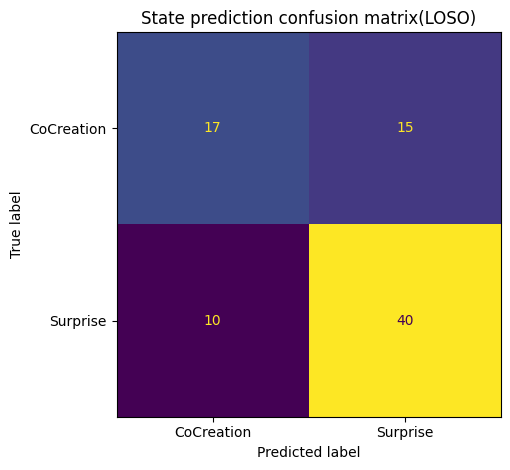


=== STATE MODEL (LOSO) ===
 overall_accuracy_test  overall_auc_test  n_state_test_rows
              0.695122          0.791875                 82

=== STATE-SPECIFIC AR(2)+Δ DYNAMICS (sample rows) ===
test_label      state  n      E_a1      E_a2     E_a3       E_b      Q_c1      Q_c2      Q_c3       Q_d  Q_sign_acc_train
        P1 CoCreation 31 -0.004955 -0.034207 0.029252 -8.206309 -0.002042 -0.000365 -0.001678 -0.020156          0.580645
        P1   Surprise 49  0.107713  0.056026 0.051687 -5.893875  0.012076  0.025027 -0.012951 -0.034727          0.612245
       P10 CoCreation 32 -0.002379 -0.049067 0.046688 -8.342646 -0.001472 -0.000222 -0.001250 -0.019500          0.593750
       P10   Surprise 49  0.112956  0.070040 0.042916 -5.762490  0.011971  0.025761 -0.013789 -0.033128          0.612245
       P11 CoCreation 31  0.001159 -0.036381 0.037540 -8.238146 -0.004368 -0.005781  0.001414 -0.015802          0.516129


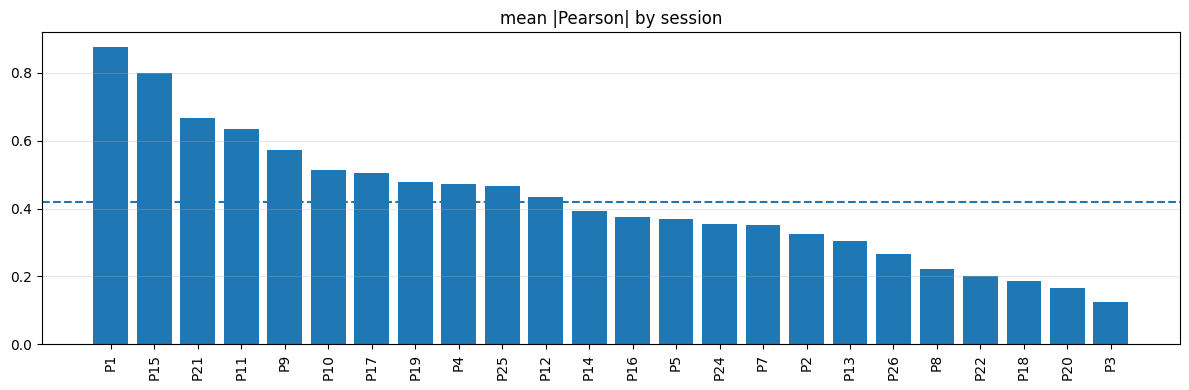

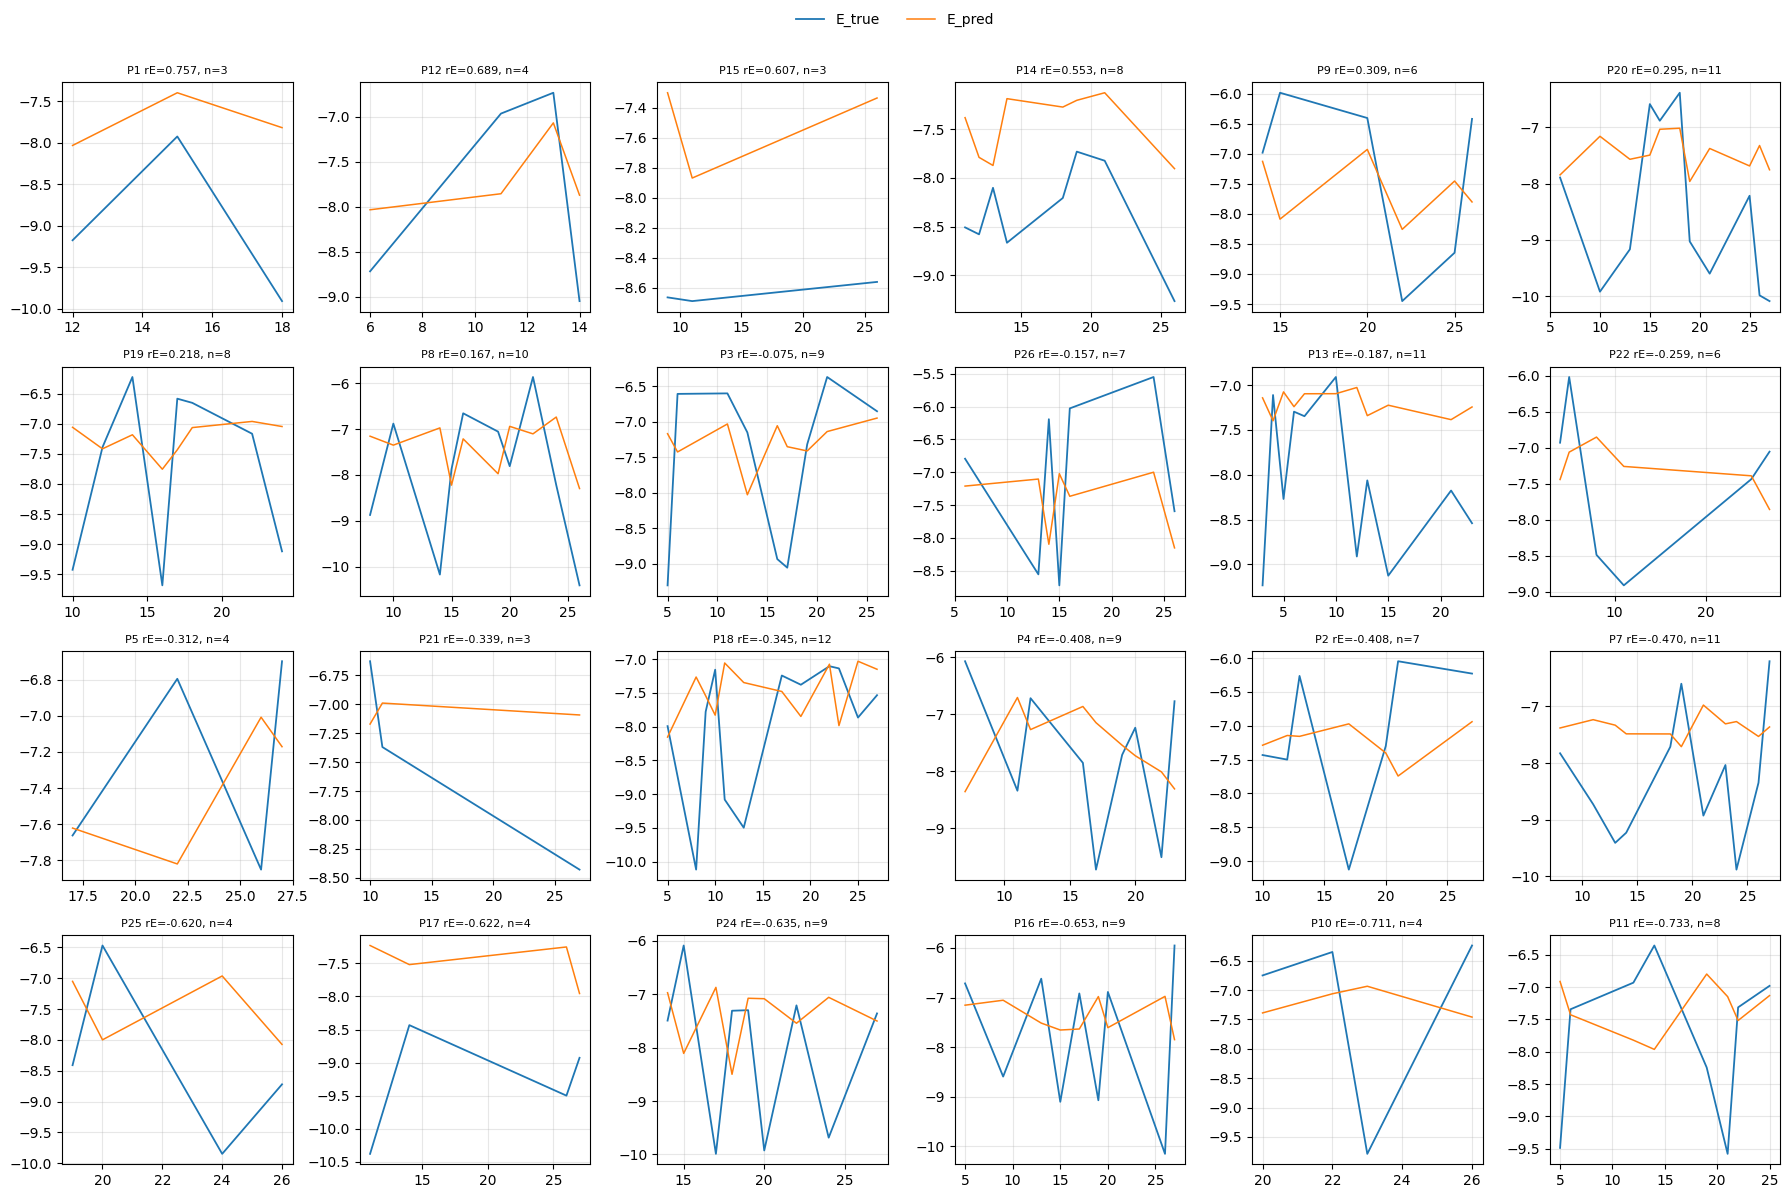

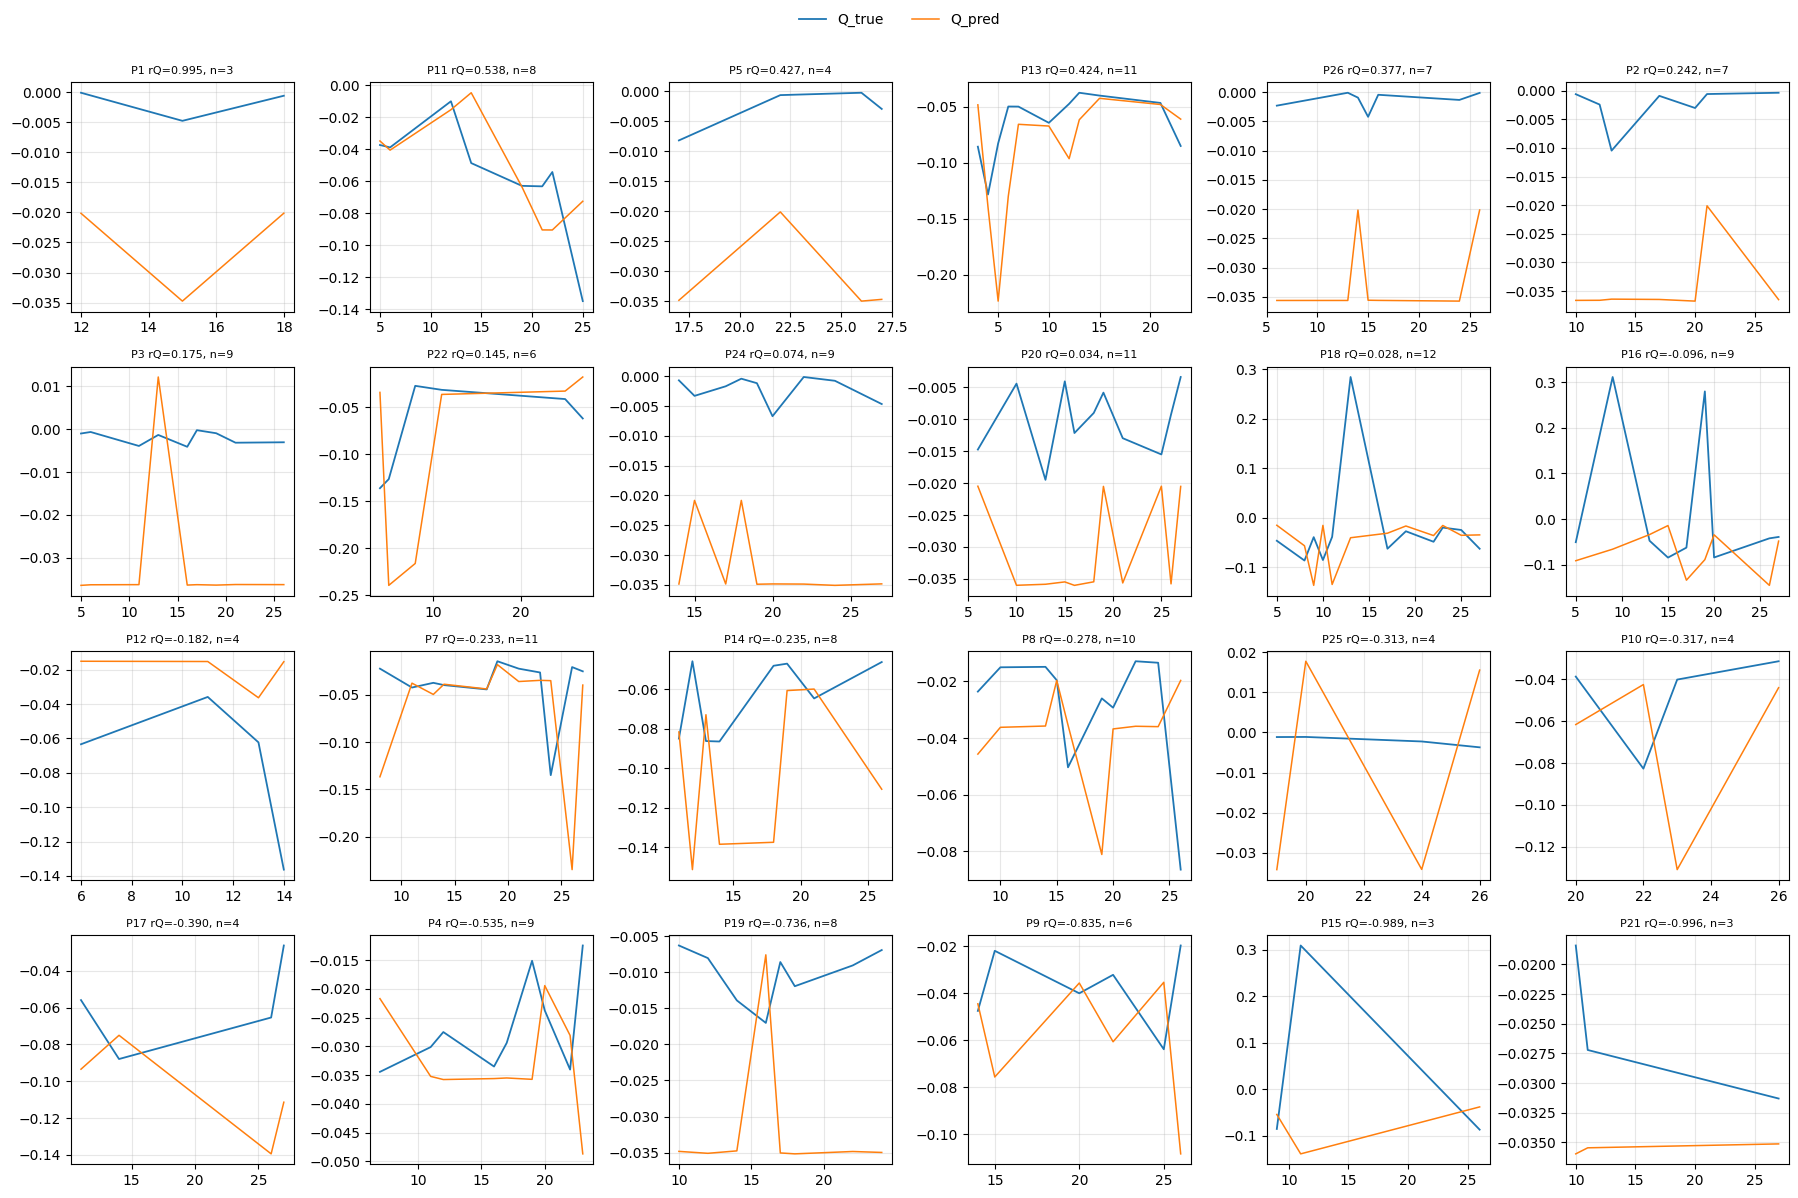


=== REPRESENTATIVE SESSIONS ===
E best: P14
Q best: P11


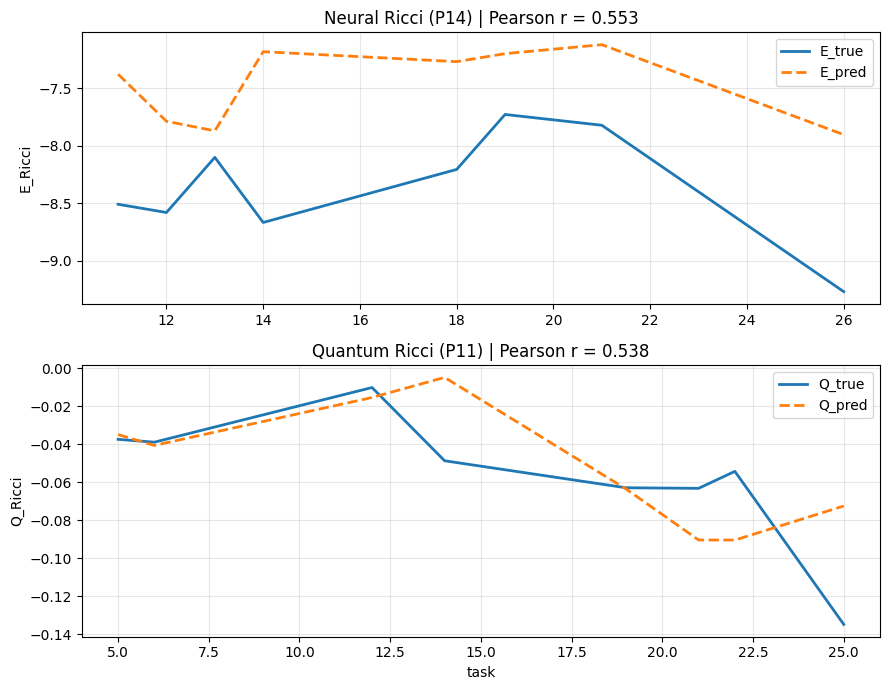

Saved: IDPC_Reproduction/Chapter2/Figure4_best_E_and_Q_combined.png
E best: P14
Q best: P11


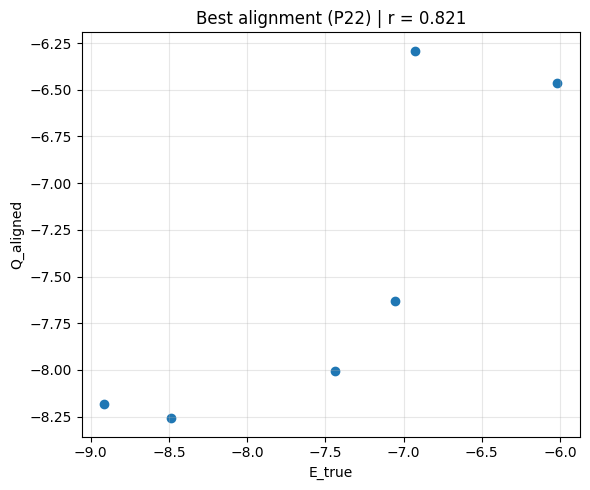


=== BEST ALIGNMENT SESSION BY r_aligned ===
label  n          a         b  r_aligned  rep_score  mean_abs_pearson
  P22  6 -18.091845 -8.755021   0.821423   0.072706          0.202357


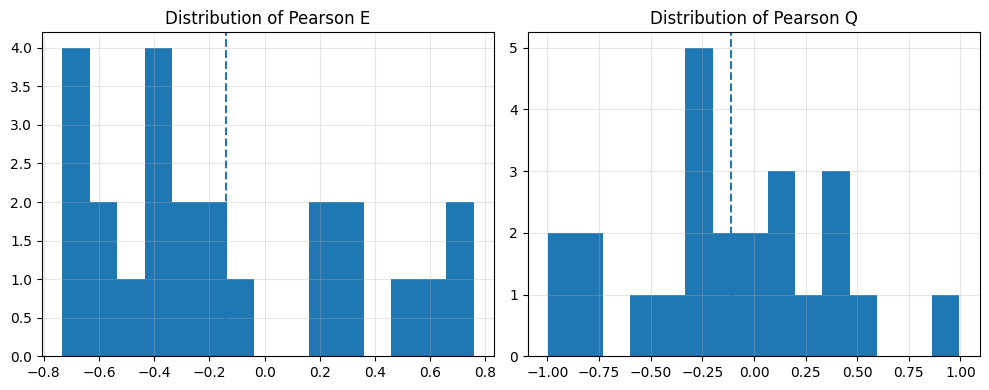


=== SESSION PEARSON TABLE ===
label  n  pearson_E  pearson_Q  pearson_EQ  mean_abs_pearson  rep_score
   P1  3   0.756592   0.995215   -0.891078          0.875903   0.875903
  P15  3   0.607340  -0.989240   -0.652605          0.798290   0.303670
  P21  3  -0.338843  -0.996393    0.952476          0.667618   0.000000
  P11  8  -0.733065   0.537868   -0.068847          0.635467   0.268934
   P9  6   0.309017  -0.835270    0.467809          0.572143   0.154509
  P10  4  -0.710770  -0.316638   -0.252785          0.513704   0.000000
  P17  4  -0.622145  -0.390196   -0.233035          0.506170   0.000000
  P19  8   0.218436  -0.735805   -0.056443          0.477121   0.109218
   P4  9  -0.408437  -0.535123    0.284565          0.471780   0.000000
  P25  4  -0.619912  -0.313166    0.505915          0.466539   0.000000
  P12  4   0.688834  -0.181852    0.731366          0.435343   0.344417
  P14  8   0.552836  -0.235242   -0.045073          0.394039   0.276418
  P16  9  -0.652517  -0.096146   

In [11]:
# ============================================================
# Chapter 2 Figure Generation Script
# ------------------------------------------------------------
# Purpose:
# This script generates all figures presented in Chapter 2 of
# the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# Chapter 2 demonstrates that structural agreement emerges
# between two physically independent systems:
#   - Neural dynamics (EEG-derived Ricci curvature: E)
#   - Quantum dynamics (probability-geometry-derived Ricci curvature: Q)
#
# Importantly, this agreement is NOT evaluated via direct correlation
# of raw time series. Instead:
#   - Each system is independently reconstructed using a one-step
#     predictive framework
#   - Agreement is evaluated between reconstructed dynamics
#
# The goal is to show that:
#   - Structural agreement exists without causal interaction
#   - The agreement is selective (not uniform over time)
#   - Multiple structural constraints co-occur:
#       • temporal correspondence
#       • discrete state structure
#       • non-random distribution
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Data Preparation
#    - Load event-level dataset (φ, dφ, E, Q, state)
#    - Ensure numerical consistency and session ordering
#
# 2. LOSO State Prediction (Figure 7)
#    - Train logistic regression using (φ, dφ)
#    - Predict next state (Surprise / CoCreation)
#    - Evaluate performance (accuracy, AUC)
#
# 3. State-dependent Dynamics Reconstruction
#    - For each state:
#        E(t+1) = f(E_t, E_t-1, ΔE_t)
#        Q(t+1) = f(Q_t, Q_t-1, ΔQ_t)
#    - Neural and quantum systems are modeled independently
#    - No cross-system information is used
#
# 4. Session-wise Reconstruction Consistency (Figure 1)
#    - Compute Pearson correlation between:
#        E_true vs E_pred
#        Q_true vs Q_pred
#    - Aggregate as mean absolute Pearson per session
#
# 5. Temporal Structural Correspondence (Figures 2 & 3)
#    - Plot time series of reconstructed vs true signals
#    - Evaluate alignment of:
#        • waveform structure
#        • fluctuation timing
#
# 6. Representative Sessions (Figure 4)
#    - Select best neural-aligned and quantum-aligned sessions
#    - Visualize representative structural agreement
#
# 7. Geometric Alignment (Figure 5)
#    - Fit linear mapping: Q → E
#    - Evaluate aligned correlation (r_aligned)
#
# 8. Distribution Analysis (Figure 6)
#    - Analyze distribution of Pearson correlations
#    - Confirm non-random structure (positive tail)
#
# ------------------------------------------------------------
# Key Principle:
#
# The analysis enforces strict independence:
#   - Neural reconstruction uses only neural variables
#   - Quantum reconstruction uses only quantum variables
#   - Cross-system agreement emerges only at evaluation stage
#
# Therefore, any observed agreement cannot be attributed to:
#   - causal interaction
#   - shared inputs
#   - data leakage
#
# Instead, it indicates:
#   → existence of a shared structural constraint
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import pearsonr

# =========================
# Configuration
# =========================
INDIR = "IDPC_Reproduction"
OUTDIR = os.path.join(INDIR, "Chapter2")
os.makedirs(OUTDIR, exist_ok=True)

INPUT_CSV = os.path.join(INDIR, "event_level_with_fes_phase_TRUE_RICCI.csv")

CONF_MARGIN = 0.00
USE_CONF_FILTER = False
BEST_MIN_N = 5

RIDGE_ALPHA_Q = 1.0

# =========================
# Helper functions
# =========================
def safe_pearson(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan
    return pearsonr(x, y)[0]

def build_train_for_source(df_source):
    rows = []

    for lab, g in df_source.groupby("label"):
        g = g.sort_values("task_idx").reset_index(drop=True)

        for i in range(1, len(g) - 1):
            s_next = g.loc[i + 1, "fes_phase"]
            if s_next not in ["Surprise", "CoCreation"]:
                continue

            vals = [
                g.loc[i, "phi"], g.loc[i, "dphi"],
                g.loc[i, "E"], g.loc[i, "Q"],
                g.loc[i - 1, "E"], g.loc[i - 1, "Q"],
                g.loc[i + 1, "E"], g.loc[i + 1, "Q"]
            ]
            if not np.all(np.isfinite(vals)):
                continue

            E_t = g.loc[i, "E"]
            Q_t = g.loc[i, "Q"]
            E_tm1 = g.loc[i - 1, "E"]
            Q_tm1 = g.loc[i - 1, "Q"]

            dE_t = E_t - E_tm1
            dQ_t = Q_t - Q_tm1

            E_next = g.loc[i + 1, "E"]
            Q_next = g.loc[i + 1, "Q"]

            dQ_next = Q_next - Q_t

            if dQ_next > 0:
                y_sign_q = 1
            elif dQ_next < 0:
                y_sign_q = -1
            else:
                y_sign_q = 0

            rows.append({
                "label": lab,
                "task_idx_t": g.loc[i, "task_idx"],
                "task_idx_next": g.loc[i + 1, "task_idx"],
                "phi_t": g.loc[i, "phi"],
                "dphi_t": g.loc[i, "dphi"],
                "E_t": E_t,
                "Q_t": Q_t,
                "E_tm1": E_tm1,
                "Q_tm1": Q_tm1,
                "dE_t": dE_t,
                "dQ_t": dQ_t,
                "state_next": s_next,
                "y_state": 1 if s_next == "Surprise" else 0,
                "E_next": E_next,
                "Q_next": Q_next,
                "dQ_next": dQ_next,
                "y_sign_q": y_sign_q,
            })

    return pd.DataFrame(rows).dropna().reset_index(drop=True)

# =========================
# Data loading
# =========================
df = pd.read_csv(INPUT_CSV)
df = df.sort_values(["label", "task_idx"]).reset_index(drop=True)

needed = ["label", "task_idx", "phi", "dphi", "E", "Q", "fes_phase"]
for c in needed:
    if c not in df.columns:
        raise KeyError(f"missing column: {c}")

for c in ["phi", "dphi", "E", "Q"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

all_labels = sorted(df["label"].dropna().unique())

# =========================
# LOSO state prediction & per-session evaluation
# =========================
session_rows = []
session_demos = {}
state_eval_rows = []
state_perf_rows = []
dyn_coef_rows = []

for lab in all_labels:
    train_source = df[df["label"] != lab].copy()
    test_g = df[df["label"] == lab].sort_values("task_idx").reset_index(drop=True)

    train = build_train_for_source(train_source)
    if len(train) < 10:
        continue

    # -------------------------
    # State prediction model
    # -------------------------
    X_state_df = train[["phi_t", "dphi_t"]].copy()
    y_state = train["y_state"].values

    state_scaler = StandardScaler()
    X_state_scaled = state_scaler.fit_transform(X_state_df)

    state_clf = LogisticRegression(max_iter=1000)
    state_clf.fit(X_state_scaled, y_state)

    p_train = state_clf.predict_proba(X_state_scaled)[:, 1]
    y_pred_train = (p_train >= 0.5).astype(int)

    acc = float((y_pred_train == y_state).mean())
    auc = float(roc_auc_score(y_state, p_train))

    state_perf_rows.append({
        "test_label": lab,
        "accuracy_train": acc,
        "auc_train": auc,
        "n_train": len(train)
    })

    # -------------------------
    # AR(2)+Δ dynamics per state
    # + Q sign model
    # -------------------------
    dyn_models = {}
    dyn_rows_this = []

    for st in ["CoCreation", "Surprise"]:
        sub = train[train["state_next"] == st].copy()
        if len(sub) < 3:
            continue

        XE = sub[["E_t", "E_tm1", "dE_t"]].values
        yE = sub["E_next"].values
        model_E = LinearRegression()
        model_E.fit(XE, yE)

        XQ = sub[["Q_t", "Q_tm1", "dQ_t"]].values
        yQ = sub["Q_next"].values
        model_Q = Ridge(alpha=RIDGE_ALPHA_Q)
        model_Q.fit(XQ, yQ)

        sub_sign = sub[sub["y_sign_q"] != 0].copy()
        sign_model_Q = None
        sign_acc_train = np.nan

        if len(sub_sign) >= 4 and len(np.unique(sub_sign["y_sign_q"])) >= 2:
            XQ_sign = sub_sign[["Q_t", "Q_tm1", "dQ_t"]].values
            yQ_sign = (sub_sign["y_sign_q"] > 0).astype(int).values

            sign_model_Q = LogisticRegression(max_iter=1000)
            sign_model_Q.fit(XQ_sign, yQ_sign)

            sign_pred_train = sign_model_Q.predict(XQ_sign)
            sign_acc_train = float(np.mean(sign_pred_train == yQ_sign))

        dyn_models[st] = {
            "E_model": model_E,
            "Q_model": model_Q,
            "Q_sign_model": sign_model_Q,
            "n": len(sub),
            "E_coef": (model_E.coef_.copy(), model_E.intercept_),
            "Q_coef": (model_Q.coef_.copy(), model_Q.intercept_),
            "Q_sign_acc_train": sign_acc_train,
        }

        aE, bE = dyn_models[st]["E_coef"]
        aQ, bQ = dyn_models[st]["Q_coef"]

        dyn_rows_this.append({
            "test_label": lab,
            "state": st,
            "n": len(sub),
            "E_a1": aE[0],
            "E_a2": aE[1],
            "E_a3": aE[2],
            "E_b": bE,
            "Q_c1": aQ[0],
            "Q_c2": aQ[1],
            "Q_c3": aQ[2],
            "Q_d": bQ,
            "Q_sign_acc_train": sign_acc_train,
        })

    if len(dyn_rows_this):
        dyn_coef_rows.append(pd.DataFrame(dyn_rows_this))

    # -------------------------
    # State prediction & reconstruction on test session
    # -------------------------
    pred_rows = []

    for i in range(1, len(test_g) - 1):
        vals = [
            test_g.loc[i, "phi"], test_g.loc[i, "dphi"],
            test_g.loc[i, "E"], test_g.loc[i, "Q"],
            test_g.loc[i - 1, "E"], test_g.loc[i - 1, "Q"],
            test_g.loc[i + 1, "E"], test_g.loc[i + 1, "Q"]
        ]
        if not np.all(np.isfinite(vals)):
            continue

        x_state_df = pd.DataFrame([{
            "phi_t": test_g.loc[i, "phi"],
            "dphi_t": test_g.loc[i, "dphi"]
        }])
        x_state_scaled = state_scaler.transform(x_state_df)

        p_sur = state_clf.predict_proba(x_state_scaled)[0, 1]

        s_next = test_g.loc[i + 1, "fes_phase"]
        if s_next in ["Surprise", "CoCreation"]:
            state_eval_rows.append({
                "label": lab,
                "task_idx_next": test_g.loc[i + 1, "task_idx"],
                "y_true": 1 if s_next == "Surprise" else 0,
                "y_true_label": s_next,
                "p_surprise": float(p_sur),
                "y_pred": 1 if p_sur >= 0.5 else 0,
                "y_pred_label": "Surprise" if p_sur >= 0.5 else "CoCreation"
            })

        if USE_CONF_FILTER and abs(p_sur - 0.5) < CONF_MARGIN:
            continue

        state_pred = "Surprise" if p_sur >= 0.5 else "CoCreation"
        if state_pred not in dyn_models:
            continue

        E_t = test_g.loc[i, "E"]
        Q_t = test_g.loc[i, "Q"]
        E_tm1 = test_g.loc[i - 1, "E"]
        Q_tm1 = test_g.loc[i - 1, "Q"]

        dE_t = E_t - E_tm1
        dQ_t = Q_t - Q_tm1

        XE = np.array([[E_t, E_tm1, dE_t]])
        XQ = np.array([[Q_t, Q_tm1, dQ_t]])

        E_hat = dyn_models[state_pred]["E_model"].predict(XE)[0]

        Q_raw = dyn_models[state_pred]["Q_model"].predict(XQ)[0]
        dQ_raw = Q_raw - Q_t

        sign_model_Q = dyn_models[state_pred]["Q_sign_model"]
        if sign_model_Q is not None:
            sign_prob = sign_model_Q.predict_proba(XQ)[0, 1]
            sign_pred = 1 if sign_prob >= 0.5 else -1
            dQ_fixed = abs(dQ_raw) * sign_pred
            Q_hat = Q_t + dQ_fixed
        else:
            sign_prob = np.nan
            Q_hat = Q_raw

        pred_rows.append({
            "task": test_g.loc[i + 1, "task_idx"],
            "phi_t": test_g.loc[i, "phi"],
            "dphi_t": test_g.loc[i, "dphi"],
            "E_t": E_t,
            "Q_t": Q_t,
            "E_tm1": E_tm1,
            "Q_tm1": Q_tm1,
            "dE_t": dE_t,
            "dQ_t": dQ_t,
            "E_true": test_g.loc[i + 1, "E"],
            "Q_true": test_g.loc[i + 1, "Q"],
            "E_pred": E_hat,
            "Q_pred": Q_hat,
            "Q_raw_pred": Q_raw,
            "Q_sign_prob_positive": sign_prob,
            "p_surprise": p_sur,
            "state_pred": state_pred,
        })

    demo = pd.DataFrame(pred_rows)
    if len(demo) < 3:
        continue

    rE = safe_pearson(demo["E_true"], demo["E_pred"])
    rQ = safe_pearson(demo["Q_true"], demo["Q_pred"])
    rEQ = safe_pearson(demo["E_true"], demo["Q_true"])

    session_rows.append({
        "label": lab,
        "n": len(demo),
        "pearson_E": rE,
        "pearson_Q": rQ,
        "pearson_EQ": rEQ,
        "mean_abs_pearson": np.nanmean([abs(rE), abs(rQ)]),
    })

    session_demos[lab] = demo.copy()

pearson_table = pd.DataFrame(session_rows).sort_values("mean_abs_pearson", ascending=False)
if len(pearson_table) == 0:
    raise ValueError("No sessions survived evaluation.")

# Auxiliary column for representative selection
pearson_table["rep_score"] = (
    pearson_table["pearson_E"].clip(lower=0) +
    pearson_table["pearson_Q"].clip(lower=0)
) / 2.0

all_demo_df = pd.concat(
    [d.assign(label=lab) for lab, d in session_demos.items()],
    ignore_index=True
)

# =========================
# Figure 7: State model summary / confusion matrix
# =========================
state_eval_df = pd.DataFrame(state_eval_rows)

if len(state_eval_df):
    overall_acc = float((state_eval_df["y_true"] == state_eval_df["y_pred"]).mean())
    overall_auc = float(roc_auc_score(state_eval_df["y_true"], state_eval_df["p_surprise"]))
    state_model_perf_df = pd.DataFrame([{
        "overall_accuracy_test": overall_acc,
        "overall_auc_test": overall_auc,
        "n_state_test_rows": len(state_eval_df)
    }])
else:
    state_model_perf_df = pd.DataFrame([{
        "overall_accuracy_test": np.nan,
        "overall_auc_test": np.nan,
        "n_state_test_rows": 0
    }])

state_model_perf_df.to_csv(os.path.join(OUTDIR, "state_model_performance.csv"), index=False)

if len(state_eval_df):
    cm = confusion_matrix(state_eval_df["y_true"], state_eval_df["y_pred"])
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["CoCreation", "Surprise"])
    disp.plot(colorbar=False)
    plt.title("State prediction confusion matrix(LOSO)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "state_confusion_matrix.png"), dpi=300)
    plt.show()
    plt.close()

print("\n=== STATE MODEL (LOSO) ===")
print(state_model_perf_df.to_string(index=False))

# =========================
# Save dynamics coefficients
# =========================
if len(dyn_coef_rows):
    dyn_coef_df = pd.concat(dyn_coef_rows, ignore_index=True)
    dyn_coef_df.to_csv(os.path.join(OUTDIR, "state_dynamics_coefficients.csv"), index=False)

    print("\n=== STATE-SPECIFIC AR(2)+Δ DYNAMICS (sample rows) ===")
    print(dyn_coef_df.head().to_string(index=False))

# =========================
# Figure 1: Overall bar plot
# =========================
plt.figure(figsize=(12, 4))
plt.bar(pearson_table["label"], pearson_table["mean_abs_pearson"])
plt.axhline(pearson_table["mean_abs_pearson"].mean(), linestyle="--")
plt.xticks(rotation=90)
plt.title("mean |Pearson| by session")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "mean_abs_pearson_bar.png"), dpi=300)
plt.show()
plt.close()

import os
import math
import matplotlib.pyplot as plt

# =========================
# Figure 2: E panels
# =========================
import os
import math
import matplotlib.pyplot as plt

pearson_table_E = pearson_table.sort_values("pearson_E", ascending=False).reset_index(drop=True)
labels_plot_E = list(pearson_table_E["label"])

n_plots_E = len(labels_plot_E)
n_cols = 6
n_rows_E = math.ceil(n_plots_E / n_cols)

fig, axes = plt.subplots(n_rows_E, n_cols, figsize=(18, 3.0 * n_rows_E))
axes = axes.flatten()

for i, lab in enumerate(labels_plot_E):
    ax = axes[i]
    demo = session_demos[lab]

    ax.plot(demo["task"], demo["E_true"], linewidth=1.3)
    ax.plot(demo["task"], demo["E_pred"], linewidth=1.1)

    rE = pearson_table_E.loc[pearson_table_E["label"] == lab, "pearson_E"].iloc[0]
    n_ = pearson_table_E.loc[pearson_table_E["label"] == lab, "n"].iloc[0]

    # Restore original: include r and n in title
    ax.set_title(f"{lab} rE={rE:.3f}, n={n_}", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(n_plots_E, len(axes)):
    fig.delaxes(axes[j])

fig.legend(["E_true", "E_pred"], loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTDIR, "all_sessions_E_panels_sorted_by_rE.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# =========================
# Figure 3: Q panels
# =========================
pearson_table_Q = pearson_table.sort_values("pearson_Q", ascending=False).reset_index(drop=True)
labels_plot_Q = list(pearson_table_Q["label"])

n_plots_Q = len(labels_plot_Q)
n_cols = 6
n_rows_Q = math.ceil(n_plots_Q / n_cols)

fig, axes = plt.subplots(n_rows_Q, n_cols, figsize=(18, 3.0 * n_rows_Q))
axes = axes.flatten()

for i, lab in enumerate(labels_plot_Q):
    ax = axes[i]
    demo = session_demos[lab]

    ax.plot(demo["task"], demo["Q_true"], linewidth=1.3)
    ax.plot(demo["task"], demo["Q_pred"], linewidth=1.1)

    rQ = pearson_table_Q.loc[pearson_table_Q["label"] == lab, "pearson_Q"].iloc[0]
    n_ = pearson_table_Q.loc[pearson_table_Q["label"] == lab, "n"].iloc[0]

    # Restore original: include r and n in title
    ax.set_title(f"{lab} rQ={rQ:.3f}, n={n_}", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(n_plots_Q, len(axes)):
    fig.delaxes(axes[j])

fig.legend(["Q_true", "Q_pred"], loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTDIR, "all_sessions_Q_panels_sorted_by_rQ.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================
# Representative session selection (separate E and Q)
# =========================
best_E_candidates = pearson_table[
    (pearson_table["pearson_E"] > 0) &
    (pearson_table["n"] >= BEST_MIN_N)
].copy()

if len(best_E_candidates) == 0:
    best_E_candidates = pearson_table.copy()

best_E_lab = best_E_candidates.sort_values(
    "pearson_E", ascending=False
).iloc[0]["label"]

best_Q_candidates = pearson_table[
    (pearson_table["pearson_Q"] > 0) &
    (pearson_table["n"] >= BEST_MIN_N)
].copy()

if len(best_Q_candidates) == 0:
    best_Q_candidates = pearson_table.copy()

best_Q_lab = best_Q_candidates.sort_values(
    "pearson_Q", ascending=False
).iloc[0]["label"]

print("\n=== REPRESENTATIVE SESSIONS ===")
print("E best:", best_E_lab)
print("Q best:", best_Q_lab)

# =========================
# Figure 4: Combine auto-selected E-best and Q-best into one PNG
# =========================
demo_E = session_demos[best_E_lab]
demo_Q = session_demos[best_Q_lab]

rE_best = pearson_table.loc[
    pearson_table["label"] == best_E_lab, "pearson_E"
].iloc[0]

rQ_best = pearson_table.loc[
    pearson_table["label"] == best_Q_lab, "pearson_Q"
].iloc[0]

combined_png = os.path.join(OUTDIR, "Figure4_best_E_and_Q_combined.png")

plt.figure(figsize=(9, 7))

# -------------------------
# Top: Auto-selected E-best
# -------------------------
plt.subplot(2, 1, 1)
plt.plot(demo_E["task"], demo_E["E_true"], label="E_true", linewidth=2)
plt.plot(demo_E["task"], demo_E["E_pred"], "--", label="E_pred", linewidth=2)
plt.title(f"Neural Ricci ({best_E_lab}) | Pearson r = {rE_best:.3f}")
plt.ylabel("E_Ricci")
plt.legend()
plt.grid(alpha=0.3)

# -------------------------
# Bottom: Auto-selected Q-best
# -------------------------
plt.subplot(2, 1, 2)
plt.plot(demo_Q["task"], demo_Q["Q_true"], label="Q_true", linewidth=2)
plt.plot(demo_Q["task"], demo_Q["Q_pred"], "--", label="Q_pred", linewidth=2)
plt.title(f"Quantum Ricci ({best_Q_lab}) | Pearson r = {rQ_best:.3f}")
plt.xlabel("task")
plt.ylabel("Q_Ricci")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(combined_png, dpi=300)
plt.show()
plt.close()

# Save reference CSV if needed
demo_E.to_csv(os.path.join(OUTDIR, f"{best_E_lab}_E_best.csv"), index=False)
demo_Q.to_csv(os.path.join(OUTDIR, f"{best_Q_lab}_Q_best.csv"), index=False)

print("Saved:", combined_png)
print("E best:", best_E_lab)
print("Q best:", best_Q_lab)


# =========================
# Figure 5: Alignment scatter
# Select session with maximum r_aligned
# =========================
alignment_rows = []

for lab, demo in session_demos.items():
    E = demo["E_true"].values
    Q = demo["Q_true"].values

    m = np.isfinite(E) & np.isfinite(Q)
    E = E[m]
    Q = Q[m]

    if len(E) < BEST_MIN_N:
        continue

    align_model = LinearRegression()
    align_model.fit(Q.reshape(-1, 1), E)
    Q_aligned = align_model.predict(Q.reshape(-1, 1))
    r_aligned = safe_pearson(E, Q_aligned)

    row_src = pearson_table.loc[pearson_table["label"] == lab]
    rep_score = row_src["rep_score"].iloc[0] if len(row_src) else np.nan
    mean_abs_pearson = row_src["mean_abs_pearson"].iloc[0] if len(row_src) else np.nan

    alignment_rows.append({
        "label": lab,
        "n": len(E),
        "a": align_model.coef_[0],
        "b": align_model.intercept_,
        "r_aligned": r_aligned,
        "rep_score": rep_score,
        "mean_abs_pearson": mean_abs_pearson,
    })

alignment_table = pd.DataFrame(alignment_rows)

if len(alignment_table):
    best_row = alignment_table.sort_values(
        ["r_aligned", "rep_score", "mean_abs_pearson", "n"],
        ascending=[False, False, False, False]
    ).iloc[0]

    align_lab = best_row["label"]
    align_demo = session_demos[align_lab]

    E = align_demo["E_true"].values
    Q = align_demo["Q_true"].values
    m = np.isfinite(E) & np.isfinite(Q)
    E = E[m]
    Q = Q[m]

    align_model = LinearRegression()
    align_model.fit(Q.reshape(-1, 1), E)
    Q_aligned = align_model.predict(Q.reshape(-1, 1))
    r_aligned = safe_pearson(E, Q_aligned)

    alignment_table.to_csv(os.path.join(OUTDIR, "alignment_table_all_sessions.csv"), index=False)

    pd.DataFrame([best_row]).to_csv(
        os.path.join(OUTDIR, f"{align_lab}_alignment_summary.csv"),
        index=False
    )

    plt.figure(figsize=(6, 5))
    plt.scatter(E, Q_aligned)
    plt.xlabel("E_true")
    plt.ylabel("Q_aligned")
    plt.title(f"Best alignment ({align_lab}) | r = {r_aligned:.3f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{align_lab}_alignment_scatter.png"), dpi=300)
    plt.show()
    plt.close()

    print("\n=== BEST ALIGNMENT SESSION BY r_aligned ===")
    print(pd.DataFrame([best_row]).to_string(index=False))
else:
    print("\nNo alignment candidate found.")

# =========================
# Figure 6: Distribution plots
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(pearson_table["pearson_E"].dropna(), bins=15)
plt.axvline(pearson_table["pearson_E"].mean(), linestyle="--")
plt.title("Distribution of Pearson E")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(pearson_table["pearson_Q"].dropna(), bins=15)
plt.axvline(pearson_table["pearson_Q"].mean(), linestyle="--")
plt.title("Distribution of Pearson Q")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "pearson_distributions.png"), dpi=300)
plt.show()
plt.close()

# =========================
# TOP / BOTTOM / SUMMARY
# =========================
print("\n=== SESSION PEARSON TABLE ===")
print(pearson_table.to_string(index=False))

print("\n=== SUMMARY ===")
print("mean Pearson E =", pearson_table["pearson_E"].mean())
print("mean Pearson Q =", pearson_table["pearson_Q"].mean())
print("mean Pearson EQ =", pearson_table["pearson_EQ"].mean())
print("mean abs Pearson =", pearson_table["mean_abs_pearson"].mean())

pearson_table.to_csv(os.path.join(OUTDIR, "pearson_table_dynamic.csv"), index=False)

top5 = pearson_table.head(5)
bot5 = pearson_table.tail(5)

print("\n=== TOP 5 ===")
print(top5.to_string(index=False))

print("\n=== BOTTOM 5 ===")
print(bot5.to_string(index=False))

top5.to_csv(os.path.join(OUTDIR, "top5_sessions.csv"), index=False)
bot5.to_csv(os.path.join(OUTDIR, "bottom5_sessions.csv"), index=False)

summary_df = pd.DataFrame([{
    "n_sessions_shown": len(pearson_table),
    "mean_Pearson_E": pearson_table["pearson_E"].mean(),
    "mean_Pearson_Q": pearson_table["pearson_Q"].mean(),
    "mean_Pearson_EQ": pearson_table["pearson_EQ"].mean(),
    "mean_abs_Pearson": pearson_table["mean_abs_pearson"].mean(),
    "state_test_accuracy": state_model_perf_df["overall_accuracy_test"].iloc[0],
    "state_test_auc": state_model_perf_df["overall_auc_test"].iloc[0],
}])
summary_df.to_csv(os.path.join(OUTDIR, "summary_metrics.csv"), index=False)

# =========================
# Save reconstruction CSV for all sessions
# =========================
all_demo_df.to_csv(os.path.join(OUTDIR, "all_sessions_dynamic_reconstruction.csv"), index=False)

dropped = [lab for lab in all_labels if lab not in pearson_table["label"].tolist()]
print("\nDropped labels:", dropped)

print("\nSaved outputs to:", OUTDIR)

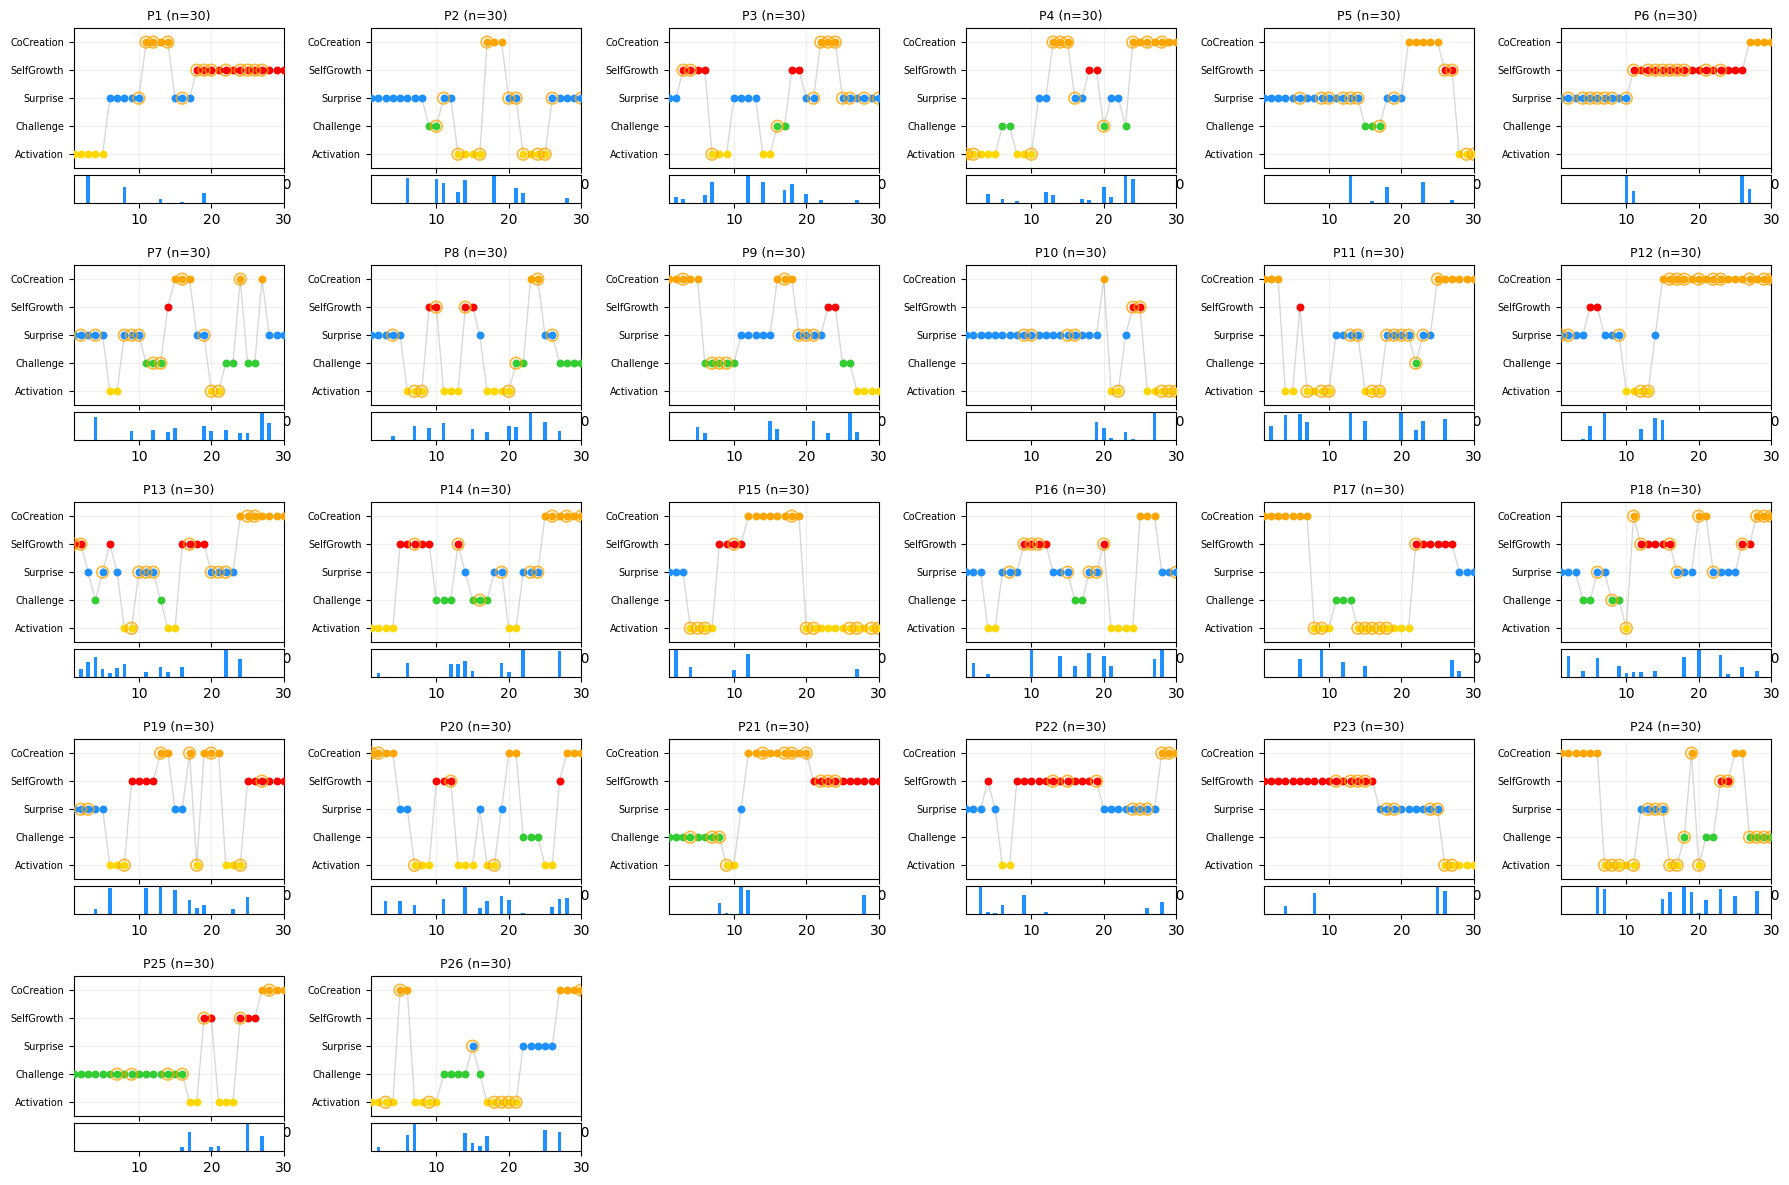

Saved: IDPC_Reproduction/Chapter3/FES_FINAL_alignment_independent.png


In [12]:
# ============================================================
# Figure 8 Generation Script for Chapter 3
# ------------------------------------------------------------
# Purpose:
# This script generates Figure 8 for Chapter 3 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:1‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# Figure 8 visualizes the discrete state structure underlying
# neural–quantum dynamics across sessions.
#
# In the paper, this figure is used to show that:
#   - session dynamics are organized in a common five-state space
#   - the state structure is discrete rather than continuous
#   - boundary impulse events appear at specific localized points
#   - structural alignment can appear independently of impulse events
#
# Each panel corresponds to one session and displays:
#   - state trajectory over task/event order
#   - FES state labels mapped to a common vertical state axis
#   - blue bar markers for J-based boundary impulse events
#   - orange outlines for independently detected alignment points
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load event-level boundary impulse data
#    - Read pooled J-event table
#    - Standardize the impulse column as J
#    - Standardize the event/task index column as task_idx
#
# 2. Load fixed FES labels
#    - Read event-level FES phase labels
#    - Extract (label, task_idx, fes_phase)
#
# 3. Build session list
#    - Detect all available session labels from quantum timeseries files
#
# 4. Assign FES labels to plotted task points
#    - For each task point in the quantum timeseries,
#      assign the nearest event-level FES label
#
# 5. Independently detect structural alignment points
#    - Load Ricci timeseries for each session
#    - Compute z-scored E and Q amplitudes
#    - Compute phase angles from local gradients
#    - Mark alignment points using:
#         • small phase difference
#         • small amplitude gap
#    - This alignment criterion is explicitly independent of J
#
# 6. Plot Figure 8
#    - Draw gray trajectory lines between consecutive states
#    - Plot colored state points by FES label
#    - Overlay orange outlines for aligned points
#    - Plot blue J bars in an inset axis below each panel
#
# ------------------------------------------------------------
# Key Principle:
#
# This figure distinguishes two different structures:
#
#   1. Boundary impulse events (J)
#      → shown as blue bars
#
#   2. Structural alignment points
#      → shown as orange outlined markers
#
# These are intentionally treated separately so that the figure can
# demonstrate that structural alignment is not identical to boundary
# impulse occurrence, even though both are organized within the same
# discrete state structure.
#
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PROVEPHI_DIR = "IDPC_Reproduction"
RICCI_DIR = "IDPC_Reproduction_ricci"
EVENT_CSV = "IDPC_Reproduction/J_dh_kappa_pooled_v2.csv"
PHASE_CSV = "IDPC_Reproduction/event_level_with_fes_phase_TRUE_RICCI.csv"
OUTDIR = "IDPC_Reproduction/Chapter3"
os.makedirs(OUTDIR, exist_ok=True)

# FES order
fes_order = ["Activation", "Challenge", "Surprise", "SelfGrowth", "CoCreation"]
fes_to_y = {k: i for i, k in enumerate(fes_order)}

# Colors
colors = {
    "Activation": "#FFD700",
    "Challenge": "#32CD32",
    "Surprise": "#1E90FF",
    "SelfGrowth": "#FF0000",
    "CoCreation": "#FFA500",
}

# Alignment thresholds
PHASE_THRESH_DEG = 12.0   # |Δpsi| must be below this threshold
AMP_THRESH_Z = 0.75       # |E_z - Q_z| must be below this threshold

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def zscore_series(x):
    x = pd.to_numeric(x, errors="coerce").to_numpy(float)
    out = np.full(len(x), np.nan, dtype=float)
    m = np.isfinite(x)
    if m.sum() < 2:
        return out
    mu = np.nanmean(x[m])
    sd = np.nanstd(x[m])
    if sd < 1e-12:
        out[m] = 0.0
    else:
        out[m] = (x[m] - mu) / sd
    return out

# =========================
# Load J events
# =========================
ev = pd.read_csv(EVENT_CSV)
j_col = next(c for c in ["J", "J_obs", "boundary_impulse", "impulse", "J_hat"] if c in ev.columns)
task_col = next(c for c in ["event_task", "task_idx", "t_idx", "task_curr"] if c in ev.columns)
ev = ev.rename(columns={j_col: "J", task_col: "task_idx"})
ev["task_idx"] = pd.to_numeric(ev["task_idx"], errors="coerce")

# =========================
# Load fixed FES labels
# =========================
phase_df = pd.read_csv(PHASE_CSV)
need = {"label", "task_idx", "fes_phase"}
missing = need - set(phase_df.columns)
if missing:
    raise KeyError(f"Missing columns in {PHASE_CSV}: {missing}")

phase_df = phase_df[["label", "task_idx", "fes_phase"]].copy()
phase_df["task_idx"] = pd.to_numeric(phase_df["task_idx"], errors="coerce")

# =========================
# Build session list
# =========================
labels = sorted([
    f.replace("_quantum_timeseries.csv", "")
    for f in os.listdir(PROVEPHI_DIR)
    if f.endswith("_quantum_timeseries.csv")
], key=lambda x: int(x[1:]))

# =========================
# Assign nearest FES label from event-level data
# =========================
def assign_nearest_fes(q_task_idx, event_task_idx, event_fes):
    q_task_idx = np.asarray(q_task_idx, dtype=float)
    event_task_idx = np.asarray(event_task_idx, dtype=float)
    event_fes = np.asarray(event_fes, dtype=object)

    assigned = []
    nearest_event_idx = []

    for t in q_task_idx:
        j = np.argmin(np.abs(event_task_idx - t))
        assigned.append(event_fes[j])
        nearest_event_idx.append(j)

    return np.array(assigned, dtype=object), np.array(nearest_event_idx, dtype=int)

# =========================
# Create figure
# =========================
n_cols = 6
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, lab in enumerate(labels):
    ax = axes[i]

    q = pd.read_csv(os.path.join(PROVEPHI_DIR, f"{lab}_quantum_timeseries.csv"))
    if "task_idx" not in q.columns:
        raise KeyError(f"{lab}_quantum_timeseries.csv does not contain task_idx")

    q = q.sort_values("task_idx").reset_index(drop=True)
    q["task_idx"] = pd.to_numeric(q["task_idx"], errors="coerce")
    q["event_order"] = np.arange(1, len(q) + 1)

    # Assign FES labels from nearest event-level annotation
    sub_phase = phase_df[phase_df["label"] == lab].sort_values("task_idx").reset_index(drop=True)
    if len(sub_phase) == 0:
        q["fes_phase"] = None
        q["nearest_event_idx"] = np.nan
    else:
        assigned_fes, nearest_idx = assign_nearest_fes(
            q["task_idx"].values,
            sub_phase["task_idx"].values,
            sub_phase["fes_phase"].values
        )
        q["fes_phase"] = assigned_fes
        q["nearest_event_idx"] = nearest_idx

    xs = q["event_order"].values
    ys = np.array([fes_to_y.get(p, np.nan) for p in q["fes_phase"]])

    # =========================
    # Detect alignment points independently of J
    # =========================
    ricci_fp = os.path.join(RICCI_DIR, f"{lab}_timeseries.csv")
    highlight_task_set = set()

    if os.path.exists(ricci_fp):
        r = pd.read_csv(ricci_fp).sort_values("task_idx").reset_index(drop=True)

        e_col = "E_Ricci" if "E_Ricci" in r.columns else None
        q_col = "Q_Ricci_affine" if "Q_Ricci_affine" in r.columns else ("Q_Ricci" if "Q_Ricci" in r.columns else None)

        if e_col is not None and q_col is not None:
            r["task_idx"] = pd.to_numeric(r["task_idx"], errors="coerce")
            r["E"] = pd.to_numeric(r[e_col], errors="coerce")
            r["Q"] = pd.to_numeric(r[q_col], errors="coerce")

            r["E_z"] = zscore_series(r["E"])
            r["Q_z"] = zscore_series(r["Q"])

            dE = np.gradient(r["E"].to_numpy(float))
            dQ = np.gradient(r["Q"].to_numpy(float))

            psiE = np.arctan2(dE, r["E"].to_numpy(float))
            psiQ = np.arctan2(dQ, r["Q"].to_numpy(float))
            dpsi = wrap_pi(psiE - psiQ)

            r["dpsi_deg"] = np.degrees(np.abs(dpsi))
            r["amp_gap"] = np.abs(r["E_z"] - r["Q_z"])

            # Alignment condition
            align_mask = (
                np.isfinite(r["dpsi_deg"]) &
                np.isfinite(r["amp_gap"]) &
                (r["dpsi_deg"] <= PHASE_THRESH_DEG) &
                (r["amp_gap"] <= AMP_THRESH_Z)
            )

            highlight_task_set = set(r.loc[align_mask, "task_idx"].tolist())

    # ===== Trajectory lines =====
    for j in range(len(xs) - 1):
        if np.isnan(ys[j]) or np.isnan(ys[j + 1]):
            continue
        ax.plot(xs[j:j+2], ys[j:j+2], color="gray", alpha=0.30, linewidth=1)

    # ===== State points =====
    for x, y, p in zip(xs, ys, q["fes_phase"]):
        if np.isnan(y):
            continue
        ax.scatter(x, y, color=colors.get(p, "black"), s=22, zorder=3)

    # ===== Orange outlines only for aligned points =====
    for j in range(len(q)):
        if q.loc[j, "task_idx"] in highlight_task_set and np.isfinite(ys[j]):
            ax.scatter(
                xs[j], ys[j],
                s=70,
                facecolors="none",
                edgecolors="#FFA500",
                linewidth=1.2,
                alpha=0.8,
                zorder=4
            )

    # ===== J bars (these represent J itself) =====
    ax2 = ax.inset_axes([0, -0.25, 1, 0.2])
    sub_ev = ev[ev["label"] == lab]
    if len(sub_ev) > 0:
        Jmax = np.max(np.abs(sub_ev["J"])) or 1
        for _, row in sub_ev.iterrows():
            x_task = row["task_idx"]
            val = abs(row["J"]) / Jmax

            hit = q.index[q["task_idx"] == x_task].tolist()
            if len(hit) == 0:
                continue
            x_plot = hit[0] + 1
            ax2.bar(x_plot, val, color="#1E90FF", width=0.5)

    ax2.set_ylim(0, 1)
    ax2.set_yticks([])
    ax2.set_xlim(1, len(q))

    # ===== Axes formatting =====
    ax.set_title(f"{lab} (n={len(q)})", fontsize=9)
    ax.set_ylim(-0.5, len(fes_order) - 0.5)
    ax.set_yticks(range(len(fes_order)))
    ax.set_yticklabels(fes_order, fontsize=7)
    ax.set_xlim(1, len(q))
    ax.grid(alpha=0.2)

for j in range(len(labels), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "FES_FINAL_alignment_independent.png"), dpi=300)
plt.show()
plt.close()

print("Saved:", os.path.join(OUTDIR, "FES_FINAL_alignment_independent.png"))

In [13]:
# ============================================================
# Chapter 3 Verification Script:
# 3.1 Ricci Oscillation and 3.2 Kuramoto-type Phase Coupling Test
# ------------------------------------------------------------
# Purpose:
# This script performs the numerical verification used for
# Chapter 3, Sections 3.1 and 3.2 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:1‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The script evaluates two related but distinct properties of the
# neural and quantum Ricci-curvature time series:
#
#   1. Oscillatory structure of each system individually
#      - Test whether each Ricci series approximately satisfies
#            Δ²r ≈ -ω² r
#      - This corresponds to the simple harmonic oscillator
#        structure described in Section 3.1
#
#   2. Kuramoto-type phase coupling between systems
#      - Construct instantaneous phase from each Ricci series
#      - Test whether the phase difference dynamics can be
#        explained by a simple Kuramoto-type interaction model
#      - This corresponds to the explanatory test discussed in
#        Section 3.2
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load Ricci timeseries files
#    - Read per-session neural and quantum Ricci trajectories
#    - Detect valid Ricci columns for E and Q
#
# 2. Oscillator test for each series
#    - For each E and Q time series separately:
#        • compute second difference Δ²r
#        • compare it to -r at the midpoint
#        • estimate ω² by zero-intercept linear regression
#    - Save per-session results and pooled summaries
#
# 3. Kuramoto-type phase test for each session
#    - Compute local phase from:
#          ψ = angle(r + i·dr/dt)
#    - Compute phase difference:
#          Δψ = ψ_E - ψ_Q
#    - Fit a simple phase interaction model:
#          d(Δψ)/dt ≈ Δω - 2K sin(Δψ)
#    - Evaluate explanatory power using R²
#
# 4. Aggregate results
#    - Report pooled oscillator structure for E and Q
#    - Report session-wise Kuramoto fit statistics
#    - Summarize whether phase alignment is present but not
#      fully explained by a simple interaction model
#
# ------------------------------------------------------------
# Key Principle:
#
# This script separates two claims:
#
#   A. Ricci dynamics themselves have oscillatory structure
#      → tested by Δ²r ≈ -ω² r
#
#   B. Cross-system phase alignment exists, but may not be
#      reducible to trivial pairwise coupling
#      → tested by the Kuramoto-type regression fit
#
# Therefore, a low Kuramoto R² does not deny phase structure.
# Rather, it supports the claim that the observed phase relation
# cannot be fully reduced to a simple pairwise interaction model.
#
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

# =========================================================
# CONFIG
# =========================================================
RICCI_DIR = "IDPC_Reproduction_ricci"
OUTDIR = "IDPC_Reproduction/Chapter3"
os.makedirs(OUTDIR, exist_ok=True)

files = sorted(glob.glob(os.path.join(RICCI_DIR, "*_timeseries.csv")))

print("RICCI_DIR =", RICCI_DIR)
print("n_files   =", len(files))

# =========================================================
# HELPERS
# =========================================================
def safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, len(x)
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan, np.nan, len(x)
    return pearsonr(x, y)[0], spearmanr(x, y)[0], len(x)

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def oscillator_test_one_series(r):
    r = np.asarray(r, float)
    m = np.isfinite(r)
    r = r[m]

    if len(r) < 5:
        return None

    d2r = np.diff(r, n=2)
    r_mid = r[1:-1]

    m2 = np.isfinite(d2r) & np.isfinite(r_mid)
    d2r = d2r[m2]
    r_mid = r_mid[m2]

    if len(d2r) < 3:
        return None

    rp, rs, n = safe_corr(d2r, -r_mid)

    # Δ²r ≈ -ω² r を原点通過回帰で評価
    X = r_mid.reshape(-1, 1)
    y = -d2r
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y)

    omega2 = float(model.coef_[0])
    r2 = float(model.score(X, y))

    return {
        "pearson": rp,
        "spearman": rs,
        "n": n,
        "omega2": omega2,
        "r2": r2,
        "r_mid": r_mid,
        "d2r": d2r,
    }

def kuramoto_test_one_pair(rE, rQ):
    rE = np.asarray(rE, float)
    rQ = np.asarray(rQ, float)

    m = np.isfinite(rE) & np.isfinite(rQ)
    rE = rE[m]
    rQ = rQ[m]

    if len(rE) < 10:
        return None

    drE = np.gradient(rE)
    drQ = np.gradient(rQ)

    psiE = np.angle(rE + 1j * drE)
    psiQ = np.angle(rQ + 1j * drQ)

    dpsi = np.angle(np.exp(1j * (psiE - psiQ)))
    dpsi_dt = np.gradient(dpsi)

    sin_term = np.sin(dpsi)

    m2 = np.isfinite(dpsi_dt) & np.isfinite(sin_term)
    if m2.sum() < 10:
        return None

    X = sin_term[m2].reshape(-1, 1)
    y = dpsi_dt[m2]

    model = LinearRegression().fit(X, y)
    r2 = float(model.score(X, y))
    delta_omega = float(model.intercept_)
    K_est = float(-model.coef_[0] / 2.0)

    return {
        "kuramoto_r2": r2,
        "Delta_omega": delta_omega,
        "K_est": K_est,
        "n": int(m2.sum()),
        "dpsi": dpsi[m2],
    }



# =========================================================
# MAIN
# =========================================================
osc_rows = []
kur_rows = []
phase_rows = []

all_E_mid, all_E_d2 = [], []
all_Q_mid, all_Q_d2 = [], []
all_dpsi = []

for fp in files:
    label = os.path.basename(fp).replace("_timeseries.csv", "")
    df = pd.read_csv(fp)

    # 列名候補
    e_col = next((c for c in ["E_Ricci", "E", "E_true"] if c in df.columns), None)
    q_col = next((c for c in ["Q_Ricci_affine", "Q_Ricci", "Q", "Q_true"] if c in df.columns), None)

    if e_col is None or q_col is None:
        print(f"SKIP {label}: missing Ricci columns")
        continue

    rE = pd.to_numeric(df[e_col], errors="coerce").to_numpy(float)
    rQ = pd.to_numeric(df[q_col], errors="coerce").to_numpy(float)

    # -------------------------
    # Oscillator test: E
    # -------------------------
    resE = oscillator_test_one_series(rE)
    if resE is not None:
        osc_rows.append({
            "label": label,
            "series": "E",
            "n": resE["n"],
            "pearson": resE["pearson"],
            "spearman": resE["spearman"],
            "omega2": resE["omega2"],
            "r2": resE["r2"],
        })
        all_E_mid.append(resE["r_mid"])
        all_E_d2.append(resE["d2r"])

    # -------------------------
    # Oscillator test: Q
    # -------------------------
    resQ = oscillator_test_one_series(rQ)
    if resQ is not None:
        osc_rows.append({
            "label": label,
            "series": "Q",
            "n": resQ["n"],
            "pearson": resQ["pearson"],
            "spearman": resQ["spearman"],
            "omega2": resQ["omega2"],
            "r2": resQ["r2"],
        })
        all_Q_mid.append(resQ["r_mid"])
        all_Q_d2.append(resQ["d2r"])

 
    # -------------------------
    # Kuramoto test
    # -------------------------
    kt = kuramoto_test_one_pair(rE, rQ)
    if kt is not None:
        kur_rows.append({
            "label": label,
            "kuramoto_r2": kt["kuramoto_r2"],
            "Delta_omega": kt["Delta_omega"],
            "K_est": kt["K_est"],
            "n": kt["n"],
        })

osc_df = pd.DataFrame(osc_rows)
kur_df = pd.DataFrame(kur_rows)

# =========================================================
# POOLED OSCILLATOR SUMMARY
# =========================================================
def pooled_osc_summary(name, mids, d2s):
    if len(mids) == 0:
        return None
    x = np.concatenate(mids)
    d2 = np.concatenate(d2s)

    rp, rs, n = safe_corr(d2, -x)

    model = LinearRegression(fit_intercept=False)
    model.fit(x.reshape(-1, 1), -d2)
    omega2 = float(model.coef_[0])
    r2 = float(model.score(x.reshape(-1, 1), -d2))

    return {
        "series": name,
        "n": n,
        "pearson": rp,
        "spearman": rs,
        "omega2": omega2,
        "r2": r2,
    }

pooled_E = pooled_osc_summary("E_pooled", all_E_mid, all_E_d2)
pooled_Q = pooled_osc_summary("Q_pooled", all_Q_mid, all_Q_d2)



# =========================================================
# GLOBAL KURAMOTO SUMMARY
# =========================================================
if len(kur_df):
    mean_r2 = float(kur_df["kuramoto_r2"].mean())
    median_r2 = float(kur_df["kuramoto_r2"].median())
    mean_K = float(kur_df["K_est"].mean())
else:
    mean_r2 = np.nan
    median_r2 = np.nan
    mean_K = np.nan

# =========================================================
# PRINT
# =========================================================
print("\n=== Oscillator test: Δ²r = -ω²r ===")
if pooled_E is not None:
    print("E pooled :", pooled_E)
if pooled_Q is not None:
    print("Q pooled :", pooled_Q)

if len(osc_df):
    print("\nPer-session oscillator summary (head):")
    print(osc_df.head(12).to_string(index=False))


print("\n=== Kuramoto coupling test ===")
if len(kur_df):
    print(kur_df.sort_values("kuramoto_r2", ascending=False).to_string(index=False))
    print("\nGLOBAL")
    print("mean R2 =", mean_r2)
    print("median R2 =", median_r2)
    print("mean K =", mean_K)
else:
    print("No valid sessions.")

# =========================================================
# SAVE
# =========================================================
osc_df.to_csv(os.path.join(OUTDIR, "oscillator_test_per_session_latest_riccisync.csv"), index=False)
kur_df.to_csv(os.path.join(OUTDIR, "kuramoto_test_per_session_latest_riccisync.csv"), index=False)

summary_rows = []
if pooled_E is not None:
    summary_rows.append(pooled_E)
if pooled_Q is not None:
    summary_rows.append(pooled_Q)


summary_rows.append({
    "series": "kuramoto_global",
    "n": len(kur_df),
    "pearson": np.nan,
    "spearman": np.nan,
    "omega2": np.nan,
    "r2": mean_r2,
    "psi_lock_R": np.nan,
    "circ_mean_deg": np.nan,
    "mean_abs_dpsi_deg": np.nan,
    "median_r2": median_r2,
    "mean_K": mean_K,
})

pd.DataFrame(summary_rows).to_csv(
    os.path.join(OUTDIR, "latest_riccisync_global_verification_summary.csv"),
    index=False
)

print("\nSaved:")
print(" -", os.path.join(OUTDIR, "oscillator_test_per_session_latest_riccisync.csv"))
print(" -", os.path.join(OUTDIR, "kuramoto_test_per_session_latest_riccisync.csv"))
print(" -", os.path.join(OUTDIR, "latest_riccisync_global_verification_summary.csv"))

RICCI_DIR = IDPC_Reproduction_ricci
n_files   = 26

=== Oscillator test: Δ²r = -ω²r ===
E pooled : {'series': 'E_pooled', 'n': 727, 'pearson': np.float64(0.7868352966822085), 'spearman': np.float64(0.7900099150568076), 'omega2': 0.03944812382165842, 'r2': 0.013570007295705788}
Q pooled : {'series': 'Q_pooled', 'n': 650, 'pearson': np.float64(0.815287590326403), 'spearman': np.float64(0.7490681051524614), 'omega2': 0.04176599885614414, 'r2': 0.014676242057573563}

Per-session oscillator summary (head):
label series  n  pearson  spearman   omega2       r2
  P10      E 28 0.805668  0.840175 0.043839 0.019421
  P10      Q 26 0.814602  0.623248 0.035156 0.009446
  P11      E 28 0.880256  0.808429 0.035833 0.010255
  P11      Q 24 0.817252  0.530985 0.047276 0.018172
  P12      E 28 0.783661  0.774494 0.028756 0.013477
  P12      Q 28 0.836923  0.806240 0.030652 0.016657
  P13      E 28 0.751987  0.737274 0.020207 0.006566
  P13      Q 26 0.809070  0.537778 0.022498 0.011056
  P14      E 28 


=== Ricci phase synchronization summary ===

N pooled points = 676
pooled psi-lock R = 0.6916
pooled circular mean (deg) = -0.312
pooled mean |Δpsi| (deg) = 39.042

label  n_points  psi_lock_R  circ_mean_rad  circ_mean_deg  mean_abs_dpsi_rad  mean_abs_dpsi_deg
  P24        24    0.851532       0.052037       2.981527           0.471278          27.002267
   P6        24    0.847681       0.039609       2.269454           0.437492          25.066429
   P1        24    0.835281      -0.011109      -0.636513           0.480077          27.506363
  P18        28    0.829318       0.024257       1.389801           0.516080          29.569199
   P5        26    0.823426      -0.038981      -2.233436           0.492879          28.239902
   P8        27    0.814235      -0.086203      -4.939061           0.562689          32.239727
  P16        26    0.794987       0.057178       3.276049           0.541009          30.997552
  P11        25    0.772822      -0.039853      -2.283404         

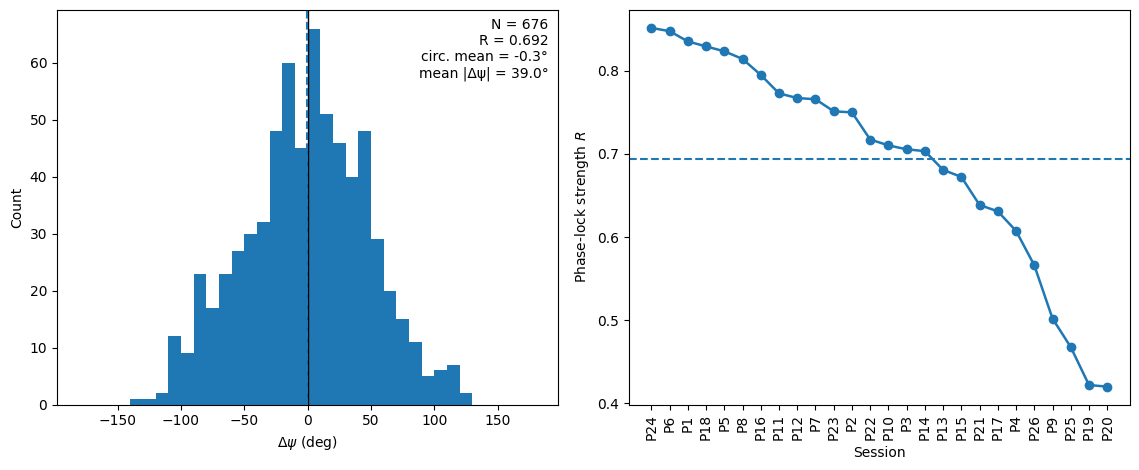


Saved:
IDPC_Reproduction/Chapter3/ricci_phase_sync_summary.csv
IDPC_Reproduction/Chapter3/Fig_ricci_phase_sync.png


In [14]:
# ============================================================
# Chapter 3 Figure 9 Script:
# 3.2 Dynamic Phase Synchronization of Ricci Curvature
# ------------------------------------------------------------
# Purpose:
# This script generates the quantitative summary and figure for
# Section 3.2 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to evaluate phase synchronization between the
# neural Ricci curvature series and the affine-aligned quantum
# Ricci curvature series across sessions.
#
# Specifically, the script:
#   - estimates an effective oscillation scale ω for each series
#   - constructs instantaneous Ricci phase ψ from (r, dr/dt)
#   - computes the phase difference:
#         Δψ = ψ_E - ψ_Q
#   - quantifies session-wise phase-lock strength:
#         R = | <exp(iΔψ)> |
#   - summarizes the pooled phase-difference distribution
#
# This corresponds to the empirical claim in Section 3.2 that:
#   - phase differences are concentrated near zero with finite spread
#   - session-wise phase-lock values remain consistently structured
#   - the systems exhibit partial phase alignment rather than
#     trivial perfect synchronization
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load Ricci time series
#    - Read per-session neural Ricci and affine quantum Ricci
#    - Restrict analysis to sessions with sufficient valid length
#
# 2. Estimate oscillation scale
#    - For each series, estimate ω from:
#          Δ²r ≈ -ω² r
#
# 3. Construct Ricci phase
#    - Define phase using the pair (r, dr/dt):
#          ψ = atan2((dr/dt)/ω, r)
#    - Wrap phase values into the principal interval
#
# 4. Compute phase difference
#    - For each session:
#          Δψ = ψ_E - ψ_Q
#    - Compute:
#          • phase-lock strength R
#          • circular mean of Δψ
#          • mean absolute phase difference
#
# 5. Aggregate across sessions
#    - Pool all valid Δψ samples
#    - Summarize global phase concentration statistics
#
# 6. Generate figure
#    - Panel A: pooled histogram of Δψ
#    - Panel B: session-wise phase-lock strength R
#
# ------------------------------------------------------------
# Key Principle:
#
# This analysis is not testing whether the two systems are
# perfectly identical in phase.
#
# Instead, it tests whether their phase relation is:
#   - structured,
#   - non-uniform,
#   - concentrated,
# while still allowing finite spread.
#
# Therefore, the expected outcome is not complete synchronization,
# but constrained phase alignment with measurable variability.
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RICCI_DIR = "IDPC_Reproduction_ricci"
OUTCSV = "IDPC_Reproduction/Chapter3/ricci_phase_sync_summary.csv"
OUTPNG = "IDPC_Reproduction/Chapter3/Fig_ricci_phase_sync.png"


os.makedirs("IDPC_Reproduction/Chapter3", exist_ok=True)

# =====================================================
# helpers
# =====================================================
def wrap_rad(x):
    return np.angle(np.exp(1j * np.asarray(x, float)))

def wrap_deg(x):
    x = np.asarray(x, float)
    return ((x + 180.0) % 360.0) - 180.0

def estimate_omega(r):
    r = np.asarray(r, float)
    d2 = np.diff(r, 2)
    r_mid = r[1:-1]
    m = np.isfinite(d2) & np.isfinite(r_mid) & (np.abs(r_mid) > 1e-12)
    if np.sum(m) < 5:
        return np.nan
    w2 = np.nanmean(-d2[m] / r_mid[m])
    return np.sqrt(abs(w2)) if np.isfinite(w2) else np.nan

def ricci_phase(r, omega):
    r = np.asarray(r, float)
    dr = np.diff(r, prepend=np.nan)
    psi = np.arctan2(dr / (omega + 1e-12), r)
    return wrap_rad(psi)

def circ_mean(x):
    return np.angle(np.mean(np.exp(1j * np.asarray(x, float))))

# =====================================================
# pooled Δψ and session-wise lock
# =====================================================
all_dpsi = []
rows = []

files = sorted([f for f in os.listdir(RICCI_DIR) if f.endswith("_timeseries.csv")])

for f in files:
    label = f.replace("_timeseries.csv", "")
    df = pd.read_csv(os.path.join(RICCI_DIR, f))

    if "E_Ricci" not in df.columns or "Q_Ricci_affine" not in df.columns:
        continue

    rE = pd.to_numeric(df["E_Ricci"], errors="coerce").to_numpy(float)
    rQ = pd.to_numeric(df["Q_Ricci_affine"], errors="coerce").to_numpy(float)

    n = min(len(rE), len(rQ))
    if n < 20:
        continue

    rE = rE[:n]
    rQ = rQ[:n]

    wE = estimate_omega(rE)
    wQ = estimate_omega(rQ)
    if not np.isfinite(wE) or not np.isfinite(wQ):
        continue

    psiE = ricci_phase(rE, wE)
    psiQ = ricci_phase(rQ, wQ)

    dpsi = wrap_rad(psiE - psiQ)
    m = np.isfinite(dpsi)
    dpsi = dpsi[m]

    if len(dpsi) < 10:
        continue

    R = np.abs(np.mean(np.exp(1j * dpsi)))
    mean_abs = np.mean(np.abs(dpsi))
    cmean = circ_mean(dpsi)

    all_dpsi.extend(dpsi.tolist())

    rows.append({
        "label": label,
        "n_points": len(dpsi),
        "psi_lock_R": float(R),
        "circ_mean_rad": float(cmean),
        "circ_mean_deg": float(np.degrees(cmean)),
        "mean_abs_dpsi_rad": float(mean_abs),
        "mean_abs_dpsi_deg": float(np.degrees(mean_abs)),
    })

res = pd.DataFrame(rows)
if len(res) == 0:
    raise ValueError("No valid phase data were created.")

res = res.sort_values("psi_lock_R", ascending=False).reset_index(drop=True)
res.to_csv(OUTCSV, index=False)

all_dpsi = np.asarray(all_dpsi, float)
all_dpsi_deg = np.degrees(all_dpsi)

pooled_R = np.abs(np.mean(np.exp(1j * all_dpsi)))
pooled_cmean = circ_mean(all_dpsi)
pooled_cmean_deg = np.degrees(pooled_cmean)
pooled_mean_abs_deg = np.degrees(np.mean(np.abs(all_dpsi)))

print("\n=== Ricci phase synchronization summary ===\n")
print(f"N pooled points = {len(all_dpsi)}")
print(f"pooled psi-lock R = {pooled_R:.4f}")
print(f"pooled circular mean (deg) = {pooled_cmean_deg:.3f}")
print(f"pooled mean |Δpsi| (deg) = {pooled_mean_abs_deg:.3f}")
print()
print(res.to_string(index=False))

# =====================================================
# figure
# =====================================================
fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.8))

# Panel A: pooled Δψ histogram
bins = np.linspace(-180, 180, 37)
axs[0].hist(all_dpsi_deg, bins=bins)
axs[0].axvline(0, color="black", linewidth=1)
axs[0].axvline(pooled_cmean_deg, linestyle="--", linewidth=1.5)

axs[0].set_xlabel(r"$\Delta \psi$ (deg)")
axs[0].set_ylabel("Count")

txt = (
    f"N = {len(all_dpsi)}\n"
    f"R = {pooled_R:.3f}\n"
    f"circ. mean = {pooled_cmean_deg:.1f}°\n"
    f"mean |Δψ| = {pooled_mean_abs_deg:.1f}°"
)
axs[0].text(
    0.98, 0.98, txt,
    transform=axs[0].transAxes,
    ha="right", va="top",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9)
)

# Panel B: session-wise ψ-lock
x = np.arange(len(res))
axs[1].plot(x, res["psi_lock_R"].values, marker="o", linewidth=1.8)
axs[1].axhline(res["psi_lock_R"].mean(), linestyle="--", linewidth=1.5)

axs[1].set_xticks(x)
axs[1].set_xticklabels(res["label"], rotation=90)
axs[1].set_xlabel("Session")
axs[1].set_ylabel(r"Phase-lock strength $R$")

plt.tight_layout()
plt.savefig(OUTPNG, dpi=300, bbox_inches="tight")
plt.show()

plt.close()

print("\nSaved:")
print(OUTCSV)
print(OUTPNG)


=== 72° restoring test ===

N pooled = 650
slope in Δeps = slope * eps : -0.9885
restore rate P(eps*Δeps < 0) = 0.7338

Binned drift:
         eps_bin   eps_mean  deps_mean  n
(-36.001, -30.0] -32.662890  29.484308 62
  (-30.0, -24.0] -27.013597  28.314444 68
  (-24.0, -18.0] -20.995389  17.435990 50
  (-18.0, -12.0] -15.134514  11.383853 70
   (-12.0, -6.0]  -9.230492   5.954469 48
     (-6.0, 0.0]  -3.149605  -1.943432 55
      (0.0, 6.0]   2.953648  -4.268844 58
     (6.0, 12.0]   8.855112 -15.030589 57
    (12.0, 18.0]  15.025142 -16.336660 48
    (18.0, 24.0]  20.946190 -24.616440 47
    (24.0, 30.0]  26.794527 -26.531114 52
    (30.0, 36.0]  33.011595 -36.264949 35


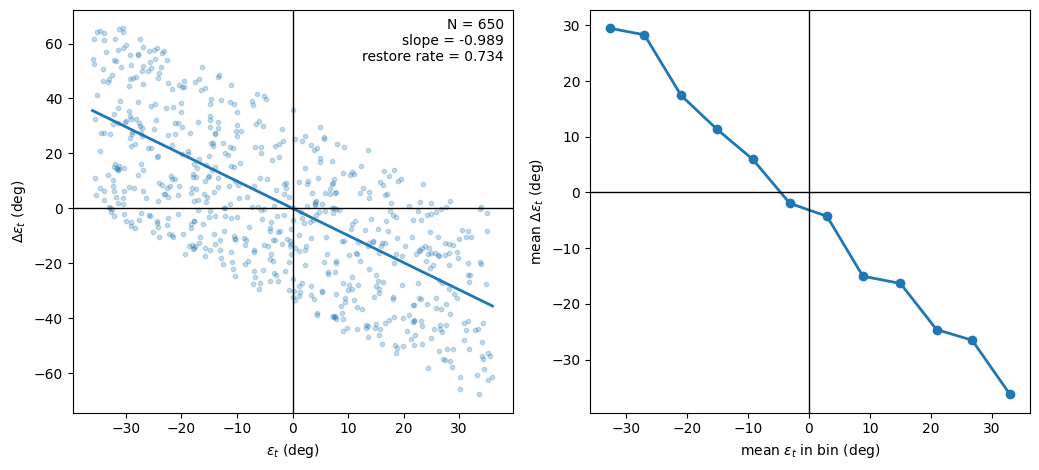


Saved:
IDPC_Reproduction/Chapter3/ricci_eps72_restoring_test.csv
IDPC_Reproduction/Chapter3/Fig_ricci_eps72_restoring_final.png


In [15]:
# ============================================================
# Chapter 3 Figure 10 Script:
# 3.3 Structural Phase Residual and Contraction
# ------------------------------------------------------------
# Purpose:
# This script generates the pooled verification and figure for
# Section 3.3 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to test whether the structural phase difference
# between neural and quantum Ricci dynamics contracts toward
# a 72-degree periodic lattice.
#
# Specifically, the script:
#   - computes Ricci phase for neural and affine quantum series
#   - defines the structural phase difference:
#         Δθ_t = θ_E(t) - θ_Q(t)
#   - converts this phase difference into a 72° lattice residual:
#         ε_t ∈ [-36°, 36°)
#   - evaluates whether the residual exhibits restoring dynamics:
#         Δε_t ≈ -λ ε_t
#
# This corresponds to the empirical claim in Section 3.3 that:
#   - structural phase differences do not drift freely
#   - instead they are pulled back toward a periodic attractor
#   - the observed relation is contractive rather than diffusive
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load Ricci time series
#    - Read per-session neural Ricci and affine quantum Ricci
#    - Keep only sessions with sufficient valid length
#
# 2. Estimate oscillation scale
#    - For each series, estimate ω from:
#          Δ²r ≈ -ω² r
#
# 3. Construct Ricci phase
#    - Define instantaneous phase from (r, dr/dt):
#          ψ = atan2((dr/dt)/ω, r)
#
# 4. Compute structural phase residual
#    - Compute phase difference between systems
#    - Convert the phase difference to degrees
#    - Fold it into the 72° periodic lattice residual:
#          ε_t = ((Δθ_t + 36°) mod 72°) - 36°
#
# 5. Compute restoring dynamics
#    - Compute one-step drift:
#          Δε_t = ε_{t+1} - ε_t
#    - Test whether Δε_t tends to have opposite sign to ε_t
#    - Quantify:
#          • regression slope in Δε_t vs ε_t
#          • restore rate P(ε_t · Δε_t < 0)
#
# 6. Build summary figure
#    - Panel A: pooled scatter of ε_t versus Δε_t
#    - Panel B: binned mean drift across ε_t bins
#
# ------------------------------------------------------------
# Key Principle:
#
# This analysis does not ask whether phase difference is small
# in an absolute sense at all times.
#
# Instead, it asks whether deviations from the nearest 72° family
# are dynamically restored.
#
# Therefore, the key signature is not zero residual alone, but
# negative drift with respect to the residual:
#     ε_t > 0  →  Δε_t < 0
#     ε_t < 0  →  Δε_t > 0
#
# A strong negative slope in Δε_t versus ε_t, together with a
# restore rate above chance, supports the interpretation that
# the phase relation is organized by a contractive periodic
# structure rather than random fluctuation.
#
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RICCI_DIR = "IDPC_Reproduction_ricci"
OUTCSV = "IDPC_Reproduction/Chapter3/ricci_eps72_restoring_test.csv"
OUTPNG = "IDPC_Reproduction/Chapter3/Fig_ricci_eps72_restoring_final.png"

os.makedirs("IDPC_Reproduction", exist_ok=True)

# =====================================================
# helpers
# =====================================================
def wrap_rad(x):
    return np.angle(np.exp(1j * np.asarray(x, float)))

def wrap_deg(x):
    x = np.asarray(x, float)
    return ((x + 180.0) % 360.0) - 180.0

def eps72_deg(theta_deg):
    """
    72° periodic lattice residual in [-36, 36)
    """
    theta_deg = wrap_deg(theta_deg)
    return ((theta_deg + 36.0) % 72.0) - 36.0

def estimate_omega(r):
    r = np.asarray(r, float)
    d2 = np.diff(r, 2)
    r_mid = r[1:-1]
    m = np.isfinite(d2) & np.isfinite(r_mid) & (np.abs(r_mid) > 1e-12)
    if np.sum(m) < 5:
        return np.nan
    w2 = np.nanmean(-d2[m] / r_mid[m])
    return np.sqrt(abs(w2)) if np.isfinite(w2) else np.nan

def ricci_phase(r, omega):
    r = np.asarray(r, float)
    dr = np.diff(r, prepend=np.nan)
    psi = np.arctan2(dr / (omega + 1e-12), r)
    return wrap_rad(psi)

# =====================================================
# pooled data build
# =====================================================
rows = []

files = sorted([f for f in os.listdir(RICCI_DIR) if f.endswith("_timeseries.csv")])

for f in files:
    label = f.replace("_timeseries.csv", "")
    df = pd.read_csv(os.path.join(RICCI_DIR, f))

    if "E_Ricci" not in df.columns or "Q_Ricci_affine" not in df.columns:
        continue

    rE = pd.to_numeric(df["E_Ricci"], errors="coerce").to_numpy(float)
    rQ = pd.to_numeric(df["Q_Ricci_affine"], errors="coerce").to_numpy(float)

    n = min(len(rE), len(rQ))
    if n < 20:
        continue

    rE = rE[:n]
    rQ = rQ[:n]

    wE = estimate_omega(rE)
    wQ = estimate_omega(rQ)
    if not np.isfinite(wE) or not np.isfinite(wQ):
        continue

    psiE = ricci_phase(rE, wE)
    psiQ = ricci_phase(rQ, wQ)

    # Ricci-transformed structural phase difference
    theta_deg = np.degrees(wrap_rad(psiE - psiQ))

    # 72° periodic residual
    eps = eps72_deg(theta_deg)

    eps_t = eps[:-1]
    deps = eps[1:] - eps[:-1]
    deps = wrap_deg(deps)

    m = np.isfinite(eps_t) & np.isfinite(deps)
    eps_t = eps_t[m]
    deps = deps[m]

    for e, d in zip(eps_t, deps):
        rows.append({
            "label": label,
            "eps72_deg": float(e),
            "deps72_deg": float(d),
            "restore": int(e * d < 0)
        })

dat = pd.DataFrame(rows)
dat.to_csv(OUTCSV, index=False)

if len(dat) == 0:
    raise ValueError("No valid pooled eps72 data were created.")

# =====================================================
# summary statistics
# =====================================================
x = dat["eps72_deg"].to_numpy(float)
y = dat["deps72_deg"].to_numpy(float)

slope = np.sum(x * y) / np.sum(x * x)
restore_rate = dat["restore"].mean()

# binned drift
bins = np.linspace(-36, 36, 13)
dat["eps_bin"] = pd.cut(dat["eps72_deg"], bins=bins, include_lowest=True)

b = dat.groupby("eps_bin", observed=False).agg(
    eps_mean=("eps72_deg", "mean"),
    deps_mean=("deps72_deg", "mean"),
    n=("deps72_deg", "size")
).reset_index()

print("\n=== 72° restoring test ===\n")
print(f"N pooled = {len(dat)}")
print(f"slope in Δeps = slope * eps : {slope:.4f}")
print(f"restore rate P(eps*Δeps < 0) = {restore_rate:.4f}")
print("\nBinned drift:")
print(b.to_string(index=False))

# =====================================================
# figure
# =====================================================
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.8))

# Panel A: pooled regression
axs[0].scatter(x, y, s=10, alpha=0.25)
xx = np.linspace(-36, 36, 200)
axs[0].plot(xx, slope * xx, linewidth=2)
axs[0].axhline(0, color="black", linewidth=1)
axs[0].axvline(0, color="black", linewidth=1)
axs[0].set_xlabel(r"$\varepsilon_t$ (deg)")
axs[0].set_ylabel(r"$\Delta \varepsilon_t$ (deg)")

txt = (
    f"N = {len(dat)}\n"
    f"slope = {slope:.3f}\n"
    f"restore rate = {restore_rate:.3f}"
)
axs[0].text(
    0.98, 0.98, txt,
    transform=axs[0].transAxes,
    ha="right", va="top",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9)
)

# Panel B: binned drift
axs[1].plot(b["eps_mean"], b["deps_mean"], marker="o", linewidth=2)
axs[1].axhline(0, color="black", linewidth=1)
axs[1].axvline(0, color="black", linewidth=1)
axs[1].set_xlabel(r"mean $\varepsilon_t$ in bin (deg)")
axs[1].set_ylabel(r"mean $\Delta \varepsilon_t$ (deg)")

plt.tight_layout()
plt.savefig(OUTPNG, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved:")
print(OUTCSV)
print(OUTPNG)

In [16]:
# ============================================================
# Chapter 3 Verification Script:
# 3.5 Significance of State Transitions
# ------------------------------------------------------------
# Purpose:
# This script performs the permutation-based significance test
# for the transition structure described in Section 3.5 of the
# paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to test whether the observed FES state-transition
# structure can be explained by random ordering of states within
# sessions, or whether it reflects a genuine structural constraint.
#
# Specifically, the script:
#   - constructs the observed transition-count matrix
#   - converts it to a row-normalized transition-probability matrix
#   - computes a global structure score measuring deviation from
#     a uniform transition model
#   - evaluates specific directed transitions of interest
#   - compares all observed values against a within-session
#     permutation null distribution
#
# This corresponds to the empirical claim in Section 3.5 that:
#   - the transition structure is not random
#   - the overall transition organization significantly exceeds
#     permutation null expectations
#   - certain directed transitions show elevated probabilities
#     relative to the null baseline
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load event-level FES phase data
#    - Read session label, task index, and assigned FES phase
#    - Remove rows with missing or invalid state information
#
# 2. Build observed transition structure
#    - For each session:
#         count transitions from state_t to state_{t+1}
#    - Aggregate counts across sessions
#    - Row-normalize to obtain transition probabilities
#
# 3. Compute observed scores
#    - Global structure score:
#         deviation from uniform row-wise transition probability
#    - Edge-specific scores for selected directed transitions
#
# 4. Generate permutation null
#    - Shuffle FES labels independently within each session
#    - Recompute transition matrix and scores
#    - Repeat for N_PERM permutations
#
# 5. Evaluate significance
#    - Compare observed global and edge-specific scores against
#      their null distributions
#    - Compute one-sided permutation p-values
#
# 6. Save outputs and figures
#    - Observed transition counts and probabilities
#    - Permutation result table
#    - Null histograms
#    - Observed transition heatmap
#
# ------------------------------------------------------------
# Key Principle:
#
# This analysis tests transition structure, not just state
# frequency.
#
# Even if the same set of states appears in each session, the
# question is whether their sequential ordering contains more
# structure than expected under random within-session rearrangement.
#
# Therefore, significance here means:
#   - the observed transition organization is stronger than would
#     be expected if state order were arbitrary
#   - the system exhibits directional and non-uniform transition
#     constraints rather than random state succession
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# CONFIG
# =========================================
INDIR = "IDPC_Reproduction"
CSV = os.path.join(INDIR, "event_level_with_fes_phase_TRUE_RICCI.csv")
OUTDIR = os.path.join(INDIR, "Chapter3/MarkovTest")
os.makedirs(OUTDIR, exist_ok=True)

N_PERM = 5000
SEED = 42

fes_order = ["Activation", "Challenge", "Surprise", "SelfGrowth", "CoCreation"]

# 注目遷移
target_edges = [
    ("Activation", "CoCreation"),
    ("Challenge", "Surprise"),
    ("Challenge", "CoCreation"),
    ("Surprise", "CoCreation"),
    ("CoCreation", "Surprise"),
    ("SelfGrowth", "Surprise"),
]

# =========================================
# HELPERS
# =========================================
def build_transition_counts(df, states):
    mat = pd.DataFrame(0, index=states, columns=states, dtype=float)

    for lab, g in df.groupby("label"):
        g = g.sort_values("task_idx")
        phases = g["fes_phase"].tolist()

        for i in range(len(phases) - 1):
            a = phases[i]
            b = phases[i + 1]
            if pd.isna(a) or pd.isna(b):
                continue
            if a not in states or b not in states:
                continue
            mat.loc[a, b] += 1
    return mat

def row_normalize(mat):
    out = mat.copy().astype(float)
    rs = out.sum(axis=1)
    for i in out.index:
        if rs.loc[i] > 0:
            out.loc[i, :] = out.loc[i, :] / rs.loc[i]
        else:
            out.loc[i, :] = np.nan
    return out

def structure_score_prob(mat_prob, uniform=0.2):
    vals = mat_prob.to_numpy(float)
    mask = np.isfinite(vals)
    return float(np.sum((vals[mask] - uniform)**2))

def edge_score(mat_prob, a, b):
    v = mat_prob.loc[a, b]
    return float(v) if np.isfinite(v) else np.nan

def permute_within_session(df, rng):
    pieces = []
    for lab, g in df.groupby("label"):
        g = g.sort_values("task_idx").copy()
        phases = g["fes_phase"].to_numpy(object)
        idx = np.arange(len(phases))
        rng.shuffle(idx)
        g["fes_phase"] = phases[idx]
        pieces.append(g)
    return pd.concat(pieces, axis=0).reset_index(drop=True)

def permutation_pvalue(obs, null):
    null = np.asarray(null, float)
    null = null[np.isfinite(null)]
    if len(null) == 0:
        return np.nan
    # 右片側
    return float((np.sum(null >= obs) + 1) / (len(null) + 1))

# =========================================
# LOAD
# =========================================
df = pd.read_csv(CSV)

if not {"label", "task_idx", "fes_phase"}.issubset(df.columns):
    raise KeyError(f"Need columns label, task_idx, fes_phase in {CSV}")

df = df.dropna(subset=["label", "task_idx", "fes_phase"]).copy()
df["task_idx"] = pd.to_numeric(df["task_idx"], errors="coerce")
df = df.dropna(subset=["task_idx"]).copy()
df["task_idx"] = df["task_idx"].astype(int)

# =========================================
# OBSERVED
# =========================================
obs_counts = build_transition_counts(df, fes_order)
obs_prob = row_normalize(obs_counts)
obs_structure = structure_score_prob(obs_prob, uniform=1/len(fes_order))

obs_edge_scores = {}
for a, b in target_edges:
    obs_edge_scores[f"{a}->{b}"] = edge_score(obs_prob, a, b)

obs_counts.to_csv(os.path.join(OUTDIR, "transition_counts_observed.csv"))
obs_prob.to_csv(os.path.join(OUTDIR, "transition_prob_observed.csv"))

print("\n=== OBSERVED TRANSITION COUNTS ===")
print(obs_counts)

print("\n=== OBSERVED TRANSITION PROBABILITY ===")
print(obs_prob)

print("\n=== OBSERVED STRUCTURE SCORE ===")
print(obs_structure)

print("\n=== OBSERVED TARGET EDGES ===")
for k, v in obs_edge_scores.items():
    print(k, "=", v)

# =========================================
# PERMUTATION
# =========================================
rng = np.random.default_rng(SEED)

null_structure = []
null_edges = {f"{a}->{b}": [] for a, b in target_edges}

for r in range(N_PERM):
    dfp = permute_within_session(df, rng)

    cnt = build_transition_counts(dfp, fes_order)
    prb = row_normalize(cnt)

    null_structure.append(structure_score_prob(prb, uniform=1/len(fes_order)))

    for a, b in target_edges:
        null_edges[f"{a}->{b}"].append(edge_score(prb, a, b))

    if (r + 1) % 500 == 0:
        print(f"perm {r+1}/{N_PERM}")

null_structure = np.asarray(null_structure, float)

# =========================================
# PVALUES
# =========================================
rows = []

rows.append({
    "metric": "structure_score",
    "observed": obs_structure,
    "null_mean": float(np.nanmean(null_structure)),
    "null_sd": float(np.nanstd(null_structure)),
    "null_q95": float(np.nanquantile(null_structure, 0.95)),
    "p_perm": permutation_pvalue(obs_structure, null_structure),
})

for k, obs in obs_edge_scores.items():
    arr = np.asarray(null_edges[k], float)
    rows.append({
        "metric": k,
        "observed": obs,
        "null_mean": float(np.nanmean(arr)),
        "null_sd": float(np.nanstd(arr)),
        "null_q95": float(np.nanquantile(arr, 0.95)),
        "p_perm": permutation_pvalue(obs, arr),
    })

res = pd.DataFrame(rows)
res.to_csv(os.path.join(OUTDIR, "permutation_results.csv"), index=False)

print("\n=== PERMUTATION RESULTS ===")
print(res.to_string(index=False))

# =========================================
# PLOTS
# =========================================
# 1) structure score histogram
plt.figure(figsize=(6,4))
plt.hist(null_structure, bins=40, alpha=0.8)
plt.axvline(obs_structure, linewidth=2)
plt.title("Permutation null: structure score")
plt.xlabel("structure score")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "perm_structure_score_hist.png"), dpi=220)
plt.close()

# 2) edge histograms
for k, obs in obs_edge_scores.items():
    arr = np.asarray(null_edges[k], float)
    arr = arr[np.isfinite(arr)]

    plt.figure(figsize=(6,4))
    plt.hist(arr, bins=40, alpha=0.8)
    plt.axvline(obs, linewidth=2)
    plt.title(f"Permutation null: {k}")
    plt.xlabel("transition probability")
    plt.ylabel("count")
    plt.tight_layout()
    safe_name = k.replace("->", "_to_")
    plt.savefig(os.path.join(OUTDIR, f"perm_{safe_name}_hist.png"), dpi=220)
    plt.close()

# 3) heatmap observed
plt.figure(figsize=(6,5))
plt.imshow(obs_prob.values, cmap="viridis")
plt.xticks(range(len(fes_order)), fes_order, rotation=45)
plt.yticks(range(len(fes_order)), fes_order)
plt.colorbar(label="transition probability")
plt.title("Observed transition matrix")

for i in range(len(fes_order)):
    for j in range(len(fes_order)):
        v = obs_prob.values[i, j]
        if np.isfinite(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "observed_transition_heatmap.png"), dpi=220)
plt.close()

print("\nSaved to:", OUTDIR)
print(" - transition_counts_observed.csv")
print(" - transition_prob_observed.csv")
print(" - permutation_results.csv")
print(" - perm_structure_score_hist.png")
print(" - observed_transition_heatmap.png")
for a, b in target_edges:
    print(" -", f"perm_{a}_to_{b}_hist.png")


=== OBSERVED TRANSITION COUNTS ===
            Activation  Challenge  Surprise  SelfGrowth  CoCreation
Activation         2.0        8.0      17.0        14.0         5.0
Challenge          9.0        0.0      10.0         4.0         5.0
Surprise          19.0       13.0       1.0        12.0        16.0
SelfGrowth         8.0        3.0      13.0         5.0         8.0
CoCreation         9.0        4.0      12.0         3.0         0.0

=== OBSERVED TRANSITION PROBABILITY ===
            Activation  Challenge  Surprise  SelfGrowth  CoCreation
Activation    0.043478   0.173913  0.369565    0.304348    0.108696
Challenge     0.321429   0.000000  0.357143    0.142857    0.178571
Surprise      0.311475   0.213115  0.016393    0.196721    0.262295
SelfGrowth    0.216216   0.081081  0.351351    0.135135    0.216216
CoCreation    0.321429   0.142857  0.428571    0.107143    0.000000

=== OBSERVED STRUCTURE SCORE ===
0.3671815977216726

=== OBSERVED TARGET EDGES ===
Activation->CoCreation 

n events: 226
enter: 114 exit: 112
alpha_hat: 4.350922700970082
R2: 0.7875328850344363


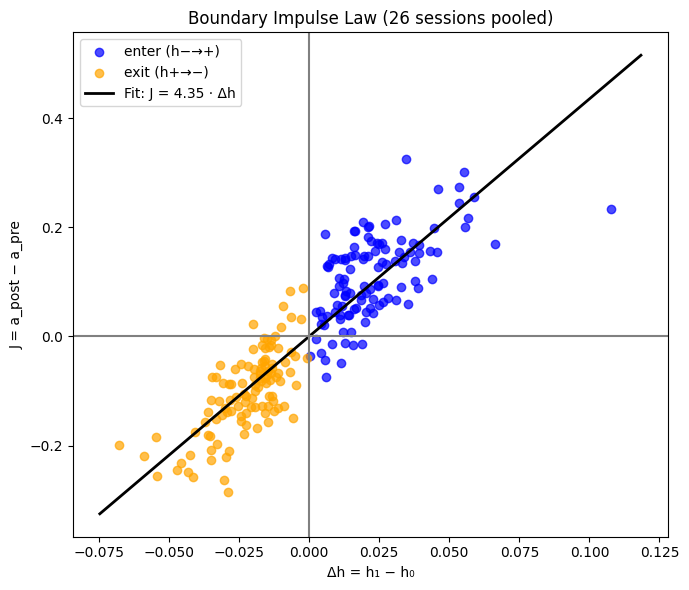

In [17]:
# ============================================================
# Chapter 3 Figure 11 Script:
# 3.6 Boundary Events and Boundary Impulse Law
# ------------------------------------------------------------
# Purpose:
# This script generates the pooled verification plot for
# Section 3.6 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to test whether boundary events obey a continuous
# quantitative law relating the boundary coordinate change Δh
# and the boundary impulse J.
#
# Specifically, the script:
#   - loads pooled boundary-event data across sessions
#   - separates entry and exit events by the sign of Δh
#   - fits the origin-through relation:
#         J ≈ α · Δh
#   - evaluates goodness of fit using R²
#   - visualizes both event classes together with the fitted law
#
# This corresponds to the empirical claim in Section 3.6 that:
#   - state transitions concentrate at boundary events
#   - boundary impulses are not arbitrary discrete triggers
#   - instead, they follow a continuous structural constraint
#     across both entry and exit events
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load pooled event data
#    - Read boundary-event table containing:
#         • dh : boundary coordinate change
#         • J  : boundary impulse
#
# 2. Separate entry and exit events
#    - Entry events:
#         Δh > 0
#    - Exit events:
#         Δh < 0
#
# 3. Fit boundary impulse law
#    - Estimate α in the origin-through model:
#         J = α · Δh
#    - Compute coefficient of determination R²
#
# 4. Generate Figure 11
#    - Scatter entry events
#    - Scatter exit events
#    - Overlay the fitted linear law
#    - Mark coordinate axes for reference
#
# ------------------------------------------------------------
# Key Principle:
#
# This analysis tests whether boundary events are governed by
# a continuous structural relation rather than by arbitrary,
# discrete, or purely stochastic transitions.
#
# If both entry and exit events follow the same linear law,
# then the impulse J should be interpreted not as an isolated
# trigger, but as the minimal observable expression of an
# underlying continuous boundary structure.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


OUTDIR = "IDPC_Reproduction/Figures"
os.makedirs(OUTDIR, exist_ok=True)

# ==========
# Load pooled event data
# ==========
df = pd.read_csv("IDPC_Reproduction/J_dh_kappa_pooled_v2.csv")

dh = df["dh"].to_numpy(float)
J  = df["J"].to_numpy(float)

print("n events:", len(dh))

# ==========
# enter / exit mask
# ==========
enter_mask = dh > 0
exit_mask  = dh < 0

print("enter:", np.sum(enter_mask),
      "exit:", np.sum(exit_mask))

# ==========
# Origin-through fit: J = alpha * dh
# ==========
alpha_hat = np.sum(J * dh) / np.sum(dh * dh)

# R²
J_pred = alpha_hat * dh
R2 = 1 - np.sum((J - J_pred)**2) / np.sum((J - np.mean(J))**2)

print("alpha_hat:", alpha_hat)
print("R2:", R2)

# ==========
# Plot
# ==========
plt.figure(figsize=(7,6))

# scatter
plt.scatter(dh[enter_mask], J[enter_mask],
            color="blue", alpha=0.7, label="enter (h−→+)")
plt.scatter(dh[exit_mask], J[exit_mask],
            color="orange", alpha=0.7, label="exit (h+→−)")

# theory line
x_line = np.linspace(dh.min()*1.1, dh.max()*1.1, 300)
plt.plot(x_line, alpha_hat * x_line,
         color="black", linewidth=2,
         label=f"Fit: J = {alpha_hat:.2f} · Δh")

plt.axhline(0, color="gray")
plt.axvline(0, color="gray")

plt.xlabel("Δh = h₁ − h₀")
plt.ylabel("J = a_post − a_pre")
plt.title("Boundary Impulse Law (26 sessions pooled)")
plt.legend()
plt.tight_layout()

plt.savefig("IDPC_Reproduction/Chapter3/IDPE_BI_boundary_impulse_pooled.png", dpi=300)
plt.show()

Training rows : 82
Point rows    : 174


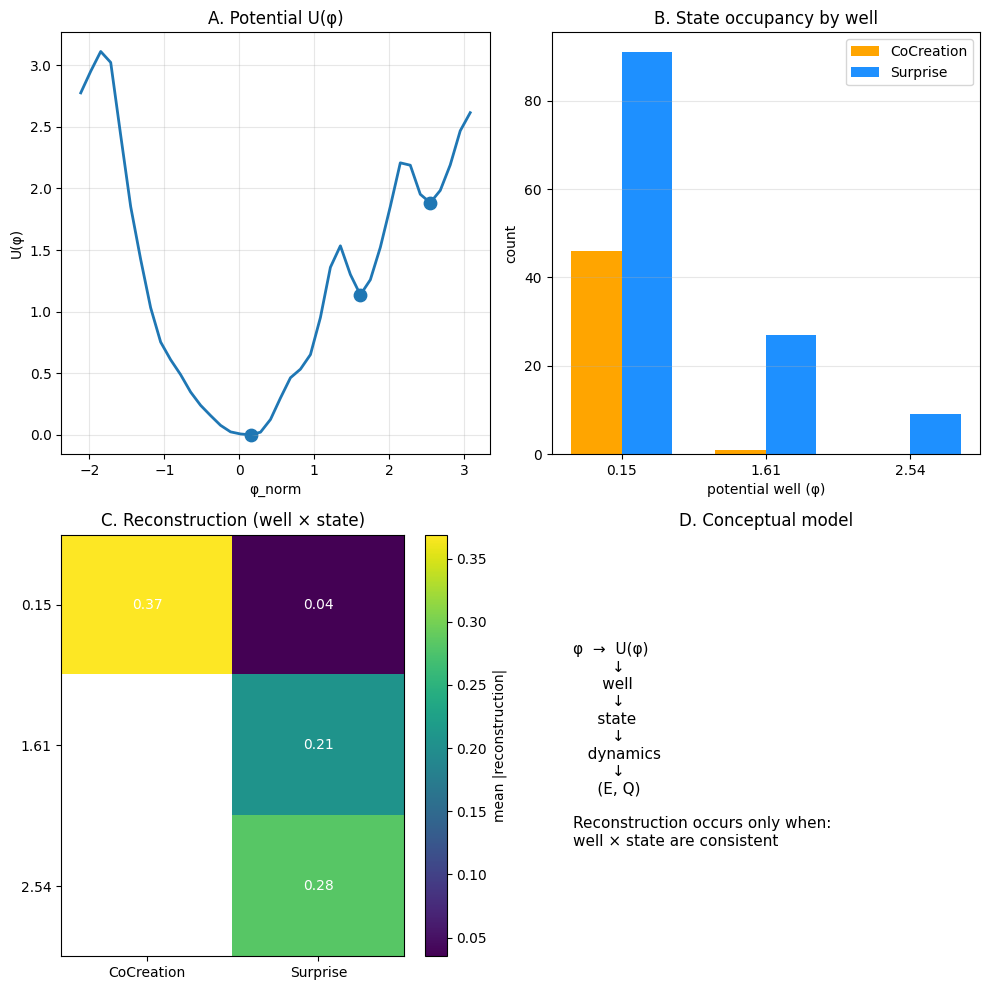

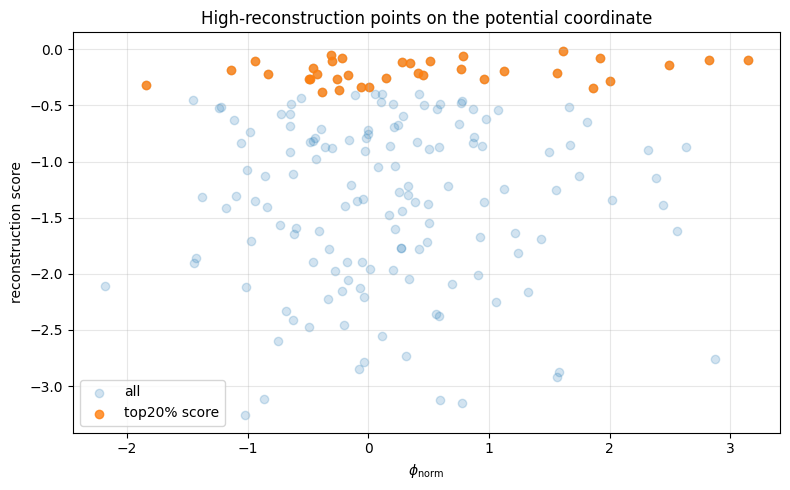

In [18]:
# ============================================================
# Chapter 5 Figure 12 and 13 Script:
# 5.4 Potential–State Correspondence and
# 5.5 Distribution of High-Reconstruction Regions
# ------------------------------------------------------------
# Purpose:
# This script generates Figures 12 and 13 for Chapter 5 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:0‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to demonstrate that:
#   - the intersection variable φ induces a multistable potential
#   - discrete states are not uniformly distributed, but are
#     constrained by potential wells
#   - reconstruction performance is not global, but selectively
#     realized under specific (well × state) conditions
#
# Figure 12:
#   A. Empirical potential U(φ)
#   B. State occupancy per potential well
#   C. Reconstruction performance (well × state)
#   D. Conceptual generative structure
#
# Figure 13:
#   Distribution of high-reconstruction points on the φ coordinate,
#   showing localization in specific potential regions
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load event-level data
#    - Includes φ, dφ, E, Q, and FES state labels
#    - Sort data by session and task index
#
# 2. Normalize intersection variables
#    - Compute φ_norm and dφ_norm per session
#    - Ensures scale consistency across sessions
#
# 3. Train state prediction model
#    - Predict next state from (φ_norm, dφ_norm)
#    - Restricted to:
#         • CoCreation
#         • Surprise
#
# 4. Train state-dependent dynamics
#    - For each state:
#         E(t+1) = f(E_t, E_t-1, ΔE_t)
#         Q(t+1) = f(Q_t, Q_t-1, ΔQ_t)
#
# 5. Construct point-level dataset
#    - For each time point:
#         • predicted state
#         • predicted next-step dynamics
#         • reconstruction error
#         • reconstruction score
#
# 6. Estimate empirical potential
#    - Compute histogram of φ_norm
#    - Smooth and normalize to obtain P(φ)
#    - Define:
#         U(φ) = -log P(φ)
#
# 7. Detect potential wells
#    - Identify local minima of U(φ)
#    - These define discrete regions in φ-space
#
# 8. Assign points to wells
#    - Each point is mapped to nearest well
#    - Enables well-wise structural analysis
#
# 9. Analyze structure
#    - Count state occupancy per well
#    - Compute reconstruction performance per (well × state)
#
# 10. Generate figures
#    - Figure 12:
#         A. Potential landscape
#         B. State occupancy
#         C. Reconstruction heatmap
#         D. Conceptual diagram
#    - Figure 13:
#         Scatter of reconstruction score vs φ
#         Highlight top-performing regions
#
# ------------------------------------------------------------
# Key Principle:
#
# This analysis shows that reconstruction is not a uniform property
# of the system.
#
# Instead:
#   - φ defines a structured potential landscape
#   - states are constrained by this landscape
#   - reconstruction emerges only when:
#         (potential well) × (state)
#     are structurally consistent
#
# Therefore, structural agreement between neural and quantum
# systems is:
#   → a selectively realized phenomenon
#   → governed by the generative structure of φ
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Configuration
# ----------------------------
INDIR = "IDPC_Reproduction"
EVENT_FILE = os.path.join(INDIR, "event_level_with_fes_phase_TRUE_RICCI.csv")

OUTDIR = os.path.join("IDPC_Reproduction", "Chapter5")
os.makedirs(OUTDIR, exist_ok=True)


N_BINS = 40
SMOOTH_SIGMA = 1.2
EPS = 1e-8
MIN_GROUP_N = 5

# ----------------------------
# Load event-level data
# ----------------------------
df = pd.read_csv(EVENT_FILE)
df = df.sort_values(["label", "task_idx"]).reset_index(drop=True)

required_cols = ["label", "task_idx", "phi", "dphi", "E", "Q", "fes_phase"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

for c in ["phi", "dphi", "E", "Q"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# Session-wise normalization
# phi_norm = phi / session_std(phi)
# dphi_norm = dphi / session_std(dphi)
# ----------------------------
norm_parts = []

for label, g in df.groupby("label"):
    g = g.sort_values("task_idx").reset_index(drop=True).copy()

    phi_std = np.nanstd(g["phi"].values)
    dphi_std = np.nanstd(g["dphi"].values)

    if not np.isfinite(phi_std) or phi_std < 1e-12:
        phi_std = 1.0
    if not np.isfinite(dphi_std) or dphi_std < 1e-12:
        dphi_std = 1.0

    g["phi_norm"] = g["phi"] / phi_std
    g["dphi_norm"] = g["dphi"] / dphi_std
    norm_parts.append(g)

df = pd.concat(norm_parts, ignore_index=True)
df = df.sort_values(["label", "task_idx"]).reset_index(drop=True)

# ----------------------------
# Build training rows
# The next state is restricted to:
#   - CoCreation
#   - Surprise
# ----------------------------
rows = []

for label, g in df.groupby("label"):
    g = g.sort_values("task_idx").reset_index(drop=True)

    for i in range(1, len(g) - 1):
        next_state = g.loc[i + 1, "fes_phase"]
        if next_state not in ["CoCreation", "Surprise"]:
            continue

        vals = [
            g.loc[i, "phi_norm"], g.loc[i, "dphi_norm"],
            g.loc[i, "E"], g.loc[i, "Q"],
            g.loc[i - 1, "E"], g.loc[i - 1, "Q"],
            g.loc[i + 1, "E"], g.loc[i + 1, "Q"]
        ]
        if not np.all(np.isfinite(vals)):
            continue

        E_t = g.loc[i, "E"]
        Q_t = g.loc[i, "Q"]
        E_tm1 = g.loc[i - 1, "E"]
        Q_tm1 = g.loc[i - 1, "Q"]

        rows.append({
            "label": label,
            "task_idx_t": g.loc[i, "task_idx"],
            "phi_norm_t": g.loc[i, "phi_norm"],
            "dphi_norm_t": g.loc[i, "dphi_norm"],
            "E_t": E_t,
            "Q_t": Q_t,
            "E_tm1": E_tm1,
            "Q_tm1": Q_tm1,
            "dE_t": E_t - E_tm1,
            "dQ_t": Q_t - Q_tm1,
            "E_next": g.loc[i + 1, "E"],
            "Q_next": g.loc[i + 1, "Q"],
            "state_next": next_state,
            "y_state": 1 if next_state == "Surprise" else 0
        })

train = pd.DataFrame(rows).dropna().reset_index(drop=True)
if len(train) == 0:
    raise ValueError("No valid training rows were created.")

# ----------------------------
# Train state classifier
# State is predicted from (phi_norm, dphi_norm)
# ----------------------------
X_state = train[["phi_norm_t", "dphi_norm_t"]].values
y_state = train["y_state"].values

state_scaler = StandardScaler()
X_state_scaled = state_scaler.fit_transform(X_state)

state_clf = LogisticRegression(max_iter=1000)
state_clf.fit(X_state_scaled, y_state)

# ----------------------------
# Train state-specific dynamics
# AR2 + delta model for E and Q
# ----------------------------
dyn_models = {}

for state_name in ["CoCreation", "Surprise"]:
    sub = train[train["state_next"] == state_name].copy()
    if len(sub) < MIN_GROUP_N:
        raise ValueError(f"Too few samples for dynamics model: {state_name}")

    XE = sub[["E_t", "E_tm1", "dE_t"]].values
    yE = sub["E_next"].values
    XQ = sub[["Q_t", "Q_tm1", "dQ_t"]].values
    yQ = sub["Q_next"].values

    dyn_models[state_name] = {
        "E_model": LinearRegression().fit(XE, yE),
        "Q_model": LinearRegression().fit(XQ, yQ)
    }

# ----------------------------
# Build point-level table for figure generation
# Each point includes:
#   - phi_norm
#   - predicted state
#   - next-step prediction errors
#   - reconstruction score
# ----------------------------
points = []

for label, g in df.groupby("label"):
    g = g.sort_values("task_idx").reset_index(drop=True)

    for i in range(1, len(g) - 1):
        vals = [
            g.loc[i, "phi_norm"], g.loc[i, "dphi_norm"],
            g.loc[i, "E"], g.loc[i, "Q"],
            g.loc[i - 1, "E"], g.loc[i - 1, "Q"],
            g.loc[i + 1, "E"], g.loc[i + 1, "Q"]
        ]
        if not np.all(np.isfinite(vals)):
            continue

        x_state = np.array([[g.loc[i, "phi_norm"], g.loc[i, "dphi_norm"]]])
        x_state_scaled = state_scaler.transform(x_state)
        p_surprise = state_clf.predict_proba(x_state_scaled)[0, 1]
        state_pred = "Surprise" if p_surprise >= 0.5 else "CoCreation"

        E_t = g.loc[i, "E"]
        Q_t = g.loc[i, "Q"]
        E_tm1 = g.loc[i - 1, "E"]
        Q_tm1 = g.loc[i - 1, "Q"]
        dE_t = E_t - E_tm1
        dQ_t = Q_t - Q_tm1

        E_hat = dyn_models[state_pred]["E_model"].predict(np.array([[E_t, E_tm1, dE_t]]))[0]
        Q_hat = dyn_models[state_pred]["Q_model"].predict(np.array([[Q_t, Q_tm1, dQ_t]]))[0]

        E_true_next = g.loc[i + 1, "E"]
        Q_true_next = g.loc[i + 1, "Q"]

        err_E = abs(E_hat - E_true_next)
        err_Q = abs(Q_hat - Q_true_next)
        score = -(err_E + err_Q)

        points.append({
            "label": label,
            "task_idx": g.loc[i, "task_idx"],
            "phi_norm": g.loc[i, "phi_norm"],
            "dphi_norm": g.loc[i, "dphi_norm"],
            "state_pred": state_pred,
            "p_surprise": p_surprise,
            "E_true_next": E_true_next,
            "Q_true_next": Q_true_next,
            "E_pred_next": E_hat,
            "Q_pred_next": Q_hat,
            "score": score
        })

points_df = pd.DataFrame(points).dropna().reset_index(drop=True)
if len(points_df) == 0:
    raise ValueError("No valid point rows were created.")

print("Training rows :", len(train))
print("Point rows    :", len(points_df))



# ----------------------------
# Estimate empirical potential U(phi)
# U(phi) = -log P(phi)
# ----------------------------
phi_vals = points_df["phi_norm"].values
hist, edges = np.histogram(phi_vals, bins=N_BINS, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

hist_smooth = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
prob = hist_smooth / np.sum(hist_smooth)
U = -np.log(prob + EPS)
U = U - np.min(U)

potential_df = pd.DataFrame({
    "phi_center": centers,
    "P_phi": prob,
    "U_phi": U
})
potential_df.to_csv(os.path.join(OUTDIR, "empirical_potential.csv"), index=False)

# ----------------------------
# Detect local minima as potential wells
# ----------------------------
well_idx = [
    i for i in range(1, len(U) - 1)
    if U[i] < U[i - 1] and U[i] < U[i + 1]
]

well_df = pd.DataFrame({
    "phi_well": centers[well_idx],
    "U_well": U[well_idx]
})
well_df.to_csv(os.path.join(OUTDIR, "potential_wells.csv"), index=False)

if len(well_df) == 0:
    raise ValueError("No potential wells were detected. Try adjusting N_BINS or SMOOTH_SIGMA.")

# ----------------------------
# Assign each point to the nearest well
# ----------------------------
phi_wells = well_df["phi_well"].values

assign_rows = []
for _, row in points_df.iterrows():
    phi = row["phi_norm"]
    nearest_idx = np.argmin(np.abs(phi_wells - phi))
    nearest_well = phi_wells[nearest_idx]

    assign_rows.append({
        "label": row["label"],
        "phi_norm": phi,
        "nearest_well": nearest_well,
        "state": row["state_pred"],
        "E_true": row["E_true_next"],
        "Q_true": row["Q_true_next"],
        "E_pred": row["E_pred_next"],
        "Q_pred": row["Q_pred_next"],
        "score": row["score"]
    })

assign_df = pd.DataFrame(assign_rows)

# ----------------------------
# Count occupancy by well and state
# ----------------------------
count_pivot = (
    assign_df.groupby(["nearest_well", "state"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

for col in ["CoCreation", "Surprise"]:
    if col not in count_pivot.columns:
        count_pivot[col] = 0
count_pivot = count_pivot[["CoCreation", "Surprise"]]

count_pivot_reset = count_pivot.reset_index()
count_pivot_reset.to_csv(os.path.join(OUTDIR, "well_state_counts.csv"), index=False)

# ----------------------------
# Compute reconstruction score by well x state
# Score = mean(|r_E|, |r_Q|)
# ----------------------------
heat_rows = []

for w in sorted(phi_wells):
    for st in ["CoCreation", "Surprise"]:
        sub = assign_df[
            (assign_df["nearest_well"] == w) &
            (assign_df["state"] == st)
        ].copy()

        if len(sub) < MIN_GROUP_N:
            continue
        if sub["E_true"].nunique() < 2 or sub["E_pred"].nunique() < 2:
            continue
        if sub["Q_true"].nunique() < 2 or sub["Q_pred"].nunique() < 2:
            continue

        rE = np.corrcoef(sub["E_true"], sub["E_pred"])[0, 1]
        rQ = np.corrcoef(sub["Q_true"], sub["Q_pred"])[0, 1]
        score = (abs(rE) + abs(rQ)) / 2

        if np.isfinite(score):
            heat_rows.append({
                "phi_well": w,
                "state": st,
                "score": score,
                "n": len(sub),
                "rE": rE,
                "rQ": rQ
            })

heat_df = pd.DataFrame(heat_rows)
heat_df.to_csv(os.path.join(OUTDIR, "well_state_reconstruction.csv"), index=False)

pivot = (
    heat_df.pivot(index="phi_well", columns="state", values="score")
    .sort_index()
)

for col in ["CoCreation", "Surprise"]:
    if col not in pivot.columns:
        pivot[col] = np.nan
pivot = pivot[["CoCreation", "Surprise"]]

# ----------------------------
# Figure 1: four-panel structural summary
# ----------------------------
fig = plt.figure(figsize=(10, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(centers, U, linewidth=2)
ax1.scatter(well_df["phi_well"], well_df["U_well"], s=80)
ax1.set_title("A. Potential U(φ)")
ax1.set_xlabel("φ_norm")
ax1.set_ylabel("U(φ)")
ax1.grid(alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
labels = [f"{v:.2f}" for v in count_pivot.index]
x = np.arange(len(labels))
width = 0.35

co = count_pivot["CoCreation"].values
su = count_pivot["Surprise"].values

ax2.bar(x - width / 2, co, width, label="CoCreation", color="#FFA500")
ax2.bar(x + width / 2, su, width, label="Surprise", color="#1E90FF")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("B. State occupancy by well")
ax2.set_xlabel("potential well (φ)")
ax2.set_ylabel("count")
ax2.legend()
ax2.grid(alpha=0.3, axis="y")

ax3 = plt.subplot(2, 2, 3)
im = ax3.imshow(pivot.values, cmap="viridis", aspect="auto")
ax3.set_xticks(range(len(pivot.columns)))
ax3.set_xticklabels(pivot.columns)
ax3.set_yticks(range(len(pivot.index)))
ax3.set_yticklabels([f"{v:.2f}" for v in pivot.index])
ax3.set_title("C. Reconstruction (well × state)")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if np.isfinite(val):
            ax3.text(j, i, f"{val:.2f}", ha="center", va="center", color="white")

plt.colorbar(im, ax=ax3, label="mean |reconstruction|")

ax4 = plt.subplot(2, 2, 4)
ax4.axis("off")
concept_text = """
φ  →  U(φ)
        ↓
      well
        ↓
     state
        ↓
   dynamics
        ↓
     (E, Q)

Reconstruction occurs only when:
well × state are consistent
"""
ax4.text(0.05, 0.5, concept_text, fontsize=11, verticalalignment="center")
ax4.set_title("D. Conceptual model")

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Figure11_final_structure.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
# ----------------------------
# Figure 2: high-reconstruction scatter
# ----------------------------
score_q = points_df["score"].quantile(0.80)
good_df = points_df[points_df["score"] >= score_q].copy()

plt.figure(figsize=(8, 5))
plt.scatter(points_df["phi_norm"], points_df["score"], alpha=0.2, label="all")
plt.scatter(good_df["phi_norm"], good_df["score"], alpha=0.8, label="top20% score")
plt.xlabel(r"$\phi_{\mathrm{norm}}$")
plt.ylabel("reconstruction score")
plt.title("High-reconstruction points on the potential coordinate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Figure12_high_score_points.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [19]:
# ============================================================
# Chapter 7 Data Preparation Script:
# Construction of the Candidate φ Dataset for Intersection-Structure Analysis
# ------------------------------------------------------------
# Purpose:
# This script prepares the base dataset used in the subsequent
# Chapter 7 analyses, including:
#   - train/test search for the best intersection variable
#   - evaluation against neural-only / quantum-only baselines
#   - permutation and temporal-shift tests
#   - Figure 14 generation
#
# The script constructs a session-wise candidate φ dataset from
# point-level structural variables derived from the *_points.csv
# files.
#
# In particular, it builds:
#   - h      : boundary-related coordinate
#   - a      : amplitude-like variable
#   - eps    : 72° periodic residual derived from h
#   - dpsi   : local phase-gradient surrogate from h
#   - phi_latent : PCA-based latent coordinate
#   - phi_clean  : rank-Gaussianized φ coordinate
#   - dphi, d2phi, dh, da, deps, ddpsi : first/second differences
#
# This dataset serves as the common input space from which
# multiple candidate intersection models are later constructed
# and compared.
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load point-level session files
#    - Read all *_points.csv files
#    - Keep only rows with valid structural observations
#
# 2. Extract core structural variables
#    - h : structural coordinate
#    - a : amplitude variable
#    - eps : 72° periodic residual from h
#    - dpsi : local gradient of h
#
# 3. Build pooled latent space
#    - Standardize h, a, eps, and dpsi
#    - Apply PCA to obtain a one-dimensional latent coordinate
#    - This produces phi_latent
#
# 4. Gaussianize the latent coordinate
#    - Apply rank-based Gaussianization
#    - This produces phi_clean, a normalized candidate φ axis
#
# 5. Compute local difference variables
#    - Per session, compute:
#         • dphi
#         • d2phi
#         • dh
#         • da
#         • deps
#         • ddpsi
#
# 6. Save the assembled dataset
#    - Export the full session-wise candidate dataset as:
#         new_phi_dataset.csv
#
# ------------------------------------------------------------
# Key Principle:
#
# This script does not yet select the best intersection model.
# Instead, it constructs a common candidate feature space from
# which later analyses can test different definitions of φ.
#
# Therefore, this stage should be understood as:
#   - structural feature preparation
#   - latent coordinate construction
#   - derivative-feature generation
# rather than final model evaluation.
#
# The resulting dataset provides the empirical basis for testing
# whether localized switching structure emerges specifically on
# an intersection-defined phase space.
#
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

BASE_DIR = "IDPC_Reproduction"
POINT_DIR = BASE_DIR
OUT_DIR = os.path.join(BASE_DIR, "Chapter7")
os.makedirs(OUT_DIR, exist_ok=True)

files = sorted(glob.glob(os.path.join(POINT_DIR, "*_points.csv")))

def safe_z(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd == 0:
        sd = 1.0
    return (x - mu) / sd

def periodic_residual_deg(x, period=72.0, half=36.0):
    x = np.asarray(x, float)
    return ((x + half) % period) - half

def rank_gaussian(x):
    from statistics import NormalDist
    x = np.asarray(x, float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 3:
        return out
    ranks = pd.Series(x[m]).rank().to_numpy() / (m.sum() + 1.0)
    nd = NormalDist()
    out[m] = [nd.inv_cdf(v) for v in ranks]
    return out

rows = []

for fp in files:
    label = os.path.basename(fp).replace("_points.csv", "")
    df = pd.read_csv(fp)

    need = ["h", "a", "valid"]
    if not all(c in df.columns for c in need):
        continue

    h = pd.to_numeric(df["h"], errors="coerce").to_numpy(float)
    a = pd.to_numeric(df["a"], errors="coerce").to_numpy(float)
    v = pd.to_numeric(df["valid"], errors="coerce").to_numpy(float) == 1

    m = np.isfinite(h) & np.isfinite(a) & v
    if np.sum(m) < 50:
        continue

    h = h[m]
    a = a[m]
    eps = periodic_residual_deg(h, period=72.0, half=36.0)
    dpsi = np.gradient(h)

    for i in range(len(h)):
        rows.append({
            "label": label,
            "idx_in_session": i,
            "h": h[i],
            "a": a[i],
            "eps": eps[i],
            "dpsi": dpsi[i]
        })

dat = pd.DataFrame(rows).sort_values(["label", "idx_in_session"]).reset_index(drop=True)

X = dat[["h", "a", "eps", "dpsi"]].to_numpy(float)
X = np.column_stack([safe_z(X[:, i]) for i in range(X.shape[1])])

phi_latent = PCA(n_components=1).fit_transform(X).flatten()
dat["phi_latent"] = phi_latent
dat["phi_clean"] = rank_gaussian(phi_latent)

dat["dphi"] = dat.groupby("label")["phi_clean"].diff()
dat["d2phi"] = dat.groupby("label")["phi_clean"].diff().diff()
dat["dh"] = dat.groupby("label")["h"].diff()
dat["da"] = dat.groupby("label")["a"].diff()
dat["deps"] = dat.groupby("label")["eps"].diff()
dat["ddpsi"] = dat.groupby("label")["dpsi"].diff()

out_csv = os.path.join(OUT_DIR, "new_phi_dataset.csv")
dat.to_csv(out_csv, index=False)

print("POINT_DIR =", POINT_DIR)
print("n_files =", len(files))
print("constructed rows =", len(dat))
print("n_sessions =", dat["label"].nunique())
print("Saved:", out_csv)

POINT_DIR = IDPC_Reproduction
n_files = 26
constructed rows = 10868
n_sessions = 26
Saved: IDPC_Reproduction/Chapter7/new_phi_dataset.csv


In [20]:
# ============================================================
# Chapter 7 Analysis Script:
# Search, Fix, and Evaluate the Best Intersection Model
# for Observed Intersection Structure (Data Preparation for Figure 14)
# ------------------------------------------------------------
# Purpose:
# This script prepares the quantitative results and point-level data
# used for the Chapter 7 analysis of observed intersection structure,
# corresponding to the figure later summarized as Figure 14 in the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"  [oai_citation:1‡Intersection_Defined_Phase_Coordinates_Reveal_Localized_Selection_and_a_Non_Closed_Observational_Structure-2.pdf](sediment://file_0000000035b0720bbaa688f92dfff37e)
#
# The goal is to identify, on the training split only, the best
# intersection-variable construction that most strongly exceeds the
# quantum-only baseline, and then evaluate that fixed model on the
# independent test split.
#
# The script also compares the selected best model against:
#   - neural-only model
#   - quantum-only model
#   - simple mean model
# and further tests whether the observed switching structure:
#   - survives comparison with single-system baselines
#   - collapses under temporal misalignment
#   - exceeds a block-permuted null distribution
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load candidate feature dataset
#    - Read the session-wise φ-related dataset
#    - Split sessions into fixed train and test subsets
#
# 2. Fix the reference state space on the training split
#    - Construct a reference φ using fixed columns/mode
#    - Standardize (φ, dφ)
#    - Fit a 5-cluster KMeans state geometry
#
# 3. Define candidate intersection-variable models
#    - Search across:
#         • feature subsets
#         • construction modes (PCA / mean / weighted)
#
# 4. Score each candidate on the training split
#    - Build candidate φ and dφ per session
#    - Evaluate switching sharpness relative to the fixed reference geometry
#    - Use the objective:
#         candidate − quantum_only
#      so that model search is explicitly anchored to beating
#      the quantum-only baseline
#
# 5. Select the single best model from training only
#    - Rank candidates by mean train advantage over quantum-only
#    - Fix the best candidate before any test evaluation
#
# 6. Evaluate the fixed best model on the independent test split
#    - Compute session-wise metrics:
#         • switch_gain
#         • deltaC_gain
#         • sharp_mean
#    - Compare against:
#         • neural-only
#         • quantum-only
#         • simple mean
#
# 7. Test robustness of the observed structure
#    - Paired session-wise comparison against other models
#    - Block permutation test on deps
#    - Temporal shift test
#
# 8. Save outputs for downstream figure generation
#    - Point-level scored data for the best model
#    - Session-wise model summary
#    - Permutation results
#    - Temporal shift results
#    - Final claim table
#
# ------------------------------------------------------------
# Key Principle:
#
# This script enforces a strict evaluation logic:
#   - model search is performed on train only
#   - the best model is fixed before test evaluation
#   - test performance is compared against single-system baselines
#   - null and temporal-disruption tests are applied afterward
#
# Therefore, the observed intersection structure is not presented
# as a post hoc optimized pattern, but as a fixed and testable
# structure that:
#   → exceeds baseline models
#   → weakens under temporal disruption
#   → remains distinguishable from permutation nulls
#
# ============================================================



import os
import numpy as np
import pandas as pd
from itertools import combinations
from statistics import NormalDist

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import binomtest

# =========================================
# CONFIG
# =========================================
BASE_DIR = "IDPC_Reproduction"
IN_CSV = os.path.join(BASE_DIR, "Chapter7", "new_phi_dataset.csv")
OUT_DIR = os.path.join(BASE_DIR, "Chapter7")
os.makedirs(OUT_DIR, exist_ok=True)

SESSION_COL = "label"
INDEX_COL = "idx_in_session"


REF_COLS = ["h", "dh", "da", "deps"]
REF_MODE = "pca"

NEURAL_ONLY_COLS = ["h", "dh", "da"]
NEURAL_ONLY_MODE = "pca"

QUANTUM_ONLY_COLS = ["deps", "dpsi"]
QUANTUM_ONLY_MODE = "pca"

SIMPLE_MEAN_COLS = ["h", "dh", "da", "deps"]
SIMPLE_MEAN_MODE = "mean"

SEARCH_COLS = ["h", "a", "dh", "da", "deps", "dpsi"]
SEARCH_K_LIST = [2, 3, 4]
SEARCH_MODE_LIST = ["pca", "mean", "weighted"]

N_PERM = 200
BLOCK = 12
SHIFT_LIST = [0, 2, 5, 10, 20]


KMEANS_RANDOM_STATE = 0
KMEANS_N_INIT = 20


# =========================================
# LOAD
# =========================================
df = pd.read_csv(IN_CSV)
df = df.sort_values([SESSION_COL, INDEX_COL]).reset_index(drop=True)

print("shape:", df.shape)
print("columns:", df.columns.tolist())

labels = sorted(df[SESSION_COL].unique())
train_labels = labels[:13]
test_labels = labels[13:]

df_train = df[df[SESSION_COL].isin(train_labels)].copy()
df_test = df[df[SESSION_COL].isin(test_labels)].copy()

print("train sessions:", len(train_labels))
print("test sessions :", len(test_labels))


# =========================================
# HELPERS
# =========================================
def zscore(X):
    X = np.asarray(X, float)
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd[sd == 0] = 1.0
    return (X - mu) / sd


def gaussianize(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 3:
        return out
    ranks = pd.Series(x[m]).rank(method="average").to_numpy() / (m.sum() + 1.0)
    nd = NormalDist()
    out[m] = np.array([nd.inv_cdf(v) for v in ranks], dtype=float)
    return out


def build_phi_candidate(sub, cols, mode):
    cols = list(cols)
    X = sub[cols].to_numpy(float)
    good = np.all(np.isfinite(X), axis=1)

    if good.sum() < 50:
        return None

    X = X[good]
    idx = sub.loc[good, INDEX_COL].to_numpy()

    Xz = zscore(X)

    if mode == "pca":
        phi_raw = PCA(n_components=1, svd_solver="full").fit_transform(Xz).ravel()
    elif mode == "mean":
        phi_raw = Xz.mean(axis=1)
    elif mode == "weighted":
        w = np.linspace(1.0, 2.0, Xz.shape[1])
        phi_raw = (Xz * w).sum(axis=1)
    else:
        raise ValueError(f"unknown mode: {mode}")

    phi = gaussianize(phi_raw)

    out = pd.DataFrame({
        INDEX_COL: idx,
        "phi": phi
    }).sort_values(INDEX_COL).reset_index(drop=True)

    out["dphi"] = np.gradient(out["phi"].to_numpy(float))
    return out


def mark_switch_neighborhood(winner, radius=2):
    winner = np.asarray(winner)
    out = np.zeros(len(winner), dtype=int)
    sw = np.where(np.diff(winner) != 0)[0] + 1
    for s in sw:
        lo = max(0, s - radius)
        hi = min(len(winner), s + radius + 1)
        out[lo:hi] = 1
    return out


def build_deltaC(phi):
    phi = np.asarray(phi, float)
    centers = np.quantile(phi, np.linspace(0.1, 0.9, 5))
    sigma = np.std(phi) * 0.6
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = 1.0

    out = []
    for v in phi:
        C = -((v - centers) ** 2) / (2 * sigma ** 2)
        s = np.sort(C)
        out.append(s[-1] - s[-2])
    return np.array(out, dtype=float)


def score_model_details(phi_df, centers_z, scaler):
    X = phi_df[["phi", "dphi"]].to_numpy(float)
    Xz = scaler.transform(X)

    rows = []
    for i in range(len(X)):
        d2 = np.sum((Xz[i] - centers_z) ** 2, axis=1)
        s = -d2
        o = np.argsort(s)[::-1]

        rows.append({
            "winner": int(o[0]),
            "sharp": float(s[o[0]] - s[o[1]]),
            "phi": float(X[i, 0]),
            "dphi": float(X[i, 1]),
        })

    d = pd.DataFrame(rows)
    d["near"] = mark_switch_neighborhood(d["winner"].to_numpy(), radius=2)
    d["deltaC"] = build_deltaC(d["phi"].to_numpy(float))

    sw = d[d["near"] == 1]
    non = d[d["near"] == 0]

    switch_gain = np.nan
    if len(sw) > 0 and len(non) > 0:
        switch_gain = float(sw["sharp"].mean() - non["sharp"].mean())

    deltaC_gain = np.nan
    if len(sw) > 0 and len(non) > 0:
        deltaC_gain = float(sw["deltaC"].mean() - non["deltaC"].mean())

    return {
        "switch_gain": switch_gain,
        "deltaC_gain": deltaC_gain,
        "sharp_mean": float(d["sharp"].mean()),
        "n_total": int(len(d)),
        "n_switch_near": int((d["near"] == 1).sum()),
    }, d


def evaluate_model_on_split(df_split, cols, mode, centers_z, scaler):
    rows = []
    scored_parts = []

    for label, sub in df_split.groupby(SESSION_COL):
        phi_df = build_phi_candidate(sub, cols, mode)
        if phi_df is None:
            continue

        metrics, scored = score_model_details(phi_df, centers_z, scaler)
        row = {"label": label, **metrics}
        rows.append(row)

        scored = scored.copy()
        scored["label"] = label
        scored_parts.append(scored)

    met_df = pd.DataFrame(rows)
    scored_df = pd.concat(scored_parts, ignore_index=True) if scored_parts else pd.DataFrame()
    return met_df, scored_df


def sign_test_p(diff_series):
    x = pd.Series(diff_series).dropna()
    pos = int((x > 0).sum())
    n = int((x != 0).sum())
    if n == 0:
        return np.nan
    return float(binomtest(pos, n=n, p=0.5, alternative="greater").pvalue)


def block_permute(arr, block=12, rng=None):
    arr = np.asarray(arr)
    n = len(arr)
    if rng is None:
        rng = np.random.default_rng(0)

    blocks = [arr[i:i+block] for i in range(0, n, block)]
    order = rng.permutation(len(blocks))
    out = np.concatenate([blocks[i] for i in order])
    return out[:n]


def deps_block_permuted_df(df_source, block=12, seed=0):
    rng = np.random.default_rng(seed)
    out_parts = []

    for _, sub in df_source.groupby(SESSION_COL):
        tmp = sub.copy()
        tmp["deps"] = block_permute(tmp["deps"].to_numpy(), block=block, rng=rng)
        out_parts.append(tmp)

    return pd.concat(out_parts, ignore_index=True)


def emp_p_ge(null_vals, obs):
    null_vals = np.asarray(null_vals, float)
    return float((np.sum(null_vals >= obs) + 1) / (len(null_vals) + 1))


# =========================================
# FIXED REFERENCE FROM TRAIN
# =========================================
train_ref_parts = []
for _, sub in df_train.groupby(SESSION_COL):
    p = build_phi_candidate(sub, REF_COLS, REF_MODE)
    if p is not None:
        train_ref_parts.append(p)

train_ref_phi = pd.concat(train_ref_parts, ignore_index=True)

X_ref = train_ref_phi[["phi", "dphi"]].to_numpy(float)
scaler = StandardScaler().fit(X_ref)
Xz_ref = scaler.transform(X_ref)

kmeans = KMeans(
    n_clusters=5,
    n_init=KMEANS_N_INIT,
    random_state=KMEANS_RANDOM_STATE
).fit(Xz_ref)
centers_z = kmeans.cluster_centers_


# =========================================
# FIX QUANTUM-ONLY BASELINE ON TRAIN
# =========================================
quantum_train_df, _ = evaluate_model_on_split(
    df_train, QUANTUM_ONLY_COLS, QUANTUM_ONLY_MODE, centers_z, scaler
)
quantum_train_map = dict(zip(quantum_train_df["label"], quantum_train_df["switch_gain"]))


# =========================================
# SEARCH ON TRAIN ONLY
# objective:
# =========================================
search_rows = []

for k in SEARCH_K_LIST:
    for cols in combinations(SEARCH_COLS, k):
        for mode in SEARCH_MODE_LIST:
            cand_train_df, _ = evaluate_model_on_split(
                df_train, cols, mode, centers_z, scaler
            )

            if cand_train_df.empty:
                continue

            merged = cand_train_df[["label", "switch_gain"]].merge(
                quantum_train_df[["label", "switch_gain"]],
                on="label",
                suffixes=("_cand", "_q")
            )

            if merged.empty:
                continue

            d = merged["switch_gain_cand"] - merged["switch_gain_q"]

            mean_adv = float(d.mean())
            median_adv = float(d.median())
            p_adv = sign_test_p(d)

            search_rows.append({
                "cols": str(tuple(cols)),
                "mode": mode,
                "mean_adv_vs_quantum_train": mean_adv,
                "median_adv_vs_quantum_train": median_adv,
                "sign_test_p_vs_quantum_train": p_adv,
                "cand_train_mean_switch_gain": float(merged["switch_gain_cand"].mean()),
                "quantum_train_mean_switch_gain": float(merged["switch_gain_q"].mean()),
                "n_sessions": int(len(merged)),
            })

search_df = pd.DataFrame(search_rows)

search_df = search_df.sort_values(
    [
        "mean_adv_vs_quantum_train",
        "median_adv_vs_quantum_train",
        "sign_test_p_vs_quantum_train",
        "cand_train_mean_switch_gain",
    ],
    ascending=[False, False, True, False]
).reset_index(drop=True)

print("\n=== TRUE SEARCH RESULT (TRAIN ONLY, objective = beat quantum_only) ===\n")
print(search_df.head(20).to_string(index=False))

search_df.to_csv(os.path.join(OUT_DIR, "true_search_train_only_vs_quantum.csv"), index=False)

best_search_row = search_df.iloc[0].copy()
BEST_TRUE_COLS = list(eval(best_search_row["cols"]))
BEST_TRUE_MODE = str(best_search_row["mode"])

print("\n=== SELECTED TRUE BEST ===\n")
print("BEST_TRUE_COLS =", BEST_TRUE_COLS)
print("BEST_TRUE_MODE =", BEST_TRUE_MODE)
print("TRAIN mean_adv_vs_quantum =", float(best_search_row["mean_adv_vs_quantum_train"]))
print("TRAIN sign_test_p_vs_quantum =", float(best_search_row["sign_test_p_vs_quantum_train"]))


# =========================================
# EVALUATE FIXED BEST ON TEST ONLY
# =========================================
best_test_df, best_scored_test = evaluate_model_on_split(
    df_test, BEST_TRUE_COLS, BEST_TRUE_MODE, centers_z, scaler
)
best_test_df["model"] = "best_true_search"

neural_test_df, _ = evaluate_model_on_split(
    df_test, NEURAL_ONLY_COLS, NEURAL_ONLY_MODE, centers_z, scaler
)
neural_test_df["model"] = "neural_only_pca"

quantum_test_df, _ = evaluate_model_on_split(
    df_test, QUANTUM_ONLY_COLS, QUANTUM_ONLY_MODE, centers_z, scaler
)
quantum_test_df["model"] = "quantum_only_pca"

simple_test_df, _ = evaluate_model_on_split(
    df_test, SIMPLE_MEAN_COLS, SIMPLE_MEAN_MODE, centers_z, scaler
)
simple_test_df["model"] = "simple_mean_best"

all_test_metrics = pd.concat(
    [best_test_df, neural_test_df, quantum_test_df, simple_test_df],
    ignore_index=True
)

print("\n=== SESSION-WISE TEST METRICS ===\n")
print(all_test_metrics.to_string(index=False))

test_summary = (
    all_test_metrics.groupby("model")[["switch_gain", "deltaC_gain", "sharp_mean"]]
    .agg(["mean", "std", "min", "max"])
)
print("\n=== TEST SUMMARY ===\n")
print(test_summary.to_string())


# =========================================
# PAIRED DIFFERENCES ON TEST
# =========================================
paired_rows = []
for label in sorted(all_test_metrics["label"].unique()):
    row_best = all_test_metrics[
        (all_test_metrics["label"] == label) &
        (all_test_metrics["model"] == "best_true_search")
    ].iloc[0]

    for other in ["neural_only_pca", "quantum_only_pca", "simple_mean_best"]:
        row_o = all_test_metrics[
            (all_test_metrics["label"] == label) &
            (all_test_metrics["model"] == other)
        ].iloc[0]

        paired_rows.append({
            "label": label,
            "comparison": f"best_minus_{other}",
            "d_switch_gain": float(row_best["switch_gain"] - row_o["switch_gain"]),
            "d_deltaC_gain": float(row_best["deltaC_gain"] - row_o["deltaC_gain"]),
        })

paired_df = pd.DataFrame(paired_rows)

print("\n=== PAIRED DIFFERENCES VS BEST ===\n")
print(
    paired_df.groupby("comparison")[["d_switch_gain", "d_deltaC_gain"]]
    .agg(["mean", "std", "min", "max"])
    .to_string()
)

print("\n=== SIGN-TEST P VALUES (best > other) ===")
for comp, sub in paired_df.groupby("comparison"):
    print(comp)
    print("  switch_gain p =", sign_test_p(sub["d_switch_gain"]))
    print("  deltaC_gain p =", sign_test_p(sub["d_deltaC_gain"]))


# =========================================
# BLOCK PERMUTATION TEST ON TEST
# =========================================
perm_rows = []

for i in range(N_PERM):
    df_perm = deps_block_permuted_df(df_test, block=BLOCK, seed=i)
    met_perm, _ = evaluate_model_on_split(
        df_perm, BEST_TRUE_COLS, BEST_TRUE_MODE, centers_z, scaler
    )

    perm_rows.append({
        "iter": i,
        "switch_gain": float(met_perm["switch_gain"].mean()),
        "deltaC_gain": float(met_perm["deltaC_gain"].mean()),
    })

perm_df = pd.DataFrame(perm_rows)

obs_best_switch = float(best_test_df["switch_gain"].mean())
obs_best_deltaC = float(best_test_df["deltaC_gain"].mean())

perm_p_switch = emp_p_ge(perm_df["switch_gain"], obs_best_switch)
perm_p_deltaC = emp_p_ge(perm_df["deltaC_gain"], obs_best_deltaC)

print("\n=== BLOCK PERMUTATION SUMMARY ===\n")
print(perm_df.describe().to_string())

print("\n=== EMPIRICAL PERMUTATION P VALUES ===")
print("switch_gain p =", perm_p_switch)
print("deltaC_gain p =", perm_p_deltaC)


# =========================================
# TEMPORAL SHIFT TEST ON TEST
# =========================================
shift_rows = []

for shift in SHIFT_LIST:
    parts = []

    for _, sub in df_test.groupby(SESSION_COL):
        tmp = sub.copy()
        if shift != 0:
            tmp["deps"] = tmp["deps"].shift(shift)
        parts.append(tmp)

    df_shift = pd.concat(parts, ignore_index=True)
    met_shift, _ = evaluate_model_on_split(
        df_shift, BEST_TRUE_COLS, BEST_TRUE_MODE, centers_z, scaler
    )

    shift_rows.append({
        "shift": shift,
        "switch_gain": float(met_shift["switch_gain"].mean()),
        "deltaC_gain": float(met_shift["deltaC_gain"].mean()),
    })

shift_df = pd.DataFrame(shift_rows)

print("\n=== TEMPORAL SHIFT TEST ===\n")
print(shift_df.to_string(index=False))


# =========================================
# FINAL CLAIM TABLE
# =========================================
mean_best = float(best_test_df["switch_gain"].mean())
mean_neural = float(neural_test_df["switch_gain"].mean())
mean_quantum = float(quantum_test_df["switch_gain"].mean())
mean_simple = float(simple_test_df["switch_gain"].mean())

p_best_vs_neural = sign_test_p(
    paired_df.loc[paired_df["comparison"] == "best_minus_neural_only_pca", "d_switch_gain"]
)
p_best_vs_quantum = sign_test_p(
    paired_df.loc[paired_df["comparison"] == "best_minus_quantum_only_pca", "d_switch_gain"]
)
p_best_vs_simple = sign_test_p(
    paired_df.loc[paired_df["comparison"] == "best_minus_simple_mean_best", "d_switch_gain"]
)

final_claim_table = pd.DataFrame([
    {
        "claim": "Best exceeds neural-only on switch_gain",
        "evidence": (
            f"best_true_search cols={BEST_TRUE_COLS}, mode={BEST_TRUE_MODE}; "
            f"best switch_gain={mean_best:.6f}, neural-only={mean_neural:.6f}; "
            f"paired sign-test p={p_best_vs_neural:.6f}"
        )
    },
    {
        "claim": "Best compared with quantum-only on switch_gain",
        "evidence": (
            f"best_true_search cols={BEST_TRUE_COLS}, mode={BEST_TRUE_MODE}; "
            f"best switch_gain={mean_best:.6f}, quantum-only={mean_quantum:.6f}; "
            f"paired sign-test p={p_best_vs_quantum:.6f}"
        )
    },
    {
        "claim": "Best exceeds simple mean on switch_gain",
        "evidence": (
            f"best_true_search cols={BEST_TRUE_COLS}, mode={BEST_TRUE_MODE}; "
            f"best switch_gain={mean_best:.6f}, simple-mean={mean_simple:.6f}; "
            f"paired sign-test p={p_best_vs_simple:.6f}"
        )
    },
    {
        "claim": "Best exceeds block-permuted null on switch_gain",
        "evidence": (
            f"best_true_search cols={BEST_TRUE_COLS}, mode={BEST_TRUE_MODE}; "
            f"obs switch_gain={obs_best_switch:.6f}, null mean={perm_df['switch_gain'].mean():.6f}, "
            f"empirical p={perm_p_switch:.6f}"
        )
    },
    {
        "claim": "Best degrades under temporal misalignment",
        "evidence": (
            f"best_true_search cols={BEST_TRUE_COLS}, mode={BEST_TRUE_MODE}; "
            f"shift0={shift_df.loc[shift_df['shift']==0, 'switch_gain'].iloc[0]:.6f}, "
            f"shift20={shift_df.loc[shift_df['shift']==20, 'switch_gain'].iloc[0]:.6f}"
        )
    }
])

print("\n=== FINAL CLAIM TABLE ===\n")
print(final_claim_table.to_string(index=False))


# =========================================
# SAVE
# =========================================
best_scored_test.to_csv(os.path.join(OUT_DIR, "best_true_search_scored_points.csv"), index=False)
all_test_metrics.to_csv(os.path.join(OUT_DIR, "session_wise_metrics_all_models.csv"), index=False)
paired_df.to_csv(os.path.join(OUT_DIR, "paired_differences_vs_best.csv"), index=False)
perm_df.to_csv(os.path.join(OUT_DIR, "block_permutation_test.csv"), index=False)
shift_df.to_csv(os.path.join(OUT_DIR, "temporal_shift_test.csv"), index=False)
final_claim_table.to_csv(os.path.join(OUT_DIR, "final_claim_table.csv"), index=False)

print("\nSaved:")
print(os.path.join(OUT_DIR, "true_search_train_only_vs_quantum.csv"))
print(os.path.join(OUT_DIR, "best_true_search_scored_points.csv"))
print(os.path.join(OUT_DIR, "session_wise_metrics_all_models.csv"))
print(os.path.join(OUT_DIR, "paired_differences_vs_best.csv"))
print(os.path.join(OUT_DIR, "block_permutation_test.csv"))
print(os.path.join(OUT_DIR, "temporal_shift_test.csv"))
print(os.path.join(OUT_DIR, "final_claim_table.csv"))

shape: (10868, 14)
columns: ['label', 'idx_in_session', 'h', 'a', 'eps', 'dpsi', 'phi_latent', 'phi_clean', 'dphi', 'd2phi', 'dh', 'da', 'deps', 'ddpsi']
train sessions: 13
test sessions : 13

=== TRUE SEARCH RESULT (TRAIN ONLY, objective = beat quantum_only) ===

                        cols     mode  mean_adv_vs_quantum_train  median_adv_vs_quantum_train  sign_test_p_vs_quantum_train  cand_train_mean_switch_gain  quantum_train_mean_switch_gain  n_sessions
         ('h', 'dh', 'deps')      pca                   0.105574                     0.108106                      0.011230                     0.727477                        0.621903          13
         ('h', 'dh', 'deps') weighted                   0.103585                     0.081714                      0.046143                     0.725488                        0.621903          13
              ('dh', 'deps')      pca                   0.101543                     0.119294                      0.011230                     

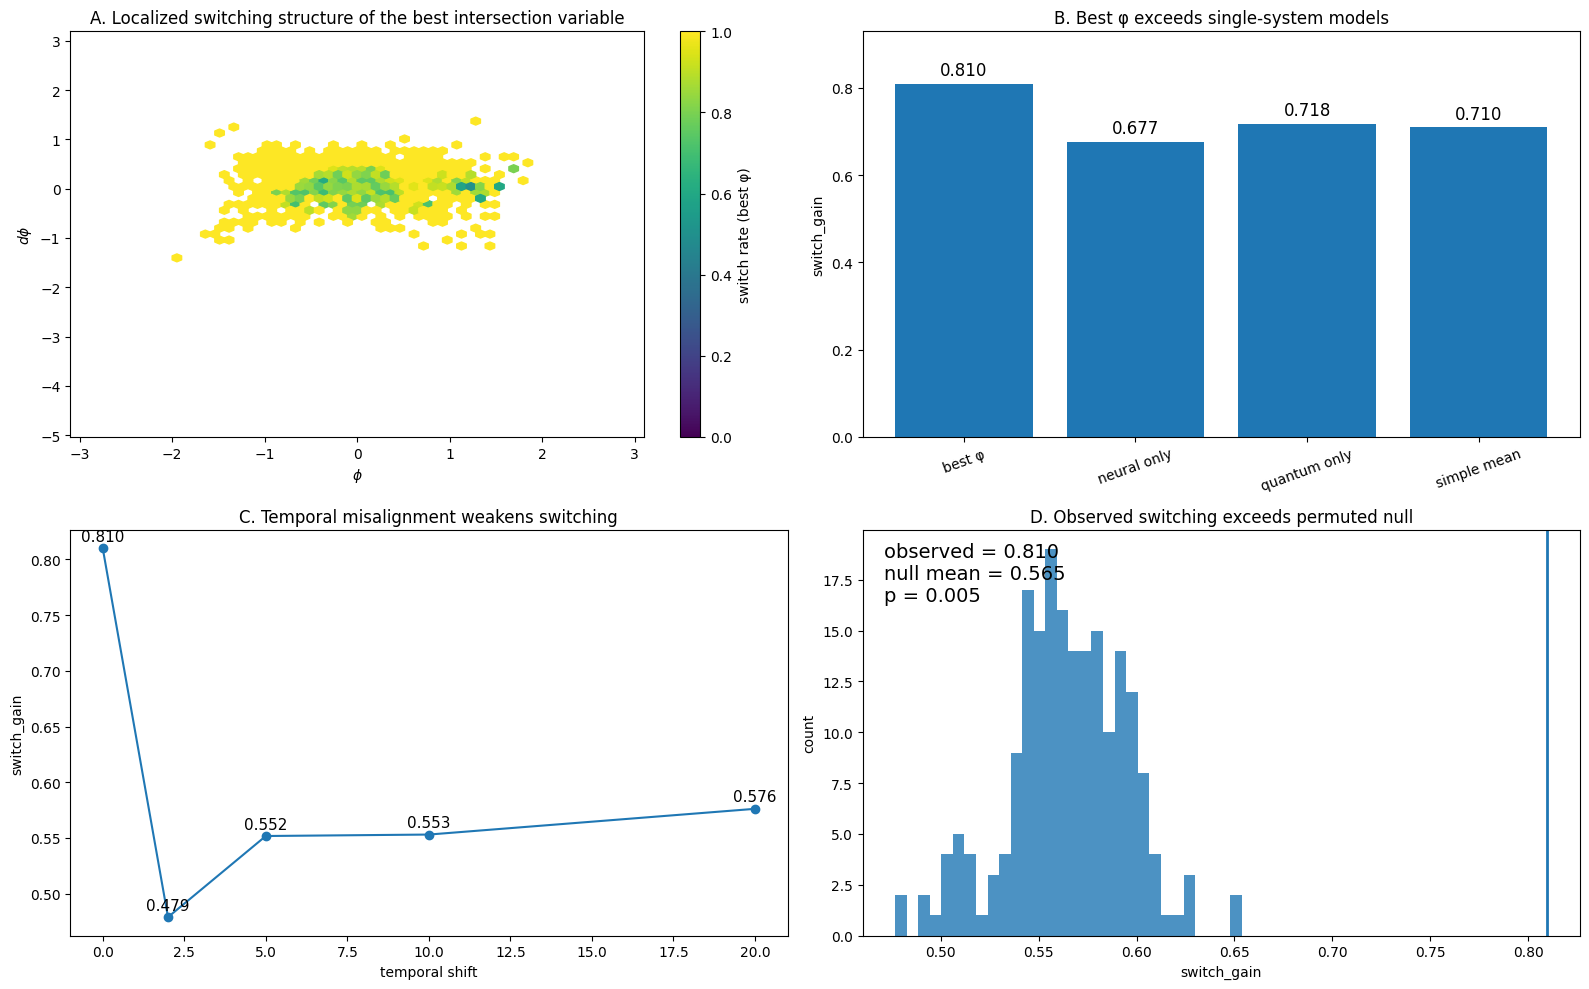

Saved: IDPC_Reproduction/Chapter7/Chapter7_Fig_Observed_Intersection_Structure.png


In [21]:
# ============================================================
# Chapter 7 Figure Script:
# Figure 14 — Observed Intersection Structure
# ------------------------------------------------------------
# Purpose:
# This script generates Figure 14 for Chapter 7 of the paper:
# "Intersection-Defined Phase Coordinates Reveal Localized Selection
#  and a Non-Closed Observational Structure"
#
# The figure visualizes the empirical structure of the best
# intersection variable selected in the separate train-only search.
#
# Within the framework of the paper, the observed structure is
# interpreted as an empirical trace of O3:
# a residual signature of a non-internal observational constraint
# that manifests on the intersection-defined phase space.
#
# Importantly, O3 is not introduced here as a directly observable
# entity, but as an operational construct inferred from:
#   - structured cross-system agreement
#   - its dependence on temporal alignment
#   - its degradation under controlled perturbations
#
# Reproducibility note:
# Before running the Chapter 7.2 analysis and reproducing Figure 14,
# the notebook may also use the following preparatory control cell:
#
#   SECTION 1.4 (ALTERNATIVE)
#   Chapter 7.2 / Mismatched pairing control (derangement)
#   Fake co-reconstruction feature generation
#
# That cell provides an alternative feature-generation pathway for
# mismatched-pairing control, allowing the Chapter 7.2 analysis to be
# reproduced under deliberately broken cross-session correspondence.
#
# Because this control is generated via random derangement,
# the exact numerical results may vary across runs (unless the
# random seed is fixed). Accordingly, the control condition is
# interpreted in terms of expected degradation of structure,
# rather than exact reproducibility of identical values for
# each random mismatch realization.
#
# In this way, the present figure should be interpreted together with
# both the true pairing pipeline and its derangement-based control.
#
# Figure 14 summarizes four core results:
#   A. localized switching structure on the (φ, dφ) phase space
#   B. superiority of the best intersection model over
#      single-system baselines
#   C. weakening of the structure under temporal misalignment
#   D. separation from a block-permuted null distribution
#
# ------------------------------------------------------------
# Processing Overview:
#
# 1. Load precomputed outputs
#    - Best-model scored point data
#    - Session-wise model metrics
#    - Temporal shift test results
#    - Block permutation test results
#
# 2. Build Panel A
#    - Use the best-model point cloud (φ, dφ)
#    - Estimate local switching rate on phase space
#    - Visualize localized switching using hexbin aggregation
#
# 3. Build Panel B
#    - Compute mean switch_gain by model
#    - Compare:
#         • best φ
#         • neural only
#         • quantum only
#         • simple mean
#
# 4. Build Panel C
#    - Plot switch_gain as a function of temporal shift
#    - Show degradation under increasing misalignment
#
# 5. Build Panel D
#    - Plot permutation null histogram
#    - Mark observed switch_gain of the best model
#    - Annotate null mean and empirical p-value
#
# ------------------------------------------------------------
# Key Principle:
#
# This figure is designed to show that the intersection structure
# is not merely descriptive, but empirically constrained.
#
# The intended interpretation is:
#   - switching is spatially localized on the intersection phase space
#   - the best intersection model outperforms single-system models
#   - the structure depends on temporal organization
#   - the observed effect exceeds permutation-based null expectation
#
# Taken together, these properties define an empirical trace of O3:
# a reproducible structural signature that cannot be reduced to
# either system independently, nor to simple statistical artifacts.
#
# Therefore, Figure 14 supports the claim that the intersection
# phase space reflects a non-trivial organizational constraint
# consistent with the presence of a non-internal observational
# structure.
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PATH
# =========================================================
BASE_DIR = "IDPC_Reproduction"
FIG_DIR = os.path.join(BASE_DIR, "Chapter7")

BEST_SCATTER = os.path.join(FIG_DIR, "best_true_search_scored_points.csv")
MODEL_SUMMARY = os.path.join(FIG_DIR, "session_wise_metrics_all_models.csv")
SHIFT_CSV = os.path.join(FIG_DIR, "temporal_shift_test.csv")
PERM_CSV = os.path.join(FIG_DIR, "block_permutation_test.csv")

OUT_PNG = os.path.join(FIG_DIR, "Chapter7_Fig_Observed_Intersection_Structure.png")

# =========================================================
# LOAD
# =========================================================
best_scored = pd.read_csv(BEST_SCATTER)
model_metrics = pd.read_csv(MODEL_SUMMARY)
shift_df = pd.read_csv(SHIFT_CSV)
perm_df = pd.read_csv(PERM_CSV)

# =========================================================
# PANEL B DATA
# =========================================================
model_order = [
    "best_true_search",
    "neural_only_pca",
    "quantum_only_pca",
    "simple_mean_best",
]

label_map = {
    "best_true_search": "best φ",
    "neural_only_pca": "neural only",
    "quantum_only_pca": "quantum only",
    "simple_mean_best": "simple mean",
}

bar_vals = (
    model_metrics.groupby("model", sort=False)["switch_gain"]
    .mean()
    .reindex(model_order)
)

# =========================================================
# PANEL C DATA
# =========================================================
shift_df = shift_df.sort_values("shift").reset_index(drop=True)

# =========================================================
# PANEL D DATA
# =========================================================
observed_switch_gain = float(bar_vals.loc["best_true_search"])
null_mean = float(perm_df["switch_gain"].mean())
perm_p = float((np.sum(perm_df["switch_gain"].to_numpy() >= observed_switch_gain) + 1) / (len(perm_df) + 1))

# =========================================================
# PLOT
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------
# A. Localized switching structure
# -------------------------
ax = axes[0, 0]

x = best_scored["phi"].to_numpy(float)
y = best_scored["dphi"].to_numpy(float)
z = best_scored["near"].to_numpy(float)

hb = ax.hexbin(
    x,
    y,
    C=z,
    reduce_C_function=np.mean,
    gridsize=55,
    mincnt=5,
    vmin=0.0,
    vmax=1.0
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("switch rate (best φ)")

ax.set_title("A. Localized switching structure of the best intersection variable")
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$d\phi$")

# -------------------------
# B. Bar chart
# -------------------------
ax = axes[0, 1]

x_labels = [label_map[m] for m in model_order]
y_vals = [float(bar_vals.loc[m]) for m in model_order]

bars = ax.bar(x_labels, y_vals)

for bar, val in zip(bars, y_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

ax.set_ylabel("switch_gain")
ax.set_title("B. Best φ exceeds single-system models")
ax.set_ylim(0, max(y_vals) + 0.12)
ax.tick_params(axis="x", rotation=20)

# -------------------------
# C. Temporal shift
# -------------------------
ax = axes[1, 0]

ax.plot(
    shift_df["shift"],
    shift_df["switch_gain"],
    marker="o"
)

for _, row in shift_df.iterrows():
    ax.text(
        float(row["shift"]),
        float(row["switch_gain"]) + 0.004,
        f"{float(row['switch_gain']):.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_title("C. Temporal misalignment weakens switching")
ax.set_xlabel("temporal shift")
ax.set_ylabel("switch_gain")

# -------------------------
# D. Permutation histogram
# -------------------------
ax = axes[1, 1]

ax.hist(perm_df["switch_gain"], bins=30, alpha=0.8)
ax.axvline(observed_switch_gain, linewidth=2)

annot = (
    f"observed = {observed_switch_gain:.3f}\n"
    f"null mean = {null_mean:.3f}\n"
    f"p = {perm_p:.3f}"
)
ax.text(
    0.03,
    0.97,
    annot,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
)

ax.set_title("D. Observed switching exceeds permuted null")
ax.set_xlabel("switch_gain")
ax.set_ylabel("count")

# -------------------------
# SAVE
# -------------------------
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", OUT_PNG)